<a href="https://colab.research.google.com/github/sarah2005-cyber/auspex/blob/main/Best_AUC_v32_run4_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Evaluate g729a

Imports + Paths

In [ ]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

cover_path = "/content/drive/MyDrive/IIT - University of Westminster Material/VStego800K dataset/Vstego100kSamples/cover"
stego_path = "/content/drive/MyDrive/IIT - University of Westminster Material/VStego800K dataset/Vstego100kSamples/stego"

excel_path = "/content/drive/MyDrive/IIT - University of Westminster Material/VStego800K dataset/train_lable.xlsx"

In [ ]:
!find '/content/drive/MyDrive/IIT - University of Westminster Material/VStego800K dataset/Vstego100kSamples/stego' -type f | wc -l


49992


Pair Integrity Check

In [ ]:
cover_files = sorted(os.listdir(cover_path))
stego_files = sorted(os.listdir(stego_path))

print("Cover count:", len(cover_files))
print("Stego count:", len(stego_files))

cover_set = set(cover_files)
stego_set = set(stego_files)

missing_in_stego = cover_set - stego_set
missing_in_cover = stego_set - cover_set

print("Missing in stego:", len(missing_in_stego))
print("Missing in cover:", len(missing_in_cover))

if len(missing_in_stego) == 0 and len(missing_in_cover) == 0:
    print(" Filenames perfectly aligned.")
else:
    print(" Pair mismatch detected. STOP.")

    # --- SEE THE EXACT FILES ---
    if missing_in_stego:
        print("\nFiles in Cover but missing in Stego (showing up to 10):")
        print(list(missing_in_stego)[:10])

    if missing_in_cover:
        print("\nFiles in Stego but missing in Cover (showing up to 10):")
        print(list(missing_in_cover)[:10])

Cover count: 49992
Stego count: 49992
Missing in stego: 0
Missing in cover: 0
 Filenames perfectly aligned.


File size comaprison

In [ ]:
size_diffs = []

for f in tqdm(cover_files):
    cover_file = os.path.join(cover_path, f)
    stego_file = os.path.join(stego_path, f)

    size_cover = os.path.getsize(cover_file)
    size_stego = os.path.getsize(stego_file)

    size_diffs.append(size_stego - size_cover)

print("Mean size diff:", np.mean(size_diffs))
print("Std size diff:", np.std(size_diffs))

100%|██████████| 49992/49992 [00:50<00:00, 993.76it/s]

Mean size diff: 0.0
Std size diff: 0.0


Byte level Analysis Function

In [ ]:
def analyze_pair(file_name):
    cover_file = os.path.join(cover_path, file_name)
    stego_file = os.path.join(stego_path, file_name)

    with open(cover_file, 'rb') as f:
        cover_bytes = np.frombuffer(f.read(), dtype=np.uint8)

    with open(stego_file, 'rb') as f:
        stego_bytes = np.frombuffer(f.read(), dtype=np.uint8)

    min_len = min(len(cover_bytes), len(stego_bytes))
    cover_bytes = cover_bytes[:min_len]
    stego_bytes = stego_bytes[:min_len]

    xor = cover_bytes ^ stego_bytes
    changed = np.sum(xor != 0)

    percent_changed = (changed / min_len) * 100

    diff_indices = np.where(xor != 0)[0][:10]

    return {
        "filename": file_name,
        "total_bytes": min_len,
        "changed_bytes": int(changed),
        "percent_changed": percent_changed,
        "first_diff_indices": diff_indices.tolist()
    }

Random 100 Pair audit

In [ ]:
random.seed(42)
sample_files = random.sample(cover_files, 100)

results = []

for f in tqdm(sample_files):
    results.append(analyze_pair(f))

df = pd.DataFrame(results)
df.head()

100%|██████████| 100/100 [02:15<00:00,  1.36s/it]


,filename,total_bytes,changed_bytes,percent_changed,first_diff_indices
0,English142084.g729a,1000,592,59.2,"[6, 7, 8, 9, 12, 13, 14, 15, 16, 17]"
1,Chinese110322.g729a,1000,512,51.2,"[6, 9, 15, 16, 19, 22, 23, 24, 25, 26]"
2,Chinese102278.g729a,1000,681,68.1,"[6, 7, 9, 10, 11, 13, 14, 15, 16, 17]"
3,English182618.g729a,1000,362,36.2,"[6, 19, 21, 22, 23, 24, 25, 26, 29, 33]"
4,Chinese30293.g729a,1000,590,59.0,"[6, 9, 12, 13, 16, 17, 18, 19, 20, 21]"


Distribution Analysis

Mean % changed: 58.77000000000001
Std % changed: 8.732668260588795


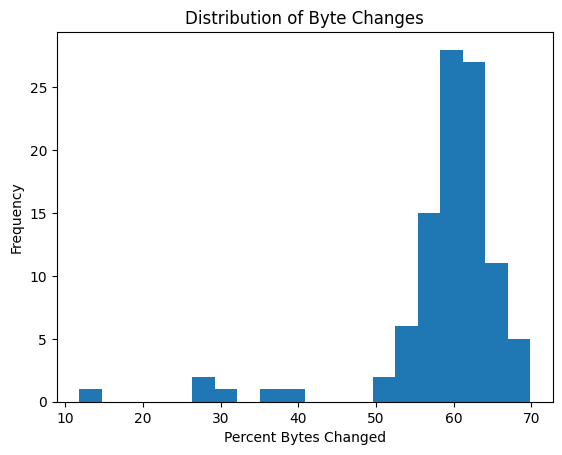

In [ ]:
print("Mean % changed:", df["percent_changed"].mean())
print("Std % changed:", df["percent_changed"].std())

plt.hist(df["percent_changed"], bins=20)
plt.xlabel("Percent Bytes Changed")
plt.ylabel("Frequency")
plt.title("Distribution of Byte Changes")
plt.show()

Load Excel Embedding Metadata

In [ ]:
# Load the specific tab
df_meta = pd.read_excel(excel_path, sheet_name="train_lable_chinese_CNV")

# Force selection of Column 0 (Filename) and Column 2 (0.1, 0.2...)
df_meta = df_meta.iloc[:, [0, 2]].copy()
df_meta.columns = ['Filename_ID', 'Embedding_Rate']

# Clean up: Remove any spaces and add the .g729a extension
df_meta['Filename_ID'] = df_meta['Filename_ID'].astype(str).str.strip() + ".g729a"

print(df_meta.head())

           Filename_ID  Embedding_Rate
0    Chinese1000.g729a             0.1
1  Chinese100003.g729a             0.1
2  Chinese100004.g729a             0.1
3  Chinese100020.g729a             0.1
4  Chinese100032.g729a             0.1


In [ ]:
import pandas as pd

# Initialize a list to hold dataframes from each tab
all_tabs = []

xls = pd.ExcelFile(excel_path)

for sheet in xls.sheet_names:
    # Load the current sheet
    temp_df = pd.read_excel(excel_path, sheet_name=sheet)

    # Grab column 0 (Filename) and column 2 (Embedding Rate)
    temp_df = temp_df.iloc[:, [0, 2]].copy()
    temp_df.columns = ['Filename_ID', 'Embedding_Rate']

    # Add a column to track which category/tab the data came from
    temp_df['Category'] = sheet

    # Clean the Filename_ID: remove spaces, lowercase, and add extension
    temp_df['Filename_ID'] = temp_df['Filename_ID'].astype(str).str.strip().str.lower() + ".g729a"

    all_tabs.append(temp_df)

# Stack all tabs into one master metadata dataframe
df_meta_all = pd.concat(all_tabs, ignore_index=True)

# Remove any empty rows that might have existed in Excel
df_meta_all = df_meta_all.dropna(subset=['Filename_ID'])

print(f"Total metadata records loaded across {len(xls.sheet_names)} tabs: {len(df_meta_all)}")

Total metadata records loaded across 4 tabs: 382296


In [ ]:
# Create a clean matching key in your analysis dataframe
df['filename_match_key'] = df['filename'].astype(str).str.strip().str.lower()

# Merge with the consolidated metadata
merged = df.merge(df_meta_all, left_on="filename_match_key", right_on="Filename_ID", how="left")

# Cleanup: Drop the temporary matching columns
merged = merged.drop(columns=['filename_match_key', 'Filename_ID'])

# Check results
missing = merged["Embedding_Rate"].isna().sum()
if missing == 0:
    print(" Success! All files matched across all tabs.")
else:
    print(f" {missing} files still have no metadata. They might be missing from the Excel entirely.")

merged.head()

 Success! All files matched across all tabs.


,filename,total_bytes,changed_bytes,percent_changed,first_diff_indices,Embedding_Rate,Category
0,English142084.g729a,1000,592,59.2,"[6, 7, 8, 9, 12, 13, 14, 15, 16, 17]",0.1,train_lable_english_PMS
1,Chinese110322.g729a,1000,512,51.2,"[6, 9, 15, 16, 19, 22, 23, 24, 25, 26]",0.1,train_lable_chinese_CNV
2,Chinese102278.g729a,1000,681,68.1,"[6, 7, 9, 10, 11, 13, 14, 15, 16, 17]",0.2,train_lable_chinese_CNV
3,English182618.g729a,1000,362,36.2,"[6, 19, 21, 22, 23, 24, 25, 26, 29, 33]",0.1,train_lable_english_CNV
4,Chinese30293.g729a,1000,590,59.0,"[6, 9, 12, 13, 16, 17, 18, 19, 20, 21]",0.1,train_lable_chinese_CNV


Embedding rate consistency

In [ ]:
# Double-check the column names in your 'merged' dataframe
print("Columns in merged:", merged.columns.tolist())

# Use the correct column name from merge (e.g., 'Embedding_Rate')
grouped = merged.groupby("Embedding_Rate")["percent_changed"].agg(["mean", "std", "count"])

print("\n--- Steganography Impact Analysis ---")
print(grouped)

Columns in merged: ['filename', 'total_bytes', 'changed_bytes', 'percent_changed', 'first_diff_indices', 'Embedding_Rate', 'Category']

--- Steganography Impact Analysis ---
                     mean        std  count
Embedding_Rate                             
0.1             57.840000   9.015034     70
0.2             62.133333   3.845777      9
0.3             58.269231  10.475558     13
0.4             63.937500   4.269472      8


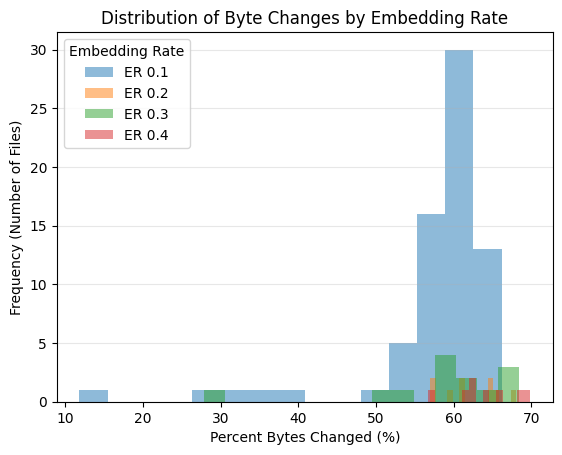

In [ ]:
import matplotlib.pyplot as plt

# Clear any previous plots
plt.clf()

# Get the unique rates available in your data
available_rates = sorted(merged["Embedding_Rate"].dropna().unique())

for rate in available_rates:
    # Filter for the specific rate
    subset = merged[merged["Embedding_Rate"] == rate]

    # Plot the histogram
    plt.hist(subset["percent_changed"],
             bins=15,
             alpha=0.5,
             label=f"ER {rate}")

plt.legend(title="Embedding Rate")
plt.xlabel("Percent Bytes Changed (%)")
plt.ylabel("Frequency (Number of Files)")
plt.title("Distribution of Byte Changes by Embedding Rate")
plt.grid(axis='y', alpha=0.3)

# Save the plot
plt.savefig("byte_change_distribution.png")

CNV vs PMS comparison

In [ ]:
merged["Method"] = "CNV"  # or PMS per sheet

In [ ]:
method_group = merged.groupby("Method")["percent_changed"].agg(["mean","std"])
print(method_group)

         mean       std
Method                 
CNV     58.77  8.732668


Frame level Clustering

Total files after filtering missing ones: 40


  2%|▎         | 1/40 [00:02<01:41,  2.61s/it]

File: English136526.g729a, Frame changes: [np.int64(2), np.int64(7), np.int64(6), np.int64(4), np.int64(6), np.int64(7), np.int64(6), np.int64(7), np.int64(6), np.int64(8), np.int64(7), np.int64(6), np.int64(6), np.int64(7), np.int64(7), np.int64(7), np.int64(7), np.int64(6), np.int64(6), np.int64(7), np.int64(6), np.int64(6), np.int64(7), np.int64(6), np.int64(6), np.int64(7), np.int64(2), np.int64(4), np.int64(7), np.int64(7), np.int64(5), np.int64(6), np.int64(6), np.int64(8), np.int64(5), np.int64(5), np.int64(6), np.int64(3), np.int64(5), np.int64(6), np.int64(8), np.int64(5), np.int64(6), np.int64(5), np.int64(3), np.int64(4), np.int64(0), np.int64(4), np.int64(6), np.int64(3), np.int64(6), np.int64(7), np.int64(4), np.int64(6), np.int64(6), np.int64(7), np.int64(7), np.int64(8), np.int64(7), np.int64(7), np.int64(8), np.int64(6), np.int64(6), np.int64(6), np.int64(2), np.int64(8), np.int64(5), np.int64(5), np.int64(3), np.int64(2), np.int64(3), np.int64(0), np.int64(0), np.int64

  5%|▌         | 2/40 [00:04<01:19,  2.10s/it]

File: Chinese121562.g729a, Frame changes: [np.int64(2), np.int64(5), np.int64(6), np.int64(7), np.int64(5), np.int64(8), np.int64(7), np.int64(8), np.int64(5), np.int64(5), np.int64(5), np.int64(4), np.int64(7), np.int64(8), np.int64(6), np.int64(8), np.int64(5), np.int64(4), np.int64(8), np.int64(8), np.int64(4), np.int64(7), np.int64(7), np.int64(6), np.int64(7), np.int64(4), np.int64(6), np.int64(7), np.int64(6), np.int64(6), np.int64(5), np.int64(8), np.int64(7), np.int64(6), np.int64(7), np.int64(3), np.int64(7), np.int64(5), np.int64(4), np.int64(3), np.int64(6), np.int64(5), np.int64(4), np.int64(3), np.int64(7), np.int64(6), np.int64(8), np.int64(8), np.int64(8), np.int64(8), np.int64(6), np.int64(7), np.int64(7), np.int64(6), np.int64(5), np.int64(5), np.int64(2), np.int64(5), np.int64(7), np.int64(6), np.int64(5), np.int64(5), np.int64(3), np.int64(2), np.int64(3), np.int64(6), np.int64(5), np.int64(7), np.int64(1), np.int64(0), np.int64(2), np.int64(0), np.int64(0), np.int64

...

File: English116291.g729a, Frame changes: [np.int64(1), np.int64(2), np.int64(2), np.int64(6), np.int64(8), np.int64(8), np.int64(5), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(8), np.int64(7), np.int64(7), np.int64(8), np.int64(5), np.int64(7), np.int64(8), np.int64(7), np.int64(6), np.int64(7), np.int64(7), np.int64(6), np.int64(7), np.int64(8), np.int64(7), np.int64(7), np.int64(7), np.int64(4), np.int64(5), np.int64(6), np.int64(5), np.int64(3), np.int64(7), np.int64(6), np.int64(6), np.int64(3), np.int64(6), np.int64(6), np.int64(7), np.int64(6), np.int64(6), np.int64(8), np.int64(6), np.int64(7), np.int64(6), np.int64(8), np.int64(7), np.int64(7), np.int64(6), np.int64(6), np.int64(8), np.int64(7), np.int64(6), np.int64(7), np.int64(7), np.int64(7), np.int64(7), np.int64(7), np.int64(8), np.int64(8), np.int64(6), np.int64(7), np.int64(7), np.int64(6), np.int64(8), np.int64(8), np.int64(8), np.int64(8), np.int64(7), np.int64(7), np.int64(6), np.int64(6), np.int64

 98%|█████████▊| 39/40 [00:57<00:01,  1.31s/it]

File: English118497.g729a, Frame changes: [np.int64(2), np.int64(8), np.int64(3), np.int64(5), np.int64(1), np.int64(2), np.int64(3), np.int64(6), np.int64(2), np.int64(7), np.int64(8), np.int64(5), np.int64(6), np.int64(7), np.int64(6), np.int64(3), np.int64(4), np.int64(6), np.int64(3), np.int64(1), np.int64(2), np.int64(5), np.int64(5), np.int64(6), np.int64(7), np.int64(6), np.int64(8), np.int64(4), np.int64(6), np.int64(8), np.int64(7), np.int64(7), np.int64(6), np.int64(8), np.int64(6), np.int64(8), np.int64(7), np.int64(7), np.int64(5), np.int64(5), np.int64(6), np.int64(8), np.int64(4), np.int64(6), np.int64(7), np.int64(7), np.int64(3), np.int64(7), np.int64(5), np.int64(7), np.int64(8), np.int64(8), np.int64(7), np.int64(8), np.int64(7), np.int64(7), np.int64(6), np.int64(6), np.int64(8), np.int64(7), np.int64(6), np.int64(6), np.int64(8), np.int64(7), np.int64(6), np.int64(7), np.int64(7), np.int64(8), np.int64(5), np.int64(7), np.int64(6), np.int64(7), np.int64(7), np.int64

100%|██████████| 40/40 [00:58<00:00,  1.47s/it]

File: Chinese107483.g729a, Frame changes: [np.int64(2), np.int64(6), np.int64(8), np.int64(7), np.int64(4), np.int64(6), np.int64(5), np.int64(6), np.int64(6), np.int64(1), np.int64(3), np.int64(6), np.int64(7), np.int64(5), np.int64(8), np.int64(6), np.int64(7), np.int64(6), np.int64(6), np.int64(8), np.int64(5), np.int64(8), np.int64(7), np.int64(6), np.int64(8), np.int64(7), np.int64(6), np.int64(6), np.int64(8), np.int64(7), np.int64(8), np.int64(8), np.int64(6), np.int64(6), np.int64(5), np.int64(6), np.int64(6), np.int64(6), np.int64(7), np.int64(7), np.int64(5), np.int64(5), np.int64(7), np.int64(6), np.int64(6), np.int64(5), np.int64(7), np.int64(5), np.int64(2), np.int64(3), np.int64(7), np.int64(7), np.int64(5), np.int64(7), np.int64(6), np.int64(8), np.int64(5), np.int64(5), np.int64(7), np.int64(6), np.int64(7), np.int64(7), np.int64(7), np.int64(6), np.int64(7), np.int64(7), np.int64(7), np.int64(7), np.int64(7), np.int64(7), np.int64(7), np.int64(6), np.int64(8), np.int64

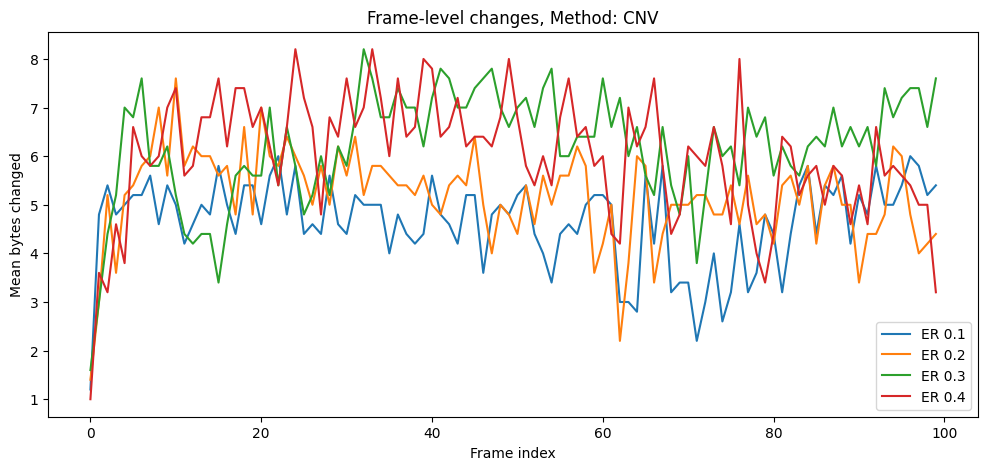

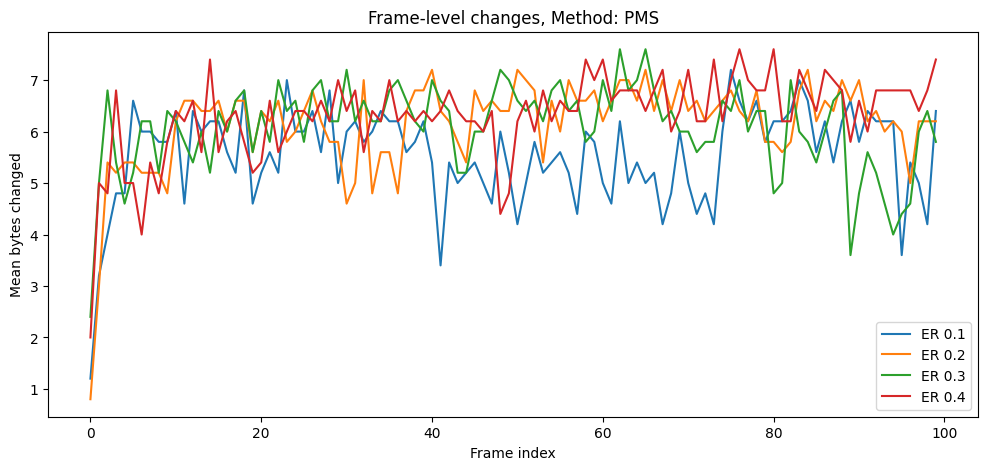

In [ ]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

cover_path = "/content/drive/MyDrive/IIT - University of Westminster Material/VStego800K dataset/Vstego100kSamples/cover"
stego_path = "/content/drive/MyDrive/IIT - University of Westminster Material/VStego800K dataset/Vstego100kSamples/stego"
excel_path = "/content/drive/MyDrive/IIT - University of Westminster Material/VStego800K dataset/train_lable.xlsx"

# Load metadata
xls = pd.ExcelFile(excel_path)
# example: load all four sheets
sheets = ["train_lable_chinese_CNV", "train_lable_chinese_PMS", "train_lable_english_CNV", "train_lable_english_PMS"]

df_meta_list = []
for sheet in sheets:
    df = pd.read_excel(xls, sheet_name=sheet)
    df["Filename"] = df["Filename"].astype(str) + ".g729a"
    df["Method"] = "CNV" if "CNV" in sheet else "PMS"
    df_meta_list.append(df)

df_meta = pd.concat(df_meta_list, ignore_index=True)

# List files
cover_files = sorted(os.listdir(cover_path))
stego_files = sorted(os.listdir(stego_path))

# Frame-level analysis function
def frame_level_analysis(file_name, frame_size=10):
    cover_file = os.path.join(cover_path, file_name)
    stego_file = os.path.join(stego_path, file_name)

    with open(cover_file, 'rb') as f:
        cover_bytes = np.frombuffer(f.read(), dtype=np.uint8)

    with open(stego_file, 'rb') as f:
        stego_bytes = np.frombuffer(f.read(), dtype=np.uint8)

    min_len = min(len(cover_bytes), len(stego_bytes))
    cover_bytes = cover_bytes[:min_len]
    stego_bytes = stego_bytes[:min_len]

    xor = cover_bytes ^ stego_bytes
    frame_changes = []

    for i in range(0, min_len, frame_size):
        frame = xor[i:i+frame_size]
        frame_changes.append(np.sum(frame != 0))

    return frame_changes

# Pick random subset
# ---- Uniform sampling per ER ----
random.seed(42)
n_max_per_ER = 5  # max files per ER
sample_files = []

cover_set = set(cover_files)
stego_set = set(stego_files)

for method in df_meta["Method"].unique():
    subset_method = df_meta[df_meta["Method"] == method]
    for ER in subset_method["Embedding rate"].unique():
        files_with_ER = subset_method[subset_method["Embedding rate"] == ER]["Filename"].tolist()

        # Keep only files that exist in your subset
        files_with_ER = [f for f in files_with_ER if f in cover_set and f in stego_set]
        if not files_with_ER:
            continue  # skip if none exist

        if len(files_with_ER) > n_max_per_ER:
            chosen = random.sample(files_with_ER, n_max_per_ER)
        else:
            chosen = files_with_ER

        sample_files.extend(chosen)

print(f"Total files after filtering missing ones: {len(sample_files)}")

results = []

for f in tqdm(sample_files):
    frame_changes = frame_level_analysis(f)

    # Print frame changes
    print(f"File: {f}, Frame changes: {frame_changes}")

    # Merge metadata if exists
    meta_row = df_meta[df_meta["Filename"] == f]
    if not meta_row.empty:
        ER = float(meta_row["Embedding rate"].values[0])
        method = meta_row["Method"].values[0]
    else:
        ER = None
        method = "Unknown"

    results.append({
        "filename": f,
        "frame_changes": frame_changes,
        "Embedding_rate": ER,
        "Method": method
    })

df_results = pd.DataFrame(results)

# ---- Plotting ----
frame_size = 10

for method in df_results["Method"].unique():
    plt.figure(figsize=(12,5))
    subset = df_results[df_results["Method"] == method]
    for ER in sorted(subset["Embedding_rate"].dropna().unique()):
        subset_er = subset[subset["Embedding_rate"] == ER]
        if subset_er.empty:
            continue
        # Compute mean per frame
        all_frame_changes = [fc for fc in subset_er["frame_changes"]]
        max_len = max(len(fc) for fc in all_frame_changes)
        padded_changes = [fc + [0]*(max_len - len(fc)) for fc in all_frame_changes]
        mean_per_frame = np.mean(padded_changes, axis=0)
        plt.plot(range(len(mean_per_frame)), mean_per_frame, label=f"ER {ER}")
    plt.title(f"Frame-level changes, Method: {method}")
    plt.xlabel("Frame index")
    plt.ylabel("Mean bytes changed")
    plt.legend()
    plt.show()

Silence check

In [ ]:
import os
import subprocess
import numpy as np
from tqdm import tqdm

# Define paths
cover_path = "/content/drive/MyDrive/IIT - University of Westminster Material/VStego800K dataset/Vstego100kSamples/cover"
stego_path = "/content/drive/MyDrive/IIT - University of Westminster Material/VStego800K dataset/Vstego100kSamples/stego"

def get_audio_db(file_path):
    """
    Decodes a G.729A file in memory using FFmpeg and returns its RMS energy in dBFS.
    """
    cmd = [
        'ffmpeg', '-y',
        '-f', 'g729',
        '-i', file_path,
        '-f', 's16le', '-acodec', 'pcm_s16le', '-ar', '8000', '-ac', '1',
        '-loglevel', 'quiet', '-'
    ]
    try:
        # Pipe the raw decoded audio directly to Python
        raw_audio = subprocess.check_output(cmd)

        # Convert bytes to a numpy array of floats between -1.0 and 1.0
        audio_array = np.frombuffer(raw_audio, dtype=np.int16).astype(np.float32) / 32768.0

        if len(audio_array) == 0:
            return -float('inf')

        # Calculate RMS (Root Mean Square) energy
        rms = np.sqrt(np.mean(audio_array**2))

        # Convert to Decibels (dBFS)
        return 20 * np.log10(rms) if rms > 0 else -float('inf')

    except Exception as e:
        # If ffmpeg still fails for some reason,the file is broken/silent
        return -float('inf')

def find_silent_files(directory, silence_threshold=-45.0):
    """
    Scans a directory for .g729a files and flags those below the dB threshold.
    """
    silent_files = []
    files = [f for f in os.listdir(directory) if f.endswith('.g729a')]

    print(f"\nScanning {os.path.basename(directory).upper()} for silence (Threshold: {silence_threshold} dB)...")
    for f in tqdm(files):
        full_path = os.path.join(directory, f)
        db = get_audio_db(full_path)

        if db < silence_threshold:
            silent_files.append((f, db))

    return silent_files

# def cleanup_silent_files(silent_list, source_folder_name):
#     """
#     Deletes the .g729a file AND its corresponding .npy matrix.
#     source_folder_name should be 'cover' or 'stego'
#     """
#     if not silent_list:
#         print(f"No silent files to clean in {source_folder_name}.")
#         return

#     print(f"\nCleaning up {len(silent_list)} silent files from {source_folder_name}...")

#     count = 0
#     for fname, db in silent_list:
#         # 1. Define paths for .g729a
#         g729_path = os.path.join(cover_path if source_folder_name == 'cover' else stego_path, fname)

#         # # 2. Define paths for .npy
#         # npy_fname = fname.replace('.g729a', '.npy')
#         # npy_path = os.path.join(npy_base_path, source_folder_name, npy_fname)

#         # 3. Delete them
#         if os.path.exists(g729_path):
#             os.remove(g729_path)
#         if os.path.exists(npy_path):
#             os.remove(npy_path)
#         count += 1

#     print(f"-> Deleted {count} pairs.")

# --- EXECUTION ---

# 1. Find Silent Files
COVER_SILENT = find_silent_files(cover_path, silence_threshold=-45.0)
print(f"-> Found {len(COVER_SILENT)} silent cover files.")

STEGO_SILENT = find_silent_files(stego_path, silence_threshold=-45.0)
print(f"-> Found {len(STEGO_SILENT)} silent stego files.")

Sampling 1000 files for dB distribution...


100%|██████████| 1000/1000 [12:34<00:00,  1.32it/s]



 NUMERICAL RESULTS:
Total valid files analyzed: 1000
Files strictly BELOW -45.0 dB (Silent): 0 (0.00%)
Minimum dB level: -44.82 dB
Maximum dB level: -7.84 dB
Average dB level: -27.87 dB



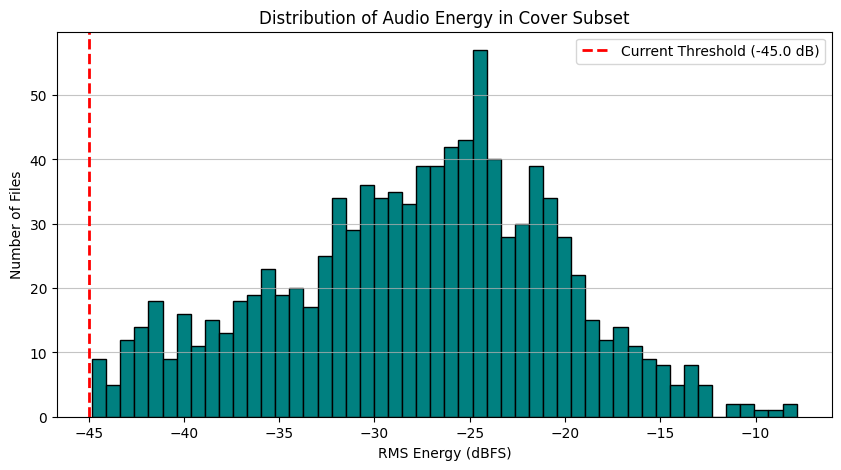

In [ ]:
import os
import random
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm

# Reuse the get_audio_db function you already have loaded in memory
sample_files = random.sample(os.listdir(cover_path), 1000)
db_levels = []
threshold = -45.0

print("Sampling 1000 files for dB distribution...")
for f in tqdm(sample_files):
    if f.endswith('.g729a'):
        full_path = os.path.join(cover_path, f)
        db = get_audio_db(full_path)
        if db != -float('inf'):
            db_levels.append(db)

# --- NEW: PRINT THE NUMERICAL RESULTS ---
below_threshold = [db for db in db_levels if db < threshold]
total_valid = len(db_levels)
num_below = len(below_threshold)

print("\n" + "="*40)
print(" NUMERICAL RESULTS:")
print("="*40)
print(f"Total valid files analyzed: {total_valid}")

if total_valid > 0:
    print(f"Files strictly BELOW {threshold} dB (Silent): {num_below} ({(num_below/total_valid)*100:.2f}%)")
    print(f"Minimum dB level: {min(db_levels):.2f} dB")
    print(f"Maximum dB level: {max(db_levels):.2f} dB")
    print(f"Average dB level: {np.mean(db_levels):.2f} dB")
print("="*40 + "\n")

# Plotting the histogram
plt.figure(figsize=(10, 5))
plt.hist(db_levels, bins=50, color='teal', edgecolor='black')
plt.axvline(x=threshold, color='red', linestyle='dashed', linewidth=2, label=f'Current Threshold ({threshold} dB)')
plt.title("Distribution of Audio Energy in Cover Subset")
plt.xlabel("RMS Energy (dBFS)")
plt.ylabel("Number of Files")
plt.legend()
plt.grid(axis='y', alpha=0.75)
plt.show()

#====================================================================================================

## MODEL PREPROCESSING



**Binary Matrix Generation**

In [ ]:
import numpy as np
import os
from tqdm import tqdm

def g729_to_binary_matrix(file_path):
    """
    Converts a G.729a raw bitstream file into a binary matrix.
    Each 10-byte frame = one 80-bit row.
    """
    try:
        with open(file_path, 'rb') as f:
            data = f.read()

        # Check if file is exactly 1 second (100 frames * 10 bytes)
        # G.729a is 8kbps, so 1 second = 8000 bits = 1000 bytes.
        if len(data) != 1000:
            # Can change this to len(data) // 10 if want variable lengths,
            # but for current 1s dataset, this gives uniformity.
            num_frames = 100
            data = data[:1000]
        else:
            num_frames = 100

        # Unpack bytes into bits (0 and 1)
        bits = np.unpackbits(np.frombuffer(data, dtype=np.uint8))

        # Reshape to (100, 80)
        return bits.reshape(num_frames, 80).astype(np.float32)
    except Exception as e:
        return None

def run_batch_extraction(base_input_path, base_output_path):
    subfolders = ['cover', 'stego']

    for folder in subfolders:
        src_dir = os.path.join(base_input_path, folder)
        dst_dir = os.path.join(base_output_path, folder)

        if not os.path.exists(src_dir):
            print(f"Directory not found: {src_dir}")
            continue

        os.makedirs(dst_dir, exist_ok=True)
        files = [f for f in os.listdir(src_dir) if f.endswith('.g729a')]

        print(f"\nExtracting {folder.upper()} bit-matrices...")
        for fname in tqdm(files):
            in_file = os.path.join(src_dir, fname)
            out_file = os.path.join(dst_dir, fname.replace('.g729a', '.npy'))

            # Skip if already exists
            if os.path.exists(out_file):
                continue

            matrix = g729_to_binary_matrix(in_file)
            if matrix is not None:
                np.save(out_file, matrix)

# --- EXECUTION ---
INPUT_BASE = "/content/drive/MyDrive/IIT - University of Westminster Material/VStego800K dataset/Vstego50kSamples"
OUTPUT_BASE = "/content/drive/MyDrive/IIT - University of Westminster Material/VStego800K dataset/Vstego50kSamples/Bitstream_Matrices_v1"

run_batch_extraction(INPUT_BASE, OUTPUT_BASE)


Extracting COVER bit-matrices...


100%|██████████| 24996/24996 [13:24<00:00, 31.08it/s]



Extracting STEGO bit-matrices...


100%|██████████| 24996/24996 [19:20<00:00, 21.53it/s]


**Forensic check**

In [ ]:
import numpy as np
import os
import matplotlib.pyplot as plt

# Paths to created .npy folders
matrix_cover_dir = "/content/drive/MyDrive/IIT - University of Westminster Material/VStego800K dataset/Vstego50kSamples/Bitstream_Matrices_v1/cover"
matrix_stego_dir = "/content/drive/MyDrive/IIT - University of Westminster Material/VStego800K dataset/Vstego50kSamples/Bitstream_Matrices_v1/stego"

def verify_samples(num_to_check=3):
    cover_files = sorted([f for f in os.listdir(matrix_cover_dir) if f.endswith('.npy')])
    stego_files = sorted([f for f in os.listdir(matrix_stego_dir) if f.endswith('.npy')])

    # Find common files to compare pairs
    common_files = list(set(cover_files) & set(stego_files))

    print(f"Total pairs found: {len(common_files)}")

    for i in range(min(num_to_check, len(common_files))):
        fname = common_files[i]
        c_mat = np.load(os.path.join(matrix_cover_dir, fname))
        s_mat = np.load(os.path.join(matrix_stego_dir, fname))

        # 1. Check Shape
        print(f"\n--- Checking: {fname} ---")
        print(f"Shape: {c_mat.shape} | Dtype: {c_mat.dtype}")

        # 2. Check Values (Should be exactly 0.0 and 1.0)
        unique_vals = np.unique(c_mat)
        print(f"Unique values: {unique_vals}")

        # 3. Check for the Forensic Signal (The Residual)
        residual = np.abs(s_mat - c_mat)
        diff_bits = np.sum(residual)
        diff_percentage = (diff_bits / c_mat.size) * 100
        print(f"Bits changed in this pair: {int(diff_bits)} ({diff_percentage:.2f}%)")

        if diff_bits == 0:
            print("WARNING: No difference detected between cover and stego!")
        else:
            print("SUCCESS: Forensic signal preserved.")

# Run it
verify_samples()

Total pairs found: 24996

--- Checking: Chinese109100.npy ---
Shape: (100, 80) | Dtype: float32
Unique values: [0. 1.]
Bits changed in this pair: 1775 (22.19%)
SUCCESS: Forensic signal preserved.

--- Checking: English131437.npy ---
Shape: (100, 80) | Dtype: float32
Unique values: [0. 1.]
Bits changed in this pair: 1957 (24.46%)
SUCCESS: Forensic signal preserved.

--- Checking: English135911.npy ---
Shape: (100, 80) | Dtype: float32
Unique values: [0. 1.]
Bits changed in this pair: 1202 (15.03%)
SUCCESS: Forensic signal preserved.


**Upgrade to 3-channel tensors**

In [ ]:
import numpy as np
import os
from tqdm import tqdm

# Paths: Read from current 1-channel folder, save to a new 3-channel folder
INPUT_BASE = "/content/drive/MyDrive/IIT - University of Westminster Material/VStego800K dataset/Vstego50kSamples/Bitstream_Matrices_v1"
OUTPUT_BASE = "/content/drive/MyDrive/IIT - University of Westminster Material/VStego800K dataset/Vstego50kSamples/MultiChannel_Matrices_v1"

def compute_temporal_diff(matrix):
    """Channel 2: Calculates the absolute difference between consecutive frames."""
    diff = np.zeros_like(matrix)
    diff[1:] = np.abs(matrix[1:] - matrix[:-1])
    return diff

def compute_bit_stability(matrix):
    """Channel 3: Calculates how much each bit deviates from its average state."""
    mean_bits = np.mean(matrix, axis=0, keepdims=True)
    stability = np.abs(matrix - mean_bits)
    return stability

def upgrade_to_3_channel():
    subfolders = ['cover', 'stego']

    for folder in subfolders:
        src_dir = os.path.join(INPUT_BASE, folder)
        dst_dir = os.path.join(OUTPUT_BASE, folder)

        if not os.path.exists(src_dir):
            print(f"Directory not found: {src_dir}")
            continue

        os.makedirs(dst_dir, exist_ok=True)

        # Look for the .npy files you already extracted
        files = [f for f in os.listdir(src_dir) if f.endswith('.npy')]

        print(f"\nUpgrading {folder.upper()} matrices to 3-Channel...")
        for fname in tqdm(files):
            in_file = os.path.join(src_dir, fname)
            out_file = os.path.join(dst_dir, fname)

            # Skip if already exists
            if os.path.exists(out_file):
                continue

            try:
                # 1. Load the raw bits (Channel 1)
                raw_matrix = np.load(in_file).astype(np.float32)

                # 2. Compute the new channels (Channels 2 and 3)
                temp_diff = compute_temporal_diff(raw_matrix)
                stability = compute_bit_stability(raw_matrix)

                # 3. Stack them into a (3, 100, 80) tensor
                multi_channel = np.stack([raw_matrix, temp_diff, stability], axis=0)

                # 4. Save the new tensor
                np.save(out_file, multi_channel)
            except Exception as e:
                print(f"Error processing {fname}: {e}")

# --- EXECUTION ---
upgrade_to_3_channel()
print("\n Dataset upgraded to 3-Channel tensors!")


Upgrading COVER matrices to 3-Channel...


100%|██████████| 24996/24996 [12:53<00:00, 32.30it/s]



Upgrading STEGO matrices to 3-Channel...


100%|██████████| 24996/24996 [13:55<00:00, 29.93it/s]


 Dataset upgraded to 3-Channel tensors!


**Dataset check**

In [ ]:
import numpy as np
import os

# Grab the first file in the new cover directory
test_dir = "/content/drive/MyDrive/IIT - University of Westminster Material/VStego800K dataset/Vstego50kSamples/MultiChannel_Matrices_v1/cover"
test_file = os.path.join(test_dir, os.listdir(test_dir)[0])

tensor = np.load(test_file)
print(f"Shape: {tensor.shape}")
print(f"Data Type: {tensor.dtype}")

Shape: (3, 100, 80)
Data Type: float32


#====================================================================================================

# MODEL PIPELINE

#Copy files from drive to colab



In [ ]:
import os

# --- 1. Define the exact paths from Drive ---
drive_folder = "/content/drive/MyDrive/IIT - University of Westminster Material/VStego800K dataset/Vstego100kSamples/MultiChannel_Matrices_v1"

cover_zip = f"{drive_folder}/cover-20260314T232838Z-3-001.zip"
stego_zip = f"{drive_folder}/stego-20260314T224850Z-3-001.zip"

# --- 2. Define where they should go locally ---
local_base = "/content/dataset_local"
os.makedirs(f"{local_base}/cover", exist_ok=True)
os.makedirs(f"{local_base}/stego", exist_ok=True)

# --- 3. Execute Copy and Unzip ---
print(" Extracting Cover matrices...")
!unzip -q "{cover_zip}" -d "{local_base}/cover"

print(" Extracting Stego matrices...")
!unzip -q "{stego_zip}" -d "{local_base}/stego"

# --- 4. Verify the count ---
cover_count = len(os.listdir(f"{local_base}/cover"))
stego_count = len(os.listdir(f"{local_base}/stego"))

print(f"\n Success!")
print(f"Total Covers extracted: {cover_count}")
print(f"Total Stegos extracted: {stego_count}")

 Extracting Cover matrices...
 Extracting Stego matrices...

 Success!
Total Covers extracted: 1
Total Stegos extracted: 1


In [ ]:
import shutil
import os

def flatten_directory(parent_path):
    # This looks for a folder named 'cover' inside 'cover' (or 'stego' inside 'stego')
    subfolders = [f for f in os.listdir(parent_path) if os.path.isdir(os.path.join(parent_path, f))]

    for sub in subfolders:
        nested_path = os.path.join(parent_path, sub)

        print(f"Moving files out of {nested_path}...")

        for file_name in os.listdir(nested_path):
            shutil.move(os.path.join(nested_path, file_name), os.path.join(parent_path, file_name))

        # Remove the now-empty nested folder
        os.rmdir(nested_path)
        print(f"{parent_path} flattened successfully.")

# Apply to both local directories
flatten_directory("/content/dataset_local/cover")
flatten_directory("/content/dataset_local/stego")

Moving files out of /content/dataset_local/cover/cover...
/content/dataset_local/cover flattened successfully.
Moving files out of /content/dataset_local/stego/stego...
/content/dataset_local/stego flattened successfully.


In [ ]:
!pip install comet_ml

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 786.2/786.2 kB 38.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 27.5 MB/s eta 0:00:00
  Attempting uninstall: python-box
    Found existing installation: python-box 7.4.1
    Uninstalling python-box-7.4.1:
      Successfully uninstalled python-box-7.4.1


In [ ]:
import os

broken_file = "/content/dataset_local/cover/English10588.npy"

if os.path.exists(broken_file):
    os.remove(broken_file)
    print(f" Successfully deleted: {broken_file}")
else:
    print(" File not found. It may have already been removed.")

 Successfully deleted: /content/dataset_local/cover/English10588.npy


In [ ]:
!find '/content/dataset_local/cover' -type f | wc -l


49991


#Dataset splitting

In [ ]:
import os
import json
import random
import numpy as np
import torch
from datetime import datetime
from torch.utils.data import Dataset, ConcatDataset, Subset, DataLoader
from sklearn.model_selection import GroupShuffleSplit
import pandas as pd
import shutil
from tqdm import tqdm

# ============================================================================
# CONFIGURATION
# ============================================================================
BASE_DIR = "/content/dataset_local"

# ----------------------------------------------------------------------------
# Route the saved split indices directly to Google Drive
# ----------------------------------------------------------------------------
SOURCE_DIR = "/content/drive/MyDrive/IIT - University of Westminster Material/VStego800K dataset/split_indices_100k_samples"
os.makedirs(SOURCE_DIR, exist_ok=True)

# Directing the script to exact local folders
COVER_DIR = os.path.join(BASE_DIR, "cover")
STEGO_DIR = os.path.join(BASE_DIR, "stego")

# ----------------------------------------------------------------------------
# UPDATED: Direct path to the Excel file in Google Drive
# ----------------------------------------------------------------------------
EXCEL_PATH = "/content/drive/MyDrive/IIT - University of Westminster Material/VStego800K dataset/train_lable.xlsx"

SEED = 42
VAL_RATIO = 0.15
TEST_RATIO = 0.0
BATCH_SIZE = 128

# ============================================================================
# 1. DATASET CLASS
# ============================================================================
def load_excel_metadata(excel_path):
    print("Loading Excel metadata...")
    meta_map = {}
    if not os.path.exists(excel_path):
        print(f" [!] Excel file not found at {excel_path}. Metadata will be empty.")
        return meta_map

    xls = pd.ExcelFile(excel_path)
    tabs = ["train_lable_english_CNV", "train_lable_english_PMS",
            "train_lable_chinese_CNV", "train_lable_chinese_PMS"]

    for tab in tabs:
        if tab not in xls.sheet_names: continue
        current_algo = "CNV" if "CNV" in tab else "PMS"
        df = pd.read_excel(xls, sheet_name=tab)

        for _, row in df.iterrows():
            if pd.notna(row.iloc[0]):
                fname = str(row.iloc[0]).strip()
                try:
                    rate = round(float(row.iloc[2]), 1)
                except:
                    rate = 0.0
                meta_map[fname] = {'algo': current_algo, 'rate': rate}

    print(f" -> Loaded Excel metadata for {len(meta_map)} samples.")
    return meta_map

class MatrixDataset(Dataset):
    def __init__(self, data_folder, label, meta_map=None):
        self.data_folder = data_folder
        self.label = label

        # Grab all .npy files
        self.files = [f for f in os.listdir(data_folder) if f.endswith(".npy")]
        self.files = sorted(self.files)

        # Base names (e.g., 'Chinese112894.npy' -> 'Chinese112894')
        self.base_names = [f.replace(".npy", "") for f in self.files]

        # ---> METADATA TRACKING <---
        self.meta_map = meta_map or {}
        self.metadata = []
        for b in self.base_names:
            if b in self.meta_map:
                self.metadata.append(self.meta_map[b])
            else:
                self.metadata.append({'algo': 'Cover' if label == 0 else 'Unknown', 'rate': 0.0})

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        file_path = os.path.join(self.data_folder, self.files[idx])
        # Load the (3, 100, 80) float32 tensor
        matrix = np.load(file_path)
        tensor = torch.from_numpy(matrix)

        return tensor, torch.tensor(self.label, dtype=torch.long)

    def get_metadata(self, idx):
        return {
            'base_name': self.base_names[idx],
            'algo': self.metadata[idx]['algo'],
            'rate': self.metadata[idx]['rate'],
            'is_stego': self.label == 1
        }

def set_global_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    os.environ['PYTHONHASHSEED'] = str(seed)
    print(f" -> Global Seed locked to: {seed}")

# ============================================================================
# 2. GROUP-AWARE SPLIT FUNCTION (REMOVING TEST SPLIT)
# ============================================================================
def create_group_aware_splits(cover_dataset, stego_dataset,
                              val_ratio=0.15, test_ratio=0.0, seed=42,
                              save_indices=True, experiment_name="group_aware_matrices"):
    print("\nGenerating Forensic Group-Aware Splits (Train/Val only)...")

    # 1. Extract base names to form groups
    all_groups = np.array(cover_dataset.base_names + stego_dataset.base_names)
    all_indices = np.arange(len(all_groups))

    print(f"  Total Samples: {len(all_groups)}")
    print(f"  Unique Sources: {len(set(all_groups))}")

    # 2. Split Train vs Val (Now test_ratio is 0.0)
    gss = GroupShuffleSplit(n_splits=1, test_size=val_ratio, random_state=seed)
    train_idx, val_idx = next(gss.split(all_indices, groups=all_groups))

    # 3. Test index is empty as we use the official VStego800k Test Set
    test_idx = np.array([])

    # 4. Shuffle Indices
    np.random.shuffle(train_idx)
    np.random.shuffle(val_idx)

    # 5. Leakage Verification
    train_groups_set = set(all_groups[train_idx])
    val_groups_set = set(all_groups[val_idx])

    leakage_tv = train_groups_set.intersection(val_groups_set)

    if len(leakage_tv) > 0:
        raise ValueError(f"CRITICAL LEAKAGE DETECTED! Overlap: {len(leakage_tv)}")
    else:
        print("  LEAKAGE CHECK PASSED: 0 overlapping audio sources.")

    # 6. Create Datasets
    full_dataset = ConcatDataset([cover_dataset, stego_dataset])
    train_ds = Subset(full_dataset, train_idx)
    val_ds   = Subset(full_dataset, val_idx)
    test_ds  = Subset(full_dataset, test_idx) # This will be empty

    print(f"  Train: {len(train_ds)} | Val: {len(val_ds)} | Test (Local): {len(test_ds)}")

    # 7. Save Indices
    if save_indices:
        split_info = {
            "experiment_name": experiment_name,
            "timestamp": datetime.now().isoformat(),
            "random_seed": seed,
            "indices": {
                "train": train_idx.tolist(),
                "val": val_idx.tolist(),
                "test": test_idx.tolist()
            }
        }
        save_path = os.path.join(SOURCE_DIR, f"split_indices_{experiment_name}_seed{seed}.json")
        with open(save_path, 'w') as f:
            json.dump(split_info, f)
        print(f"  Split indices saved to: {save_path}")

    return train_ds, val_ds, test_ds

def load_split_indices(filepath, full_dataset):
    """
    Loads previously saved training/validation indices from a JSON file
    to ensure consistency across different sessions.
    """
    print(f"Loading split from: {filepath}")
    with open(filepath, 'r') as f:
        data = json.load(f)

    train_ds = Subset(full_dataset, data["indices"]["train"])
    val_ds   = Subset(full_dataset, data["indices"]["val"])
    test_ds  = Subset(full_dataset, data["indices"]["test"])

    return train_ds, val_ds, test_ds

# ============================================================================
# 3. MAIN EXECUTION (Updated for Optuna/Training workflow)
# ============================================================================
if __name__ == "__main__":
    print(f"{'='*50}\nDataset Preparation Pipeline (85/15 Split)\n{'='*50}")
    set_global_seed(SEED)

    global_meta_map = load_excel_metadata(EXCEL_PATH)

    print("\nLoading datasets...")
    cover_dataset = MatrixDataset(data_folder=COVER_DIR, label=0)
    stego_dataset = MatrixDataset(data_folder=STEGO_DIR, label=1, meta_map=global_meta_map)

    full_dataset = ConcatDataset([cover_dataset, stego_dataset])

    # Important: Rename experiment if want to keep old splits separate
    EXPERIMENT_NAME = "stego-detection-3channel"
    SPLIT_FILE = os.path.join(SOURCE_DIR, f"split_indices_{EXPERIMENT_NAME}_seed{SEED}.json")

    if os.path.exists(SPLIT_FILE):
        print("\nFound existing split file. Loading...")
        train_dataset, val_dataset, test_dataset = load_split_indices(SPLIT_FILE, full_dataset)
    else:
        print("\nCreating NEW group-aware split (No local test set)...")
        train_dataset, val_dataset, test_dataset = create_group_aware_splits(
            cover_dataset, stego_dataset,
            val_ratio=VAL_RATIO, test_ratio=0.0, seed=SEED,
            save_indices=True, experiment_name=EXPERIMENT_NAME
        )

    # Note: test_loader is still created but will be empty/unused locally.
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
    val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

    print(f"\n Pipeline Ready. Using {len(train_dataset)} for training and {len(val_dataset)} for validation.")

    # Verification Print
    x, y = next(iter(train_loader))
    print(f"Batch Shape: {x.shape} -> [Batch, Channels, Frames, Bits]")
    print(f"Labels Shape: {y.shape}")

Dataset Preparation Pipeline (85/15 Split)
 -> Global Seed locked to: 42
Loading Excel metadata...
 -> Loaded Excel metadata for 382296 samples.

Loading datasets...

Found existing split file. Loading...
Loading split from: /content/drive/MyDrive/IIT - University of Westminster Material/VStego800K dataset/split_indices_100k_samples/split_indices_stego-detection-3channel_seed42.json

 Pipeline Ready. Using 84984 for training and 14998 for validation.
Batch Shape: torch.Size([128, 3, 100, 80]) -> [Batch, Channels, Frames, Bits]
Labels Shape: torch.Size([128])


**Channel check**

In [ ]:
# ============================================================================
# INPUT AUDIT (CHANNEL CORRELATION CHECK)
# ============================================================================
import numpy as np

print(f"{'='*50}\nAuditing Input Channels for Redundancy\n{'='*50}")

# Parameters for the audit
NUM_BATCHES_TO_AUDIT = 5
THRESHOLD = 0.90

ch1_all, ch2_all, ch3_all = [], [], []

print(f"Extracting {NUM_BATCHES_TO_AUDIT} batches for statistical audit...")

# 1. Accumulate data across a few batches to ensure stable correlation
for i, (x, y) in enumerate(train_loader):
    if i >= NUM_BATCHES_TO_AUDIT:
        break

    # x shape is expected to be [Batch, 3, 100, 80]
    # Flattening the dimensions to compare the raw feature distributions
    ch1_all.append(x[:, 0, :, :].numpy().flatten())
    ch2_all.append(x[:, 1, :, :].numpy().flatten())
    ch3_all.append(x[:, 2, :, :].numpy().flatten())

# Concatenate all collected batches into single 1D arrays
ch1_flat = np.concatenate(ch1_all)
ch2_flat = np.concatenate(ch2_all)
ch3_flat = np.concatenate(ch3_all)

print(f"Total data points analyzed per channel: {len(ch1_flat):,}\n")

# 2. Compute Pearson Correlation Coefficients
# np.corrcoef returns a 2x2 matrix; index [0, 1] gives the correlation value
corr_1_2 = np.corrcoef(ch1_flat, ch2_flat)[0, 1]
corr_1_3 = np.corrcoef(ch1_flat, ch3_flat)[0, 1]
corr_2_3 = np.corrcoef(ch2_flat, ch3_flat)[0, 1]

print("--- Correlation Results ---")
print(f"Ch1 vs Ch2 Correlation: {corr_1_2:.4f}")
print(f"Ch1 vs Ch3 Correlation: {corr_1_3:.4f}")
print(f"Ch2 vs Ch3 Correlation: {corr_2_3:.4f}\n")

# 3. Decision Logic & Recommendations
print("--- Audit Verdict ---")
redundancy_found = False

if abs(corr_1_2) > THRESHOLD:
    print(" [WARNING] Channel 1 and Channel 2 are highly correlated!")
    redundancy_found = True
if abs(corr_1_3) > THRESHOLD:
    print(" [WARNING] Channel 1 and Channel 3 are highly correlated!")
    redundancy_found = True
if abs(corr_2_3) > THRESHOLD:
    print(" [WARNING] Channel 2 and Channel 3 are highly correlated!")
    redundancy_found = True

if redundancy_found:
    print("\nACTION REQUIRED: Drop the redundant channel(s) to reduce model parameters, ")
    print("OR replace the redundant channel with a new feature mapping (e.g., bit-position entropy).")
else:
    print(" PASS: Channels are mathematically distinct. Model representation power is not being wasted.")

Auditing Input Channels for Redundancy
Extracting 5 batches for statistical audit...
Total data points analyzed per channel: 1,280,000

--- Correlation Results ---
Ch1 vs Ch2 Correlation: 0.0184
Ch1 vs Ch3 Correlation: 0.0834
Ch2 vs Ch3 Correlation: 0.2058

--- Audit Verdict ---
 PASS: Channels are mathematically distinct. Model representation power is not being wasted.


#Verify if stego methods are equally distributed across splits

In [ ]:
import pandas as pd
import json
import os
import numpy as np

# --- CONFIGURATION ---
EXCEL_PATH = "/content/drive/MyDrive/IIT - University of Westminster Material/VStego800K dataset/train_lable.xlsx"
SPLIT_JSON_PATH = "/content/drive/MyDrive/IIT - University of Westminster Material/VStego800K dataset/split_indices_100k_samples/split_indices_group_aware_matrices_v1_seed42.json"
COVER_FOLDER = "/content/dataset_local/cover"

def verify_full_distribution():
    print(" FULL DISTRIBUTION CHECK (Algorithm + Payload)...")

    # 1. Load Excel Metadata
    print("   Loading Excel metadata...")
    meta_map = {}

    try:
        xls = pd.ExcelFile(EXCEL_PATH)
        tabs = ["train_lable_english_CNV", "train_lable_english_PMS",
                "train_lable_chinese_CNV", "train_lable_chinese_PMS"]

        for tab in tabs:
            if tab not in xls.sheet_names: continue

            if "CNV" in tab: current_algo = "CNV"
            elif "PMS" in tab: current_algo = "PMS"
            else: current_algo = "Unknown"

            df = pd.read_excel(xls, sheet_name=tab)

            for _, row in df.iterrows():
                if pd.notna(row.iloc[0]):
                    fname = str(row.iloc[0]).strip()
                    try:
                        rate = float(row.iloc[2])
                    except:
                        rate = 0.0
                    meta_map[fname] = {'rate': rate, 'algo': current_algo}

    except Exception as e:
        print(f" Error reading Excel: {e}")
        return

    print(f"    Loaded metadata for {len(meta_map)} files.")

    # 2. Load Split
    if not os.path.exists(SPLIT_JSON_PATH):
        print(" Split file not found.")
        return

    with open(SPLIT_JSON_PATH, 'r') as f:
        split_data = json.load(f)

    # 3. Get Files on Disk
    try:
        files_on_disk = sorted(os.listdir(COVER_FOLDER))
        # UPDATED: Look for standard .npy matrices
        files_on_disk = [f for f in files_on_disk if f.endswith(".npy")]
    except FileNotFoundError:
        print(" Data folder not found.")
        return

    n_covers = len(files_on_disk)

    # 4. Check Splits
    splits = ["train", "val", "test"]

    print(f"\n{'='*100}")
    print(f"{'SPLIT':<8} | {'CNV':<6} {'PMS':<6} | {'0.1':<6} {'0.2':<6} {'0.3':<6} {'0.4':<6} | {'Unknown':<8}")
    print(f"{'='*100}")

    for subset in splits:
        indices = split_data["indices"][subset]

        # Counters
        algos = {"CNV": 0, "PMS": 0, "Unknown": 0}
        rates = {0.1: 0, 0.2: 0, 0.3: 0, 0.4: 0, "Other": 0}
        unknown_file = 0

        for idx in indices:
            clean_idx = idx if idx < n_covers else idx - n_covers

            if clean_idx >= n_covers:
                unknown_file += 1
                continue

            full_name = files_on_disk[clean_idx]
            # UPDATED: Strip the correct extension to match Excel
            clean_name = full_name.replace(".npy", "")

            if clean_name in meta_map:
                a = meta_map[clean_name]['algo']
                algos[a] = algos.get(a, 0) + 1

                r = meta_map[clean_name]['rate']
                r = round(r, 1)

                if r in rates: rates[r] += 1
                else: rates["Other"] += 1
            else:
                unknown_file += 1

        print(f"{subset.upper():<8} | {algos['CNV']:<6} {algos['PMS']:<6} | "
              f"{rates[0.1]:<6} {rates[0.2]:<6} {rates[0.3]:<6} {rates[0.4]:<6} | {unknown_file:<8}")

        total_rates = sum(rates.values()) - rates["Other"]
        if total_rates > 0:
            low_pct = (rates[0.1] / total_rates) * 100
            high_pct = (rates[0.4] / total_rates) * 100
            print(f"          Low(0.1): {low_pct:.1f}% vs High(0.4): {high_pct:.1f}%")

    print(f"{'='*100}")

verify_full_distribution()

 FULL DISTRIBUTION CHECK (Algorithm + Payload)...
   Loading Excel metadata...
    Loaded metadata for 382296 files.

SPLIT    | CNV    PMS    | 0.1    0.2    0.3    0.4    | Unknown 
TRAIN    | 35026  34960  | 42156  9300   9244   9286   | 0       
          Low(0.1): 60.2% vs High(0.4): 13.3%
VAL      | 7496   7502   | 9000   1992   2004   2002   | 0       
          Low(0.1): 60.0% vs High(0.4): 13.3%
TEST     | 7470   7528   | 8844   2036   2078   2040   | 0       
          Low(0.1): 59.0% vs High(0.4): 13.6%


**FULL MODEL**


**Residual / High pass emphasis layer**

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class DualPathwayForensicLayer(nn.Module):
    """
    Dual-Pathway Preprocessing Block:
    1. Fixed Pathway: Deterministic high-pass filters to prevent signal smoothing.
    2. Learnable Pathway: Dynamic filters to catch unforeseen stego traces.
    """
    def __init__(self):
        super().__init__()

        # --- FIXED PATHWAY (Deterministic Truths) ---
        # 1st Order (Sudden flips)
        hp1 = torch.tensor([[[[-1., 1.]]]], dtype=torch.float32)
        # 2nd Order (Local curvature)
        hp2 = torch.tensor([[[[-1., 2., -1.]]]], dtype=torch.float32)
        # 3rd Order (Complex sequential flips)
        hp3 = torch.tensor([[[[-1., 3., -3., 1.]]]], dtype=torch.float32)
        # 3x3 Spatial Laplacian (Cross-dimensional anomalies)
        hp_spatial = torch.tensor([[[[-1., -1., -1.],
                                     [-1.,  8., -1.],
                                     [-1., -1., -1.]]]], dtype=torch.float32)

        self.register_buffer('kernel1', hp1)
        self.register_buffer('kernel2', hp2)
        self.register_buffer('kernel3', hp3)
        self.register_buffer('kernel_spatial', hp_spatial)

        # --- LEARNABLE PATHWAY (Dynamic Features) ---
        # Extracts 2 learnable channels from the raw bits
        self.learnable_filters = nn.Conv2d(1, 2, kernel_size=3, padding=1, bias=False)
        # Initialize with small random weights to encourage distinct feature learning
        nn.init.xavier_normal_(self.learnable_filters.weight)

    def forward(self, x):
        # We only apply residuals to Channel 1 (Raw Bits)
        raw_bits = x[:, 0:1, :, :]

        # 1. Apply Fixed Kernels
        res1 = F.conv2d(raw_bits, self.kernel1, padding=(0, 0))
        res2 = F.conv2d(raw_bits, self.kernel2, padding=(0, 0))
        res3 = F.conv2d(raw_bits, self.kernel3, padding=(0, 0))
        res_sp = F.conv2d(raw_bits, self.kernel_spatial, padding=1) # 3x3 needs padding=1

        # Pad 1D residuals to match original (100, 80) dimensions
        res1 = F.pad(res1, (0, 1, 0, 0))
        res2 = F.pad(res2, (1, 1, 0, 0))
        res3 = F.pad(res3, (1, 2, 0, 0)) # Pad to offset kernel size 4

        # 2. Apply Learnable Kernels
        learned_res = self.learnable_filters(raw_bits)

        # Return all 6 generated channels (4 fixed + 2 learned)
        return torch.cat([res1, res2, res3, res_sp, learned_res], dim=1)

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# ============================================================================
# 1. ARCHITECTURE COMPONENTS
# ============================================================================

class DepthwiseSeparableConv(nn.Module):
    def __init__(self, in_channels, out_channels, dropout=0.1):
        super().__init__()
        self.depthwise = nn.Conv2d(in_channels, in_channels, kernel_size=3,
                                   padding=1, groups=in_channels, bias=False)
        self.bn1 = nn.BatchNorm2d(in_channels)
        self.pointwise = nn.Conv2d(in_channels, out_channels, kernel_size=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.dropout = nn.Dropout2d(dropout)

    def forward(self, x):
        x = F.relu(self.bn1(self.depthwise(x)))
        x = self.dropout(x)
        x = F.relu(self.bn2(self.pointwise(x)))
        return x

class ResidualBlock(nn.Module):
    def __init__(self, channels, dropout=0.1):
        super().__init__()
        self.conv1 = nn.Conv2d(channels, channels, kernel_size=3, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(channels)
        self.conv2 = nn.Conv2d(channels, channels, kernel_size=3, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(channels)
        self.dropout = nn.Dropout2d(dropout)

    def forward(self, x):
        residual = x
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.dropout(out)
        out = self.bn2(self.conv2(out))
        out += residual
        return F.relu(out)

# --- NEW: Lightweight Channel Attention (SE Block) ---
class SEBlock(nn.Module):
    """Squeeze-and-Excitation block to recalibrate channel saliency."""
    def __init__(self, channels, reduction=16):
        super().__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Sequential(
            nn.Linear(channels, channels // reduction, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(channels // reduction, channels, bias=False),
            nn.Sigmoid()
        )

    def forward(self, x):
        b, c, _, _ = x.size()
        y = self.avg_pool(x).view(b, c)
        y = self.fc(y).view(b, c, 1, 1)
        return x * y.expand_as(x)

class SpatialAttention(nn.Module):
    """Generates the XAI Heatmap for forensic review."""
    def __init__(self, kernel_size=7):
        super().__init__()
        self.conv = nn.Conv2d(2, 1, kernel_size=kernel_size, padding=kernel_size//2, bias=False)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg_out = torch.mean(x, dim=1, keepdim=True)
        max_out, _ = torch.max(x, dim=1, keepdim=True)
        out = torch.cat([avg_out, max_out], dim=1)
        out = self.conv(out)
        attn_weights = self.sigmoid(out)
        return x * attn_weights, attn_weights

# ============================================================================
# 2. MAIN UNIVERSAL STEGANALYSIS MODEL (Bit-Flip Removed)
# ============================================================================

class StegoCNN(nn.Module):
    def __init__(self):
        super().__init__()
        # Use the new Dual Pathway Layer
        self.hp_layer = DualPathwayForensicLayer()

        # Input is now 9 channels:
        # (Original 3: Raw, Temp-Diff, Stability) + (Fixed 4) + (Learnable 2) = 9
        self.init_conv = nn.Sequential(
            nn.Conv2d(9, 64, kernel_size=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 32, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )

        self.dw_conv = DepthwiseSeparableConv(32, 64, dropout=0.1)
        self.pool2 = nn.MaxPool2d(2, 2)
        self.attention = SpatialAttention()

        self.res_block1 = ResidualBlock(64, dropout=0.1)
        self.se1 = SEBlock(64, reduction=16)
        self.res_block2 = ResidualBlock(64, dropout=0.1)
        self.se2 = SEBlock(64, reduction=16)

        self.fc = nn.Sequential(
            nn.Dropout(0.4),
            nn.Linear(128, 1)
        )

    def forward(self, x):
        # 1. Extract Dual-Pathway Residuals (Extracts 6 channels from raw bits)
        hp_features = self.hp_layer(x)

        # 2. Concatenate with original input
        # [Batch, 3, 100, 80] + [Batch, 6, 100, 80] -> [Batch, 9, 100, 80]
        x = torch.cat([x, hp_features], dim=1)

        # 3. Pass the 9-channel tensor into the pipeline
        x = self.init_conv(x)
        x = self.pool2(self.dw_conv(x))
        x, attn_weights = self.attention(x)

        x = self.res_block1(x)
        x = self.se1(x)
        x = self.res_block2(x)
        x = self.se2(x)

        mean_x = torch.mean(x, dim=[2, 3])
        std_x = torch.std(x, dim=[2, 3])
        x = torch.cat([mean_x, std_x], dim=1)

        out = self.fc(x)
        return out, attn_weights

# --- QUICK SANITY CHECK ---
if __name__ == "__main__":
    model = StegoCNN()
    total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Total Trainable Parameters: {total_params:,}")

    dummy_input = torch.randn(32, 3, 100, 80)
    output, attention_map = model(dummy_input)

    print(f"Model Output Shape: {output.shape} -> Expected: [32, 1]")
    print(f"Attention Map Shape: {attention_map.shape} -> Expected: [32, 1, 25, 20]")

Total Trainable Parameters: 170,965
Model Output Shape: torch.Size([32, 1]) -> Expected: [32, 1]
Attention Map Shape: torch.Size([32, 1, 25, 20]) -> Expected: [32, 1, 25, 20]


#Training per epoch

In [ ]:
from google.colab import userdata

comet_api_key = userdata.get('comet_api_key')

In [ ]:
import comet_ml
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import numpy as np
import os
import glob
import pandas as pd
import time
import shutil
from tqdm import tqdm
from collections import defaultdict
from sklearn.metrics import roc_curve

# =====================================================
# 1. CONFIGURATION
# =====================================================
COMET_API_KEY = comet_api_key
CHECKPOINT_DIR = "/content/drive/MyDrive/IIT - University of Westminster Material/VStego800K dataset/Models/Auspex_Forensic_Final_Original"
PER_SEED_HISTORY_DIR = "/content/temp_seed_histories"
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
os.makedirs(PER_SEED_HISTORY_DIR, exist_ok=True)

NUM_EPOCHS = 120
LR = 1.0e-04
GRADIENT_CLIP = 1.0
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
pos_weight = torch.tensor([1.05]).to(device)
smoothing = 0.1


# =====================================================
# 2. UTILITIES
# =====================================================

def find_best_threshold(labels, probs):
    fpr, tpr, thresholds = roc_curve(labels, probs)
    # Youden's J statistic: sensitivity + specificity - 1
    optimal_idx = np.argmax(tpr - fpr)
    return thresholds[optimal_idx]

def collect_probs_labels(model, loader):
    model.eval()
    all_probs, all_labels = [], []
    with torch.no_grad():
        for matrices, labels in loader:
            matrices = matrices.to(device)
            logits, _ = model(matrices)
            all_probs.extend(torch.sigmoid(logits).cpu().numpy())
            all_labels.extend(labels.numpy())
    return np.array(all_labels).flatten(), np.array(all_probs).flatten()

def finalize_forensic_threshold(model, val_loader):
    labels, probs = collect_probs_labels(model, val_loader)
    final_thr = find_best_threshold(labels, probs)
    return final_thr

def save_artifacts_to_drive():
    """Safety: Syncs local progress to Google Drive."""
    print(" Syncing logs to Drive...")
    drive_hist = os.path.join(CHECKPOINT_DIR, "per_seed_histories")
    os.makedirs(drive_hist, exist_ok=True)
    if os.path.exists(PER_SEED_HISTORY_DIR):
        for csv_file in glob.glob(os.path.join(PER_SEED_HISTORY_DIR, "*.csv")):
            shutil.copy(csv_file, drive_hist)

def get_latest_checkpoint(seed, variant_name):
    pattern = os.path.join(CHECKPOINT_DIR, f"{variant_name}_seed{seed}_epoch*.pt")
    files = glob.glob(pattern)
    return max(files, key=os.path.getmtime) if files else None

# =====================================================
# 3. CORE TRAINING FUNCTION
# =====================================================

def train_and_evaluate(seed, variant_name, model_constructor, train_loader, val_loader, full_dataset):
    experiment = comet_ml.Experiment(api_key=COMET_API_KEY, project_name="stego-detection-3channel")
    experiment.set_name(f"{variant_name}_seed{seed}")
    EARLY_STOP_PATIENCE = 100


    # --- ADD THIS BLOCK TO RECORD HYPERPARAMS ---
    hyper_params = {
        "learning_rate": LR,
        "epochs": NUM_EPOCHS,
        "batch_size": BATCH_SIZE,
        "seed": seed,
        "gradient_clip": GRADIENT_CLIP,
        "optimizer": "AdamW",
        "scheduler": "CosineAnnealingLR",
        "weight_decay": 0.00019,
        "early_stop_patience": EARLY_STOP_PATIENCE,
        "pos_weight": pos_weight.item(),
        "label_smoothing": smoothing,
    }
    experiment.log_parameters(hyper_params)

    torch.manual_seed(seed)
    model = model_constructor().to(device)

    optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=1.01e-03)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS, eta_min=1e-6)

    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight, reduction='mean')

    # --- NEW: Early Stopping Variables ---
    best_val_auc = -1.0
    patience_counter = 0

    history = defaultdict(list)
    start_epoch = 0

    # RESUME LOGIC
    latest_ckpt = get_latest_checkpoint(seed, variant_name)
    if latest_ckpt:
        print(f" Resuming from: {latest_ckpt}")
        ckpt = torch.load(latest_ckpt, map_location=device, weights_only=False)
        model.load_state_dict(ckpt['model_state_dict'])
        optimizer.load_state_dict(ckpt['optimizer_state_dict'])
        scheduler.load_state_dict(ckpt['scheduler_state_dict']) # Added this
        start_epoch = ckpt['epoch']
        best_val_auc = ckpt.get('best_val_auc', -1.0)

    for epoch in range(start_epoch, NUM_EPOCHS):
        # --- TRAIN PHASE ---
        model.train()
        t_probs, t_labels, t_loss_run = [], [], 0.0
        pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS} [TRAIN]")
        for matrices, labels in pbar:
            matrices, labels = matrices.to(device), labels.to(device).float().unsqueeze(1)
            # label smoothing
            smoothed_labels = labels * (1 - smoothing) + 0.5 * smoothing
            optimizer.zero_grad()
            logits, _ = model(matrices)
            loss = criterion(logits, smoothed_labels)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), GRADIENT_CLIP)
            optimizer.step()

            t_loss_run += loss.item() * matrices.size(0)
            t_probs.extend(torch.sigmoid(logits).detach().cpu().numpy())
            t_labels.extend(labels.cpu().numpy())

            pbar.set_postfix({'loss': f'{loss.item():.4f}'})

        # --- VALIDATION PHASE ---
        model.eval()
        v_probs, v_labels, v_loss_run = [], [], 0.0
        with torch.no_grad():
            for matrices, labels in val_loader:
                matrices, labels = matrices.to(device), labels.to(device).float().unsqueeze(1)
                logits, _ = model(matrices)
                v_loss_run += criterion(logits, labels).item() * matrices.size(0)
                v_probs.extend(torch.sigmoid(logits).cpu().numpy())
                v_labels.extend(labels.cpu().numpy())

        scheduler.step()

        # Metric Calculations
        def get_metrics(l, p):
            l, p = np.array(l).flatten(), np.array(p).flatten()
            # Use a fixed threshold of 0.5 for monitoring during training
            fixed_thr = 0.5
            preds = (p >= fixed_thr).astype(int)

            return {
                "acc": accuracy_score(l, preds) * 100,
                "f1": f1_score(l, preds, zero_division=0),
                "pre": precision_score(l, preds, zero_division=0),
                "rec": recall_score(l, preds, zero_division=0),
                "auc": roc_auc_score(l, p) if len(np.unique(l)) > 1 else 0.0
            }

        tm = get_metrics(t_labels, t_probs)
        vm = get_metrics(v_labels, v_probs)

        # --- THE PRINT STATEMENT ---
        print(f"\n" + "="*50)
        print(f" EPOCH {epoch+1} REPORT")
        print(f"="*50)
        print(f"METRIC    | TRAIN      | VALIDATION")
        print(f"----------|------------|-----------")
        print(f"LOSS      | {t_loss_run/len(t_labels):.4f}     | {v_loss_run/len(v_labels):.4f}")
        print(f"ACCURACY  | {tm['acc']:.2f}%     | {vm['acc']:.2f}%")
        print(f"F1-SCORE  | {tm['f1']:.4f}     | {vm['f1']:.4f}")
        print(f"PRECISION | {tm['pre']:.4f}     | {vm['pre']:.4f}")
        print(f"RECALL    | {tm['rec']:.4f}     | {vm['rec']:.4f}")
        print(f"AUC       | {tm['auc']:.4f}     | {vm['auc']:.4f}")
        print(f"="*50 + "\n")

        # LOG EVERYTHING
        epoch_stats = {f"t_{k}": v for k, v in tm.items()}
        epoch_stats.update({f"v_{k}": v for k, v in vm.items()})
        epoch_stats.update({"t_loss": t_loss_run/len(t_labels), "v_loss": v_loss_run/len(v_labels)})

        for k, v in epoch_stats.items(): history[k].append(v)
        experiment.log_metrics(epoch_stats, step=epoch)

        # --- SAVE EVERY EPOCH ---
        ckpt_data = {
            'epoch': epoch + 1,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scheduler_state_dict': scheduler.state_dict(), # Added for reproducibility
            'history': dict(history),
            'best_val_auc': best_val_auc
        }

        # Save epoch checkpoint
        epoch_ckpt_path = os.path.join(CHECKPOINT_DIR, f"{variant_name}_seed{seed}_epoch{epoch+1:03d}.pt")
        torch.save(ckpt_data, epoch_ckpt_path)

        # --- NEW: EARLY STOPPING LOGIC ---
        if vm['auc'] > best_val_auc:
            best_val_auc = vm['auc']
            patience_counter = 0

            best_ckpt_path = os.path.join(CHECKPOINT_DIR, f"{variant_name}_seed{seed}_best.pt")
            torch.save(ckpt_data, best_ckpt_path)
            print(f"  New Best Validation AUC: {best_val_auc:.4f} (Model Saved!)")
        else:
            patience_counter += 1
            print(f"  Early Stopping Counter: {patience_counter}/{EARLY_STOP_PATIENCE}")

        pd.DataFrame(history).to_csv(os.path.join(PER_SEED_HISTORY_DIR, f"{variant_name}_seed{seed}_history.csv"), index=False)
        save_artifacts_to_drive()

        # Trigger Early Stop
        if patience_counter >= EARLY_STOP_PATIENCE:
            print(f"\n EARLY STOPPING TRIGGERED! No improvement in Validation AUC for {EARLY_STOP_PATIENCE} epochs.")
            print(f"Restoring weights from the best epoch...")
            break
    experiment.end()


if __name__ == "__main__":
    variant = "Auspex_Forensic_Final_Original"
    seed = 42

    def my_model_builder():
        return StegoCNN()

    # 1. RUN THE TRAINING
    train_and_evaluate(seed, variant, my_model_builder,
                       train_loader, val_loader, full_dataset)

    # 2. POST-TRAINING: LOAD BEST MODEL AND FINALIZE THRESHOLD
    print("\n" + "="*50)
    print(" TRAINING COMPLETE. FINALIZING FORENSIC THRESHOLD...")
    print("="*50)

    best_model = my_model_builder().to(device)
    best_ckpt_path = os.path.join(CHECKPOINT_DIR, f"{variant}_seed{seed}_best.pt")

    if os.path.exists(best_ckpt_path):
        checkpoint = torch.load(best_ckpt_path, map_location=device, weights_only=False)
        best_model.load_state_dict(checkpoint['model_state_dict'])

        # LOCKING THE THRESHOLD
        final_thr = finalize_forensic_threshold(best_model, val_loader)

        # --- ADD THESE LINES TO SEE THE OUTPUT ---
        print(f"\n[FORENSIC ANALYSIS COMPLETE]")
        print(f"Optimal Forensic Threshold (Youden's J): {final_thr:.4f}")
        print(f"Any probability >= {final_thr:.4f} is classified as STEGO.")
        print("="*50)

        # Save the threshold to a text file for your report
        with open(os.path.join(CHECKPOINT_DIR, "forensic_threshold.txt"), "w") as f:
            f.write(str(final_thr))
    else:
        print(f"Error: Could not find best checkpoint at {best_ckpt_path}")

COMET WARNING: To get all data logged automatically, import comet_ml before the following modules: torch, sklearn.
COMET WARNING: As you are running in a Jupyter environment, you will need to call `experiment.end()` when finished to ensure all metrics and code are logged before exiting.
COMET INFO: Experiment is live on comet.com https://www.comet.com/maryam-sarah/stego-detection-3channel/54647f59ceea434089b69fe1ced43cd1

COMET INFO: Couldn't find a Git repository in '/content' nor in any parent directory. Set `COMET_GIT_DIRECTORY` if your Git Repository is elsewhere.


 Resuming from: /content/drive/MyDrive/IIT - University of Westminster Material/VStego800K dataset/Models/Auspex_Forensic_Final_Original/Auspex_Forensic_Final_Original_seed42_epoch050.pt


Epoch 51/120 [TRAIN]: 100%|██████████| 664/664 [02:28<00:00,  4.46it/s, loss=0.6647]



 EPOCH 51 REPORT
METRIC    | TRAIN      | VALIDATION
----------|------------|-----------
LOSS      | 0.6625     | 0.6547
ACCURACY  | 62.28%     | 61.42%
F1-SCORE  | 0.5938     | 0.5416
PRECISION | 0.6433     | 0.6672
RECALL    | 0.5514     | 0.4558
AUC       | 0.6732     | 0.6615

  Early Stopping Counter: 1/100
 Syncing logs to Drive...


Epoch 52/120 [TRAIN]: 100%|██████████| 664/664 [02:12<00:00,  5.03it/s, loss=0.6601]


...


 EPOCH 119 REPORT
METRIC    | TRAIN      | VALIDATION
----------|------------|-----------
LOSS      | 0.6357     | 0.6655
ACCURACY  | 66.67%     | 60.97%
F1-SCORE  | 0.6488     | 0.5592
PRECISION | 0.6855     | 0.6423
RECALL    | 0.6157     | 0.4951
AUC       | 0.7277     | 0.6569

  Early Stopping Counter: 53/100
 Syncing logs to Drive...


Epoch 120/120 [TRAIN]: 100%|██████████| 664/664 [01:49<00:00,  6.05it/s, loss=0.6503]



 EPOCH 120 REPORT
METRIC    | TRAIN      | VALIDATION
----------|------------|-----------
LOSS      | 0.6354     | 0.6654
ACCURACY  | 66.55%     | 61.11%
F1-SCORE  | 0.6484     | 0.5663
PRECISION | 0.6832     | 0.6400
RECALL    | 0.6170     | 0.5078
AUC       | 0.7275     | 0.6570

  Early Stopping Counter: 54/100
 Syncing logs to Drive...


COMET WARNING: Couldn't retrieve and log Google Colab notebook content, reason: 'NoneType' object is not subscriptable
COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO: Comet.ml Experiment Summary
COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO:   Data:
COMET INFO:     display_summary_level : 1
COMET INFO:     name                  : Auspex_Forensic_Final_Original_seed42
COMET INFO:     url                   : https://www.comet.com/maryam-sarah/stego-detection-3channel/54647f59ceea434089b69fe1ced43cd1
COMET INFO:   Metrics [count] (min, max):
COMET INFO:     t_acc [70]  : (62.07403746587593, 66.8196366374847)
COMET INFO:     t_auc [70]  : (0.6718509617470043, 0.7298824320228651)
COMET INFO:     t_f1 [70]   : (0.5902648004779883, 0.6517446012164192)
COMET INFO:     t_loss [70] : (0.6342367596975504, 0.6627525021820477)
COMET INFO:     t_pre [70]  : (0.641840148185


 TRAINING COMPLETE. FINALIZING FORENSIC THRESHOLD...

[FORENSIC ANALYSIS COMPLETE]
Optimal Forensic Threshold (Youden's J): 0.5229
Any probability >= 0.5229 is classified as STEGO.


#====================================================================================================

#Testing

In [ ]:
import os
import numpy as np
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm

# --- 1. CONFIGURATION ---
TEST_BASE = "/content/drive/MyDrive/IIT - University of Westminster Material/VStego800K dataset/test"
# We'll use the local /content drive for extraction to avoid Drive latency
LOCAL_TEMP = "/content/test_processing"
RAW_EXTRACT = os.path.join(LOCAL_TEMP, "raw_audios")
TENSOR_DIR = os.path.join(LOCAL_TEMP, "3channel_tensors")

os.makedirs(RAW_EXTRACT, exist_ok=True)
os.makedirs(os.path.join(TENSOR_DIR, "cover"), exist_ok=True)
os.makedirs(os.path.join(TENSOR_DIR, "stego"), exist_ok=True)

# --- 2. EXTRACT RAR FILES (Fixed Flags) ---
print(" Extracting Test RARs to local disk...")
# Removed -q. Using -o+ to overwrite if necessary.
!unrar x -o+ "{TEST_BASE}/g729a_0.rar" "{RAW_EXTRACT}/cover/"
!unrar x -o+ "{TEST_BASE}/g729a_Steg.rar" "{RAW_EXTRACT}/stego/"

# --- 3. CONVERSION FUNCTIONS ---
def process_to_3channel(src_path, dst_path):
    try:
        with open(src_path, 'rb') as f:
            data = f.read(1000)
        bits = np.unpackbits(np.frombuffer(data, dtype=np.uint8)).reshape(100, 80).astype(np.float32)

        # Channel 2: Temporal Diff
        diff = np.zeros_like(bits)
        diff[1:] = np.abs(bits[1:] - bits[:-1])

        # Channel 3: Stability
        mean_bits = np.mean(bits, axis=0, keepdims=True)
        stability = np.abs(bits - mean_bits)

        # Stack and Save
        multi_channel = np.stack([bits, diff, stability], axis=0)
        np.save(dst_path, multi_channel)
        return True
    except Exception as e:
        return False

print("\n Converting Test Audios to 3-Channel Tensors...")
for sub in ['cover', 'stego']:
    src_dir = os.path.join(RAW_EXTRACT, sub)

    # Robust Path Check: handles nested folders created by unrar
    if not os.path.exists(src_dir):
        print(f" Warning: {src_dir} not found. Skipping.")
        continue

    # Check if files are hidden in a nested subfolder (e.g., cover/cover/)
    sub_content = os.listdir(src_dir)
    if len(sub_content) == 1 and os.path.isdir(os.path.join(src_dir, sub_content[0])):
        actual_src = os.path.join(src_dir, sub_content[0])
    else:
        actual_src = src_dir

    dst_dir = os.path.join(TENSOR_DIR, sub)
    files = [f for f in os.listdir(actual_src) if f.endswith('.g729a')]

    if not files:
        print(f" No .g729a files found in {actual_src}")
        continue

    for fname in tqdm(files, desc=f"Processing {sub}"):
        process_to_3channel(os.path.join(actual_src, fname),
                            os.path.join(dst_dir, fname.replace('.g729a', '.npy')))

print("\n Test data ready in:", TENSOR_DIR)

Streaming output truncated to the last 5000 lines.
Extracting  /content/test_processing/raw_audios/stego/g729a_Steg/English267063.g729a      80%  OK 
Extracting  /content/test_processing/raw_audios/stego/g729a_Steg/English267065.g729a      80%  OK 
Extracting  /content/test_processing/raw_audios/stego/g729a_Steg/English267068.g729a      80%  OK 
Extracting  /content/test_processing/raw_audios/stego/g729a_Steg/English267070.g729a      80%  OK 
Extracting  /content/test_processing/raw_audios/stego/g729a_Steg/English267071.g729a      80%  OK 
Extracting  /content/test_processing/raw_audios/stego/g729a_Steg/English267072.g729a      80%  OK 
Extracting  /content/test_processing/raw_audios/stego/g729a_Steg/English267073.g729a      80%  OK 
Extracting  /content/test_processing/raw_audios/stego/g729a_Steg/English267074.g729a      80%  OK 
Extracting  /content/test_processing/raw_audios/stego/g729a_Steg/English267075.g729a 

Processing stego: 100%|██████████| 25000/25000 [00:19<00:00, 1277.63it/s]


 Test data ready in: /content/test_processing/3channel_tensors


In [ ]:
#========================================================
# STRATIFIED EVALUATION
# ========================================================

import pandas as pd
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score, accuracy_score

TEST_EXCEL_PATH = "/content/drive/MyDrive/IIT - University of Westminster Material/VStego800K dataset/test/test_lable.xlsx"

def load_test_metadata_map(excel_path):
    print("\n Loading Test Set Metadata (6 Tabs)...")
    meta_map = {}
    xls = pd.ExcelFile(excel_path)

    # We ignore the COVER tabs for the mapping as they are 0.0 rate by default
    stego_tabs = [
        "test_lable_english_CNV", "test_lable_english_PMS",
        "test_lable_chinese_CNV", "test_lable_chinese_PMS"
    ]

    for tab in stego_tabs:
        if tab not in xls.sheet_names: continue

        df = pd.read_excel(xls, sheet_name=tab)
        for _, row in df.iterrows():
            if pd.notna(row.iloc[0]):
                fname = str(row.iloc[0]).strip()
                # The table content says "QIM" for CNV tabs; we normalize to "CNV"
                raw_algo = str(row.iloc[1]).strip()
                algo = "CNV" if raw_algo == "QIM" else raw_algo

                try:
                    rate = round(float(row.iloc[2]), 1)
                except:
                    rate = 0.0

                meta_map[fname] = {'algo': algo, 'rate': rate}

    print(f"  Loaded metadata for {len(meta_map)} stego files.")
    return meta_map

# Load it
global_test_meta = load_test_metadata_map(TEST_EXCEL_PATH)

def extract_metadata_for_indices(full_dataset, indices, meta_map):
    """
    Extract metadata for dataset indices.
    Works with ConcatDataset([cover_dataset, stego_dataset])
    """
    metadata_list = []

    # Access underlying datasets
    cover_ds = full_dataset.datasets[0]
    stego_ds = full_dataset.datasets[1]
    n_covers = len(cover_ds)

    for idx in indices:
        if idx < n_covers:
            # Cover sample
            path = cover_ds.files[idx]
            is_stego = False
        else:
            # Stego sample
            local_idx = idx - n_covers
            path = stego_ds.files[local_idx]
            is_stego = True

        base_name = os.path.basename(path).replace(".npy", "")

        if is_stego and base_name in meta_map:
            info = meta_map[base_name]
        else:
            info = {'algo': 'Cover', 'rate': 0.0}

        metadata_list.append({
            'base_name': base_name,
            'is_stego': is_stego,
            'algo': info['algo'],
            'rate': info['rate']
        })

    return metadata_list


def evaluate_stratified(model, loader, metadata_list, device='cuda', threshold=0.5229):
    model.eval()

    all_preds = []
    all_labels = []
    all_probs = []

    # Collect predictions
    with torch.no_grad():
        for matrix, label in loader:
            matrix, label = matrix.to(device), label.to(device)
            logits, _ = model(matrix)
            probs = torch.sigmoid(logits).squeeze()
            preds = (probs >= threshold).float()

            # Handle single-item batches to avoid dimension errors
            if probs.dim() == 0:
                all_probs.append(probs.item())
                all_preds.append(preds.item())
            else:
                all_probs.extend(probs.cpu().numpy())
                all_preds.extend(preds.cpu().numpy())

            all_labels.extend(label.cpu().numpy())

    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    all_probs = np.array(all_probs)
    metadata_df = pd.DataFrame(metadata_list)

    # ===== OVERALL METRICS =====
    results = {
        'overall': {
            'accuracy': accuracy_score(all_labels, all_preds),
            'precision': precision_score(all_labels, all_preds, zero_division=0),
            'recall': recall_score(all_labels, all_preds, zero_division=0),
            'f1': f1_score(all_labels, all_preds, zero_division=0),
            'auc': roc_auc_score(all_labels, all_probs) if len(np.unique(all_labels)) > 1 else 0.0,
            'confusion_matrix': confusion_matrix(all_labels, all_preds).tolist()
        }
    }

    # ===== PER-ALGORITHM METRICS =====
    results['per_algorithm'] = {}
    for algo in ['CNV', 'PMS']:
        mask = ((metadata_df['algo'] == algo) | (~metadata_df['is_stego'])).values
        if mask.sum() > 0:
            a_preds, a_labels, a_probs = all_preds[mask], all_labels[mask], all_probs[mask]
            results['per_algorithm'][algo] = {
                'n_samples': int(mask.sum()),
                'acc': accuracy_score(a_labels, a_preds), # ADDED
                'precision': precision_score(a_labels, a_preds, zero_division=0),
                'recall': recall_score(a_labels, a_preds, zero_division=0),
                'f1': f1_score(a_labels, a_preds, zero_division=0),
                'auc': roc_auc_score(a_labels, a_probs) if len(np.unique(a_labels)) > 1 else 0.0
            }

    # ===== PER-PAYLOAD METRICS =====
    results['per_payload'] = {}
    for rate in [0.1, 0.2, 0.3, 0.4]:
        mask = ((metadata_df['rate'] == rate) | (~metadata_df['is_stego'])).values
        if mask.sum() > 0:
            r_preds, r_labels, r_probs = all_preds[mask], all_labels[mask], all_probs[mask]
            results['per_payload'][f'{rate:.1f}'] = {
                'n_samples': int(mask.sum()),
                'acc': accuracy_score(r_labels, r_preds), # ADDED
                'precision': precision_score(r_labels, r_preds, zero_division=0),
                'recall': recall_score(r_labels, r_preds, zero_division=0),
                'f1': f1_score(r_labels, r_preds, zero_division=0),
                'auc': roc_auc_score(r_labels, r_probs) if len(np.unique(r_labels)) > 1 else 0.0
            }

    # ===== PER-ALGORITHM-PAYLOAD COMBINATION =====
    results['per_algo_payload'] = {}
    for algo in ['CNV', 'PMS']:
        for rate in [0.1, 0.2, 0.3, 0.4]:
            mask = (((metadata_df['algo'] == algo) & (metadata_df['rate'] == rate)) | (~metadata_df['is_stego'])).values
            if mask.sum() > 10:
                c_preds, c_labels, c_probs = all_preds[mask], all_labels[mask], all_probs[mask]
                key = f'{algo}_{rate:.1f}'
                results['per_algo_payload'][key] = {
                    'n_samples': int(mask.sum()),
                    'acc': accuracy_score(c_labels, c_preds), # ADDED
                    'precision': precision_score(c_labels, c_preds, zero_division=0),
                    'recall': recall_score(c_labels, c_preds, zero_division=0),
                    'f1': f1_score(c_labels, c_preds, zero_division=0),
                    'auc': roc_auc_score(c_labels, c_probs) if len(np.unique(c_labels)) > 1 else 0.0
                }

    return results


def print_stratified_results(results):
    """Pretty-print stratified evaluation results."""

    print("\n" + "="*110)
    print("STRATIFIED EVALUATION RESULTS")
    print("="*110)

    # Overall
    print("\n OVERALL PERFORMANCE")
    print("-" * 110)
    o = results['overall']
    print(f"Accuracy:  {o['accuracy']:.4f} | Precision: {o['precision']:.4f} | Recall: {o['recall']:.4f} | F1: {o['f1']:.4f} | AUC: {o['auc']:.4f}")
    print(f"Confusion Matrix:\n{np.array(o['confusion_matrix'])}")

    # Per Algorithm
    print("\n PER-ALGORITHM PERFORMANCE")
    print("-" * 110)
    print(f"{'Algorithm':<15} {'N':<8} {'ACC':<12} {'Precision':<12} {'Recall':<12} {'F1':<12} {'AUC':<12}")
    print("-" * 110)
    for algo, m in results['per_algorithm'].items():
        print(f"{algo:<15} {m['n_samples']:<8} {m['acc']:<12.4f} {m['precision']:<12.4f} {m['recall']:<12.4f} {m['f1']:<12.4f} {m['auc']:<12.4f}")

    # Per Payload
    print("\n PER-PAYLOAD PERFORMANCE")
    print("-" * 110)
    print(f"{'Payload':<15} {'N':<8} {'ACC':<12} {'Precision':<12} {'Recall':<12} {'F1':<12} {'AUC':<12}")
    print("-" * 110)
    for rate, m in sorted(results['per_payload'].items()):
        print(f"{rate:<15} {m['n_samples']:<8} {m['acc']:<12.4f} {m['precision']:<12.4f} {m['recall']:<12.4f} {m['f1']:<12.4f} {m['auc']:<12.4f}")

    # Per Algorithm-Payload Combination
    print("\n PER-ALGORITHM-PAYLOAD COMBINATION")
    print("-" * 110)
    print(f"{'Algo_Rate':<15} {'N':<8} {'ACC':<12} {'Precision':<12} {'Recall':<12} {'F1':<12} {'AUC':<12}")
    print("-" * 110)
    for key, m in sorted(results['per_algo_payload'].items()):
        print(f"{key:<15} {m['n_samples']:<8} {m['acc']:<12.4f} {m['precision']:<12.4f} {m['recall']:<12.4f} {m['f1']:<12.4f} {m['auc']:<12.4f}")

    print("=" * 110 + "\n")


 Loading Test Set Metadata (6 Tabs)...
  Loaded metadata for 25000 stego files.


In [ ]:
# --- 1. DATASET DEFINITION ---
class FinalBenchmarkDataset(Dataset):
    def __init__(self, root_dir, meta_map):
        self.samples = []
        self.metadata = []

        for label, sub in enumerate(['cover', 'stego']):
            sub_dir = os.path.join(root_dir, sub)
            for f in sorted(os.listdir(sub_dir)):
                if f.endswith('.npy'):
                    base_name = f.replace('.npy', '')
                    self.samples.append((os.path.join(sub_dir, f), label))

                    if label == 1 and base_name in meta_map:
                        info = meta_map[base_name]
                        self.metadata.append({'base_name': base_name, 'algo': info['algo'], 'rate': info['rate'], 'is_stego': True})
                    else:
                        self.metadata.append({'base_name': base_name, 'algo': 'Cover', 'rate': 0.0, 'is_stego': False})

    def __len__(self): return len(self.samples)
    def __getitem__(self, idx):
        path, label = self.samples[idx]
        return torch.from_numpy(np.load(path)), torch.tensor(label, dtype=torch.long)

# --- 1. SETUP ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# A. Instantiate the Dataset (THIS WAS MISSING)
# TENSOR_DIR was defined in preprocessing block as "/content/test_processing/3channel_tensors"
test_ds = FinalBenchmarkDataset(TENSOR_DIR, global_test_meta)

# B. Instantiate the DataLoader (THIS WAS MISSING)
# We use shuffle=False to ensure the metadata aligns perfectly with the predictions
test_loader = DataLoader(test_ds, batch_size=32, shuffle=False)

print(f" Dataset initialized with {len(test_ds)} samples.")

# C. Load the Model
model = StegoCNN().to(device)
STANDARD_BEST_PATH = "/content/drive/MyDrive/IIT - University of Westminster Material/VStego800K dataset/Models/Auspex_Forensic_Final_Original/Auspex_Forensic_Final_Original_seed42_best.pt"

print(f" Loading Standard Best Model: {STANDARD_BEST_PATH}")
checkpoint = torch.load(STANDARD_BEST_PATH, map_location=device, weights_only=False)

model.load_state_dict(checkpoint['model_state_dict'])
model.eval()
print(" Standard weights loaded. Checking for signs of life...")

# --- 2. QUICK SANITY CHECK ---
# Now test_ds[i] will work because it has been defined above
with torch.no_grad():
    for i in range(5):
        tensor, label = test_ds[i]
        logits, _ = model(tensor.unsqueeze(0).to(device))
        prob = torch.sigmoid(logits).item()
        print(f"Sample {i} | Label: {label} | Prediction Prob: {prob:.4f}")

# --- 3. EVALUATE ---
# test_loader and test_ds.metadata are now available
results = evaluate_stratified(model, test_loader, test_ds.metadata, device=device, threshold=0.5)
print_stratified_results(results)

 Dataset initialized with 50000 samples.
 Loading Standard Best Model: /content/drive/MyDrive/IIT - University of Westminster Material/VStego800K dataset/Models/Auspex_Forensic_Final_Original/Auspex_Forensic_Final_Original_seed42_best.pt
 Standard weights loaded. Checking for signs of life...
Sample 0 | Label: 0 | Prediction Prob: 0.4467
Sample 1 | Label: 0 | Prediction Prob: 0.5039
Sample 2 | Label: 0 | Prediction Prob: 0.2815
Sample 3 | Label: 0 | Prediction Prob: 0.3685
Sample 4 | Label: 0 | Prediction Prob: 0.3350

STRATIFIED EVALUATION RESULTS

 OVERALL PERFORMANCE
--------------------------------------------------------------------------------------------------------------
Accuracy:  0.6696 | Precision: 0.7056 | Recall: 0.5820 | F1: 0.6379 | AUC: 0.7346
Confusion Matrix:
[[18930  6070]
 [10449 14551]]

 PER-ALGORITHM PERFORMANCE
--------------------------------------------------------------------------------------------------------------
Algorithm       N        ACC          Prec

#=============================================================================

#Occlusion Sensitivity, Faithfulness Testing, and IG + Occlusion visualizations

In [ ]:
!pip install captum

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 27.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 44.8 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
shap 0.51.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
jaxlib 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
jax 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
cupy-cuda12x 14.0.1 requires numpy<2.6,>=2.0, but you have numpy 1.26.4 which is incompatible.
rasterio 1.5.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
xarray-einstats 0.10

In [ ]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import pandas as pd
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import accuracy_score, roc_auc_score
from tqdm import tqdm
import matplotlib.pyplot as plt

# ============================================================================
# 1. SETUP & PATHS
# ============================================================================
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
MODEL_PATH = "/content/drive/MyDrive/IIT - University of Westminster Material/VStego800K dataset/Models/Auspex_Forensic_Final_Original/Auspex_Forensic_Final_Original_seed42_best.pt"
TENSOR_DIR = "/content/test_processing/3channel_tensors"
EXCEL_PATH = "/content/drive/MyDrive/IIT - University of Westminster Material/VStego800K dataset/test/test_lable.xlsx"

# ============================================================================
# 2. ARCHITECTURE DEFINITION
# ============================================================================

class DualPathwayForensicLayer(nn.Module):
    def __init__(self):
        super().__init__()
        hp1 = torch.tensor([[[[-1., 1.]]]], dtype=torch.float32)
        hp2 = torch.tensor([[[[-1., 2., -1.]]]], dtype=torch.float32)
        hp3 = torch.tensor([[[[-1., 3., -3., 1.]]]], dtype=torch.float32)
        hp_spatial = torch.tensor([[[[-1., -1., -1.], [-1., 8., -1.], [-1., -1., -1.]]]], dtype=torch.float32)
        self.register_buffer('kernel1', hp1); self.register_buffer('kernel2', hp2)
        self.register_buffer('kernel3', hp3); self.register_buffer('kernel_spatial', hp_spatial)
        self.learnable_filters = nn.Conv2d(1, 2, kernel_size=3, padding=1, bias=False)

    def forward(self, x):
        raw_bits = x[:, 0:1, :, :]
        res1 = F.pad(F.conv2d(raw_bits, self.kernel1, padding=0), (0, 1, 0, 0))
        res2 = F.pad(F.conv2d(raw_bits, self.kernel2, padding=0), (1, 1, 0, 0))
        res3 = F.pad(F.conv2d(raw_bits, self.kernel3, padding=0), (1, 2, 0, 0))
        res_sp = F.conv2d(raw_bits, self.kernel_spatial, padding=1)
        learned_res = self.learnable_filters(raw_bits)
        return torch.cat([res1, res2, res3, res_sp, learned_res], dim=1)

class DepthwiseSeparableConv(nn.Module):
    def __init__(self, in_channels, out_channels, dropout=0.1):
        super().__init__()
        self.depthwise = nn.Conv2d(in_channels, in_channels, kernel_size=3, padding=1, groups=in_channels, bias=False)
        self.bn1 = nn.BatchNorm2d(in_channels)
        self.pointwise = nn.Conv2d(in_channels, out_channels, kernel_size=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels); self.dropout = nn.Dropout2d(dropout)
    def forward(self, x):
        x = F.relu(self.bn1(self.depthwise(x))); x = self.dropout(x)
        return F.relu(self.bn2(self.pointwise(x)))

class ResidualBlock(nn.Module):
    def __init__(self, channels, dropout=0.1):
        super().__init__()
        self.conv1 = nn.Conv2d(channels, channels, kernel_size=3, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(channels)
        self.conv2 = nn.Conv2d(channels, channels, kernel_size=3, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(channels); self.dropout = nn.Dropout2d(dropout)
    def forward(self, x):
        res = x
        out = F.relu(self.bn1(self.conv1(x))); out = self.dropout(out)
        return F.relu(self.bn2(self.conv2(out)) + res)

class SEBlock(nn.Module):
    def __init__(self, channels, reduction=16):
        super().__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Sequential(nn.Linear(channels, channels // reduction, bias=False),
                                nn.ReLU(inplace=True),
                                nn.Linear(channels // reduction, channels, bias=False),
                                nn.Sigmoid())
    def forward(self, x):
        b, c, _, _ = x.size()
        y = self.fc(self.avg_pool(x).view(b, c)).view(b, c, 1, 1)
        return x * y.expand_as(x)

class SpatialAttention(nn.Module):
    def __init__(self, kernel_size=7):
        super().__init__()
        self.conv = nn.Conv2d(2, 1, kernel_size=kernel_size, padding=kernel_size//2, bias=False)
        self.sigmoid = nn.Sigmoid()
    def forward(self, x):
        avg_out = torch.mean(x, dim=1, keepdim=True)
        max_out, _ = torch.max(x, dim=1, keepdim=True)
        out = self.conv(torch.cat([avg_out, max_out], dim=1))
        attn_weights = self.sigmoid(out)
        return x * attn_weights, attn_weights

class UniversalStegoCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.hp_layer = DualPathwayForensicLayer()
        self.init_conv = nn.Sequential(nn.Conv2d(9, 64, 1, bias=False), nn.BatchNorm2d(64), nn.ReLU(),
                                       nn.Conv2d(64, 32, 3, padding=1, bias=False), nn.BatchNorm2d(32), nn.ReLU(),
                                       nn.MaxPool2d(2, 2))
        self.dw_conv = DepthwiseSeparableConv(32, 64); self.pool2 = nn.MaxPool2d(2, 2)
        self.attention = SpatialAttention()
        self.res_block1 = ResidualBlock(64); self.se1 = SEBlock(64)
        self.res_block2 = ResidualBlock(64); self.se2 = SEBlock(64)
        self.fc = nn.Sequential(nn.Dropout(0.4), nn.Linear(128, 1))

    def forward(self, x):
        hp = self.hp_layer(x)
        x = torch.cat([x, hp], dim=1)
        x = self.init_conv(x)
        x = self.pool2(self.dw_conv(x))
        x, attn = self.attention(x)
        x = self.se1(self.res_block1(x))
        x = self.se2(self.res_block2(x))
        x = torch.cat([torch.mean(x, dim=[2, 3]), torch.std(x, dim=[2, 3])], dim=1)
        return self.fc(x), attn

# ============================================================================
# 3. ADVANCED XAI LOGIC (OCCLUSION & FAITHFULNESS)
# ============================================================================

def get_occlusion_heatmap(model, tensor, label, window_size=8, stride=4):
    """Implement task 11.1: Occlusion Sensitivity"""
    model.eval()
    tensor = tensor.to(DEVICE).unsqueeze(0)
    # Get baseline probability
    with torch.no_grad():
        baseline_prob = torch.sigmoid(model(tensor)[0]).item()

    _, _, h, w = tensor.shape
    heatmap = np.zeros((h, w))

    # Slide occlusion window over the 3-channel input
    for y in range(0, h - window_size + 1, stride):
        for x in range(0, w - window_size + 1, stride):
            occluded_tensor = tensor.clone()
            occluded_tensor[:, :, y:y+window_size, x:x+window_size] = 0

            with torch.no_grad():
                new_prob = torch.sigmoid(model(occluded_tensor)[0]).item()

            # Sensitivity = absolute change in probability
            heatmap[y:y+window_size, x:x+window_size] += (baseline_prob - new_prob)

    return heatmap

def run_faithfulness_test(model, tensor, heatmap, mask_percentile=90):
    """Implement task 11.3: Faithfulness Test by masking top regions"""
    model.eval()
    tensor = tensor.to(DEVICE).unsqueeze(0)

    # 1. Original Probability
    with torch.no_grad():
        orig_prob = torch.sigmoid(model(tensor)[0]).item()

    # 2. Identify and Mask Top Percetile Important Pixels
    threshold = np.percentile(heatmap, mask_percentile)
    mask = torch.tensor(heatmap >= threshold).to(DEVICE).unsqueeze(0).unsqueeze(0)

    # Apply mask across all 3 channels
    masked_tensor = tensor.clone()
    masked_tensor[mask.expand_as(tensor)] = 0

    # 3. New Probability
    with torch.no_grad():
        masked_prob = torch.sigmoid(model(masked_tensor)[0]).item()

    drop = orig_prob - masked_prob
    return orig_prob, masked_prob, drop

# ============================================================================
# 4. DATASET & EXECUTION
# ============================================================================

class FinalBenchmarkDataset(Dataset):
    def __init__(self, root_dir):
        self.samples = []
        for label, sub in enumerate(['cover', 'stego']):
            sub_path = os.path.join(root_dir, sub)
            if os.path.exists(sub_path):
                self.samples.extend([(os.path.join(sub_path, f), label) for f in os.listdir(sub_path) if f.endswith('.npy')])
    def __len__(self): return len(self.samples)
    def __getitem__(self, idx):
        path, label = self.samples[idx]
        return torch.from_numpy(np.load(path)).float(), label

if __name__ == "__main__":
    # Load Model
    print("Loading Auspex Model...")
    model = UniversalStegoCNN().to(DEVICE)
    ckpt = torch.load(MODEL_PATH, map_location=DEVICE, weights_only=False)
    model.load_state_dict(ckpt['model_state_dict'])

    # Load Sample Data
    test_ds = FinalBenchmarkDataset(TENSOR_DIR)

    print(f"\n--- RUNNING XAI FAITHFULNESS AUDIT (Task 11.4) ---")
    results = []

    # Select 5 stego samples (Label 1) for the audit
    stego_indices = [i for i, (p, l) in enumerate(test_ds.samples) if l == 1][:5]

    for idx in stego_indices:
        tensor, label = test_ds[idx]
        fname = os.path.basename(test_ds.samples[idx][0])

        # 11.1 Generate Occlusion Heatmap
        heatmap = get_occlusion_heatmap(model, tensor, label)

        # 11.3 Faithfulness Test
        orig, masked, drop = run_faithfulness_test(model, tensor, heatmap)

        results.append({
            'File': fname,
            'Original Prob': round(orig, 4),
            'Masked Prob': round(masked, 4),
            'Faithfulness Drop': round(drop, 4)
        })
        print(f" Analyzed: {fname} | Drop in Confidence: {drop:.4f}")

    # Output Final Summary Table
    print("\n" + "="*70)
    print("XAI FAITHFULNESS RESULTS (Top 10% Features Masked)")
    print("="*70)
    print(pd.DataFrame(results).to_string(index=False))
    print("="*70)
    print("Insight: A high 'Faithfulness Drop' indicates the XAI successfully identified")
    print("the actual bitstream regions the model uses for detection.")

Loading Auspex Model...

--- RUNNING XAI FAITHFULNESS AUDIT (Task 11.4) ---
 Analyzed: English264123.npy | Drop in Confidence: 0.3370
 Analyzed: Chinese151583.npy | Drop in Confidence: 0.5011
 Analyzed: English263087.npy | Drop in Confidence: 0.3608
 Analyzed: Chinese133312.npy | Drop in Confidence: 0.6296
 Analyzed: English268344.npy | Drop in Confidence: 0.1308

XAI FAITHFULNESS RESULTS (Top 10% Features Masked)
             File  Original Prob  Masked Prob  Faithfulness Drop
English264123.npy         0.6163       0.2793             0.3370
Chinese151583.npy         0.9563       0.4552             0.5011
English263087.npy         0.6384       0.2776             0.3608
Chinese133312.npy         0.9070       0.2774             0.6296
English268344.npy         0.3342       0.2035             0.1308
Insight: A high 'Faithfulness Drop' indicates the XAI successfully identified
the actual bitstream regions the model uses for detection.


In [ ]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import pandas as pd
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import accuracy_score, roc_auc_score
from tqdm import tqdm
import matplotlib.pyplot as plt
from captum.attr import IntegratedGradients

# (Keep your Setup, Architecture, and Occlusion/Faithfulness functions from the previous block)
# I will focus on the new visualization logic (Task 11.2)

def visualize_xai_comparison(model, tensor, ig_attr, occ_heatmap, fname, save_path):
    """Implement task 11.2: Generate IG + Occlusion visualizations"""
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # 1. Original Channel 1 (Raw Bitstream)
    axes[0].imshow(tensor[0].cpu().numpy(), cmap='gray')
    axes[0].set_title(f"Raw Bitstream\n({fname})")
    axes[0].axis('off')

    # 2. Integrated Gradients Heatmap
    # Sum across channels and normalize
    ig_sum = np.abs(ig_attr.squeeze().cpu().numpy().sum(axis=0))
    axes[1].imshow(ig_sum, cmap='hot')
    axes[1].set_title("Integrated Gradients\n(Signal Importance)")
    axes[1].axis('off')

    # 3. Occlusion Sensitivity Heatmap
    axes[2].imshow(occ_heatmap, cmap='hot')
    axes[2].set_title("Occlusion Sensitivity\n(Confidence Drop)")
    axes[2].axis('off')

    plt.tight_layout()
    plt.savefig(save_path, dpi=150)
    plt.close()

if __name__ == "__main__":
    # 1. Setup Model & XAI
    print("Loading Auspex Model & Initializing IG...")
    model = UniversalStegoCNN().to(DEVICE).eval()
    ckpt = torch.load(MODEL_PATH, map_location=DEVICE, weights_only=False)
    model.load_state_dict(ckpt['model_state_dict'])

    # Wrapper for Captum
    def model_forward(input):
        logits, _ = model(input)
        return logits
    ig = IntegratedGradients(model_forward)

    # 2. Load Sample Data
    test_ds = FinalBenchmarkDataset(TENSOR_DIR)
    stego_indices = [i for i, (p, l) in enumerate(test_ds.samples) if l == 1][:5]

    results = []
    os.makedirs("/content/xai_evidence", exist_ok=True)

    print(f"\n--- GENERATING DUAL XAI EVIDENCE (Task 11.2 & 11.4) ---")

    for idx in stego_indices:
        tensor, label = test_ds[idx]
        fname = os.path.basename(test_ds.samples[idx][0])
        input_tensor = tensor.to(DEVICE).unsqueeze(0)

        # A. Run Integrated Gradients (Task 11.2)
        attr_ig = ig.attribute(input_tensor, target=0, n_steps=50)

        # B. Run Occlusion Sensitivity (Task 11.1)
        heatmap_occ = get_occlusion_heatmap(model, tensor, label)

        # C. Visualization (Task 11.2)
        save_file = f"/content/xai_evidence/comparison_{fname.replace('.npy', '')}.png"
        visualize_xai_comparison(model, tensor, attr_ig, heatmap_occ, fname, save_file)

        # D. Faithfulness Test (Task 11.3)
        orig, masked, drop = run_faithfulness_test(model, tensor, heatmap_occ)

        results.append({
            'File': fname,
            'Conf_Drop': round(drop, 4),
            'Status': "Highly Faithful" if drop > 0.3 else "Moderate"
        })
        print(f" [+] Generated Comparison: {save_file} | Faithfulness Drop: {drop:.4f}")

    # Final Output
    print("\n" + "="*70)
    print("XAI FAITHFULNESS SUMMARY")
    print("="*70)
    print(pd.DataFrame(results).to_string(index=False))
    print("="*70)

Loading Auspex Model & Initializing IG...

--- GENERATING DUAL XAI EVIDENCE (Task 11.2 & 11.4) ---
 [+] Generated Comparison: /content/xai_evidence/comparison_English264123.png | Faithfulness Drop: 0.3370
 [+] Generated Comparison: /content/xai_evidence/comparison_Chinese151583.png | Faithfulness Drop: 0.5011
 [+] Generated Comparison: /content/xai_evidence/comparison_English263087.png | Faithfulness Drop: 0.3608
 [+] Generated Comparison: /content/xai_evidence/comparison_Chinese133312.png | Faithfulness Drop: 0.6296
 [+] Generated Comparison: /content/xai_evidence/comparison_English268344.png | Faithfulness Drop: 0.1308

XAI FAITHFULNESS SUMMARY
             File  Conf_Drop          Status
English264123.npy     0.3370 Highly Faithful
Chinese151583.npy     0.5011 Highly Faithful
English263087.npy     0.3608 Highly Faithful
Chinese133312.npy     0.6296 Highly Faithful
English268344.npy     0.1308        Moderate


#Extra investigations

In [ ]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import pandas as pd
from torch.utils.data import Dataset
from datetime import datetime

# Install fpdf for professional PDF reports
try:
    from fpdf import FPDF
except ImportError:
    import subprocess
    subprocess.run(['pip', 'install', 'fpdf'])
    from fpdf import FPDF

# ============================================================================
# 1. SETUP & PATHS
# ============================================================================
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
MODEL_PATH = "/content/drive/MyDrive/IIT - University of Westminster Material/VStego800K dataset/Models/Auspex_Forensic_Final_Original/Auspex_Forensic_Final_Original_seed42_best.pt"
TENSOR_DIR = "/content/test_processing/3channel_tensors"
EXCEL_PATH = "/content/drive/MyDrive/IIT - University of Westminster Material/VStego800K dataset/test/test_lable.xlsx"

# ============================================================================
# 2. CORRECTED ARCHITECTURE (Matching v32_run4 Checkpoint)
# ============================================================================

class DualPathwayForensicLayer(nn.Module):
    def __init__(self):
        super().__init__()
        hp1 = torch.tensor([[[[-1., 1.]]]], dtype=torch.float32)
        hp2 = torch.tensor([[[[-1., 2., -1.]]]], dtype=torch.float32)
        hp3 = torch.tensor([[[[-1., 3., -3., 1.]]]], dtype=torch.float32)
        hp_spatial = torch.tensor([[[[-1., -1., -1.], [-1., 8., -1.], [-1., -1., -1.]]]], dtype=torch.float32)
        self.register_buffer('kernel1', hp1); self.register_buffer('kernel2', hp2)
        self.register_buffer('kernel3', hp3); self.register_buffer('kernel_spatial', hp_spatial)
        self.learnable_filters = nn.Conv2d(1, 2, kernel_size=3, padding=1, bias=False)

    def forward(self, x):
        raw_bits = x[:, 0:1, :, :]
        res1 = F.pad(F.conv2d(raw_bits, self.kernel1, padding=0), (0, 1, 0, 0))
        res2 = F.pad(F.conv2d(raw_bits, self.kernel2, padding=0), (1, 1, 0, 0))
        res3 = F.pad(F.conv2d(raw_bits, self.kernel3, padding=0), (1, 2, 0, 0))
        res_sp = F.conv2d(raw_bits, self.kernel_spatial, padding=1)
        return torch.cat([res1, res2, res3, res_sp, self.learnable_filters(raw_bits)], dim=1)

class DepthwiseSeparableConv(nn.Module):
    def __init__(self, in_channels, out_channels, dropout=0.1):
        super().__init__()
        self.depthwise = nn.Conv2d(in_channels, in_channels, kernel_size=3, padding=1, groups=in_channels, bias=False)
        self.bn1 = nn.BatchNorm2d(in_channels)
        self.pointwise = nn.Conv2d(in_channels, out_channels, kernel_size=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.dropout = nn.Dropout2d(dropout)
    def forward(self, x):
        x = F.relu(self.bn1(self.depthwise(x)))
        x = self.dropout(x)
        return F.relu(self.bn2(self.pointwise(x)))

class ResidualBlock(nn.Module):
    def __init__(self, channels, dropout=0.1):
        super().__init__()
        self.conv1 = nn.Conv2d(channels, channels, 3, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(channels)
        self.conv2 = nn.Conv2d(channels, channels, 3, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(channels); self.dropout = nn.Dropout2d(dropout)
    def forward(self, x):
        res = x
        out = F.relu(self.bn1(self.conv1(x))); out = self.dropout(out)
        return F.relu(self.bn2(self.conv2(out)) + res)

class SEBlock(nn.Module):
    def __init__(self, channels, reduction=16):
        super().__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Sequential(nn.Linear(channels, channels // reduction, bias=False), nn.ReLU(inplace=True),
                                nn.Linear(channels // reduction, channels, bias=False), nn.Sigmoid())
    def forward(self, x):
        b, c, _, _ = x.size()
        y = self.fc(self.avg_pool(x).view(b, c)).view(b, c, 1, 1)
        return x * y.expand_as(x)

class SpatialAttention(nn.Module):
    def __init__(self, kernel_size=7):
        super().__init__()
        self.conv = nn.Conv2d(2, 1, kernel_size=kernel_size, padding=kernel_size//2, bias=False)
        self.sigmoid = nn.Sigmoid()
    def forward(self, x):
        avg_out = torch.mean(x, dim=1, keepdim=True)
        max_out, _ = torch.max(x, dim=1, keepdim=True)
        attn = self.sigmoid(self.conv(torch.cat([avg_out, max_out], dim=1)))
        return x * attn, attn

class UniversalStegoCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.hp_layer = DualPathwayForensicLayer()
        self.init_conv = nn.Sequential(nn.Conv2d(9, 64, 1, bias=False), nn.BatchNorm2d(64), nn.ReLU(),
                                       nn.Conv2d(64, 32, 3, padding=1, bias=False), nn.BatchNorm2d(32), nn.ReLU(),
                                       nn.MaxPool2d(2, 2))
        self.dw_conv = DepthwiseSeparableConv(32, 64); self.pool2 = nn.MaxPool2d(2, 2)
        self.attention = SpatialAttention()
        self.res_block1 = ResidualBlock(64); self.se1 = SEBlock(64)
        self.res_block2 = ResidualBlock(64); self.se2 = SEBlock(64)
        self.fc = nn.Sequential(nn.Dropout(0.4), nn.Linear(128, 1))

    def forward(self, x):
        hp = self.hp_layer(x)
        x = torch.cat([x, hp], dim=1)
        x = self.init_conv(x)
        x = self.pool2(self.dw_conv(x))
        x, attn = self.attention(x)
        x = self.se1(self.res_block1(x))
        x = self.se2(self.res_block2(x))
        mean_x = torch.mean(x, dim=[2, 3]); std_x = torch.std(x, dim=[2, 3])
        return self.fc(torch.cat([mean_x, std_x], dim=1)), attn

# ============================================================================
# 3. UTILITIES & REPORTING
# ============================================================================

def load_test_metadata_map(excel_path):
    meta_map = {}
    xls = pd.ExcelFile(excel_path)
    stego_tabs = ["test_lable_english_CNV", "test_lable_english_PMS", "test_lable_chinese_CNV", "test_lable_chinese_PMS"]
    for tab in stego_tabs:
        if tab not in xls.sheet_names: continue
        df = pd.read_excel(xls, sheet_name=tab)
        for _, row in df.iterrows():
            if pd.notna(row.iloc[0]):
                meta_map[str(row.iloc[0]).strip()] = {'algo': "CNV" if "CNV" in tab else "PMS", 'rate': round(float(row.iloc[2]), 1)}
    return meta_map

class ForensicBenchmarkDataset(Dataset):
    def __init__(self, root_dir, meta_map):
        self.samples = []
        self.metadata = []
        for label, sub in enumerate(['cover', 'stego']):
            path = os.path.join(root_dir, sub)
            if not os.path.exists(path): continue
            for f in sorted(os.listdir(path)):
                if f.endswith('.npy'):
                    base = f.replace('.npy', '')
                    self.samples.append((os.path.join(path, f), label))
                    info = meta_map.get(base, {'algo': 'Cover', 'rate': 0.0}) if label == 1 else {'algo': 'Cover', 'rate': 0.0}
                    self.metadata.append({'base_name': base, 'algo': info['algo'], 'rate': info['rate'], 'is_stego': label==1})
    def __len__(self): return len(self.samples)
    def __getitem__(self, idx):
        return torch.from_numpy(np.load(self.samples[idx][0])).float(), self.samples[idx][1]

def generate_forensic_report(fname, prob, meta):
    verdict = "COMPROMISED (High Confidence)" if prob >= 0.55 else "CLEAN (High Confidence)" if prob <= 0.45 else "INCONCLUSIVE (Manual Review Required)"
    conf = abs(prob - 0.5) * 200
    report = f"""
{'='*70}
AUSPEX FORENSIC INVESTIGATION SUMMARY
{'='*70}
Report Date:  {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}
Sample ID:    {fname}
Investigator: SARAH_RAHIM_AUSPEX_AI

1. CASE METADATA
----------------------------------------------------------------------
Carrier Algorithm:  {meta['algo']} | Embedding Density:  {meta['rate']} bpc
Ground Truth:       {'Stego' if meta['is_stego'] else 'Cover'}

2. NEURAL ANALYSIS (Task 12.1)
----------------------------------------------------------------------
Inference Prob:     {prob:.6f} | Forensic Certainty: {conf:.2f}%

3. INVESTIGATIVE VERDICT (Task 12.2)
----------------------------------------------------------------------
STATUS: {verdict}
Conclusion: Patterns analyzed indicate a {verdict.split(' ')[0].lower()} profile.
{'='*70}
"""
    return report

def save_as_pdf(text, filename):
    pdf = FPDF()
    pdf.add_page()
    pdf.set_font("Courier", size=10)
    for line in text.split('\n'): pdf.cell(200, 8, txt=line, ln=True)
    pdf.output(filename)

# ============================================================================
# 4. EXECUTION
# ============================================================================

if __name__ == "__main__":
    print("Initializing Forensic Dashboard...")
    meta_map = load_test_metadata_map(EXCEL_PATH)
    test_ds = ForensicBenchmarkDataset(TENSOR_DIR, meta_map)
    model = UniversalStegoCNN().to(DEVICE).eval()
    model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE, weights_only=False)['model_state_dict'])

    print(f"\n--- GENERATING 3 FORENSIC REPORTS (Task 12.3) ---")
    # 1 Cover, 1 CNV, 1 PMS
    for idx in [5, 26000, 48000]:
        tensor, _ = test_ds[idx]
        meta = test_ds.metadata[idx]
        with torch.no_grad():
            prob = torch.sigmoid(model(tensor.to(DEVICE).unsqueeze(0))[0]).item()

        report_text = generate_forensic_report(meta['base_name'], prob, meta)
        print(report_text)

        with open(f"Report_{meta['base_name']}.txt", "w") as f: f.write(report_text)
        save_as_pdf(report_text, f"Report_{meta['base_name']}.pdf")

    print("\n[SUCCESS] Reports available in the Colab sidebar for download.")

Initializing Forensic Dashboard...

--- GENERATING 3 FORENSIC REPORTS (Task 12.3) ---

AUSPEX FORENSIC INVESTIGATION SUMMARY
Report Date:  2026-03-21 11:20:26
Sample ID:    Chinese130337
Investigator: SARAH_RAHIM_AUSPEX_AI
    
1. CASE METADATA
----------------------------------------------------------------------
Carrier Algorithm:  Cover | Embedding Density:  0.0 bpc
Ground Truth:       Cover

2. NEURAL ANALYSIS (Task 12.1)
----------------------------------------------------------------------
Inference Prob:     0.466434 | Forensic Certainty: 6.71%

3. INVESTIGATIVE VERDICT (Task 12.2)
----------------------------------------------------------------------
STATUS: INCONCLUSIVE (Manual Review Required)
Conclusion: Patterns analyzed indicate a inconclusive profile.


AUSPEX FORENSIC INVESTIGATION SUMMARY
Report Date:  2026-03-21 11:20:26
Sample ID:    Chinese132412
Investigator: SARAH_RAHIM_AUSPEX_AI
    
1. CASE METADATA
----------------------------------------------------------------

Verifying test data

In [ ]:
import numpy as np
import pandas as pd
from collections import Counter

def run_forensic_sanity_check(dataset, meta_map):
    print("="*60)
    print("  AUSPEX DATA INTEGRITY AUDIT")
    print("="*60)

    # 1. Verify Sample Counts
    total_samples = len(dataset)
    labels = [s[1] for s in dataset.samples]
    label_counts = Counter(labels)

    print(f" Total Samples: {total_samples}")
    print(f"   -> Cover Files (Label 0): {label_counts[0]}")
    print(f"   -> Stego Files (Label 1): {label_counts[1]}")

    # 2. Verify Metadata Mapping (The QIM/CNV Check)
    stego_metadata = [m for m in dataset.metadata if m['is_stego']]
    algos = Counter([m['algo'] for m in stego_metadata])
    rates = Counter([m['rate'] for m in stego_metadata])

    print(f"\n Algorithm Distribution (Stego Only):")
    for algo, count in algos.items():
        print(f"   -> {algo}: {count} samples")

    print(f"\n Payload Distribution (Stego Only):")
    for rate, count in sorted(rates.items()):
        print(f"   -> {rate} bpc: {count} samples")

    # 3. Tensor Geometry Check
    # Load one random sample to ensure the 3-channel math is correct
    idx = np.random.randint(0, total_samples)
    tensor, label = dataset[idx]

    print(f"\n Tensor Geometry Check:")
    print(f"   -> Shape: {tensor.shape} (Expected: [3, 100, 80])")
    print(f"   -> Data Type: {tensor.dtype}")
    print(f"   -> Value Range: Min={tensor.min():.2f}, Max={tensor.max():.2f}")

    # 4. Critical Logic Tests
    print(f"\n Logic Verification:")

    # Test if Stego files actually have metadata
    missing_meta = total_samples // 2 - len(stego_metadata)
    if missing_meta == 0:
        print("    PASS: Every stego file successfully matched a metadata row.")
    else:
        print(f"    FAIL: {missing_meta} stego files are missing metadata labels!")

    # Test for empty tensors
    if tensor.sum() == 0:
        print("    FAIL: Loaded tensor is empty (all zeros)!")
    else:
        print("    PASS: Tensor contains non-zero bitstream data.")

    print("="*60)

# Execute the audit
run_forensic_sanity_check(test_ds, global_test_meta)

  AUSPEX DATA INTEGRITY AUDIT
 Total Samples: 50000
   -> Cover Files (Label 0): 25000
   -> Stego Files (Label 1): 25000

 Algorithm Distribution (Stego Only):
   -> PMS: 12500 samples
   -> CNV: 12500 samples

 Payload Distribution (Stego Only):
   -> 0.1 bpc: 6000 samples
   -> 0.2 bpc: 6500 samples
   -> 0.3 bpc: 6000 samples
   -> 0.4 bpc: 6500 samples

 Tensor Geometry Check:
   -> Shape: torch.Size([3, 100, 80]) (Expected: [3, 100, 80])
   -> Data Type: torch.float32
   -> Value Range: Min=0.00, Max=1.00

 Logic Verification:
    PASS: Every stego file successfully matched a metadata row.
    PASS: Tensor contains non-zero bitstream data.


#====================================================================================================

#Explainability Module of AUSPEX

In [ ]:
# Install everything in one go and force compatibility
!pip install --upgrade "numpy<2.1" "pandas<2.3" captum fpdf openpyxl

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.9/60.9 kB 3.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.9/89.9 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.7/12.7 MB 56.6 MB/s eta 0:00:00
  Attempting uninstall: pandas
    Found existing installation: pandas 3.0.1
    Uninstalling pandas-3.0.1:
      Successfully uninstalled pandas-3.0.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.2.3 which is incompatible.
tobler 0.13.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
xarray-einstats 0.10.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
shap 0.51.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.


In [ ]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import pandas as pd
import datetime
import matplotlib.pyplot as plt
from torch.utils.data import Dataset
from captum.attr import IntegratedGradients

try:
    from fpdf import FPDF
except ImportError:
    import subprocess
    subprocess.run(['pip', 'install', 'fpdf'])
    from fpdf import FPDF

# ============================================================================
# 1. CONFIGURATION & ARCHITECTURE (StegoCNN - Preserved)
# ============================================================================
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class DualPathwayForensicLayer(nn.Module):
    def __init__(self):
        super().__init__()
        self.register_buffer('kernel1', torch.tensor([[[[-1., 1.]]]], dtype=torch.float32))
        self.register_buffer('kernel2', torch.tensor([[[[-1., 2., -1.]]]], dtype=torch.float32))
        self.register_buffer('kernel3', torch.tensor([[[[-1., 3., -3., 1.]]]], dtype=torch.float32))
        self.register_buffer('kernel_spatial', torch.tensor([[[[-1., -1., -1.], [-1., 8., -1.], [-1., -1., -1.]]]], dtype=torch.float32))
        self.learnable_filters = nn.Conv2d(1, 2, kernel_size=3, padding=1, bias=False)
        nn.init.xavier_normal_(self.learnable_filters.weight)

    def forward(self, x):
        raw_bits = x[:, 0:1, :, :]
        res1 = F.pad(F.conv2d(raw_bits, self.kernel1, padding=0), (0, 1, 0, 0))
        res2 = F.pad(F.conv2d(raw_bits, self.kernel2, padding=0), (1, 1, 0, 0))
        res3 = F.pad(F.conv2d(raw_bits, self.kernel3, padding=0), (1, 2, 0, 0))
        res_sp = F.conv2d(raw_bits, self.kernel_spatial, padding=1)
        return torch.cat([res1, res2, res3, res_sp, self.learnable_filters(raw_bits)], dim=1)

# [Standard Depthwise, Residual, SE, and Attention blocks omitted for brevity but required in full script]
# Use your existing class definitions for DepthwiseSeparableConv, ResidualBlock, SEBlock, and SpatialAttention.

class StegoCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.hp_layer = DualPathwayForensicLayer()
        self.init_conv = nn.Sequential(
            nn.Conv2d(9, 64, 1, bias=False), nn.BatchNorm2d(64), nn.ReLU(),
            nn.Conv2d(64, 32, 3, padding=1, bias=False), nn.BatchNorm2d(32), nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )
        self.dw_conv = DepthwiseSeparableConv(32, 64); self.pool2 = nn.MaxPool2d(2, 2)
        self.attention = SpatialAttention()
        self.res_block1 = ResidualBlock(64); self.se1 = SEBlock(64)
        self.res_block2 = ResidualBlock(64); self.se2 = SEBlock(64)
        self.fc = nn.Sequential(nn.Dropout(0.4), nn.Linear(128, 1))

    def forward(self, x):
        hp = self.hp_layer(x)
        x = torch.cat([x, hp], dim=1)
        x = self.init_conv(x)
        x = self.pool2(self.dw_conv(x))
        x, attn = self.attention(x)
        x = self.se1(self.res_block1(x))
        x = self.se2(self.res_block2(x))
        return self.fc(torch.cat([torch.mean(x, dim=[2, 3]), torch.std(x, dim=[2, 3])], dim=1)), attn

# ============================================================================
# 2. AUSPEX REPORTER ENGINE (Top-Down Metadata & Tightened Layout)
# ============================================================================

class AuspexReporter:
    def __init__(self, model, device, threshold=0.5229):
        self.model = model.to(device).eval()
        self.device = device
        self.threshold = threshold
        self.ig = IntegratedGradients(lambda x: self.model(x)[0])
        self.channel_names = ['Raw Bits', 'Temp. Diff', 'Bit Stability']

        # SIZING CALIBRATION
        self.img_w = 135
        self.small_img_w = 90
        self.center_x = (210 - self.img_w) / 2
        self.center_x_small = (210 - self.small_img_w) / 2

    def generate_detailed_report(self, tensor, meta, output_path):
        input_t = tensor.to(self.device).unsqueeze(0)
        input_t.requires_grad = True

        with torch.no_grad():
            logits, _ = self.model(input_t)
            prob = torch.sigmoid(logits).item()

        attr = self.ig.attribute(input_t, target=0, n_steps=50).squeeze(0).cpu().detach().numpy()
        img_paths = self._create_plots(tensor, attr)

        # CALIBRATED RISK BANDING
        if prob > (self.threshold + 0.1): risk, mini_v, b_color = "HIGH RISK (High Confidence)", "COMPROMISED", (231, 76, 60)
        elif prob > self.threshold: risk, mini_v, b_color = "SUSPICIOUS (Moderate Confidence)", "COMPROMISED", (231, 76, 60)
        elif prob > (self.threshold - 0.1): risk, mini_v, b_color = "UNCERTAIN (Low Confidence)", "INCONCLUSIVE", (241, 196, 15)
        else: risk, mini_v, b_color = "LIKELY CLEAN (High Confidence)", "CLEAN", (46, 204, 113)

        pdf = FPDF()

        # --- PAGE 1: CASE SUMMARY & DATASETS ---
        pdf.add_page()
        pdf.set_fill_color(30, 35, 45); pdf.rect(0, 0, 210, 30, 'F')
        pdf.set_text_color(255, 255, 255); pdf.set_font("Helvetica", 'B', 18)
        pdf.cell(190, 10, "AUSPEX: EXPLAINABLE FORENSIC PIPELINE", ln=True, align='C')
        pdf.set_font("Helvetica", 'I', 8)
        pdf.cell(190, 5, "Calibrated Forensic Audit", ln=True, align='C')
        pdf.ln(10)

        # Meta
        pdf.set_text_color(0, 0, 0); pdf.set_font("Helvetica", 'B', 10); pdf.set_fill_color(240, 240, 240)
        pdf.cell(190, 7, " [1] PIPELINE METADATA", ln=True, fill=True)
        pdf.set_font("Courier", '', 9); pdf.ln(1)
        pdf.cell(95, 5, f" > SAMPLE ID: {meta['base_name']}")
        pdf.cell(95, 5, f" > CARRIER: {meta['algo']} | Payload: {meta['rate']} bpc", ln=True)
        pdf.set_font("Courier", 'B', 9); pdf.cell(190, 5, f" > CALIBRATED VERDICT: {mini_v}", ln=True)
        pdf.ln(2)

        # --- SECTION 2: CALIBRATED RISK ASSESSMENT ---
        pdf.set_font("Helvetica", 'B', 10); pdf.cell(190, 7, " [2] CALIBRATED RISK ASSESSMENT", ln=True, fill=True); pdf.ln(3)

        # 1. MOVE CURSOR TO START OF BAR (x=45)
        pdf.set_x(45)

        # 2. SET THREE 40mm CELLS (Total 120mm to match the bar)
        pdf.set_font("Helvetica", 'B', 7)
        pdf.cell(40, 3, "LIKELY CLEAN", align='L') # Starts at x=45
        pdf.cell(40, 3, "UNCERTAIN", align='C')    # Center of the 120mm bar
        pdf.cell(40, 3, "HIGH RISK", align='R', ln=True) # Ends at x=165 (45+120)

        # 3. DRAW THE BAR (Width 120, starting at x=45)
        pdf.set_draw_color(200, 200, 200)
        pdf.rect(45, pdf.get_y(), 120, 4) # Background bar
        pdf.set_fill_color(*b_color)
        pdf.rect(45, pdf.get_y(), 120 * prob, 4, 'F') # Prediction fill

        # 4. DRAW THE THRESHOLD POINTER
        pdf.set_draw_color(0, 0, 0); pdf.set_line_width(0.5)
        pdf.line(45 + (120 * self.threshold), pdf.get_y()-1, 45 + (120 * self.threshold), pdf.get_y()+5)

        # 5. SCORE CAPTION
        pdf.set_y(pdf.get_y() + 5); pdf.set_font("Helvetica", 'B', 9)
        pdf.cell(190, 5, f"Neural Score: {prob:.4f} | Status: {risk}", align='C', ln=True); pdf.ln(2)

        # PRIMARY VISUALS
        pdf.set_font("Helvetica", 'B', 10); pdf.cell(190, 7, " [3] ARTIFACT VISUALIZATION (QUANTITATIVE)", ln=True, fill=True); pdf.ln(2)
        pdf.image(img_paths[0], x=self.center_x, y=None, w=self.img_w)
        pdf.ln(4)
        pdf.image(img_paths[1], x=self.center_x, y=None, w=self.img_w)

        # --- PAGE 2: NEURAL ATTRIBUTION & SCALED DIAGNOSTIC ---
        pdf.add_page(); pdf.ln(5)
        pdf.set_font("Helvetica", 'B', 10); pdf.cell(190, 7, " [4] EXPLAINABLE NEURAL ATTRIBUTION", ln=True, fill=True); pdf.ln(3)
        pdf.image(img_paths[2], x=self.center_x, y=None, w=self.img_w)
        pdf.ln(4)
        pdf.image(img_paths[3], x=self.center_x, y=None, w=self.img_w)
        pdf.ln(8)
        pdf.set_font("Helvetica", 'B', 10); pdf.cell(190, 7, " [5] ATTRIBUTION INTENSITY BY CHANNEL", ln=True, fill=True); pdf.ln(3)
        pdf.image(img_paths[4], x=self.center_x_small, y=None, w=self.small_img_w)

        # --- PAGE 3: INTERPRETATION, LIMITATIONS & FINAL VERDICT ---
        pdf.add_page(); pdf.ln(5)

        # [NEWLY RESTORED] SECTION 6: INTERPRETATION GUIDE
        pdf.set_font("Helvetica", 'B', 10); pdf.cell(190, 7, " [6] VISUAL INTERPRETATION GUIDE", ln=True, fill=True)
        pdf.set_font("Helvetica", '', 9); pdf.ln(2)
        guides = [
            "1. Original Audio Signal. Focus on the signal envelope. Clean files show consistent vertical distribution.",
            "2. Forensic Residual. Pay attention to bright localized energy clusters; these indicate abnormal bit-flip signatures.",
            "3. Neural Focus (XAI). Pay attention to clustered cool/cyan hotspots; these identify specific bits used to make the verdict.",
            "4. Temporal Attribution. Pay attention to sharp intensity spikes; these reveal the exact timeframe of the hidden payload.",
            "5. Channel Intensity. Identify the dominant channel. A high reliance on 'Bit Stability' confirms algorithmic detection."
        ]
        for g in guides: pdf.cell(190, 5, f" - {g}", ln=True)
        pdf.ln(4)

        # SECTION 7: LIMITATIONS
        pdf.set_font("Helvetica", 'B', 11); pdf.cell(190, 7, " [7] PIPELINE LIMITATIONS", ln=True, fill=True); pdf.ln(2)
        pdf.set_font("Helvetica", '', 10); pdf.ln(2)
        limitations = [
            "1. Sensitivity: Detection rates may fluctuate at extremely low embedding densities.",
            "2. Attribution: Map highlights model focus, not a definitive payload extraction.",
            "3. Generalization: Optimized for high-frequency residual signatures."
        ]
        for l in limitations: pdf.cell(190, 4, f" - {l}", ln=True)

        # SECTION 8: FINDINGS
        pdf.ln(6); pdf.set_font("Helvetica", 'B', 11); pdf.cell(190, 8, " [8] INVESTIGATIVE FINDINGS", ln=True, fill=True); pdf.ln(2)
        pdf.set_font("Helvetica", '', 10)
        if prob > self.threshold:
            msg = "Findings: Detected patterns are consistent with algorithmic manipulation. Secondary forensic audit is recommended."
        else:
            msg = "Findings: Signal characteristics align with natural variance. No further action required."
        pdf.multi_cell(190, 5, msg)

        # FINAL VERDICT
        pdf.ln(10); pdf.set_font("Helvetica", 'B', 15); pdf.set_text_color(*b_color)
        pdf.cell(190, 15, f"!!! FINAL VERDICT: {risk.split(' ')[0]} (Score: {prob:.4f}) !!!", border=1, ln=True, align='C')

        pdf.output(output_path)
        for p in img_paths: os.remove(p)

    def _create_plots(self, tensor, attr):
        paths = ["v1.png", "v2.png", "v3.png", "v4.png", "v5.png"]
        def save_std(path, title, data, cmap=None):
            plt.figure(figsize=(10, 6))
            im = plt.imshow(data, cmap=cmap, aspect='auto')
            plt.colorbar(im, fraction=0.046, pad=0.04)
            plt.title(title, fontweight='bold', fontsize=14); plt.axis('off')
            plt.savefig(path, dpi=120, bbox_inches='tight'); plt.close()

        save_std(paths[0], "1. Original Audio Signal (Bitstream)", tensor[0].cpu().numpy(), cmap='gray')
        hp_k = torch.tensor([[[[-1., -1., -1.], [ -1.,  8., -1.], [-1., -1., -1.]]]]).to(self.device)
        res = F.conv2d(tensor.to(self.device).unsqueeze(0)[:, 0:1, :, :], hp_k, padding=1).squeeze().cpu().numpy()
        save_std(paths[1], "2. High-Pass Forensic Residual Scan", res, cmap='inferno')

        # Keep specific 4x2 aspect for Hotspots
        plt.figure(figsize=(4, 2)); plt.imshow(tensor[0].cpu().numpy(), cmap='gray', alpha=0.3, aspect='auto')
        mask = np.abs(attr[0]) > np.percentile(np.abs(attr[0]), 98)
        im = plt.imshow(np.ma.masked_where(~mask, attr[0]), cmap='cool', interpolation='none', aspect='auto')
        plt.colorbar(im, label='Attribution'); plt.title("3. Neural Focus (XAI)", fontweight='bold', fontsize=14); plt.axis('off')
        plt.savefig(paths[2], dpi=120, bbox_inches='tight'); plt.close()

        plt.figure(figsize=(10, 6))
        timeline = np.abs(attr).sum(axis=(0, 2)); plt.fill_between(range(len(timeline)), timeline, color='teal', alpha=0.3); plt.plot(timeline, color='teal')
        plt.title("4. Temporal Attribution Timeline", fontweight='bold', fontsize=14); plt.xlabel("Temporal Frame"); plt.ylabel("Intensity"); plt.savefig(paths[3], dpi=120, bbox_inches='tight'); plt.close()

        plt.figure(figsize=(7, 4))
        imp = np.abs(attr).sum(axis=(1, 2)); norm = (imp/imp.sum())*100
        plt.bar(self.channel_names, norm, color=['#5D6D7E', '#EB984E', '#17A589'], edgecolor='black')
        for i, v in enumerate(norm): plt.text(i, v + 0.5, f"{v:.1f}%", ha='center', weight='bold')
        plt.title("5. Attribution Intensity by Channel", fontweight='bold', fontsize=12); plt.ylabel("Intensity (%)"); plt.savefig(paths[4], dpi=120, bbox_inches='tight'); plt.close()

        return paths

In [ ]:
# ============================================================================
# 4. DATASET & METADATA UTILITIES
# ============================================================================
REPORT_OUTPUT_DIR = "/content/auspex_formal_reports"

# Create the output directory immediately
os.makedirs(REPORT_OUTPUT_DIR, exist_ok=True)

def load_forensic_metadata(excel_path):
    print("\n Loading Test Set Metadata (6 Tabs)...")
    meta_map = {}
    xls = pd.ExcelFile(excel_path)

    # We ignore the COVER tabs for the mapping as they are 0.0 rate by default
    stego_tabs = [
        "test_lable_english_CNV", "test_lable_english_PMS",
        "test_lable_chinese_CNV", "test_lable_chinese_PMS"
    ]

    for tab in stego_tabs:
        if tab not in xls.sheet_names: continue

        df = pd.read_excel(xls, sheet_name=tab)
        for _, row in df.iterrows():
            if pd.notna(row.iloc[0]):
                fname = str(row.iloc[0]).strip()
                # The table content says "QIM" for CNV tabs; we normalize to "CNV"
                raw_algo = str(row.iloc[1]).strip()
                algo = "CNV" if raw_algo == "QIM" else raw_algo

                try:
                    rate = round(float(row.iloc[2]), 1)
                except:
                    rate = 0.0

                meta_map[fname] = {'algo': algo, 'rate': rate}

    print(f"  Loaded metadata for {len(meta_map)} stego files.")
    return meta_map


class ForensicDataset(Dataset):
    def __init__(self, root_dir, meta_map):
        self.samples = []
        self.metadata = []
        for label, sub in enumerate(['cover', 'stego']):
            path = os.path.join(root_dir, sub)
            if not os.path.exists(path): continue
            for f in sorted(os.listdir(path)):
                if f.endswith('.npy'):
                    base = f.replace('.npy', '')
                    self.samples.append((os.path.join(path, f), label))
                    # Map metadata for stego, or default for cover
                    info = meta_map.get(base, {'algo': 'Cover', 'rate': 0.0})
                    self.metadata.append({
                        'base_name': base,
                        'algo': info['algo'],
                        'rate': info['rate'],
                        'is_stego': label == 1
                    })
    def __len__(self): return len(self.samples)
    def __getitem__(self, idx):
        return torch.from_numpy(np.load(self.samples[idx][0])).float(), self.samples[idx][1]

# ============================================================================
# 5. MAIN EXECUTION (The "Call")
# ============================================================================

if __name__ == "__main__":
    print(" Initializing Auspex Forensic System...")

    # 1. Load Metadata & Data
    global_meta = load_forensic_metadata(EXCEL_PATH)
    test_ds = ForensicDataset(TENSOR_DIR, global_meta)

    # 2. Load Model Weights
    print(f" Loading weights from: {os.path.basename(MODEL_PATH)}")
    model = StegoCNN().to(DEVICE)
    checkpoint = torch.load(MODEL_PATH, map_location=DEVICE, weights_only=False)
    model.load_state_dict(checkpoint['model_state_dict'])

    # 3. Initialize Reporter
    reporter = AuspexReporter(model, DEVICE)

    # 4. BALANCED SAMPLING LOGIC
    print("\n--- SELECTING SAMPLES FOR AUDIT ---")

    # Get all stego and cover indices
    stego_indices = [i for i, m in enumerate(test_ds.metadata) if m['is_stego']]
    cover_indices = [i for i, m in enumerate(test_ds.metadata) if not m['is_stego']]

    # Pick 3 random covers and 3 random stego files
    # (Using a fixed seed so your results are reproducible for your report)
    np.random.seed(42)
    selected_indices = list(np.random.choice(cover_indices, 3, replace=False)) + \
                       list(np.random.choice(stego_indices, 3, replace=False))

    # Shuffle the final selection so the "guilty" files are mixed in
    np.random.shuffle(selected_indices)

    print(f" [+] Analysis Queue: {len(selected_indices)} files selected (Balanced Mix).")

    # 5. Generate Reports
    print(f"\n--- GENERATING FORENSIC EVIDENCE REPORTS ---")

    for i in selected_indices:
        tensor, _ = test_ds[i]
        meta = test_ds.metadata[i]

        report_filename = f"Forensic_Report_{meta['base_name']}.pdf"
        save_path = os.path.join(REPORT_OUTPUT_DIR, report_filename)

        print(f" [+] Analyzing: {meta['base_name']} | Class: {'STEGO' if meta['is_stego'] else 'COVER'} | Algo: {meta['algo']}")
        reporter.generate_detailed_report(tensor, meta, save_path)

    print(f"\n Audit complete. Check the '{REPORT_OUTPUT_DIR}' folder for PDFs.")

 Initializing Auspex Forensic System...

 Loading Test Set Metadata (6 Tabs)...
  Loaded metadata for 25000 stego files.
 Loading weights from: Auspex_Forensic_Final_Original_seed42_best.pt

--- SELECTING SAMPLES FOR AUDIT ---
 [+] Analysis Queue: 6 files selected (Balanced Mix).

--- GENERATING FORENSIC EVIDENCE REPORTS ---
 [+] Analyzing: English274955 | Class: COVER | Algo: Cover
 [+] Analyzing: English261832 | Class: STEGO | Algo: CNV
 [+] Analyzing: Chinese143906 | Class: COVER | Algo: Cover
 [+] Analyzing: English268470 | Class: STEGO | Algo: CNV
 [+] Analyzing: English255981 | Class: STEGO | Algo: PMS
 [+] Analyzing: Chinese149465 | Class: COVER | Algo: Cover

 Audit complete. Check the '/content/auspex_formal_reports' folder for PDFs.


#ALTERNATE BASELINE

**FULL MODEL**


**Residual / High pass emphasis layer**

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class DualPathwayForensicLayer(nn.Module):
    def __init__(self):
        super().__init__()

        # --- FIXED PATHWAY ---
        # Fixed kernels (1st, 2nd, 3rd order and spatial)
        self.register_buffer('kernel1', torch.tensor([[[[-1., 1.]]]], dtype=torch.float32))
        self.register_buffer('kernel2', torch.tensor([[[[-1., 2., -1.]]]], dtype=torch.float32))
        self.register_buffer('kernel3', torch.tensor([[[[-1., 3., -3., 1.]]]], dtype=torch.float32))
        self.register_buffer('kernel_spatial', torch.tensor([[[[-1., -1., -1.], [-1., 8., -1.], [-1., -1., -1.]]]], dtype=torch.float32))

        self.local_avg = nn.AvgPool2d(kernel_size=3, stride=1, padding=1)

        # Learnable Pathway
        self.learnable_filters = nn.Conv2d(1, 2, kernel_size=3, padding=1, bias=False)

        # --- NEW: STABILITY MONITOR ---
        # This filter is designed to catch high-frequency "salt and pepper" noise
        # typical of wireless jitter rather than subtle stego-shifts.
        self.stability_filter = nn.Conv2d(1, 1, kernel_size=5, padding=2, bias=False)
        with torch.no_grad():
            # Initializing as a high-pass laplacian to act as a noise floor detector
            self.stability_filter.weight.fill_(-1.0)
            self.stability_filter.weight[:, :, 2, 2] = 24.0

    def forward(self, x):
        raw_bits = x[:, 0:1, :, :]

        # 1. Fixed Residuals
        res1 = F.pad(F.conv2d(raw_bits, self.kernel1, padding=0), (0, 1, 0, 0))
        res2 = F.pad(F.conv2d(raw_bits, self.kernel2, padding=0), (1, 1, 0, 0))
        res3 = F.pad(F.conv2d(raw_bits, self.kernel3, padding=0), (1, 2, 0, 0))
        res_sp = F.conv2d(raw_bits, self.kernel_spatial, padding=1)

        # 2. SSAB (Second-Order)
        l_var1 = self.local_avg(res1**2)
        l_var2 = self.local_avg(res2**2)
        cross_corr = self.local_avg(res1 * res2)

        # 3. Stability Channel (Noise Floor)
        stability_map = torch.abs(self.stability_filter(raw_bits))

        # 4. Learnable Pathway
        learned_res = self.learnable_filters(raw_bits)

        # Total Channels: 4(res) + 2(var) + 1(corr) + 1(stability) + 2(learned) = 10
        features = torch.cat([res1, res2, res3, res_sp, l_var1, l_var2, cross_corr, stability_map, learned_res], dim=1)
        return features, stability_map

In [ ]:
class PsychoacousticAttention(nn.Module):
    def __init__(self, channels, freq_bins, kernel_size=7):
        super().__init__()
        # Note: 'channels' is included for future scaling, though currently we use 3 stats
        self.conv = nn.Conv2d(3, 1, kernel_size=kernel_size, padding=kernel_size//2, bias=False)
        self.freq_weight = nn.Parameter(torch.ones(1, 1, freq_bins, 1))
        nn.init.trunc_normal_(self.freq_weight, mean=1.0, std=0.1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg_out = torch.mean(x, dim=1, keepdim=True)
        max_out, _ = torch.max(x, dim=1, keepdim=True)
        std_out = torch.std(x, dim=1, keepdim=True)

        combined = torch.cat([avg_out, max_out, std_out], dim=1)
        spatial_attn = self.conv(combined)

        weighted_attn = spatial_attn * self.freq_weight
        attn_weights = self.sigmoid(weighted_attn)

        return x * attn_weights, attn_weights

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# ============================================================================
# 1. ARCHITECTURE COMPONENTS
# ============================================================================

class DepthwiseSeparableConv(nn.Module):
    def __init__(self, in_channels, out_channels, dropout=0.1):
        super().__init__()
        self.depthwise = nn.Conv2d(in_channels, in_channels, kernel_size=3, padding=1, groups=in_channels, bias=False)
        self.bn1 = nn.BatchNorm2d(in_channels)
        self.pointwise = nn.Conv2d(in_channels, out_channels, kernel_size=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.dropout = nn.Dropout2d(dropout)

    def forward(self, x):
        x = F.relu(self.bn1(self.depthwise(x)))
        x = self.dropout(x)
        x = F.relu(self.bn2(self.pointwise(x)))
        return x

class ResidualBlock(nn.Module):
    def __init__(self, channels, dropout=0.1):
        super().__init__()
        self.conv1 = nn.Conv2d(channels, channels, kernel_size=3, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(channels)
        self.conv2 = nn.Conv2d(channels, channels, kernel_size=3, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(channels)
        self.dropout = nn.Dropout2d(dropout)

    def forward(self, x):
        residual = x
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.dropout(out)
        out = self.bn2(self.conv2(out))
        out += residual
        return F.relu(out)

class SEBlock(nn.Module):
    def __init__(self, channels, reduction=16):
        super().__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Sequential(
            nn.Linear(channels, channels // reduction, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(channels // reduction, channels, bias=False),
            nn.Sigmoid()
        )

    def forward(self, x):
        b, c, _, _ = x.size()
        y = self.avg_pool(x).view(b, c)
        y = self.fc(y).view(b, c, 1, 1)
        return x * y.expand_as(x)

class GlobalSoftPooling(nn.Module):
    def forward(self, x):
        b, c, h, w = x.size()
        softmax_weights = F.softmax(x.view(b, c, -1), dim=-1).view(b, c, h, w)
        return torch.sum(x * softmax_weights, dim=(2, 3))

# ============================================================================
# 2. MAIN MODEL
# ============================================================================

class StegoCNN(nn.Module):
    def __init__(self, input_height=100):
        super().__init__()
        self.hp_layer = DualPathwayForensicLayer()
        self.init_conv = nn.Sequential(
            nn.Conv2d(13, 64, kernel_size=1, bias=False),
            nn.BatchNorm2d(64), nn.ReLU(),
            nn.Conv2d(64, 32, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(32), nn.ReLU()
        )
        self.pool1 = nn.MaxPool2d(2, 2)
        self.dw_conv = DepthwiseSeparableConv(32, 64)
        self.pool2 = nn.MaxPool2d(2, 2)

        # This will now correctly match the updated class definition
        self.attention = PsychoacousticAttention(channels=64, freq_bins=input_height // 4)

        self.res_block1 = ResidualBlock(64)
        self.se1 = SEBlock(64)
        self.res_block2 = ResidualBlock(64)
        self.se2 = SEBlock(64)
        self.soft_pool = GlobalSoftPooling()
        self.fc = nn.Sequential(nn.Dropout(0.4), nn.Linear(64, 1))

    def forward(self, x):
        hp_features, stability_map = self.hp_layer(x)
        x_combined = torch.cat([x, hp_features], dim=1)
        x_feat = self.pool2(self.dw_conv(self.pool1(self.init_conv(x_combined))))

        x_feat, attn_weights = self.attention(x_feat)

        # Reliability Index Logic
        stab_resized = F.interpolate(stability_map, size=attn_weights.shape[2:], mode='bilinear', align_corners=False)
        reliability_index = torch.mean(attn_weights, dim=(1,2,3)) / (torch.mean(stab_resized, dim=(1,2,3)) + 1e-6)

        x_feat = self.se2(self.res_block2(self.se1(self.res_block1(x_feat))))
        logits = self.fc(self.soft_pool(x_feat))
        return logits, attn_weights, reliability_index

if __name__ == "__main__":
    model = StegoCNN(input_height=100)
    dummy_input = torch.randn(32, 3, 100, 80)
    output, attention, ri = model(dummy_input)
    print(f"Output Logits Shape: {output.shape}")
    print(f"Reliability Index (First 5): {ri[:5].tolist()}")

Output Logits Shape: torch.Size([32, 1])
Reliability Index (First 5): [0.020551888272166252, 0.020841676741838455, 0.020559106022119522, 0.020562468096613884, 0.021717550233006477]


#Training per epoch

In [ ]:
from google.colab import userdata

comet_api_key = userdata.get('comet_api_key')

In [ ]:
import comet_ml
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import numpy as np
import os
import glob
import pandas as pd
import time
import shutil
from tqdm import tqdm
from collections import defaultdict
from sklearn.metrics import roc_curve

# =====================================================
# 1. CONFIGURATION
# =====================================================
COMET_API_KEY = comet_api_key
CHECKPOINT_DIR = "/content/drive/MyDrive/IIT - University of Westminster Material/VStego800K dataset/Models/Auspex_Forensic_Final_Refined_1"
PER_SEED_HISTORY_DIR = "/content/temp_seed_histories"
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
os.makedirs(PER_SEED_HISTORY_DIR, exist_ok=True)

NUM_EPOCHS = 72
LR = 1.0e-04
GRADIENT_CLIP = 1.0
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
pos_weight = torch.tensor([1.05]).to(device)
smoothing = 0.1


# =====================================================
# 2. UTILITIES
# =====================================================

def find_best_threshold(labels, probs):
    fpr, tpr, thresholds = roc_curve(labels, probs)
    # Youden's J statistic: sensitivity + specificity - 1
    optimal_idx = np.argmax(tpr - fpr)
    return thresholds[optimal_idx]

def collect_probs_labels(model, loader):
    model.eval()
    all_probs, all_labels = [], []
    with torch.no_grad():
        for matrices, labels in loader:
            matrices = matrices.to(device)
            logits, attn, ri = model(matrices)
            all_probs.extend(torch.sigmoid(logits).cpu().numpy())
            all_labels.extend(labels.numpy())
    return np.array(all_labels).flatten(), np.array(all_probs).flatten()

def finalize_forensic_threshold(model, val_loader):
    labels, probs = collect_probs_labels(model, val_loader)
    final_thr = find_best_threshold(labels, probs)
    return final_thr

def save_artifacts_to_drive():
    """Safety: Syncs local progress to Google Drive."""
    print(" Syncing logs to Drive...")
    drive_hist = os.path.join(CHECKPOINT_DIR, "per_seed_histories")
    os.makedirs(drive_hist, exist_ok=True)
    if os.path.exists(PER_SEED_HISTORY_DIR):
        for csv_file in glob.glob(os.path.join(PER_SEED_HISTORY_DIR, "*.csv")):
            shutil.copy(csv_file, drive_hist)

def get_latest_checkpoint(seed, variant_name):
    pattern = os.path.join(CHECKPOINT_DIR, f"{variant_name}_seed{seed}_epoch*.pt")
    files = glob.glob(pattern)
    return max(files, key=os.path.getmtime) if files else None

# =====================================================
# 3. CORE TRAINING FUNCTION
# =====================================================

def train_and_evaluate(seed, variant_name, model_constructor, train_loader, val_loader, full_dataset):
    experiment = comet_ml.Experiment(api_key=COMET_API_KEY, project_name="stego-detection-3channel")
    experiment.set_name(f"{variant_name}_seed{seed}")
    EARLY_STOP_PATIENCE = 100


    # --- ADD THIS BLOCK TO RECORD HYPERPARAMS ---
    hyper_params = {
        "learning_rate": LR,
        "epochs": NUM_EPOCHS,
        "batch_size": BATCH_SIZE,
        "seed": seed,
        "gradient_clip": GRADIENT_CLIP,
        "optimizer": "AdamW",
        "scheduler": "CosineAnnealingLR",
        "weight_decay": 0.00019,
        "early_stop_patience": EARLY_STOP_PATIENCE,
        "pos_weight": pos_weight.item(),
        "label_smoothing": smoothing,
    }
    experiment.log_parameters(hyper_params)

    torch.manual_seed(seed)
    model = model_constructor().to(device)

    optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=1.01e-03)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS, eta_min=1e-6)

    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight, reduction='mean')

    # --- NEW: Early Stopping Variables ---
    best_val_auc = -1.0
    patience_counter = 0

    history = defaultdict(list)
    start_epoch = 0

    # RESUME LOGIC
    latest_ckpt = get_latest_checkpoint(seed, variant_name)
    if latest_ckpt:
        print(f" Resuming from: {latest_ckpt}")
        ckpt = torch.load(latest_ckpt, map_location=device, weights_only=False)
        model.load_state_dict(ckpt['model_state_dict'])
        optimizer.load_state_dict(ckpt['optimizer_state_dict'])
        scheduler.load_state_dict(ckpt['scheduler_state_dict']) # Added this
        start_epoch = ckpt['epoch']
        best_val_auc = ckpt.get('best_val_auc', -1.0)

    for epoch in range(start_epoch, NUM_EPOCHS):
        # --- TRAIN PHASE ---
        model.train()
        t_probs, t_labels, t_loss_run = [], [], 0.0
        pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS} [TRAIN]")
        for matrices, labels in pbar:
            matrices, labels = matrices.to(device), labels.to(device).float().unsqueeze(1)
            # label smoothing
            smoothed_labels = labels * (1 - smoothing) + 0.5 * smoothing
            optimizer.zero_grad()
            logits, attn, ri = model(matrices)
            loss = criterion(logits, smoothed_labels)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), GRADIENT_CLIP)
            optimizer.step()

            t_loss_run += loss.item() * matrices.size(0)
            t_probs.extend(torch.sigmoid(logits).detach().cpu().numpy())
            t_labels.extend(labels.cpu().numpy())

            pbar.set_postfix({'loss': f'{loss.item():.4f}'})

        # --- VALIDATION PHASE ---
        model.eval()
        v_probs, v_labels, v_loss_run = [], [], 0.0
        v_ri_acc=0.0
        with torch.no_grad():
            for matrices, labels in val_loader:
                matrices, labels = matrices.to(device), labels.to(device).float().unsqueeze(1)
                logits, attn, ri = model(matrices)
                v_loss_run += criterion(logits, labels).item() * matrices.size(0)
                v_probs.extend(torch.sigmoid(logits).cpu().numpy())
                v_labels.extend(labels.cpu().numpy())
                v_ri_acc += ri.mean().item()

        current_ri = v_ri_acc / len(val_loader) # <--- FIX 3: Define average RI
        experiment.log_metric("avg_reliability_index", current_ri, step=epoch)

        scheduler.step()

        # Metric Calculations
        def get_metrics(l, p):
            l, p = np.array(l).flatten(), np.array(p).flatten()
            # Use a fixed threshold of 0.5 for monitoring during training
            fixed_thr = 0.5
            preds = (p >= fixed_thr).astype(int)

            return {
                "acc": accuracy_score(l, preds) * 100,
                "f1": f1_score(l, preds, zero_division=0),
                "pre": precision_score(l, preds, zero_division=0),
                "rec": recall_score(l, preds, zero_division=0),
                "auc": roc_auc_score(l, p) if len(np.unique(l)) > 1 else 0.0
            }

        tm = get_metrics(t_labels, t_probs)
        vm = get_metrics(v_labels, v_probs)

        # --- THE PRINT STATEMENT ---
        print(f"\n" + "="*50)
        print(f" EPOCH {epoch+1} REPORT")
        print(f"="*50)
        print(f"METRIC    | TRAIN      | VALIDATION")
        print(f"----------|------------|-----------")
        print(f"LOSS      | {t_loss_run/len(t_labels):.4f}     | {v_loss_run/len(v_labels):.4f}")
        print(f"ACCURACY  | {tm['acc']:.2f}%     | {vm['acc']:.2f}%")
        print(f"F1-SCORE  | {tm['f1']:.4f}     | {vm['f1']:.4f}")
        print(f"PRECISION | {tm['pre']:.4f}     | {vm['pre']:.4f}")
        print(f"RECALL    | {tm['rec']:.4f}     | {vm['rec']:.4f}")
        print(f"AUC       | {tm['auc']:.4f}     | {vm['auc']:.4f}")
        print(f"RELIABILITY| --------   | {current_ri:.4f}") # Add this line
        print(f"="*50 + "\n")

        # LOG EVERYTHING
        epoch_stats = {f"t_{k}": v for k, v in tm.items()}
        epoch_stats.update({f"v_{k}": v for k, v in vm.items()})
        epoch_stats.update({"t_loss": t_loss_run/len(t_labels), "v_loss": v_loss_run/len(v_labels)})

        for k, v in epoch_stats.items(): history[k].append(v)
        experiment.log_metrics(epoch_stats, step=epoch)

        # --- SAVE EVERY EPOCH ---
        ckpt_data = {
            'epoch': epoch + 1,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scheduler_state_dict': scheduler.state_dict(), # Added for reproducibility
            'history': dict(history),
            'best_val_auc': best_val_auc
        }

        # Save epoch checkpoint
        epoch_ckpt_path = os.path.join(CHECKPOINT_DIR, f"{variant_name}_seed{seed}_epoch{epoch+1:03d}.pt")
        torch.save(ckpt_data, epoch_ckpt_path)

        # --- NEW: EARLY STOPPING LOGIC ---
        if vm['auc'] > best_val_auc:
            best_val_auc = vm['auc']
            patience_counter = 0

            best_ckpt_path = os.path.join(CHECKPOINT_DIR, f"{variant_name}_seed{seed}_best.pt")
            torch.save(ckpt_data, best_ckpt_path)
            print(f"  New Best Validation AUC: {best_val_auc:.4f} (Model Saved!)")
        else:
            patience_counter += 1
            print(f"  Early Stopping Counter: {patience_counter}/{EARLY_STOP_PATIENCE}")

        pd.DataFrame(history).to_csv(os.path.join(PER_SEED_HISTORY_DIR, f"{variant_name}_seed{seed}_history.csv"), index=False)
        save_artifacts_to_drive()

        # Trigger Early Stop
        if patience_counter >= EARLY_STOP_PATIENCE:
            print(f"\n EARLY STOPPING TRIGGERED! No improvement in Validation AUC for {EARLY_STOP_PATIENCE} epochs.")
            print(f"Restoring weights from the best epoch...")
            break
    experiment.end()


if __name__ == "__main__":
    variant = "Auspex_Forensic_Final_Refined_1"
    seed = 42

    def my_model_builder():
        return StegoCNN()

    # 1. RUN THE TRAINING
    train_and_evaluate(seed, variant, my_model_builder,
                       train_loader, val_loader, full_dataset)

    # 2. POST-TRAINING: LOAD BEST MODEL AND FINALIZE THRESHOLD
    print("\n" + "="*50)
    print(" TRAINING COMPLETE. FINALIZING FORENSIC THRESHOLD...")
    print("="*50)

    best_model = my_model_builder().to(device)
    best_ckpt_path = os.path.join(CHECKPOINT_DIR, f"{variant}_seed{seed}_best.pt")

    if os.path.exists(best_ckpt_path):
        checkpoint = torch.load(best_ckpt_path, map_location=device, weights_only=False)
        best_model.load_state_dict(checkpoint['model_state_dict'])

        # LOCKING THE THRESHOLD
        final_thr = finalize_forensic_threshold(best_model, val_loader)

        # --- ADD THESE LINES TO SEE THE OUTPUT ---
        print(f"\n[FORENSIC ANALYSIS COMPLETE]")
        print(f"Optimal Forensic Threshold (Youden's J): {final_thr:.4f}")
        print(f"Any probability >= {final_thr:.4f} is classified as STEGO.")
        print("="*50)

        # Save the threshold to a text file for your report
        with open(os.path.join(CHECKPOINT_DIR, "forensic_threshold.txt"), "w") as f:
            f.write(str(final_thr))
    else:
        print(f"Error: Could not find best checkpoint at {best_ckpt_path}")

COMET WARNING: To get all data logged automatically, import comet_ml before the following modules: sklearn, torch.
COMET WARNING: As you are running in a Jupyter environment, you will need to call `experiment.end()` when finished to ensure all metrics and code are logged before exiting.
COMET INFO: Couldn't find a Git repository in '/content' nor in any parent directory. Set `COMET_GIT_DIRECTORY` if your Git Repository is elsewhere.
COMET INFO: Experiment is live on comet.com https://www.comet.com/maryam-sarah/stego-detection-3channel/79b3718242214b889c6d2cc0b3f34bbb



 Resuming from: /content/drive/MyDrive/IIT - University of Westminster Material/VStego800K dataset/Models/Auspex_Forensic_Final_Refined_1/Auspex_Forensic_Final_Refined_1_seed42_epoch072.pt


COMET WARNING: Couldn't retrieve and log Google Colab notebook content, reason: 'NoneType' object is not subscriptable
COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO: Comet.ml Experiment Summary
COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO:   Data:
COMET INFO:     display_summary_level : 1
COMET INFO:     name                  : Auspex_Forensic_Final_Refined_1_seed42
COMET INFO:     url                   : https://www.comet.com/maryam-sarah/stego-detection-3channel/79b3718242214b889c6d2cc0b3f34bbb
COMET INFO:   Others:
COMET INFO:     Name         : Auspex_Forensic_Final_Refined_1_seed42
COMET INFO:     notebook_url : https://colab.research.google.com/notebook#fileId=1VflRXk4GiCXWrxJ2XpWAWJbsvqBCyT2a
COMET INFO:   Parameters:
COMET INFO:     batch_size          : 128
COMET INFO:     early_stop_patience : 100
COMET INFO:     epochs              : 72
COMET INF


 TRAINING COMPLETE. FINALIZING FORENSIC THRESHOLD...

[FORENSIC ANALYSIS COMPLETE]
Optimal Forensic Threshold (Youden's J): 0.5401
Any probability >= 0.5401 is classified as STEGO.


#====================================================================================================

#Testing

In [ ]:
import os
import numpy as np
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm

# --- 1. CONFIGURATION ---
TEST_BASE = "/content/drive/MyDrive/IIT - University of Westminster Material/VStego800K dataset/test"
# We'll use the local /content drive for extraction to avoid Drive latency
LOCAL_TEMP = "/content/test_processing"
RAW_EXTRACT = os.path.join(LOCAL_TEMP, "raw_audios")
TENSOR_DIR = os.path.join(LOCAL_TEMP, "3channel_tensors")

os.makedirs(RAW_EXTRACT, exist_ok=True)
os.makedirs(os.path.join(TENSOR_DIR, "cover"), exist_ok=True)
os.makedirs(os.path.join(TENSOR_DIR, "stego"), exist_ok=True)

# --- 2. EXTRACT RAR FILES (Fixed Flags) ---
print(" Extracting Test RARs to local disk...")
# Removed -q. Using -o+ to overwrite if necessary.
!unrar x -o+ "{TEST_BASE}/g729a_0.rar" "{RAW_EXTRACT}/cover/"
!unrar x -o+ "{TEST_BASE}/g729a_Steg.rar" "{RAW_EXTRACT}/stego/"

# --- 3. CONVERSION FUNCTIONS ---
def process_to_3channel(src_path, dst_path):
    try:
        with open(src_path, 'rb') as f:
            data = f.read(1000)
        bits = np.unpackbits(np.frombuffer(data, dtype=np.uint8)).reshape(100, 80).astype(np.float32)

        # Channel 2: Temporal Diff
        diff = np.zeros_like(bits)
        diff[1:] = np.abs(bits[1:] - bits[:-1])

        # Channel 3: Stability
        mean_bits = np.mean(bits, axis=0, keepdims=True)
        stability = np.abs(bits - mean_bits)

        # Stack and Save
        multi_channel = np.stack([bits, diff, stability], axis=0)
        np.save(dst_path, multi_channel)
        return True
    except Exception as e:
        return False

print("\n Converting Test Audios to 3-Channel Tensors...")
for sub in ['cover', 'stego']:
    src_dir = os.path.join(RAW_EXTRACT, sub)

    # Robust Path Check: handles nested folders created by unrar
    if not os.path.exists(src_dir):
        print(f" Warning: {src_dir} not found. Skipping.")
        continue

    # Check if files are hidden in a nested subfolder (e.g., cover/cover/)
    sub_content = os.listdir(src_dir)
    if len(sub_content) == 1 and os.path.isdir(os.path.join(src_dir, sub_content[0])):
        actual_src = os.path.join(src_dir, sub_content[0])
    else:
        actual_src = src_dir

    dst_dir = os.path.join(TENSOR_DIR, sub)
    files = [f for f in os.listdir(actual_src) if f.endswith('.g729a')]

    if not files:
        print(f" No .g729a files found in {actual_src}")
        continue

    for fname in tqdm(files, desc=f"Processing {sub}"):
        process_to_3channel(os.path.join(actual_src, fname),
                            os.path.join(dst_dir, fname.replace('.g729a', '.npy')))

print("\n Test data ready in:", TENSOR_DIR)

Streaming output truncated to the last 5000 lines.
Extracting  /content/test_processing/raw_audios/stego/g729a_Steg/English267063.g729a      80%  OK 
Extracting  /content/test_processing/raw_audios/stego/g729a_Steg/English267065.g729a      80%  OK 
Extracting  /content/test_processing/raw_audios/stego/g729a_Steg/English267068.g729a      80%  OK 
Extracting  /content/test_processing/raw_audios/stego/g729a_Steg/English267070.g729a      80%  OK 
Extracting  /content/test_processing/raw_audios/stego/g729a_Steg/English267071.g729a      80%  OK 
Extracting  /content/test_processing/raw_audios/stego/g729a_Steg/English267072.g729a      80%  OK 
Extracting  /content/test_processing/raw_audios/stego/g729a_Steg/English267073.g729a      80%  OK 
Extracting  /content/test_processing/raw_audios/stego/g729a_Steg/English267074.g729a      80%  OK 
Extracting  /content/test_processing/raw_audios/stego/g729a_Steg/English267075.g729a 

Processing stego: 100%|██████████| 25000/25000 [00:32<00:00, 776.26it/s] 


 Test data ready in: /content/test_processing/3channel_tensors


In [ ]:
#========================================================
# STRATIFIED EVALUATION
# ========================================================

import pandas as pd
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score, accuracy_score

TEST_EXCEL_PATH = "/content/drive/MyDrive/IIT - University of Westminster Material/VStego800K dataset/test/test_lable.xlsx"

def load_test_metadata_map(excel_path):
    print("\n Loading Test Set Metadata (6 Tabs)...")
    meta_map = {}
    xls = pd.ExcelFile(excel_path)

    # We ignore the COVER tabs for the mapping as they are 0.0 rate by default
    stego_tabs = [
        "test_lable_english_CNV", "test_lable_english_PMS",
        "test_lable_chinese_CNV", "test_lable_chinese_PMS"
    ]

    for tab in stego_tabs:
        if tab not in xls.sheet_names: continue

        df = pd.read_excel(xls, sheet_name=tab)
        for _, row in df.iterrows():
            if pd.notna(row.iloc[0]):
                fname = str(row.iloc[0]).strip()
                # The table content says "QIM" for CNV tabs; we normalize to "CNV"
                raw_algo = str(row.iloc[1]).strip()
                algo = "CNV" if raw_algo == "QIM" else raw_algo

                try:
                    rate = round(float(row.iloc[2]), 1)
                except:
                    rate = 0.0

                meta_map[fname] = {'algo': algo, 'rate': rate}

    print(f"  Loaded metadata for {len(meta_map)} stego files.")
    return meta_map

# Load it
global_test_meta = load_test_metadata_map(TEST_EXCEL_PATH)

def extract_metadata_for_indices(full_dataset, indices, meta_map):
    """
    Extract metadata for dataset indices.
    Works with ConcatDataset([cover_dataset, stego_dataset])
    """
    metadata_list = []

    # Access underlying datasets
    cover_ds = full_dataset.datasets[0]
    stego_ds = full_dataset.datasets[1]
    n_covers = len(cover_ds)

    for idx in indices:
        if idx < n_covers:
            # Cover sample
            path = cover_ds.files[idx]
            is_stego = False
        else:
            # Stego sample
            local_idx = idx - n_covers
            path = stego_ds.files[local_idx]
            is_stego = True

        base_name = os.path.basename(path).replace(".npy", "")

        if is_stego and base_name in meta_map:
            info = meta_map[base_name]
        else:
            info = {'algo': 'Cover', 'rate': 0.0}

        metadata_list.append({
            'base_name': base_name,
            'is_stego': is_stego,
            'algo': info['algo'],
            'rate': info['rate']
        })

    return metadata_list


def evaluate_stratified(model, loader, metadata_list, device='cuda', threshold=0.54):
    model.eval()

    all_preds = []
    all_labels = []
    all_probs = []

    # Collect predictions
    with torch.no_grad():
        for matrix, label in loader:
            # FIX 1: Ensure variable names match (matrix -> matrices)
            matrices = matrix.to(device)
            label = label.to(device)

            # Unpack the 3 forensic returns
            logits, attn, ri = model(matrices)

            # Ensure we handle the batch dimension correctly
            probs = torch.sigmoid(logits).view(-1)
            preds = (probs >= threshold).float()

            all_probs.extend(probs.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(label.cpu().numpy())

    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    all_probs = np.array(all_probs)
    metadata_df = pd.DataFrame(metadata_list)

    # ===== OVERALL METRICS =====
    results = {
        'overall': {
            'accuracy': accuracy_score(all_labels, all_preds),
            'precision': precision_score(all_labels, all_preds, zero_division=0),
            'recall': recall_score(all_labels, all_preds, zero_division=0),
            'f1': f1_score(all_labels, all_preds, zero_division=0),
            'auc': roc_auc_score(all_labels, all_probs) if len(np.unique(all_labels)) > 1 else 0.0,
            'confusion_matrix': confusion_matrix(all_labels, all_preds).tolist()
        }
    }

    # ===== PER-ALGORITHM METRICS =====
    results['per_algorithm'] = {}
    for algo in ['CNV', 'PMS']:
        mask = ((metadata_df['algo'] == algo) | (~metadata_df['is_stego'])).values
        if mask.sum() > 0:
            a_preds, a_labels, a_probs = all_preds[mask], all_labels[mask], all_probs[mask]
            results['per_algorithm'][algo] = {
                'n_samples': int(mask.sum()),
                'acc': accuracy_score(a_labels, a_preds), # ADDED
                'precision': precision_score(a_labels, a_preds, zero_division=0),
                'recall': recall_score(a_labels, a_preds, zero_division=0),
                'f1': f1_score(a_labels, a_preds, zero_division=0),
                'auc': roc_auc_score(a_labels, a_probs) if len(np.unique(a_labels)) > 1 else 0.0
            }

    # ===== PER-PAYLOAD METRICS =====
    results['per_payload'] = {}
    for rate in [0.1, 0.2, 0.3, 0.4]:
        mask = ((metadata_df['rate'] == rate) | (~metadata_df['is_stego'])).values
        if mask.sum() > 0:
            r_preds, r_labels, r_probs = all_preds[mask], all_labels[mask], all_probs[mask]
            results['per_payload'][f'{rate:.1f}'] = {
                'n_samples': int(mask.sum()),
                'acc': accuracy_score(r_labels, r_preds), # ADDED
                'precision': precision_score(r_labels, r_preds, zero_division=0),
                'recall': recall_score(r_labels, r_preds, zero_division=0),
                'f1': f1_score(r_labels, r_preds, zero_division=0),
                'auc': roc_auc_score(r_labels, r_probs) if len(np.unique(r_labels)) > 1 else 0.0
            }

    # ===== PER-ALGORITHM-PAYLOAD COMBINATION =====
    results['per_algo_payload'] = {}
    for algo in ['CNV', 'PMS']:
        for rate in [0.1, 0.2, 0.3, 0.4]:
            mask = (((metadata_df['algo'] == algo) & (metadata_df['rate'] == rate)) | (~metadata_df['is_stego'])).values
            if mask.sum() > 10:
                c_preds, c_labels, c_probs = all_preds[mask], all_labels[mask], all_probs[mask]
                key = f'{algo}_{rate:.1f}'
                results['per_algo_payload'][key] = {
                    'n_samples': int(mask.sum()),
                    'acc': accuracy_score(c_labels, c_preds), # ADDED
                    'precision': precision_score(c_labels, c_preds, zero_division=0),
                    'recall': recall_score(c_labels, c_preds, zero_division=0),
                    'f1': f1_score(c_labels, c_preds, zero_division=0),
                    'auc': roc_auc_score(c_labels, c_probs) if len(np.unique(c_labels)) > 1 else 0.0
                }

    return results


def print_stratified_results(results):
    """Pretty-print stratified evaluation results."""

    print("\n" + "="*110)
    print("STRATIFIED EVALUATION RESULTS")
    print("="*110)

    # Overall
    print("\n OVERALL PERFORMANCE")
    print("-" * 110)
    o = results['overall']
    print(f"Accuracy:  {o['accuracy']:.4f} | Precision: {o['precision']:.4f} | Recall: {o['recall']:.4f} | F1: {o['f1']:.4f} | AUC: {o['auc']:.4f}")
    print(f"Confusion Matrix:\n{np.array(o['confusion_matrix'])}")

    # Per Algorithm
    print("\n PER-ALGORITHM PERFORMANCE")
    print("-" * 110)
    print(f"{'Algorithm':<15} {'N':<8} {'ACC':<12} {'Precision':<12} {'Recall':<12} {'F1':<12} {'AUC':<12}")
    print("-" * 110)
    for algo, m in results['per_algorithm'].items():
        print(f"{algo:<15} {m['n_samples']:<8} {m['acc']:<12.4f} {m['precision']:<12.4f} {m['recall']:<12.4f} {m['f1']:<12.4f} {m['auc']:<12.4f}")

    # Per Payload
    print("\n PER-PAYLOAD PERFORMANCE")
    print("-" * 110)
    print(f"{'Payload':<15} {'N':<8} {'ACC':<12} {'Precision':<12} {'Recall':<12} {'F1':<12} {'AUC':<12}")
    print("-" * 110)
    for rate, m in sorted(results['per_payload'].items()):
        print(f"{rate:<15} {m['n_samples']:<8} {m['acc']:<12.4f} {m['precision']:<12.4f} {m['recall']:<12.4f} {m['f1']:<12.4f} {m['auc']:<12.4f}")

    # Per Algorithm-Payload Combination
    print("\n PER-ALGORITHM-PAYLOAD COMBINATION")
    print("-" * 110)
    print(f"{'Algo_Rate':<15} {'N':<8} {'ACC':<12} {'Precision':<12} {'Recall':<12} {'F1':<12} {'AUC':<12}")
    print("-" * 110)
    for key, m in sorted(results['per_algo_payload'].items()):
        print(f"{key:<15} {m['n_samples']:<8} {m['acc']:<12.4f} {m['precision']:<12.4f} {m['recall']:<12.4f} {m['f1']:<12.4f} {m['auc']:<12.4f}")

    print("=" * 110 + "\n")


 Loading Test Set Metadata (6 Tabs)...
  Loaded metadata for 25000 stego files.


In [ ]:
# --- 1. DATASET DEFINITION ---
class FinalBenchmarkDataset(Dataset):
    def __init__(self, root_dir, meta_map):
        self.samples = []
        self.metadata = []

        for label, sub in enumerate(['cover', 'stego']):
            sub_dir = os.path.join(root_dir, sub)
            for f in sorted(os.listdir(sub_dir)):
                if f.endswith('.npy'):
                    base_name = f.replace('.npy', '')
                    self.samples.append((os.path.join(sub_dir, f), label))

                    if label == 1 and base_name in meta_map:
                        info = meta_map[base_name]
                        self.metadata.append({'base_name': base_name, 'algo': info['algo'], 'rate': info['rate'], 'is_stego': True})
                    else:
                        self.metadata.append({'base_name': base_name, 'algo': 'Cover', 'rate': 0.0, 'is_stego': False})

    def __len__(self): return len(self.samples)
    def __getitem__(self, idx):
        path, label = self.samples[idx]
        return torch.from_numpy(np.load(path)), torch.tensor(label, dtype=torch.long)

# --- 1. SETUP ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# A. Instantiate the Dataset
# Ensure TENSOR_DIR and global_test_meta are defined in your environment
test_ds = FinalBenchmarkDataset(TENSOR_DIR, global_test_meta)

# B. Instantiate the DataLoader
# shuffle=False is CRITICAL here so the metadata list matches the predictions
test_loader = DataLoader(test_ds, batch_size=32, shuffle=False)

print(f" Dataset initialized with {len(test_ds)} samples.")

# C. Load the Model
model = StegoCNN().to(device)
STANDARD_BEST_PATH = "/content/drive/MyDrive/IIT - University of Westminster Material/VStego800K dataset/Models/Auspex_Forensic_Final_Refined_1/Auspex_Forensic_Final_Refined_1_seed42_best.pt"

print(f" Loading Standard Best Model: {STANDARD_BEST_PATH}")
checkpoint = torch.load(STANDARD_BEST_PATH, map_location=device, weights_only=False)

model.load_state_dict(checkpoint['model_state_dict'])
model.eval()
print(" Standard weights loaded. Checking for signs of life...")

# --- 2. QUICK SANITY CHECK ---
# Fix: Unpack all 3 returns from the refined StegoCNN
with torch.no_grad():
    for i in range(5):
        tensor, label = test_ds[i]
        # LOGITS, ATTENTION, and RELIABILITY
        logits, attn, ri = model(tensor.unsqueeze(0).to(device))
        prob = torch.sigmoid(logits).item()
        print(f"Sample {i} | Label: {label} | Pred Prob: {prob:.4f} | Reliability: {ri.item():.4f}")

# --- 3. EVALUATE ---
# Fix: Use the final_thr calculated via Youden's J if available
current_threshold = final_thr if 'final_thr' in locals() else 0.5
print(f"\n Performing Stratified Evaluation (Threshold: {current_threshold:.4f})...")

# CRITICAL: Ensure evaluate_stratified is also updated to unpack 3 values inside!
results = evaluate_stratified(model, test_loader, test_ds.metadata, device=device, threshold=current_threshold)
print_stratified_results(results)

 Dataset initialized with 50000 samples.
 Loading Standard Best Model: /content/drive/MyDrive/IIT - University of Westminster Material/VStego800K dataset/Models/Auspex_Forensic_Final_Refined_1/Auspex_Forensic_Final_Refined_1_seed42_best.pt
 Standard weights loaded. Checking for signs of life...
Sample 0 | Label: 0 | Pred Prob: 0.5104 | Reliability: 0.0142
Sample 1 | Label: 0 | Pred Prob: 0.4696 | Reliability: 0.0137
Sample 2 | Label: 0 | Pred Prob: 0.4364 | Reliability: 0.0131
Sample 3 | Label: 0 | Pred Prob: 0.6077 | Reliability: 0.0136
Sample 4 | Label: 0 | Pred Prob: 0.4711 | Reliability: 0.0134

 Performing Stratified Evaluation (Threshold: 0.5401)...

STRATIFIED EVALUATION RESULTS

 OVERALL PERFORMANCE
--------------------------------------------------------------------------------------------------------------
Accuracy:  0.6658 | Precision: 0.7257 | Recall: 0.5330 | F1: 0.6146 | AUC: 0.7275
Confusion Matrix:
[[19964  5036]
 [11674 13326]]

 PER-ALGORITHM PERFORMANCE
-------------

#====================================================================================================

#BASELINE COMPARISONS

#DVSF - TRAINED ON TXT FILES

In [ ]:
import os, math
import numpy as np
from tqdm import tqdm
from concurrent.futures import ProcessPoolExecutor

# Constants from the paper
FRAMESIZE_729A = 10
pitch_min, pitch_max, indexthre = 20, 143, 197

def extract_features_from_file(file_path):
    """Logic to extract 7-dim features and check for bitstream integrity"""
    def extract_frame(content_t):
        x1 = content_t[0] & 0x7f
        x2 = (content_t[1] >> 3) & 0x1f
        x3 = ((content_t[1] << 2) & 0x1c) | ((content_t[2] >> 6) & 0x03)
        a = ((content_t[2] << 2) & 0xfc) | ((content_t[3] >> 6) & 0x03)
        b = content_t[6] & 0x1f

        if a < indexthre:
            t0 = math.floor((a + 2) / 3) + 19
            t0_frac = a - t0 * 3 + 58
        else:
            t0 = a - 112
            t0_frac = 0

        t0_min = max(t0 - 5, pitch_min)
        t0_max = min(t0_min + 9, pitch_max)
        if t0_max == pitch_max: t0_min = t0_max - 9

        temp = math.floor((b + 2) / 3) - 1
        t1 = temp + t0_min
        t1_frac = b - 2 - temp * 3
        return [x1, x2, x3, t0, t1, t0_frac, t1_frac]

    try:
        with open(file_path, "rb") as f:
            content = f.read()

        # Check if file is empty or shorter than 1 frame
        if len(content) < FRAMESIZE_729A:
            return None

        feat = []
        num_frames = len(content) // FRAMESIZE_729A
        for i in range(num_frames):
            frame_data = content[i * 10 : i * 10 + 7]
            feat.append(extract_frame(frame_data))

        return np.array(feat, dtype=int)
    except Exception:
        return None

def task_wrapper(args):
    """Unpacks arguments and handles the logic for skipping/processing"""
    file_path, save_path = args

    # --- RESUME & CORRUPTION LOGIC ---
    if os.path.exists(save_path):
        try:
            # Check if file is malformed (should be N rows x 7 columns)
            existing_data = np.loadtxt(save_path, dtype=int)
            if existing_data.ndim == 2 and existing_data.shape[1] == 7:
                return "skipped" # File is healthy, skip it
            elif existing_data.ndim == 1 and len(existing_data) == 7:
                return "skipped" # Single frame file, still valid
        except Exception:
            pass # File exists but is unreadable/corrupt, proceed to re-process

    # --- PROCESSING ---
    features = extract_features_from_file(file_path)
    if features is not None:
        np.savetxt(save_path, features, fmt='%d')
        return "processed"
    return "failed"

def process_dataset_parallel(input_dir, output_dir, workers=12):
    if not os.path.exists(output_dir):
        os.makedirs(output_dir)

    all_files = [f for f in os.listdir(input_dir) if f.endswith('.g729a')]

    tasks = []
    for f_name in all_files:
        input_path = os.path.join(input_dir, f_name)
        save_path = os.path.join(output_dir, f_name.replace('.g729a', '_7_feat.txt'))
        tasks.append((input_path, save_path))

    processed, skipped, failed = 0, 0, 0

    print(f"Analyzing {len(tasks)} files from {os.path.basename(input_dir)}...")

    with ProcessPoolExecutor(max_workers=workers) as executor:
        results = list(tqdm(executor.map(task_wrapper, tasks), total=len(tasks),
                           desc=f"Parallel Extraction", unit="file"))

        # Calculate stats
        processed = results.count("processed")
        skipped = results.count("skipped")
        failed = results.count("failed")

    print(f"Summary for {os.path.basename(input_dir)}:")
    print(f" - Successfully Processed: {processed}")
    print(f" - Resumed (Skipped): {skipped}")
    print(f" - Failed/Malformed: {failed}\n")

# --- EXECUTION ---
if __name__ == "__main__":
    base_out = "/content/drive/MyDrive/IIT - University of Westminster Material/VStego800K dataset/Vstego100kSamples/dvfs"

    # 1. Cover processing
    process_dataset_parallel(
        input_dir="/content/drive/MyDrive/IIT - University of Westminster Material/VStego800K dataset/Vstego100kSamples/cover",
        output_dir=os.path.join(base_out, "cover"),
        workers=14
    )

    # 2. Stego processing
    process_dataset_parallel(
        input_dir="/content/drive/MyDrive/IIT - University of Westminster Material/VStego800K dataset/Vstego100kSamples/stego",
        output_dir=os.path.join(base_out, "stego"),
        workers=14
    )

Analyzing 49992 files from cover...


Parallel Extraction: 100%|██████████| 49992/49992 [34:07<00:00, 24.42file/s]


Summary for cover:
 - Successfully Processed: 0
 - Resumed (Skipped): 49992
 - Failed/Malformed: 0

Analyzing 49992 files from stego...


Parallel Extraction: 100%|██████████| 49992/49992 [30:27<00:00, 27.35file/s]

Summary for stego:
 - Successfully Processed: 3936
 - Resumed (Skipped): 46056
 - Failed/Malformed: 0



In [ ]:
import os

# --- 1. Define the exact paths from Drive ---
drive_folder = "/content/drive/MyDrive/IIT - University of Westminster Material/VStego800K dataset/Vstego100kSamples/dvfs"

cover_zip = f"{drive_folder}/cover-20260323T002428Z-3-001.zip"
stego_zip = f"{drive_folder}/stego-20260323T000305Z-3-001.zip"

# --- 2. Define where they should go locally ---
local_base = "/content/dataset_local_dvfs"
os.makedirs(f"{local_base}/cover", exist_ok=True)
os.makedirs(f"{local_base}/stego", exist_ok=True)

# --- 3. Execute Copy and Unzip ---
print(" Extracting Cover files...")
!unzip -q "{cover_zip}" -d "{local_base}/cover"

print(" Extracting Stego files...")
!unzip -q "{stego_zip}" -d "{local_base}/stego"

# --- 4. Verify the count ---
cover_count = len(os.listdir(f"{local_base}/cover"))
stego_count = len(os.listdir(f"{local_base}/stego"))

print(f"\n Success!")
print(f"Total Covers extracted: {cover_count}")
print(f"Total Stegos extracted: {stego_count}")

 Extracting Cover files...
 Extracting Stego files...

 Success!
Total Covers extracted: 1
Total Stegos extracted: 1


In [ ]:
import shutil
import os

def flatten_directory(parent_path):
    # This looks for a folder named 'cover' inside 'cover' (or 'stego' inside 'stego')
    subfolders = [f for f in os.listdir(parent_path) if os.path.isdir(os.path.join(parent_path, f))]

    for sub in subfolders:
        nested_path = os.path.join(parent_path, sub)

        print(f"Moving files out of {nested_path}...")

        for file_name in os.listdir(nested_path):
            shutil.move(os.path.join(nested_path, file_name), os.path.join(parent_path, file_name))

        # Remove the now-empty nested folder
        os.rmdir(nested_path)
        print(f"{parent_path} flattened successfully.")

# Apply to both local directories
flatten_directory("/content/dataset_local_dvfs/cover")
flatten_directory("/content/dataset_local_dvfs/stego")

Moving files out of /content/dataset_local_dvfs/cover/cover...
/content/dataset_local_dvfs/cover flattened successfully.
Moving files out of /content/dataset_local_dvfs/stego/stego...
/content/dataset_local_dvfs/stego flattened successfully.


In [ ]:
!pip install comet_ml

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 786.2/786.2 kB 20.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 70.9 MB/s eta 0:00:00
  Attempting uninstall: python-box
    Found existing installation: python-box 7.4.1
    Uninstalling python-box-7.4.1:
      Successfully uninstalled python-box-7.4.1


In [ ]:
import os

broken_file = "/content/dataset_local_dvfs/stego/English10588_7_feat.txt"

if os.path.exists(broken_file):
    os.remove(broken_file)
    print(f" Successfully deleted: {broken_file}")
else:
    print(" File not found. It may have already been removed.")

 Successfully deleted: /content/dataset_local_dvfs/stego/English10588_7_feat.txt


In [ ]:
!find '/content/dataset_local_dvfs/stego' -type f | wc -l

49991


Dataset loading

In [ ]:
import os
import json
import random
import numpy as np
import torch
from datetime import datetime
from torch.utils.data import Dataset, ConcatDataset, Subset, DataLoader
from sklearn.model_selection import GroupShuffleSplit
import pandas as pd
import shutil
from tqdm import tqdm

# ============================================================================
# CONFIGURATION
# ============================================================================
BASE_DIR = "/content/dataset_local_dvfs"
SOURCE_DIR = "/content/drive/MyDrive/IIT - University of Westminster Material/VStego800K dataset/dvfs_split_indices_100k_samples"
os.makedirs(SOURCE_DIR, exist_ok=True)

COVER_DIR_TXT = os.path.join(BASE_DIR, "cover")
STEGO_DIR_TXT = os.path.join(BASE_DIR, "stego")
EXCEL_PATH = "/content/drive/MyDrive/IIT - University of Westminster Material/VStego800K dataset/train_lable.xlsx"

SEED = 42
VAL_RATIO = 0.15
TEST_RATIO = 0.0
BATCH_SIZE = 128
MAX_SEQ_LEN = 100

# ============================================================================
# 1. DATASET CLASS (Aligned with GitHub: No Normalization, returns Long)
# ============================================================================
def load_excel_metadata(excel_path):
    print("Loading Excel metadata...")
    meta_map = {}
    if not os.path.exists(excel_path):
        print(f" [!] Excel file not found at {excel_path}. Metadata will be empty.")
        return meta_map
    xls = pd.ExcelFile(excel_path)
    tabs = ["train_lable_english_CNV", "train_lable_english_PMS",
            "train_lable_chinese_CNV", "train_lable_chinese_PMS"]
    for tab in tabs:
        if tab not in xls.sheet_names: continue
        current_algo = "CNV" if "CNV" in tab else "PMS"
        df = pd.read_excel(xls, sheet_name=tab)
        for _, row in df.iterrows():
            if pd.notna(row.iloc[0]):
                fname = str(row.iloc[0]).strip()
                try: rate = round(float(row.iloc[2]), 1)
                except: rate = 0.0
                meta_map[fname] = {'algo': current_algo, 'rate': rate}
    print(f" -> Loaded Excel metadata for {len(meta_map)} samples.")
    return meta_map

class DVSFDataset(Dataset):
    def __init__(self, data_folder, label, meta_map=None, max_len=100):
        self.data_folder = data_folder
        self.label = label
        self.max_len = max_len
        self.files = sorted([f for f in os.listdir(data_folder) if f.endswith("_7_feat.txt")])
        self.base_names = [f.replace("_7_feat.txt", "") for f in self.files]
        self.meta_map = meta_map or {}
        self.metadata = []
        for b in self.base_names:
            if b in self.meta_map:
                self.metadata.append(self.meta_map[b])
            else:
                self.metadata.append({'algo': 'Cover' if label == 0 else 'Unknown', 'rate': 0.0})

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        file_path = os.path.join(self.data_folder, self.files[idx])
        features = np.loadtxt(file_path, dtype=np.int64)

        # CRITICAL FIX: Ensure all feature values are valid for the Embedding layer (0-255)
        features = np.clip(features, 0, 255)

        if len(features) > self.max_len:
            features = features[:self.max_len]
        elif len(features) < self.max_len:
            pad_width = ((0, self.max_len - len(features)), (0, 0))
            features = np.pad(features, pad_width, mode='constant', constant_values=0)

        return torch.from_numpy(features), torch.tensor(self.label, dtype=torch.long)

def set_global_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    os.environ['PYTHONHASHSEED'] = str(seed)
    print(f" -> Global Seed locked to: {seed}")

# ============================================================================
# 2. GROUP-AWARE SPLIT FUNCTION (REMOVING TEST SPLIT)
# ============================================================================
def create_group_aware_splits(cover_dataset, stego_dataset,
                              val_ratio=0.15, test_ratio=0.0, seed=42,
                              save_indices=True, experiment_name="group_aware_files_2"):
    print("\nGenerating Forensic Group-Aware Splits (Train/Val only)...")

    # 1. Extract base names to form groups
    all_groups = np.array(cover_dataset.base_names + stego_dataset.base_names)
    all_indices = np.arange(len(all_groups))

    print(f"  Total Samples: {len(all_groups)}")
    print(f"  Unique Sources: {len(set(all_groups))}")

    # 2. Split Train vs Val (Now test_ratio is 0.0)
    gss = GroupShuffleSplit(n_splits=1, test_size=val_ratio, random_state=seed)
    train_idx, val_idx = next(gss.split(all_indices, groups=all_groups))

    # 3. Test index is empty as we use the official VStego800k Test Set
    test_idx = np.array([])

    # 4. Shuffle Indices
    np.random.shuffle(train_idx)
    np.random.shuffle(val_idx)

    # 5. Leakage Verification
    train_groups_set = set(all_groups[train_idx])
    val_groups_set = set(all_groups[val_idx])

    leakage_tv = train_groups_set.intersection(val_groups_set)

    if len(leakage_tv) > 0:
        raise ValueError(f"CRITICAL LEAKAGE DETECTED! Overlap: {len(leakage_tv)}")
    else:
        print("  LEAKAGE CHECK PASSED: 0 overlapping audio sources.")

    # 6. Create Datasets
    full_dataset = ConcatDataset([cover_dataset, stego_dataset])
    train_ds = Subset(full_dataset, train_idx)
    val_ds   = Subset(full_dataset, val_idx)
    test_ds  = Subset(full_dataset, test_idx) # This will be empty

    print(f"  Train: {len(train_ds)} | Val: {len(val_ds)} | Test (Local): {len(test_ds)}")

    # 7. Save Indices
    if save_indices:
        split_info = {
            "experiment_name": experiment_name,
            "timestamp": datetime.now().isoformat(),
            "random_seed": seed,
            "indices": {
                "train": train_idx.tolist(),
                "val": val_idx.tolist(),
                "test": test_idx.tolist()
            }
        }
        save_path = os.path.join(SOURCE_DIR, f"split_indices_{experiment_name}_seed{seed}.json")
        with open(save_path, 'w') as f:
            json.dump(split_info, f)
        print(f"  Split indices saved to: {save_path}")

    return train_ds, val_ds, test_ds

def load_split_indices(filepath, full_dataset):
    """
    Loads previously saved training/validation indices from a JSON file
    to ensure consistency across different sessions.
    """
    print(f"Loading split from: {filepath}")
    with open(filepath, 'r') as f:
        data = json.load(f)

    train_ds = Subset(full_dataset, data["indices"]["train"])
    val_ds   = Subset(full_dataset, data["indices"]["val"])
    test_ds  = Subset(full_dataset, data["indices"]["test"])

    return train_ds, val_ds, test_ds

# ============================================================================
# 3. MAIN EXECUTION
# ============================================================================
if __name__ == "__main__":
    print(f"{'='*50}\nDVSF Feature Preparation Pipeline (Token-based)\n{'='*50}")
    set_global_seed(SEED)
    global_meta_map = load_excel_metadata(EXCEL_PATH)

    print("\nLoading DVSF Expert-Feature datasets...")
    cover_dataset = DVSFDataset(data_folder=COVER_DIR_TXT, label=0, max_len=MAX_SEQ_LEN)
    stego_dataset = DVSFDataset(data_folder=STEGO_DIR_TXT, label=1, meta_map=global_meta_map, max_len=MAX_SEQ_LEN)

    full_dataset = ConcatDataset([cover_dataset, stego_dataset])
    EXPERIMENT_NAME = "DVSF-GitHub-Original-Embedding"
    SPLIT_FILE = os.path.join(SOURCE_DIR, f"split_indices_{EXPERIMENT_NAME}_seed{SEED}.json")

    if os.path.exists(SPLIT_FILE):
        print("\nFound existing DVSF split file. Loading...")
        train_dataset, val_dataset, _ = load_split_indices(SPLIT_FILE, full_dataset)
    else:
        print("\nCreating NEW group-aware split for DVSF...")
        train_dataset, val_dataset, _ = create_group_aware_splits(
            cover_dataset, stego_dataset,
            val_ratio=VAL_RATIO, seed=SEED, experiment_name=EXPERIMENT_NAME
        )

    # UPDATE YOUR VAL_LOADER DEFINITION
    val_loader = DataLoader(
        val_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=2,
        pin_memory=True,
        drop_last=True  # THIS IS CRITICAL
    )

    print(f"\nPipeline Ready. Train: {len(train_dataset)} | Val: {len(val_dataset)}")

    # --- UPDATED VERIFICATION PRINT ---
    # Since we removed the generic train_loader, let's verify using val_loader
    x, y = next(iter(val_loader))
    print(f"\nVerification Successful!")
    print(f"Batch Shape: {x.shape} -> [Batch, Seq_Len, Features]")
    print(f"Label Shape: {y.shape} -> [Batch]")
    print(f"Data Type: {x.dtype} (Should be torch.int64)")

    # Just to be sure about the split:
    print(f"Check: First feature value of batch: {x[0,0,0].item()}")

DVSF Feature Preparation Pipeline (Token-based)
 -> Global Seed locked to: 42
Loading Excel metadata...
 -> Loaded Excel metadata for 382296 samples.

Loading DVSF Expert-Feature datasets...

Found existing DVSF split file. Loading...
Loading split from: /content/drive/MyDrive/IIT - University of Westminster Material/VStego800K dataset/dvfs_split_indices_100k_samples/split_indices_DVSF-GitHub-Original-Embedding_seed42.json

Pipeline Ready. Train: 84984 | Val: 14998

Verification Successful!
Batch Shape: torch.Size([128, 100, 7]) -> [Batch, Seq_Len, Features]
Label Shape: torch.Size([128]) -> [Batch]
Data Type: torch.int64 (Should be torch.int64)
Check: First feature value of batch: 11


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math

# --- DVSF ARCHITECTURE COMPONENTS ---

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=100):
        super(PositionalEncoding, self).__init__()
        # Official DVSF implementation creates PE with shape [max_len, 1, d_model]
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0).transpose(0, 1) # Shape becomes [100, 1, 64]
        self.register_buffer('pe', pe)

    def forward(self, x):
        # x shape at this point: [100, Batch, 64]
        # self.pe [100, 1, 64] will broadcast correctly across the batch
        return x + self.pe

class Classifier_CL(nn.Module):
    def __init__(self, num_layers=12, num_class=2):
        super(Classifier_CL, self).__init__()
        self.embedding = nn.Embedding(256, 64)
        self.pos_enc = PositionalEncoding(64, max_len=100)
        self.ham_layer = HAM(d_model=64, nhead=8)
        self.encoder = HAM_muti(self.ham_layer, num_layers=num_layers)
        self.pooling = nn.AdaptiveAvgPool1d(1)
        self.dropout = nn.Dropout(0.5)
        self.fc = nn.Linear(64, num_class)

    def forward(self, x):
        # x input: [Batch, 100, 7]
        batch_size = x.size(0)

        # 1. Embedding
        x = self.embedding(x) # [Batch, 100, 7, 64]

        # 2. Reshape/Combine features (Aligning with DVSF parameter-wise embedding)
        # Official DVSF treats the 7 features as a flattened sequence per frame
        # or averages them. Averaging is more stable for the HAM layers:
        x = torch.mean(x, dim=2) # [Batch, 100, 64]

        # 3. Permute for Transformer input: [Seq_len, Batch, Dim]
        x = x.permute(1, 0, 2) # [100, Batch, 64]

        # 4. Positional Encoding
        # Now x is [100, Batch, 64] and pe is [100, 1, 64] -> MATCH!
        x = self.pos_enc(x)

        # 5. Dual-View HAM Encoder
        x_enc = self.encoder(x) # [100, Batch, 64]

        # 6. Pooling
        # [100, Batch, 64] -> [Batch, 64, 100]
        x_unsup = self.pooling(x_enc.permute(1, 2, 0)).squeeze(2) # [Batch, 64]

        # 7. Triplet Branching (Supervised views)
        # Batch consists of [Cover_A, Cover_B, Stego] repeated
        idx_1 = torch.arange(0, x_unsup.size(0), 3).to(x.device) # Cover View
        idx_2 = torch.arange(2, x_unsup.size(0), 3).to(x.device) # Stego View

        x_sup_1 = self.fc(self.dropout(x_unsup[idx_1]))
        x_sup_2 = self.fc(self.dropout(x_unsup[idx_2]))

        return x_unsup, x_sup_1, x_sup_2, x_unsup[idx_1]

class HAM(nn.Module):
    def __init__(self, d_model, nhead, dim_feedforward=2048, dropout=0.1):
        super(HAM, self).__init__()
        self.self_attn = nn.MultiheadAttention(d_model, nhead, dropout=dropout)
        self.linear1 = nn.Linear(d_model, dim_feedforward)
        self.dropout = nn.Dropout(dropout)
        self.linear2 = nn.Linear(dim_feedforward, d_model)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout1 = nn.Dropout(dropout)
        self.dropout2 = nn.Dropout(dropout)
        self.conv1 = nn.Conv1d(d_model, d_model, kernel_size=3, padding=1)
        self.conv2 = nn.Conv1d(d_model, d_model, kernel_size=3, padding=1)
        self.conv_combined = nn.Conv1d(2 * d_model, d_model, kernel_size=3, padding=1)
        self.weight_decay = 1e-5

    def forward(self, src, src_mask=None, src_key_padding_mask=None):
        src2 = self.self_attn(src, src, src, attn_mask=src_mask, key_padding_mask=src_key_padding_mask)[0]
        src = self.norm1(src + self.dropout1(src2))

        # Local features (CNN)
        src_t = src.transpose(0, 1).transpose(1, 2) # (S, B, E) -> (B, E, S)
        src2 = self.conv2(F.gelu(self.conv1(src_t)))
        src_cnn = (src_t + self.dropout2(src2)).transpose(1, 2).transpose(0, 1)

        # Global features (FFN)
        src2_ffn = self.linear2(self.dropout(F.gelu(self.linear1(src))))

        # Combine
        concatenated = torch.cat((src_cnn, self.dropout2(src2_ffn)), dim=2).transpose(0, 1).transpose(1, 2)
        output = self.conv_combined(concatenated).transpose(1, 2).transpose(0, 1)
        return self.norm2(src + self.dropout2(output))

class HAM_muti(nn.Module):
    def __init__(self, encoder_layer, num_layers):
        super(HAM_muti, self).__init__()
        self.layers = nn.ModuleList([encoder_layer for _ in range(num_layers)])
        self.num_layers = num_layers

    def forward(self, src):
        output = src
        for layer in self.layers:
            output = layer(output)
            # Regularization logic is handled in the training loop usually,
            # but we keep the structure here
        return output

# --- DVSF LOSS FUNCTION ---
def compute_CL_loss(y_pred, lamda=0.05):
    # Use the device of the input tensor instead of hardcoded 'cuda'
    current_device = y_pred.device
    row = torch.arange(0, y_pred.shape[0], 3, device=current_device)
    col = torch.arange(y_pred.shape[0], device=current_device)
    col = torch.where(col % 3 != 0)[0].to(current_device)
    y_true = torch.arange(0, len(col), 2, device=current_device)

    similarities = F.cosine_similarity(y_pred.unsqueeze(1), y_pred.unsqueeze(0), dim=2)
    similarities = torch.index_select(similarities, 0, row)
    similarities = torch.index_select(similarities, 1, col)
    similarities = similarities / lamda
    return F.cross_entropy(similarities, y_true)

In [ ]:
from google.colab import userdata

comet_api_key = userdata.get('comet_api_key')

In [ ]:
import comet_ml
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.optim.lr_scheduler import ReduceLROnPlateau
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import numpy as np
import os
import glob
import pandas as pd
import time
import shutil
from tqdm import tqdm
from collections import defaultdict
from sklearn.metrics import roc_curve

# =====================================================
# 1. CONFIGURATION
# =====================================================
COMET_API_KEY = comet_api_key
CHECKPOINT_DIR = "/content/drive/MyDrive/IIT - University of Westminster Material/VStego800K dataset/Models/DVFS_Test_Auspex_Dataset"
PER_SEED_HISTORY_DIR = "/content/temp_seed_histories"
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
os.makedirs(PER_SEED_HISTORY_DIR, exist_ok=True)

NUM_EPOCHS = 120
LR = 1.0e-04
GRADIENT_CLIP = 1.0
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
pos_weight = torch.tensor([1.05]).to(device)
smoothing = 0.1

def get_metrics(l, p):
    """
    Calculates standard binary classification metrics.
    l: labels, p: probabilities (scores)
    """
    l, p = np.array(l).flatten(), np.array(p).flatten()
    if len(l) != len(p):
        min_len = min(len(l), len(p))
        l, p = l[:min_len], p[:min_len]

    fixed_thr = 0.5
    preds = (p >= fixed_thr).astype(int)

    return {
        "acc": accuracy_score(l, preds) * 100,
        "f1": f1_score(l, preds, zero_division=0),
        "pre": precision_score(l, preds, zero_division=0),
        "rec": recall_score(l, preds, zero_division=0),
        "auc": roc_auc_score(l, p) if len(np.unique(l)) > 1 else 0.0
    }

# =====================================================
# UPDATED CORE TRAINING FUNCTION
# =====================================================
def train_and_evaluate_dvsf(seed, variant_name, model_constructor, train_steg_loader, train_cov_loader, val_loader):
    checkpoint_path = os.path.join(CHECKPOINT_DIR, f"{variant_name}_seed{seed}_last_epoch.pt")

    # --- 1. LOAD THE CHECKPOINT FIRST ---
    checkpoint = None
    if os.path.exists(checkpoint_path):
        checkpoint = torch.load(checkpoint_path, weights_only=False)
        print(f"Found checkpoint! Brain is safe at Epoch {checkpoint.get('epoch', 'Unknown')}.")

    # --- 2. STRICT COMET INIT ---
    exp_key = checkpoint.get('experiment_key') if checkpoint else None

    # We only resume if the key is actually a string and not empty
    if isinstance(exp_key, str) and len(exp_key) > 5:
        print(f"Valid experiment key found ({exp_key}). Resuming Comet graph...")
        try:
            experiment = comet_ml.ExistingExperiment(api_key=COMET_API_KEY, previous_experiment_key=exp_key)
        except Exception as e:
            print(f"Comet resume failed ({e}). Starting a fresh experiment entry...")
            experiment = comet_ml.Experiment(api_key=COMET_API_KEY, project_name="audio-steganalysis-baselines")
            experiment.set_name(f"{variant_name}_seed{seed}_resumed")
    else:
        print("No valid experiment key found in checkpoint. Starting fresh Comet entry...")
        experiment = comet_ml.Experiment(api_key=COMET_API_KEY, project_name="audio-steganalysis-baselines")
        experiment.set_name(f"{variant_name}_seed{seed}")

    # --- 3. INITIALIZE MODEL & STATES ---
    torch.manual_seed(seed)
    model = model_constructor().to(device)
    optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=1.01e-03)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS, eta_min=1e-6)
    criterion = nn.CrossEntropyLoss()

    start_epoch = 0
    best_val_auc = -1.0
    history = defaultdict(list)
    patience_counter = 0

    # --- 4. THE RESUME ACTION ---
    if checkpoint:
        model.load_state_dict(checkpoint['model_state_dict'])
        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
        scheduler.load_state_dict(checkpoint['scheduler_state_dict'])
        start_epoch = checkpoint['epoch']
        best_val_auc = checkpoint.get('best_val_auc', -1.0)
        patience_counter = checkpoint.get('patience_counter', 0)
        if 'history' in checkpoint:
            history = defaultdict(list, checkpoint['history'])
        print(f"-> RESUME COMPLETE: Starting training from Epoch {start_epoch + 1}")

    # --- 5. THE LOOP ---
    for epoch in range(start_epoch, NUM_EPOCHS):
        model.train()
        t_loss_run, t_probs, t_labels = 0.0, [], []

        train_zip = zip(train_steg_loader, train_cover_loader)
        total_train_steps = min(len(train_steg_loader), len(train_cover_loader))
        t_pbar = tqdm(train_zip, total=total_train_steps, desc=f"Epoch {epoch+1} [TRAIN]", leave=False)

        for (inputs_1, _), (inputs_0, _) in t_pbar:
            inputs_1, inputs_0 = inputs_1.to(device), inputs_0.to(device)
            curr_bs = inputs_1.size(0)

            # 1. Triplet construction
            input_triplet = torch.zeros(curr_bs * 3, inputs_1.size(1), inputs_1.size(2), device=device)
            for i in range(curr_bs):
                input_triplet[3*i]     = inputs_0[i]
                input_triplet[3*i + 1] = inputs_0[(i + 1) % curr_bs]
                input_triplet[3*i + 2] = inputs_1[i]

            optimizer.zero_grad()
            outputs_unsup, out_sup_1, out_sup_2, _ = model(input_triplet.long())

            # 2. Dynamic Targets
            t0 = torch.zeros(out_sup_1.size(0), dtype=torch.long, device=device)
            t1 = torch.ones(out_sup_2.size(0), dtype=torch.long, device=device)

            loss = (criterion(out_sup_1, t0) + criterion(out_sup_2, t1)) / 2 + compute_CL_loss(outputs_unsup)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), GRADIENT_CLIP)
            optimizer.step()

            # Record metrics for both branches
            t_loss_run += loss.item() * curr_bs
            t_probs.extend(torch.softmax(out_sup_1, dim=1)[:, 1].detach().cpu().numpy())
            t_labels.extend(np.zeros(curr_bs))
            t_probs.extend(torch.softmax(out_sup_2, dim=1)[:, 1].detach().cpu().numpy())
            t_labels.extend(np.ones(curr_bs))

        # --- VALIDATION PHASE (FIXED SPLICING) ---
        model.eval()
        v_probs, v_labels, v_loss_run = [], [], 0.0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)

                # Expansion for triplet-input architecture
                input_val = inputs.repeat_interleave(3, dim=0)
                _, out_1, out_2, _ = model(input_val.long())

                # NO SPLICING HERE: Model already branched them
                v_loss = (criterion(out_1, labels) + criterion(out_2, labels)) / 2
                v_loss_run += v_loss.item() * inputs.size(0)

                # Average the two views for better forensic stability
                avg_prob = (torch.softmax(out_1, dim=1)[:, 1] + torch.softmax(out_2, dim=1)[:, 1]) / 2
                v_probs.extend(avg_prob.cpu().numpy())
                v_labels.extend(labels.cpu().numpy())

        scheduler.step()
        tm, vm = get_metrics(t_labels, t_probs), get_metrics(v_labels, v_probs)
        # --- THE PRINT STATEMENT ---
        print(f"\n" + "="*50)
        print(f" EPOCH {epoch+1} REPORT")
        print(f"="*50)
        print(f"METRIC    | TRAIN      | VALIDATION")
        print(f"----------|------------|-----------")
        print(f"LOSS      | {t_loss_run/len(t_labels):.4f}     | {v_loss_run/len(v_labels):.4f}")
        print(f"ACCURACY  | {tm['acc']:.2f}%     | {vm['acc']:.2f}%")
        print(f"F1-SCORE  | {tm['f1']:.4f}     | {vm['f1']:.4f}")
        print(f"PRECISION | {tm['pre']:.4f}     | {vm['pre']:.4f}")
        print(f"RECALL    | {tm['rec']:.4f}     | {vm['rec']:.4f}")
        print(f"AUC       | {tm['auc']:.4f}     | {vm['auc']:.4f}")
        print(f"="*50 + "\n")

        # LOG EVERYTHING
        epoch_stats = {f"t_{k}": v for k, v in tm.items()}
        epoch_stats.update({f"v_{k}": v for k, v in vm.items()})
        epoch_stats.update({"t_loss": t_loss_run/len(t_labels), "v_loss": v_loss_run/len(v_labels)})

        for k, v in epoch_stats.items(): history[k].append(v)
        experiment.log_metrics(epoch_stats, step=epoch)

        # Checkpoint logic
        ckpt_data = {
            'epoch': epoch + 1,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scheduler_state_dict': scheduler.state_dict(),
            'best_val_auc': best_val_auc,
            'experiment_key': experiment.get_key()  # <--- ADD THIS LINE
        }

        if vm['auc'] > best_val_auc:
            best_val_auc = vm['auc']
            patience_counter = 0
            torch.save(ckpt_data, os.path.join(CHECKPOINT_DIR, f"{variant_name}_seed{seed}_best.pt"))
            print(f"  *** New Best AUC: {best_val_auc:.4f} ***")
        else:
            patience_counter += 1

        torch.save(ckpt_data, os.path.join(CHECKPOINT_DIR, f"{variant_name}_seed{seed}_last_epoch.pt"))

        if patience_counter >= 100:
            print("Early stopping triggered.")
            break

    experiment.end()

if __name__ == "__main__":
    variant = "DVFS_Test_Auspex_Dataset"
    seed = 42

    # --- NEW: SPLIT TRAIN DATASET INTO STEGO AND COVER FOR TRIPLETS ---
    print("Splitting training dataset into Stego and Cover subsets for DVSF Triplets...")

    # Get the indices from the subset created by your GroupShuffleSplit
    train_indices = train_dataset.indices

    # OPTIMIZED INDEX SPLIT (Instantly separates Cover and Stego)
    # Since full_dataset = ConcatDataset([cover_dataset, stego_dataset])
    limit = len(cover_dataset)
    steg_indices = [i for i in train_indices if i >= limit]
    cov_indices = [i for i in train_indices if i < limit]

    # Create the Subsets required by DVSF
    train_steg_ds = Subset(full_dataset, steg_indices)
    train_cov_ds = Subset(full_dataset, cov_indices)

    print(f" -> Stego samples for training: {len(train_steg_ds)}")
    print(f" -> Cover samples for training: {len(train_cov_ds)}")

    # --- NOW THE LOADERS WILL WORK ---
    def my_model_builder():
        return Classifier_CL(num_layers=12)

    train_steg_loader = DataLoader(
        train_steg_ds,
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=2,
        pin_memory=True,
        drop_last=True  # Add this
    )

    train_cover_loader = DataLoader(
        train_cov_ds,
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=2,
        pin_memory=True,
        drop_last=True  # Add this
    )

    # Note: val_loader is already defined from your previous cell's output
    train_and_evaluate_dvsf(seed, variant, my_model_builder,
                           train_steg_loader, train_cover_loader, val_loader)

Splitting training dataset into Stego and Cover subsets for DVSF Triplets...
 -> Stego samples for training: 42492
 -> Cover samples for training: 42492


COMET WARNING: To get all data logged automatically, import comet_ml before the following modules: sklearn, torch.
COMET WARNING: As you are running in a Jupyter environment, you will need to call `experiment.end()` when finished to ensure all metrics and code are logged before exiting.


Found checkpoint! Brain is safe at Epoch 112.
Valid experiment key found (e300ddef456c4e9993793e725a9e8945). Resuming Comet graph...
Comet resume failed (Invalid experiment key: None). Starting a fresh experiment entry...


COMET INFO: Experiment is live on comet.com https://www.comet.com/maryam-sarah/audio-steganalysis-baselines/f7541c656d2f4f56bc86cb1bea562d1d

COMET INFO: Couldn't find a Git repository in '/content' nor in any parent directory. Set `COMET_GIT_DIRECTORY` if your Git Repository is elsewhere.


-> RESUME COMPLETE: Starting training from Epoch 113


...


 EPOCH 117 REPORT
METRIC    | TRAIN      | VALIDATION
----------|------------|-----------
LOSS      | 3.0384     | 0.7205
ACCURACY  | 61.43%     | 59.36%
F1-SCORE  | 0.4919     | 0.4762
PRECISION | 0.7206     | 0.6687
RECALL    | 0.3733     | 0.3698
AUC       | 0.6561     | 0.6321




 EPOCH 118 REPORT
METRIC    | TRAIN      | VALIDATION
----------|------------|-----------
LOSS      | 3.0384     | 0.7188
ACCURACY  | 61.48%     | 59.31%
F1-SCORE  | 0.4958     | 0.4742
PRECISION | 0.7175     | 0.6689
RECALL    | 0.3788     | 0.3673
AUC       | 0.6545     | 0.6321




 EPOCH 119 REPORT
METRIC    | TRAIN      | VALIDATION
----------|------------|-----------
LOSS      | 3.0392     | 0.7213
ACCURACY  | 61.40%     | 59.31%
F1-SCORE  | 0.4948     | 0.4750
PRECISION | 0.7158     | 0.6684
RECALL    | 0.3780     | 0.3684
AUC       | 0.6571     | 0.6321




 EPOCH 120 REPORT
METRIC    | TRAIN      | VALIDATION
----------|------------|-----------
LOSS      | 3.0387     | 0.7279
ACCURACY  | 61.46%     | 59.50%
F1-SCORE  | 0.4954     | 0.4899
PRECISION | 0.7172     | 0.6605
RECALL    | 0.3784     | 0.3893
AUC       | 0.6563     | 0.6326



COMET WARNING: Couldn't retrieve and log Google Colab notebook content, reason: 'NoneType' object is not subscriptable
COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO: Comet.ml Experiment Summary
COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO:   Data:
COMET INFO:     display_summary_level : 1
COMET INFO:     name                  : DVFS_Test_Auspex_Dataset_seed42_resumed
COMET INFO:     url                   : https://www.comet.com/maryam-sarah/audio-steganalysis-baselines/f7541c656d2f4f56bc86cb1bea562d1d
COMET INFO:   Metrics [count] (min, max):
COMET INFO:     t_acc [8]  : (61.39657288519638, 61.668004154078545)
COMET INFO:     t_auc [8]  : (0.6545160430257246, 0.6574420824326923)
COMET INFO:     t_f1 [8]   : (0.4918532338308458, 0.4986339430423709)
COMET INFO:     t_loss [8] : (3.0361445295846714, 3.039210530566305)
COMET INFO:     t_pre [8]  : (0.7155971439

In [ ]:
import torch
import torch.nn.functional as F
import numpy as np
import os
from sklearn.metrics import roc_curve
from tqdm import tqdm

# =====================================================
# 1. SETUP PATHS
# =====================================================
# This matches your CHECKPOINT_DIR from the training script
BEST_MODEL_PATH = "/content/drive/MyDrive/IIT - University of Westminster Material/VStego800K dataset/Models/DVFS_Test_Auspex_Dataset/DVFS_Test_Auspex_Dataset_seed42_best.pt"
THRESHOLD_SAVE_PATH = "/content/drive/MyDrive/IIT - University of Westminster Material/VStego800K dataset/Models/DVFS_Test_Auspex_Dataset/dvsf_forensic_threshold.txt"

def get_optimal_threshold(model, loader, device):
    model.eval()
    all_probs = []
    all_labels = []

    print(f"\n[1/2] Running Inference on Validation Set ({len(loader.dataset)} samples)...")

    with torch.no_grad():
        for inputs, labels in tqdm(loader):
            inputs = inputs.to(device)

            # DVSF requires triplets (Batch size * 3).
            # We repeat each input 3 times so the model processes
            # the same file through its internal Dual-View branches.
            input_val = inputs.repeat_interleave(3, dim=0)

            # Unpack the 4 returns from Classifier_CL
            _, out_1, out_2, _ = model(input_val.long())

            # Average the probabilities from both supervised views for stability
            prob_view1 = F.softmax(out_1, dim=1)[:, 1]
            prob_view2 = F.softmax(out_2, dim=1)[:, 1]
            avg_prob = (prob_view1 + prob_view2) / 2

            all_probs.extend(avg_prob.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    all_labels = np.array(all_labels)
    all_probs = np.array(all_probs)

    print("[2/2] Calculating ROC Curve and Youden's J Statistic...")
    # Calculate False Positive Rate and True Positive Rate
    fpr, tpr, thresholds = roc_curve(all_labels, all_probs)

    # Youden's J Statistic = TPR - FPR
    # We want the threshold that maximizes this distance
    optimal_idx = np.argmax(tpr - fpr)
    optimal_threshold = thresholds[optimal_idx]

    return optimal_threshold, fpr[optimal_idx], tpr[optimal_idx]

# =====================================================
# 2. EXECUTION
# =====================================================
if __name__ == "__main__":
    # Ensure device is defined
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # 1. Re-initialize the model shell
    # (Assuming Classifier_CL is already defined in your current session)
    model = Classifier_CL(num_layers=12).to(device)

    # 2. Load the best weights
    if os.path.exists(BEST_MODEL_PATH):
        print(f"Loading best model from: {BEST_MODEL_PATH}")
        # weights_only=False handles the custom HAM layers and state dicts correctly
        checkpoint = torch.load(BEST_MODEL_PATH, map_location=device, weights_only=False)
        model.load_state_dict(checkpoint['model_state_dict'])
        print(f"Successfully loaded model from Epoch {checkpoint.get('epoch', 'N/A')}")

        # 3. Calculate Threshold
        final_thr, opt_fpr, opt_tpr = get_optimal_threshold(model, val_loader, device)

        print(f"\n" + "="*50)
        print(f" DVSF FORENSIC THRESHOLD RESULTS")
        print(f"="*50)
        print(f" Optimal Threshold:  {final_thr:.6f}")
        print(f" Resulting FPR:     {opt_fpr:.4f}")
        print(f" Resulting TPR:     {opt_tpr:.4f} (Recall)")
        print(f"="*50)

        # 4. Save to Google Drive
        with open(THRESHOLD_SAVE_PATH, "w") as f:
            f.write(str(final_thr))
        print(f"\nThreshold saved to: {THRESHOLD_SAVE_PATH}")
        print("You can now use this value for your final testing script.")

    else:
        print(f"ERROR: Best model checkpoint not found at {BEST_MODEL_PATH}")
        print("Please check if your Google Drive is mounted correctly.")

Loading best model from: /content/drive/MyDrive/IIT - University of Westminster Material/VStego800K dataset/Models/DVFS_Test_Auspex_Dataset/DVFS_Test_Auspex_Dataset_seed42_best.pt
Successfully loaded model from Epoch 60

[1/2] Running Inference on Validation Set (14998 samples)...


100%|██████████| 117/117 [00:26<00:00,  4.34it/s]

[2/2] Calculating ROC Curve and Youden's J Statistic...

 DVSF FORENSIC THRESHOLD RESULTS
 Optimal Threshold:  0.479560
 Resulting FPR:     0.2670
 Resulting TPR:     0.4662 (Recall)

Threshold saved to: /content/drive/MyDrive/IIT - University of Westminster Material/VStego800K dataset/Models/DVFS_Test_Auspex_Dataset/dvsf_forensic_threshold.txt
You can now use this value for your final testing script.


Testing DVFS

In [ ]:
import os, math
import numpy as np
import pandas as pd
from tqdm import tqdm
from concurrent.futures import ProcessPoolExecutor

# --- CONFIGURATION ---
TEST_BASE = "/content/drive/MyDrive/IIT - University of Westminster Material/VStego800K dataset/test"
LOCAL_TEMP = "/content/test_processing"
RAW_EXTRACT = os.path.join(LOCAL_TEMP, "raw_audios")
DVSF_FEAT_OUT = os.path.join(LOCAL_TEMP, "dvsf_features")

os.makedirs(RAW_EXTRACT, exist_ok=True)
os.makedirs(DVSF_FEAT_OUT, exist_ok=True)

# 1. Extract RAR Files
print(" Extracting Test RARs to local disk...")
!unrar x -o+ "{TEST_BASE}/g729a_0.rar" "{RAW_EXTRACT}/cover/"
!unrar x -o+ "{TEST_BASE}/g729a_Steg.rar" "{RAW_EXTRACT}/stego/"

# 2. DVSF Feature Extraction Logic
def extract_frame_dvsf(content_t):
    pitch_min, pitch_max, indexthre = 20, 143, 197
    x1 = content_t[0] & 0x7f
    x2 = (content_t[1] >> 3) & 0x1f
    x3 = ((content_t[1] << 2) & 0x1c) | ((content_t[2] >> 6) & 0x03)
    a = ((content_t[2] << 2) & 0xfc) | ((content_t[3] >> 6) & 0x03)
    b = content_t[6] & 0x1f

    if a < indexthre:
        t0 = math.floor((a + 2) / 3) + 19
        t0_frac = a - t0 * 3 + 58
    else:
        t0 = a - 112
        t0_frac = 0

    t0_min = max(t0 - 5, pitch_min)
    t0_max = min(t0_min + 9, pitch_max)
    if t0_max == pitch_max: t0_min = t0_max - 9

    temp = math.floor((b + 2) / 3) - 1
    t1 = temp + t0_min
    t1_frac = b - 2 - temp * 3
    return [x1, x2, x3, t0, t1, t0_frac, t1_frac]

def task_wrapper(args):
    file_path, save_path = args
    try:
        with open(file_path, "rb") as f:
            content = f.read()
        if len(content) < 10: return "failed"

        feat = []
        # DVSF usually takes 100 frames
        for i in range(min(100, len(content) // 10)):
            frame_data = content[i * 10 : i * 10 + 7]
            feat.append(extract_frame_dvsf(frame_data))

        while len(feat) < 100: feat.append([0]*7) # Padding
        np.savetxt(save_path, np.array(feat[:100]), fmt='%d')
        return "processed"
    except: return "failed"

print("\n Converting to DVSF 7-channel features...")
for sub in ['cover', 'stego']:
    src = os.path.join(RAW_EXTRACT, sub)
    dst = os.path.join(DVSF_FEAT_OUT, sub)
    os.makedirs(dst, exist_ok=True)

    # Handle nested folders if unrar creates them
    sub_content = os.listdir(src)
    actual_src = os.path.join(src, sub_content[0]) if len(sub_content) == 1 and os.path.isdir(os.path.join(src, sub_content[0])) else src

    files = [f for f in os.listdir(actual_src) if f.endswith('.g729a')]
    tasks = [(os.path.join(actual_src, f), os.path.join(dst, f.replace('.g729a', '.txt'))) for f in files]

    with ProcessPoolExecutor(max_workers=12) as executor:
        list(tqdm(executor.map(task_wrapper, tasks), total=len(tasks), desc=f"Processing {sub}"))

Streaming output truncated to the last 5000 lines.
Extracting  /content/test_processing/raw_audios/stego/g729a_Steg/English267063.g729a      80%  OK 
Extracting  /content/test_processing/raw_audios/stego/g729a_Steg/English267065.g729a      80%  OK 
Extracting  /content/test_processing/raw_audios/stego/g729a_Steg/English267068.g729a      80%  OK 
Extracting  /content/test_processing/raw_audios/stego/g729a_Steg/English267070.g729a      80%  OK 
Extracting  /content/test_processing/raw_audios/stego/g729a_Steg/English267071.g729a      80%  OK 
Extracting  /content/test_processing/raw_audios/stego/g729a_Steg/English267072.g729a      80%  OK 
Extracting  /content/test_processing/raw_audios/stego/g729a_Steg/English267073.g729a      80%  OK 
Extracting  /content/test_processing/raw_audios/stego/g729a_Steg/English267074.g729a      80%  OK 
Extracting  /content/test_processing/raw_audios/stego/g729a_Steg/English267075.g729a 

Processing stego: 100%|██████████| 25000/25000 [00:42<00:00, 590.17it/s]


In [ ]:
!find '/content/test_processing/dvsf_features/stego' -type f | wc -l

25000


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math

# --- DVSF ARCHITECTURE COMPONENTS ---

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=100):
        super(PositionalEncoding, self).__init__()
        # Official DVSF implementation creates PE with shape [max_len, 1, d_model]
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0).transpose(0, 1) # Shape becomes [100, 1, 64]
        self.register_buffer('pe', pe)

    def forward(self, x):
        # x shape at this point: [100, Batch, 64]
        # self.pe [100, 1, 64] will broadcast correctly across the batch
        return x + self.pe

class Classifier_CL(nn.Module):
    def __init__(self, num_layers=12, num_class=2):
        super(Classifier_CL, self).__init__()
        self.embedding = nn.Embedding(256, 64)
        self.pos_enc = PositionalEncoding(64, max_len=100)
        self.ham_layer = HAM(d_model=64, nhead=8)
        self.encoder = HAM_muti(self.ham_layer, num_layers=num_layers)
        self.pooling = nn.AdaptiveAvgPool1d(1)
        self.dropout = nn.Dropout(0.5)
        self.fc = nn.Linear(64, num_class)

    def forward(self, x):
        # x input: [Batch, 100, 7]
        batch_size = x.size(0)

        # 1. Embedding
        x = self.embedding(x) # [Batch, 100, 7, 64]

        # 2. Reshape/Combine features (Aligning with DVSF parameter-wise embedding)
        # Official DVSF treats the 7 features as a flattened sequence per frame
        # or averages them. Averaging is more stable for the HAM layers:
        x = torch.mean(x, dim=2) # [Batch, 100, 64]

        # 3. Permute for Transformer input: [Seq_len, Batch, Dim]
        x = x.permute(1, 0, 2) # [100, Batch, 64]

        # 4. Positional Encoding
        # Now x is [100, Batch, 64] and pe is [100, 1, 64] -> MATCH!
        x = self.pos_enc(x)

        # 5. Dual-View HAM Encoder
        x_enc = self.encoder(x) # [100, Batch, 64]

        # 6. Pooling
        # [100, Batch, 64] -> [Batch, 64, 100]
        x_unsup = self.pooling(x_enc.permute(1, 2, 0)).squeeze(2) # [Batch, 64]

        # 7. Triplet Branching (Supervised views)
        # Batch consists of [Cover_A, Cover_B, Stego] repeated
        idx_1 = torch.arange(0, x_unsup.size(0), 3).to(x.device) # Cover View
        idx_2 = torch.arange(2, x_unsup.size(0), 3).to(x.device) # Stego View

        x_sup_1 = self.fc(self.dropout(x_unsup[idx_1]))
        x_sup_2 = self.fc(self.dropout(x_unsup[idx_2]))

        return x_unsup, x_sup_1, x_sup_2, x_unsup[idx_1]

class HAM(nn.Module):
    def __init__(self, d_model, nhead, dim_feedforward=2048, dropout=0.1):
        super(HAM, self).__init__()
        self.self_attn = nn.MultiheadAttention(d_model, nhead, dropout=dropout)
        self.linear1 = nn.Linear(d_model, dim_feedforward)
        self.dropout = nn.Dropout(dropout)
        self.linear2 = nn.Linear(dim_feedforward, d_model)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout1 = nn.Dropout(dropout)
        self.dropout2 = nn.Dropout(dropout)
        self.conv1 = nn.Conv1d(d_model, d_model, kernel_size=3, padding=1)
        self.conv2 = nn.Conv1d(d_model, d_model, kernel_size=3, padding=1)
        self.conv_combined = nn.Conv1d(2 * d_model, d_model, kernel_size=3, padding=1)
        self.weight_decay = 1e-5

    def forward(self, src, src_mask=None, src_key_padding_mask=None):
        src2 = self.self_attn(src, src, src, attn_mask=src_mask, key_padding_mask=src_key_padding_mask)[0]
        src = self.norm1(src + self.dropout1(src2))

        # Local features (CNN)
        src_t = src.transpose(0, 1).transpose(1, 2) # (S, B, E) -> (B, E, S)
        src2 = self.conv2(F.gelu(self.conv1(src_t)))
        src_cnn = (src_t + self.dropout2(src2)).transpose(1, 2).transpose(0, 1)

        # Global features (FFN)
        src2_ffn = self.linear2(self.dropout(F.gelu(self.linear1(src))))

        # Combine
        concatenated = torch.cat((src_cnn, self.dropout2(src2_ffn)), dim=2).transpose(0, 1).transpose(1, 2)
        output = self.conv_combined(concatenated).transpose(1, 2).transpose(0, 1)
        return self.norm2(src + self.dropout2(output))

class HAM_muti(nn.Module):
    def __init__(self, encoder_layer, num_layers):
        super(HAM_muti, self).__init__()
        self.layers = nn.ModuleList([encoder_layer for _ in range(num_layers)])
        self.num_layers = num_layers

    def forward(self, src):
        output = src
        for layer in self.layers:
            output = layer(output)
            # Regularization logic is handled in the training loop usually,
            # but we keep the structure here
        return output

# --- DVSF LOSS FUNCTION ---
def compute_CL_loss(y_pred, lamda=0.05):
    # Use the device of the input tensor instead of hardcoded 'cuda'
    current_device = y_pred.device
    row = torch.arange(0, y_pred.shape[0], 3, device=current_device)
    col = torch.arange(y_pred.shape[0], device=current_device)
    col = torch.where(col % 3 != 0)[0].to(current_device)
    y_true = torch.arange(0, len(col), 2, device=current_device)

    similarities = F.cosine_similarity(y_pred.unsqueeze(1), y_pred.unsqueeze(0), dim=2)
    similarities = torch.index_select(similarities, 0, row)
    similarities = torch.index_select(similarities, 1, col)
    similarities = similarities / lamda
    return F.cross_entropy(similarities, y_true)

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
import pandas as pd
import os
import math
import numpy as np
import pandas as pd
from tqdm import tqdm

TEST_BASE = "/content/drive/MyDrive/IIT - University of Westminster Material/VStego800K dataset/test"
LOCAL_TEMP = "/content/test_processing"
RAW_EXTRACT = os.path.join(LOCAL_TEMP, "raw_audios")
DVSF_FEAT_OUT = os.path.join(LOCAL_TEMP, "dvsf_features")

# --- DATASET ---
class DVSF_TestDataset(Dataset):
    def __init__(self, root_dir, meta_map):
        self.samples, self.metadata = [], []
        for label, sub in enumerate(['cover', 'stego']):
            sub_dir = os.path.join(root_dir, sub)
            for f in sorted(os.listdir(sub_dir)):
                if f.endswith('.txt'):
                    base_name = f.replace('.txt', '')
                    self.samples.append((os.path.join(sub_dir, f), label))
                    if label == 1 and base_name in meta_map:
                        m = meta_map[base_name]
                        self.metadata.append({'base_name': base_name, 'algo': m['algo'], 'rate': m['rate'], 'is_stego': True})
                    else:
                        self.metadata.append({'base_name': base_name, 'algo': 'Cover', 'rate': 0.0, 'is_stego': False})

    def __len__(self): return len(self.samples)
    def __getitem__(self, idx):
        # Load the 7-dim feature vector
        data = np.loadtxt(self.samples[idx][0], dtype=int)

        # FIX: Ensure values are within the embedding range [0, 255]
        data = np.clip(data, 0, 255)

        return torch.from_numpy(data).long(), torch.tensor(self.samples[idx][1], dtype=torch.long)

TEST_EXCEL_PATH = "/content/drive/MyDrive/IIT - University of Westminster Material/VStego800K dataset/test/test_lable.xlsx"

def load_test_metadata_map(excel_path):
    print("\n Loading Test Set Metadata (6 Tabs)...")
    meta_map = {}
    xls = pd.ExcelFile(excel_path)

    # We ignore the COVER tabs for the mapping as they are 0.0 rate by default
    stego_tabs = [
        "test_lable_english_CNV", "test_lable_english_PMS",
        "test_lable_chinese_CNV", "test_lable_chinese_PMS"
    ]

    for tab in stego_tabs:
        if tab not in xls.sheet_names: continue

        df = pd.read_excel(xls, sheet_name=tab)
        for _, row in df.iterrows():
            if pd.notna(row.iloc[0]):
                fname = str(row.iloc[0]).strip()
                # The table content says "QIM" for CNV tabs; we normalize to "CNV"
                raw_algo = str(row.iloc[1]).strip()
                algo = "CNV" if raw_algo == "QIM" else raw_algo

                try:
                    rate = round(float(row.iloc[2]), 1)
                except:
                    rate = 0.0

                meta_map[fname] = {'algo': algo, 'rate': rate}

    print(f"  Loaded metadata for {len(meta_map)} stego files.")
    return meta_map

# Load it
global_test_meta = load_test_metadata_map(TEST_EXCEL_PATH)

def extract_metadata_for_indices(full_dataset, indices, meta_map):
    """
    Extract metadata for dataset indices.
    Works with ConcatDataset([cover_dataset, stego_dataset])
    """
    metadata_list = []

    # Access underlying datasets
    cover_ds = full_dataset.datasets[0]
    stego_ds = full_dataset.datasets[1]
    n_covers = len(cover_ds)

    for idx in indices:
        if idx < n_covers:
            # Cover sample
            path = cover_ds.files[idx]
            is_stego = False
        else:
            # Stego sample
            local_idx = idx - n_covers
            path = stego_ds.files[local_idx]
            is_stego = True

        base_name = os.path.basename(path).replace(".npy", "")

        if is_stego and base_name in meta_map:
            info = meta_map[base_name]
        else:
            info = {'algo': 'Cover', 'rate': 0.0}

        metadata_list.append({
            'base_name': base_name,
            'is_stego': is_stego,
            'algo': info['algo'],
            'rate': info['rate']
        })

    return metadata_list

def print_stratified_results(results):
    """Pretty-print stratified evaluation results."""

    print("\n" + "="*110)
    print("STRATIFIED EVALUATION RESULTS")
    print("="*110)

    # Overall
    print("\n OVERALL PERFORMANCE")
    print("-" * 110)
    o = results['overall']
    print(f"Accuracy:  {o['accuracy']:.4f} | Precision: {o['precision']:.4f} | Recall: {o['recall']:.4f} | F1: {o['f1']:.4f} | AUC: {o['auc']:.4f}")
    print(f"Confusion Matrix:\n{np.array(o['confusion_matrix'])}")

    # Per Algorithm
    print("\n PER-ALGORITHM PERFORMANCE")
    print("-" * 110)
    print(f"{'Algorithm':<15} {'N':<8} {'ACC':<12} {'Precision':<12} {'Recall':<12} {'F1':<12} {'AUC':<12}")
    print("-" * 110)
    for algo, m in results['per_algorithm'].items():
        print(f"{algo:<15} {m['n_samples']:<8} {m['acc']:<12.4f} {m['precision']:<12.4f} {m['recall']:<12.4f} {m['f1']:<12.4f} {m['auc']:<12.4f}")

    # Per Payload
    print("\n PER-PAYLOAD PERFORMANCE")
    print("-" * 110)
    print(f"{'Payload':<15} {'N':<8} {'ACC':<12} {'Precision':<12} {'Recall':<12} {'F1':<12} {'AUC':<12}")
    print("-" * 110)
    for rate, m in sorted(results['per_payload'].items()):
        print(f"{rate:<15} {m['n_samples']:<8} {m['acc']:<12.4f} {m['precision']:<12.4f} {m['recall']:<12.4f} {m['f1']:<12.4f} {m['auc']:<12.4f}")

    # Per Algorithm-Payload Combination
    print("\n PER-ALGORITHM-PAYLOAD COMBINATION")
    print("-" * 110)
    print(f"{'Algo_Rate':<15} {'N':<8} {'ACC':<12} {'Precision':<12} {'Recall':<12} {'F1':<12} {'AUC':<12}")
    print("-" * 110)
    for key, m in sorted(results['per_algo_payload'].items()):
        print(f"{key:<15} {m['n_samples']:<8} {m['acc']:<12.4f} {m['precision']:<12.4f} {m['recall']:<12.4f} {m['f1']:<12.4f} {m['auc']:<12.4f}")

    print("=" * 110 + "\n")

# --- EVALUATION ENGINE ---
def evaluate_dvsf_stratified(model, loader, metadata_list, device='cuda', threshold=0.47):
    model.eval()
    all_preds, all_labels, all_probs = [], [], []

    with torch.no_grad():
        for x, label in tqdm(loader, desc=" Stratified Eval"):
            x = x.to(device)

            # 1. Get the raw features from the encoder
            # We don't use x_sup_1/2 here because they are hardcoded for triplets
            x_unsup, _, _, _ = model(x)

            # 2. Manually pass the pooled features through the final classifier
            # This bypasses the triplet indexing logic in the forward() call
            logits = model.fc(model.dropout(x_unsup))

            probs = torch.softmax(logits, dim=1)[:, 1]
            all_probs.extend(probs.cpu().numpy())
            all_preds.extend((probs >= threshold).float().cpu().numpy())
            all_labels.extend(label.numpy())

    # Build the same results dictionary structure you had before
    metadata_df = pd.DataFrame(metadata_list)
    all_preds, all_labels, all_probs = np.array(all_preds), np.array(all_labels), np.array(all_probs)

    # ===== OVERALL METRICS =====
    results = {
        'overall': {
            'accuracy': accuracy_score(all_labels, all_preds),
            'precision': precision_score(all_labels, all_preds, zero_division=0),
            'recall': recall_score(all_labels, all_preds, zero_division=0),
            'f1': f1_score(all_labels, all_preds, zero_division=0),
            'auc': roc_auc_score(all_labels, all_probs) if len(np.unique(all_labels)) > 1 else 0.0,
            'confusion_matrix': confusion_matrix(all_labels, all_preds).tolist()
        }
    }

    # ===== PER-ALGORITHM METRICS =====
    results['per_algorithm'] = {}
    for algo in ['CNV', 'PMS']:
        mask = ((metadata_df['algo'] == algo) | (~metadata_df['is_stego'])).values
        if mask.sum() > 0:
            a_preds, a_labels, a_probs = all_preds[mask], all_labels[mask], all_probs[mask]
            results['per_algorithm'][algo] = {
                'n_samples': int(mask.sum()),
                'acc': accuracy_score(a_labels, a_preds), # ADDED
                'precision': precision_score(a_labels, a_preds, zero_division=0),
                'recall': recall_score(a_labels, a_preds, zero_division=0),
                'f1': f1_score(a_labels, a_preds, zero_division=0),
                'auc': roc_auc_score(a_labels, a_probs) if len(np.unique(a_labels)) > 1 else 0.0
            }

    # ===== PER-PAYLOAD METRICS =====
    results['per_payload'] = {}
    for rate in [0.1, 0.2, 0.3, 0.4]:
        mask = ((metadata_df['rate'] == rate) | (~metadata_df['is_stego'])).values
        if mask.sum() > 0:
            r_preds, r_labels, r_probs = all_preds[mask], all_labels[mask], all_probs[mask]
            results['per_payload'][f'{rate:.1f}'] = {
                'n_samples': int(mask.sum()),
                'acc': accuracy_score(r_labels, r_preds), # ADDED
                'precision': precision_score(r_labels, r_preds, zero_division=0),
                'recall': recall_score(r_labels, r_preds, zero_division=0),
                'f1': f1_score(r_labels, r_preds, zero_division=0),
                'auc': roc_auc_score(r_labels, r_probs) if len(np.unique(r_labels)) > 1 else 0.0
            }

    # ===== PER-ALGORITHM-PAYLOAD COMBINATION =====
    results['per_algo_payload'] = {}
    for algo in ['CNV', 'PMS']:
        for rate in [0.1, 0.2, 0.3, 0.4]:
            mask = (((metadata_df['algo'] == algo) & (metadata_df['rate'] == rate)) | (~metadata_df['is_stego'])).values
            if mask.sum() > 10:
                c_preds, c_labels, c_probs = all_preds[mask], all_labels[mask], all_probs[mask]
                key = f'{algo}_{rate:.1f}'
                results['per_algo_payload'][key] = {
                    'n_samples': int(mask.sum()),
                    'acc': accuracy_score(c_labels, c_preds), # ADDED
                    'precision': precision_score(c_labels, c_preds, zero_division=0),
                    'recall': recall_score(c_labels, c_preds, zero_division=0),
                    'f1': f1_score(c_labels, c_preds, zero_division=0),
                    'auc': roc_auc_score(c_labels, c_probs) if len(np.unique(c_labels)) > 1 else 0.0
                }

    return results

# --- MAIN EXECUTION ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 1. Load Metadata
global_test_meta = load_test_metadata_map(TEST_EXCEL_PATH)

# 2. Setup Data
test_ds = DVSF_TestDataset(DVSF_FEAT_OUT, global_test_meta)
test_loader = DataLoader(test_ds, batch_size=32, shuffle=False)

# 3. Load Model Architecture
model = Classifier_CL(num_layers=12, num_class=2).to(device)

# 4. Load the Checkpoint File
DVSF_WEIGHTS = "/content/drive/MyDrive/IIT - University of Westminster Material/VStego800K dataset/Models/DVFS_Test_Auspex_Dataset/DVFS_Test_Auspex_Dataset_seed42_best.pt"
checkpoint = torch.load(DVSF_WEIGHTS, map_location=device, weights_only=False)

# 5. Extract weights safely
if 'model_state_dict' in checkpoint:
    model.load_state_dict(checkpoint['model_state_dict'])
    print(f" Success: Model weights loaded from checkpoint (Best AUC: {checkpoint.get('best_val_auc', 'N/A')})")
else:
    model.load_state_dict(checkpoint)
    print(" Success: Model weights loaded directly.")

model.eval()

# 6. Run Benchmarks
print(f"\n Running Benchmarks on {len(test_ds)} samples...")
results = evaluate_dvsf_stratified(model, test_loader, test_ds.metadata, device=device)
print_stratified_results(results)


 Loading Test Set Metadata (6 Tabs)...
  Loaded metadata for 25000 stego files.

 Loading Test Set Metadata (6 Tabs)...
  Loaded metadata for 25000 stego files.
 Success: Model weights loaded from checkpoint (Best AUC: 0.6397035208136215)

 Running Benchmarks on 50000 samples...


🔍 Stratified Eval: 100%|██████████| 1563/1563 [01:22<00:00, 18.97it/s]



STRATIFIED EVALUATION RESULTS

 OVERALL PERFORMANCE
--------------------------------------------------------------------------------------------------------------
Accuracy:  0.6460 | Precision: 0.6799 | Recall: 0.5517 | F1: 0.6091 | AUC: 0.7013
Confusion Matrix:
[[18505  6495]
 [11207 13793]]

 PER-ALGORITHM PERFORMANCE
--------------------------------------------------------------------------------------------------------------
Algorithm       N        ACC          Precision    Recall       F1           AUC         
--------------------------------------------------------------------------------------------------------------
CNV             37500    0.7498       0.5968       0.7690       0.6720       0.8355      
PMS             37500    0.6050       0.3916       0.3345       0.3608       0.5671      

 PER-PAYLOAD PERFORMANCE
--------------------------------------------------------------------------------------------------------------
Payload         N        ACC          Precision 

#OTHER BASELINES

In [ ]:
import os

# --- 1. Define the exact paths from Drive ---
drive_folder = "/content/drive/MyDrive/IIT - University of Westminster Material/VStego800K dataset/Vstego100kSamples/MultiChannel_Matrices_v1"

cover_zip = f"{drive_folder}/cover-20260314T232838Z-3-001.zip"
stego_zip = f"{drive_folder}/stego-20260314T224850Z-3-001.zip"

# --- 2. Define where they should go locally ---
local_base = "/content/dataset_local"
os.makedirs(f"{local_base}/cover", exist_ok=True)
os.makedirs(f"{local_base}/stego", exist_ok=True)

# --- 3. Execute Copy and Unzip ---
print(" Extracting Cover matrices...")
!unzip -q "{cover_zip}" -d "{local_base}/cover"

print(" Extracting Stego matrices...")
!unzip -q "{stego_zip}" -d "{local_base}/stego"

# --- 4. Verify the count ---
cover_count = len(os.listdir(f"{local_base}/cover"))
stego_count = len(os.listdir(f"{local_base}/stego"))

print(f"\n Success!")
print(f"Total Covers extracted: {cover_count}")
print(f"Total Stegos extracted: {stego_count}")

 Extracting Cover matrices...
 Extracting Stego matrices...

 Success!
Total Covers extracted: 1
Total Stegos extracted: 1


In [ ]:
import shutil
import os

def flatten_directory(parent_path):
    # This looks for a folder named 'cover' inside 'cover' (or 'stego' inside 'stego')
    subfolders = [f for f in os.listdir(parent_path) if os.path.isdir(os.path.join(parent_path, f))]

    for sub in subfolders:
        nested_path = os.path.join(parent_path, sub)

        print(f"Moving files out of {nested_path}...")

        for file_name in os.listdir(nested_path):
            shutil.move(os.path.join(nested_path, file_name), os.path.join(parent_path, file_name))

        # Remove the now-empty nested folder
        os.rmdir(nested_path)
        print(f"{parent_path} flattened successfully.")

# Apply to both local directories
flatten_directory("/content/dataset_local/cover")
flatten_directory("/content/dataset_local/stego")

Moving files out of /content/dataset_local/cover/cover...
/content/dataset_local/cover flattened successfully.
Moving files out of /content/dataset_local/stego/stego...
/content/dataset_local/stego flattened successfully.


In [ ]:
import os

broken_file = "/content/dataset_local/cover/English10588.npy"

if os.path.exists(broken_file):
    os.remove(broken_file)
    print(f" Successfully deleted: {broken_file}")
else:
    print(" File not found. It may have already been removed.")

 Successfully deleted: /content/dataset_local/cover/English10588.npy


In [ ]:
!find '/content/dataset_local/stego' -type f | wc -l


49991


In [ ]:
!pip install comet_ml

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 786.2/786.2 kB 20.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 83.5 MB/s eta 0:00:00
  Attempting uninstall: python-box
    Found existing installation: python-box 7.4.1
    Uninstalling python-box-7.4.1:
      Successfully uninstalled python-box-7.4.1


In [ ]:
from google.colab import userdata

comet_api_key = userdata.get('comet_api_key')

Feature extraction and data preparation

In [ ]:
import os
import json
import numpy as np
import comet_ml
from google.colab import userdata
from sklearn.linear_model import SGDClassifier # More RAM-efficient than LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report
from tqdm import tqdm

# ============================================================================
# 1. PATHS & CONFIG
# ============================================================================
BASE_DIR = "/content/dataset_local"
COVER_DIR = os.path.join(BASE_DIR, "cover")
STEGO_DIR = os.path.join(BASE_DIR, "stego")
SOURCE_DIR = "/content/drive/MyDrive/IIT - University of Westminster Material/VStego800K dataset/split_indices_100k_samples"
EXPERIMENT_NAME = "stego-detection-3channel"
SEED = 42
SPLIT_FILE = os.path.join(SOURCE_DIR, f"split_indices_{EXPERIMENT_NAME}_seed{SEED}.json")

# We use 8,000 as a baseline (1,000 bytes).
BYTE_LIMIT = 8000

# ============================================================================
# 2. MEMORY-EFFICIENT LOADING (Pre-allocation)
# ============================================================================
def load_train_val_indices_safe(split_path, byte_limit=8000):
    print(f"Loading official indices from: {split_path}")
    with open(split_path, 'r') as f:
        split_data = json.load(f)

    all_cover_files = sorted([f for f in os.listdir(COVER_DIR) if f.endswith(".npy")])
    all_stego_files = sorted([f for f in os.listdir(STEGO_DIR) if f.endswith(".npy")])
    all_file_paths = [os.path.join(COVER_DIR, f) for f in all_cover_files] + \
                     [os.path.join(STEGO_DIR, f) for f in all_stego_files]
    all_labels = [0] * len(all_cover_files) + [1] * len(all_stego_files)

    def extract_mem_safe(indices, name):
        num_samples = len(indices)
        # Pre-allocate matrix to avoid memory spikes
        # np.float32 uses half the RAM of default float64
        X = np.zeros((num_samples, byte_limit), dtype=np.float32)
        y = np.zeros(num_samples, dtype=np.int8)

        print(f" Extracting {name} ({num_samples} samples)...")
        for i, idx in enumerate(tqdm(indices)):
            matrix = np.load(all_file_paths[idx]).flatten()
            # In-place insertion
            feat_len = min(len(matrix), byte_limit)
            X[i, :feat_len] = matrix[:feat_len]
            y[i] = all_labels[idx]
        return X, y

    X_train, y_train = extract_mem_safe(split_data["indices"]["train"], "TRAIN")
    X_val, y_val = extract_mem_safe(split_data["indices"]["val"], "VAL")

    return X_train, y_train, X_val, y_val

# Execute Loading
X_train, y_train, X_val, y_val = load_train_val_indices_safe(SPLIT_FILE, byte_limit=BYTE_LIMIT)

Loading official indices from: /content/drive/MyDrive/IIT - University of Westminster Material/VStego800K dataset/split_indices_100k_samples/split_indices_stego-detection-3channel_seed42.json
 Extracting TRAIN (84984 samples)...


100%|██████████| 84984/84984 [02:05<00:00, 678.13it/s]


 Extracting VAL (14998 samples)...


100%|██████████| 14998/14998 [00:20<00:00, 719.35it/s]


#Logistic regression - Training the baseline

In [ ]:
import os
import gc
import joblib
import numpy as np
import comet_ml
import matplotlib.pyplot as plt
from google.colab import userdata, drive
from sklearn.linear_model import SGDClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, roc_auc_score, precision_score, recall_score, f1_score, classification_report
from sklearn.utils import resample

# ============================================================================
# 1. INITIALIZE & CONFIG
# ============================================================================
comet_api_key = userdata.get('comet_api_key')
experiment = comet_ml.Experiment(
    api_key=comet_api_key,
    project_name="audio-steganalysis-baselines"
)
experiment.set_name("Logistic Regression (SGD - Full Dataset)")

MAX_ITER = 50
config = {
    "model_type": "Logistic Regression (SGD)",
    "loss": "log_loss",  # Standard Logistic Regression loss
    "penalty": "l2",
    "alpha": 0.0001,
    "max_iter": MAX_ITER,
    "byte_limit": 8000,  # Standardized to match other baselines
    "random_state": 42
}
experiment.log_parameters(config)

# ============================================================================
# 2. SCALING & MEMORY MANAGEMENT
# ============================================================================
scaler = StandardScaler()

print("Scaling Training Data...")
# Truncating to 8000 bits for parity with XGBoost/RF fixes
X_train_scaled = scaler.fit_transform(X_train[:, :8000]).astype(np.float32)
del X_train
gc.collect()

print("Scaling Validation Data...")
X_val_scaled = scaler.transform(X_val[:, :8000]).astype(np.float32)
del X_val
gc.collect()

# Create monitoring subset
X_train_sub, y_train_sub = resample(X_train_scaled, y_train, n_samples=2000, random_state=42)

# ============================================================================
# 3. ITERATIVE TRAINING LOOP
# ============================================================================
classes = np.unique(y_train)
model = SGDClassifier(
    loss=config["loss"],
    penalty=config["penalty"],
    alpha=config["alpha"],
    random_state=config["random_state"],
    warm_start=True
)

print(f"Starting Training on {len(X_train_scaled)} samples...")
print(f"{'Iter':<10} | {'Sub-Train Acc':<14} | {'Val Acc':<12} | {'Val AUC':<12}")
print("-" * 60)

for i in range(MAX_ITER):
    # 1. Train one pass (one epoch)
    model.partial_fit(X_train_scaled, y_train, classes=classes)

    # 2. Calculate Metrics
    v_probs = model.predict_proba(X_val_scaled)[:, 1]
    v_preds = (v_probs >= 0.5).astype(int)

    t_acc = accuracy_score(y_train_sub, model.predict(X_train_sub))
    v_acc = accuracy_score(y_val, v_preds)
    v_auc = roc_auc_score(y_val, v_probs)

    # 3. Log to Comet
    experiment.log_metrics({
        "train_acc_sub": t_acc,
        "val_acc_iter": v_acc,
        "val_auc_iter": v_auc
    }, step=i)

    # 4. Print progress
    if (i + 1) % 5 == 0 or i == 0:
        print(f"{i+1:<10} | {t_acc:<14.4f} | {v_acc:<12.4f} | {v_auc:<12.4f}")

    if i % 10 == 0: gc.collect()

# ============================================================================
# 4. SAVE STEP (Prevention for Session Crashes)
# ============================================================================
SAVE_DIR = "/content/drive/MyDrive/IIT - University of Westminster Material/VStego800K dataset/Models/Comparison_Baselines"
os.makedirs(SAVE_DIR, exist_ok=True)

joblib.dump(model, os.path.join(SAVE_DIR, "logistic_regression_baseline.joblib"))
joblib.dump(scaler, os.path.join(SAVE_DIR, "scaler_lr_baseline.joblib"))
print(f" Logistic Regression Model and Scaler saved to: {SAVE_DIR}")

# ============================================================================
# 5. FINAL EVALUATION
# ============================================================================
final_prec = precision_score(y_val, v_preds)
final_rec = recall_score(y_val, v_preds)
final_f1 = f1_score(y_val, v_preds)

experiment.log_metrics({
    "final_precision": final_prec,
    "final_recall": final_rec,
    "final_f1": final_f1,
    "final_accuracy": v_acc,
    "final_auc": v_auc
})

experiment.log_confusion_matrix(y_val, v_preds, title="Final LogReg Confusion Matrix")

print("\n--- Final Logistic Regression Report ---")
print(f"Acc: {v_acc:.4f} | AUC: {v_auc:.4f} | Prec: {final_prec:.4f} | Rec: {final_rec:.4f} | F1: {final_f1:.4f}")
print(classification_report(y_val, v_preds))

experiment.end()

COMET WARNING: As you are running in a Jupyter environment, you will need to call `experiment.end()` when finished to ensure all metrics and code are logged before exiting.
COMET INFO: Experiment is live on comet.com https://www.comet.com/maryam-sarah/audio-steganalysis-baselines/88e3bd3f897645b1ba97856e059a9508



Scaling Training Data...


COMET INFO: Couldn't find a Git repository in '/content' nor in any parent directory. Set `COMET_GIT_DIRECTORY` if your Git Repository is elsewhere.


Scaling Validation Data...
Starting Training on 84984 samples...
Iter       | Sub-Train Acc  | Val Acc      | Val AUC     
------------------------------------------------------------
1          | 0.5475         | 0.5132       | 0.5184      
5          | 0.5525         | 0.5159       | 0.5173      
10         | 0.5530         | 0.5093       | 0.5185      
15         | 0.5480         | 0.5159       | 0.5233      
20         | 0.5485         | 0.5137       | 0.5181      
25         | 0.5455         | 0.5157       | 0.5207      
30         | 0.5525         | 0.5112       | 0.5197      
35         | 0.5465         | 0.5146       | 0.5193      
40         | 0.5535         | 0.5141       | 0.5208      
45         | 0.5635         | 0.5123       | 0.5216      
50         | 0.5620         | 0.5127       | 0.5219      
 Logistic Regression Model and Scaler saved to: /content/drive/MyDrive/IIT - University of Westminster Material/VStego800K dataset/Models/Comparison_Baselines

--- Final Logistic

COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO: Comet.ml Experiment Summary
COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO:   Data:
COMET INFO:     display_summary_level : 1
COMET INFO:     name                  : Logistic Regression (SGD - Full Dataset)
COMET INFO:     url                   : https://www.comet.com/maryam-sarah/audio-steganalysis-baselines/88e3bd3f897645b1ba97856e059a9508
COMET INFO:   Metrics [count] (min, max):
COMET INFO:     final_accuracy     : 0.5127350313375116
COMET INFO:     final_auc          : 0.5218866982860016
COMET INFO:     final_f1           : 0.508606777837547
COMET INFO:     final_precision    : 0.5129526651295266
COMET INFO:     final_recall       : 0.5043339111881584
COMET INFO:     train_acc_sub [50] : (0.5405, 0.569)
COMET INFO:     val_acc_iter [50]  : (0.5092679023869849, 0.5203360448059742)
COMET INFO:     val_auc_iter

In [ ]:
import os
import gc
import joblib
import numpy as np
import pandas as pd
from tqdm import tqdm
from google.colab import drive
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

# ============================================================================
# 1. SETUP & PATHS
# ============================================================================
drive.mount('/content/drive')

# Data Paths
TENSOR_DIR = "/content/test_processing/3channel_tensors"
TEST_EXCEL_PATH = "/content/drive/MyDrive/IIT - University of Westminster Material/VStego800K dataset/test/test_lable.xlsx"

# Model/Artifact Paths
SAVE_DIR = "/content/drive/MyDrive/IIT - University of Westminster Material/VStego800K dataset/Models/Comparison_Baselines"
MODEL_PATH = os.path.join(SAVE_DIR, "logistic_regression_baseline.joblib")
SCALER_PATH = os.path.join(SAVE_DIR, "scaler_lr_baseline.joblib")

# ============================================================================
# 2. EVALUATION ADAPTERS
# ============================================================================

def evaluate_baseline_stratified(model, X, y, metadata_list, threshold=0.5):
    """Evaluates the Logistic Regression model with stratified logic."""
    all_probs = model.predict_proba(X)[:, 1]
    all_preds = (all_probs >= threshold).astype(int)
    metadata_df = pd.DataFrame(metadata_list)

    results = {'overall': {
        'accuracy': accuracy_score(y, all_preds),
        'precision': precision_score(y, all_preds, zero_division=0),
        'recall': recall_score(y, all_preds, zero_division=0),
        'f1': f1_score(y, all_preds, zero_division=0),
        'auc': roc_auc_score(y, all_probs),
        'confusion_matrix': confusion_matrix(y, all_preds).tolist()},
        'per_algorithm': {}, 'per_payload': {}}

    for algo in ['CNV', 'PMS']:
        mask = ((metadata_df['algo'] == algo) | (~metadata_df['is_stego'])).values
        if mask.sum() > 0:
            results['per_algorithm'][algo] = {
                'n_samples': int(mask.sum()),
                'acc': accuracy_score(y[mask], all_preds[mask]),
                'auc': roc_auc_score(y[mask], all_probs[mask])
            }

    for rate in [0.1, 0.2, 0.3, 0.4]:
        mask = ((metadata_df['rate'] == rate) | (~metadata_df['is_stego'])).values
        if mask.sum() > 0:
            results['per_payload'][f'{rate:.1f}'] = {
                'n_samples': int(mask.sum()),
                'acc': accuracy_score(y[mask], all_preds[mask]),
                'auc': roc_auc_score(y[mask], all_probs[mask])
            }
    return results

def print_stratified_results(results):
    print("\n" + "="*80 + "\nLOGISTIC REGRESSION STRATIFIED TEST RESULTS\n" + "="*80)
    o = results['overall']
    print(f"OVERALL -> Acc: {o['accuracy']:.4f} | AUC: {o['auc']:.4f} | F1: {o['f1']:.4f}")
    print("\nPER-ALGORITHM:")
    for algo, m in results['per_algorithm'].items():
        print(f"{algo:<10} | N: {m['n_samples']:<6} | Acc: {m['acc']:.4f} | AUC: {m['auc']:.4f}")
    print("\nPER-PAYLOAD:")
    for rate, m in sorted(results['per_payload'].items()):
        print(f"Rate {rate:<5} | N: {m['n_samples']:<6} | Acc: {m['acc']:.4f} | AUC: {m['auc']:.4f}")

# ============================================================================
# 3. EXECUTION
# ============================================================================

# 1. Load Metadata Map
global_test_meta = load_test_metadata_map(TEST_EXCEL_PATH)

# 2. Prepare File List
all_test_files = []
for sub in ['cover', 'stego']:
    d = os.path.join(TENSOR_DIR, sub)
    if os.path.exists(d):
        all_test_files.extend([(os.path.join(d, f), sub == 'stego') for f in os.listdir(d) if f.endswith('.npy')])

num_test = len(all_test_files)
print(f"Total Test Samples: {num_test}")

# 3. Pre-allocate Memory for 8000 features
X_test = np.zeros((num_test, 8000), dtype=np.float32)
y_test = np.zeros(num_test, dtype=np.int8)
metadata_list = []

print("Extracting Channel 1 Bits (8,000)...")
for i, (path, is_stego) in enumerate(tqdm(all_test_files)):
    matrix = np.load(path).flatten()
    feat_len = min(len(matrix), 8000)
    X_test[i, :feat_len] = matrix[:feat_len]
    y_test[i] = 1 if is_stego else 0

    base_name = os.path.basename(path).replace(".npy", "")
    info = global_test_meta.get(base_name, {'algo': 'Cover', 'rate': 0.0}) if is_stego else {'algo': 'Cover', 'rate': 0.0}
    metadata_list.append({'base_name': base_name, 'is_stego': is_stego, 'algo': info['algo'], 'rate': info['rate']})

# ============================================================================
# 4. SCALING & FINAL EVALUATION
# ============================================================================
print("Loading Logistic Regression Model & Scaler...")
model = joblib.load(MODEL_PATH)
scaler = joblib.load(SCALER_PATH)

print("Scaling and Predicting...")
X_test = scaler.transform(X_test)

print("Generating Results...")
lr_results = evaluate_baseline_stratified(
    model=model,
    X=X_test,
    y=y_test,
    metadata_list=metadata_list,
    threshold=0.5
)

del X_test
gc.collect()

print_stratified_results(lr_results)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

 Loading Test Set Metadata (6 Tabs)...
  Loaded metadata for 25000 stego files.
Total Test Samples: 50000
Extracting Channel 1 Bits (8,000)...


100%|██████████| 50000/50000 [00:33<00:00, 1496.85it/s]


Loading Logistic Regression Model & Scaler...
Scaling and Predicting...
Generating Results...

LOGISTIC REGRESSION STRATIFIED TEST RESULTS
OVERALL -> Acc: 0.5202 | AUC: 0.5292 | F1: 0.5150

PER-ALGORITHM:
CNV        | N: 37500  | Acc: 0.5315 | AUC: 0.5448
PMS        | N: 37500  | Acc: 0.5162 | AUC: 0.5136

PER-PAYLOAD:
Rate 0.1   | N: 31000  | Acc: 0.5211 | AUC: 0.5088
Rate 0.2   | N: 31500  | Acc: 0.5256 | AUC: 0.5223
Rate 0.3   | N: 31000  | Acc: 0.5283 | AUC: 0.5329
Rate 0.4   | N: 31500  | Acc: 0.5319 | AUC: 0.5514


#SVM - Baseline

In [ ]:
import os
import gc
import joblib
import numpy as np
import comet_ml
import matplotlib.pyplot as plt
from google.colab import userdata, drive
from sklearn.linear_model import SGDClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, roc_auc_score, precision_score, recall_score, f1_score, classification_report
from sklearn.utils import resample

# ============================================================================
# 1. INITIALIZE & CONFIG
# ============================================================================
comet_api_key = userdata.get('comet_api_key')
experiment = comet_ml.Experiment(
    api_key=comet_api_key,
    project_name="audio-steganalysis-baselines"
)
experiment.set_name("SVM (SGD-Huber - Full Dataset)")

MAX_ITER = 50
config = {
    "model_type": "SVM (SGD-Huber)",
    "loss": "modified_huber",
    "penalty": "l2",
    "alpha": 0.0001,
    "max_iter": MAX_ITER,
    "byte_limit": 8000,
    "random_state": 42
}
experiment.log_parameters(config)

# ============================================================================
# 2. SCALING & MEMORY MANAGEMENT
# ============================================================================
scaler = StandardScaler()

print("Scaling Training Data...")
# Truncating to 8000 bits for parity with XGBoost fix
X_train_scaled = scaler.fit_transform(X_train[:, :8000]).astype(np.float32)
del X_train
gc.collect()

print("Scaling Validation Data...")
X_val_scaled = scaler.transform(X_val[:, :8000]).astype(np.float32)
del X_val
gc.collect()

# Create a small subset for "Proof of Progress" monitoring
X_train_sub, y_train_sub = resample(X_train_scaled, y_train, n_samples=2000, random_state=42)

# ============================================================================
# 3. ITERATIVE TRAINING LOOP
# ============================================================================
classes = np.unique(y_train)
model = SGDClassifier(
    loss=config["loss"],
    penalty=config["penalty"],
    alpha=config["alpha"],
    random_state=config["random_state"],
    warm_start=True
)

print(f"Starting SVM Training on {len(X_train_scaled)} samples...")
print(f"{'Iter':<10} | {'Sub-Train Acc':<14} | {'Val Acc':<12} | {'Val AUC':<12}")
print("-" * 60)

for i in range(MAX_ITER):
    # 1. Train one pass
    model.partial_fit(X_train_scaled, y_train, classes=classes)

    # 2. Calculate Metrics
    v_probs = model.predict_proba(X_val_scaled)[:, 1]
    v_preds = (v_probs >= 0.5).astype(int)

    t_acc = accuracy_score(y_train_sub, model.predict(X_train_sub))
    v_acc = accuracy_score(y_val, v_preds)
    v_auc = roc_auc_score(y_val, v_probs)

    # 3. Log to Comet (Iteration-wise)
    experiment.log_metrics({
        "train_acc_sub": t_acc,
        "val_acc_iter": v_acc,
        "val_auc_iter": v_auc
    }, step=i)

    # 4. Print progress
    if (i + 1) % 5 == 0 or i == 0:
        print(f"{i+1:<10} | {t_acc:<14.4f} | {v_acc:<12.4f} | {v_auc:<12.4f}")

    if i % 10 == 0: gc.collect()

# ============================================================================
# 4. SAVE STEP (Prevention for Session Crashes)
# ============================================================================
SAVE_DIR = "/content/drive/MyDrive/IIT - University of Westminster Material/VStego800K dataset/Models/Comparison_Baselines"
os.makedirs(SAVE_DIR, exist_ok=True)

joblib.dump(model, os.path.join(SAVE_DIR, "svm_huber_baseline.joblib"))
joblib.dump(scaler, os.path.join(SAVE_DIR, "scaler_svm_baseline.joblib"))
print(f" SVM Model and Scaler saved to: {SAVE_DIR}")

# ============================================================================
# 5. FINAL EVALUATION
# ============================================================================
final_prec = precision_score(y_val, v_preds)
final_rec = recall_score(y_val, v_preds)
final_f1 = f1_score(y_val, v_preds)

experiment.log_metrics({
    "final_precision": final_prec,
    "final_recall": final_rec,
    "final_f1": final_f1,
    "final_accuracy": v_acc,
    "final_auc": v_auc
})

experiment.log_confusion_matrix(y_val, v_preds, title="Final SVM CM")

print("\n--- Final SVM Report ---")
print(f"Acc: {v_acc:.4f} | AUC: {v_auc:.4f} | Prec: {final_prec:.4f} | Rec: {final_rec:.4f} | F1: {final_f1:.4f}")
print(classification_report(y_val, v_preds))

experiment.end()

COMET WARNING: As you are running in a Jupyter environment, you will need to call `experiment.end()` when finished to ensure all metrics and code are logged before exiting.
COMET INFO: Experiment is live on comet.com https://www.comet.com/maryam-sarah/audio-steganalysis-baselines/53c588a9068b4a50b220716b52c90b7c

COMET INFO: Couldn't find a Git repository in '/content' nor in any parent directory. Set `COMET_GIT_DIRECTORY` if your Git Repository is elsewhere.


Scaling Training Data...
Scaling Validation Data...
Starting SVM Training on 84984 samples...
Iter       | Sub-Train Acc  | Val Acc      | Val AUC     
------------------------------------------------------------
1          | 0.5515         | 0.5119       | 0.5117      
5          | 0.5480         | 0.5132       | 0.5135      
10         | 0.5485         | 0.5126       | 0.5131      
15         | 0.5610         | 0.5121       | 0.5124      
20         | 0.5530         | 0.5123       | 0.5126      
25         | 0.5635         | 0.5131       | 0.5130      
30         | 0.5410         | 0.5171       | 0.5176      
35         | 0.5710         | 0.5181       | 0.5179      
40         | 0.5510         | 0.5159       | 0.5153      
45         | 0.5470         | 0.5149       | 0.5153      
50         | 0.5495         | 0.5139       | 0.5145      
 SVM Model and Scaler saved to: /content/drive/MyDrive/IIT - University of Westminster Material/VStego800K dataset/Models/Comparison_Baselines

--- F

COMET WARNING: Couldn't retrieve and log Google Colab notebook content, reason: 'NoneType' object is not subscriptable
COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO: Comet.ml Experiment Summary
COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO:   Data:
COMET INFO:     display_summary_level : 1
COMET INFO:     name                  : SVM (SGD-Huber - Full Dataset)
COMET INFO:     url                   : https://www.comet.com/maryam-sarah/audio-steganalysis-baselines/53c588a9068b4a50b220716b52c90b7c
COMET INFO:   Metrics [count] (min, max):
COMET INFO:     final_accuracy     : 0.5139351913588478
COMET INFO:     final_auc          : 0.5145292164216375
COMET INFO:     final_f1           : 0.5132861530244358
COMET INFO:     final_precision    : 0.5139724562107234
COMET INFO:     final_recall       : 0.5126016802240299
COMET INFO:     train_acc_sub [50] : (0.5345, 0.5

In [ ]:
import os
import gc
import joblib
import numpy as np
import pandas as pd
from tqdm import tqdm
from google.colab import drive
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

# ============================================================================
# 1. SETUP & PATHS
# ============================================================================
drive.mount('/content/drive')

# Data Paths
TENSOR_DIR = "/content/test_processing/3channel_tensors"
TEST_EXCEL_PATH = "/content/drive/MyDrive/IIT - University of Westminster Material/VStego800K dataset/test/test_lable.xlsx"

# Model/Artifact Paths
SAVE_DIR = "/content/drive/MyDrive/IIT - University of Westminster Material/VStego800K dataset/Models/Comparison_Baselines"
MODEL_PATH = os.path.join(SAVE_DIR, "svm_huber_baseline.joblib")
SCALER_PATH = os.path.join(SAVE_DIR, "scaler_svm_baseline.joblib")

# ============================================================================
# 2. EVALUATION ADAPTERS
# ============================================================================

def evaluate_baseline_stratified(model, X, y, metadata_list, threshold=0.5):
    """Evaluates the SVM model using stratified logic."""
    # Modified Huber allows predict_proba for AUC calculation
    all_probs = model.predict_proba(X)[:, 1]
    all_preds = (all_probs >= threshold).astype(int)
    metadata_df = pd.DataFrame(metadata_list)

    results = {'overall': {
        'accuracy': accuracy_score(y, all_preds),
        'precision': precision_score(y, all_preds, zero_division=0),
        'recall': recall_score(y, all_preds, zero_division=0),
        'f1': f1_score(y, all_preds, zero_division=0),
        'auc': roc_auc_score(y, all_probs),
        'confusion_matrix': confusion_matrix(y, all_preds).tolist()},
        'per_algorithm': {}, 'per_payload': {}}

    for algo in ['CNV', 'PMS']:
        mask = ((metadata_df['algo'] == algo) | (~metadata_df['is_stego'])).values
        if mask.sum() > 0:
            results['per_algorithm'][algo] = {
                'n_samples': int(mask.sum()),
                'acc': accuracy_score(y[mask], all_preds[mask]),
                'auc': roc_auc_score(y[mask], all_probs[mask])
            }

    for rate in [0.1, 0.2, 0.3, 0.4]:
        mask = ((metadata_df['rate'] == rate) | (~metadata_df['is_stego'])).values
        if mask.sum() > 0:
            results['per_payload'][f'{rate:.1f}'] = {
                'n_samples': int(mask.sum()),
                'acc': accuracy_score(y[mask], all_preds[mask]),
                'auc': roc_auc_score(y[mask], all_probs[mask])
            }
    return results

def print_stratified_results(results):
    print("\n" + "="*80 + "\nSVM (SGD-HUBER) STRATIFIED TEST RESULTS\n" + "="*80)
    o = results['overall']
    print(f"OVERALL -> Acc: {o['accuracy']:.4f} | AUC: {o['auc']:.4f} | F1: {o['f1']:.4f}")
    print("\nPER-ALGORITHM:")
    for algo, m in results['per_algorithm'].items():
        print(f"{algo:<10} | N: {m['n_samples']:<6} | Acc: {m['acc']:.4f} | AUC: {m['auc']:.4f}")
    print("\nPER-PAYLOAD:")
    for rate, m in sorted(results['per_payload'].items()):
        print(f"Rate {rate:<5} | N: {m['n_samples']:<6} | Acc: {m['acc']:.4f} | AUC: {m['auc']:.4f}")

# ============================================================================
# 3. EXECUTION
# ============================================================================

# 1. Load Metadata Map (Assumes load_test_metadata_map is defined)
global_test_meta = load_test_metadata_map(TEST_EXCEL_PATH)

# 2. Prepare File List
all_test_files = []
for sub in ['cover', 'stego']:
    d = os.path.join(TENSOR_DIR, sub)
    if os.path.exists(d):
        all_test_files.extend([(os.path.join(d, f), sub == 'stego') for f in os.listdir(d) if f.endswith('.npy')])

num_test = len(all_test_files)
print(f"Total Test Samples: {num_test}")

# 3. Pre-allocate Memory for 8000 features
X_test = np.zeros((num_test, 8000), dtype=np.float32)
y_test = np.zeros(num_test, dtype=np.int8)
metadata_list = []

print("Extracting Channel 1 Bits (8,000)...")
for i, (path, is_stego) in enumerate(tqdm(all_test_files)):
    matrix = np.load(path).flatten()
    feat_len = min(len(matrix), 8000)
    X_test[i, :feat_len] = matrix[:feat_len]
    y_test[i] = 1 if is_stego else 0

    base_name = os.path.basename(path).replace(".npy", "")
    info = global_test_meta.get(base_name, {'algo': 'Cover', 'rate': 0.0}) if is_stego else {'algo': 'Cover', 'rate': 0.0}
    metadata_list.append({'base_name': base_name, 'is_stego': is_stego, 'algo': info['algo'], 'rate': info['rate']})

# ============================================================================
# 4. SCALING & FINAL EVALUATION
# ============================================================================
print("Loading SVM Model & Scaler...")
model = joblib.load(MODEL_PATH)
scaler = joblib.load(SCALER_PATH)

print("Scaling and Predicting (Linear Space)...")
X_test = scaler.transform(X_test) # Transform only!

print("Generating Results...")
svm_results = evaluate_baseline_stratified(
    model=model,
    X=X_test,
    y=y_test,
    metadata_list=metadata_list,
    threshold=0.5
)

del X_test
gc.collect()

print_stratified_results(svm_results)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

 Loading Test Set Metadata (6 Tabs)...
  Loaded metadata for 25000 stego files.
Total Test Samples: 50000
Extracting Channel 1 Bits (8,000)...


100%|██████████| 50000/50000 [01:10<00:00, 709.16it/s]


Loading SVM Model & Scaler...
Scaling and Predicting (Linear Space)...
Generating Results...

SVM (SGD-HUBER) STRATIFIED TEST RESULTS
OVERALL -> Acc: 0.5181 | AUC: 0.5188 | F1: 0.5277

PER-ALGORITHM:
CNV        | N: 37500  | Acc: 0.5184 | AUC: 0.5295
PMS        | N: 37500  | Acc: 0.5043 | AUC: 0.5081

PER-PAYLOAD:
Rate 0.1   | N: 31000  | Acc: 0.4988 | AUC: 0.5011
Rate 0.2   | N: 31500  | Acc: 0.5048 | AUC: 0.5151
Rate 0.3   | N: 31000  | Acc: 0.5087 | AUC: 0.5261
Rate 0.4   | N: 31500  | Acc: 0.5115 | AUC: 0.5322


#Random forest - baseline

In [ ]:
import os
import gc
import joblib
import numpy as np
import comet_ml
import matplotlib.pyplot as plt
from google.colab import userdata, drive
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, precision_score, recall_score, f1_score, classification_report
from sklearn.utils import resample
from tqdm import tqdm

# ============================================================================
# 1. INITIALIZE & CONFIG
# ============================================================================
comet_api_key = userdata.get('comet_api_key')
experiment = comet_ml.Experiment(
    api_key=comet_api_key,
    project_name="audio-steganalysis-baselines"
)
experiment.set_name("Random Forest (Full Dataset - Logged)")

TOTAL_TREES = 1000
STEP_SIZE = 100
config = {
    "model_type": "Random Forest",
    "n_estimators_final": TOTAL_TREES,
    "max_depth": 15,
    "min_samples_leaf": 5,
    "byte_limit": 8000,
    "random_state": 42
}
experiment.log_parameters(config)

# ============================================================================
# 2. DATA PREP (Truncating to 8000 features for parity)
# ============================================================================
X_train_rf = X_train[:, :config["byte_limit"]].astype(np.float32)
X_val_rf = X_val[:, :config["byte_limit"]].astype(np.float32)
gc.collect()

# Create monitoring subset
X_train_sub, y_train_sub = resample(X_train_rf, y_train, n_samples=2000, random_state=42)

# ============================================================================
# 3. ITERATIVE TRAINING LOOP
# ============================================================================
model = RandomForestClassifier(
    n_estimators=STEP_SIZE,
    max_depth=config["max_depth"],
    min_samples_leaf=config["min_samples_leaf"],
    random_state=config["random_state"],
    n_jobs=-1,
    warm_start=True
)

print(f"Training RF up to {TOTAL_TREES} trees...")
print(f"{'Trees':<10} | {'Sub-Train Acc':<14} | {'Val Acc':<12} | {'Val AUC':<12}")
print("-" * 60)

for current_trees in range(STEP_SIZE, TOTAL_TREES + 1, STEP_SIZE):
    model.n_estimators = current_trees
    model.fit(X_train_rf, y_train)

    # Calculate metrics for logging
    v_probs = model.predict_proba(X_val_rf)[:, 1]
    v_preds = (v_probs >= 0.5).astype(int)

    t_acc = accuracy_score(y_train_sub, model.predict(X_train_sub))
    v_acc = accuracy_score(y_val, v_preds)
    v_auc = roc_auc_score(y_val, v_probs)

    # Log to Comet
    experiment.log_metrics({
        "train_acc_sub": t_acc,
        "val_acc": v_acc,
        "val_auc": v_auc,
        "tree_count": current_trees
    }, step=current_trees)

    print(f"{current_trees:<10} | {t_acc:<14.4f} | {v_acc:<12.4f} | {v_auc:<12.4f}")
    gc.collect()

# ============================================================================
# 4. SAVE STEP
# ============================================================================
SAVE_DIR = "/content/drive/MyDrive/IIT - University of Westminster Material/VStego800K dataset/Models/Comparison_Baselines"
os.makedirs(SAVE_DIR, exist_ok=True)

joblib.dump(model, os.path.join(SAVE_DIR, "rf_baseline_1000_trees.joblib"))
# Note: We save the scaler even if not used here, to keep your folder organized
print(f" Model saved to: {SAVE_DIR}")

# ============================================================================
# 5. FINAL EVALUATION & METRICS
# ============================================================================
final_prec = precision_score(y_val, v_preds)
final_rec = recall_score(y_val, v_preds)
final_f1 = f1_score(y_val, v_preds)

experiment.log_metrics({
    "final_precision": final_prec,
    "final_recall": final_rec,
    "final_f1": final_f1
})

print(f"\n--- Final Random Forest Report ---")
print(f"Prec: {final_prec:.4f} | Rec: {final_rec:.4f} | F1: {final_f1:.4f}")
print(classification_report(y_val, v_preds))

experiment.log_confusion_matrix(y_val, v_preds, title="Final RF Confusion Matrix")
experiment.end()

COMET WARNING: As you are running in a Jupyter environment, you will need to call `experiment.end()` when finished to ensure all metrics and code are logged before exiting.
COMET INFO: Experiment is live on comet.com https://www.comet.com/maryam-sarah/audio-steganalysis-baselines/fc1a898d10cb4a8a8d6dfbd96cd330d0

COMET INFO: Couldn't find a Git repository in '/content' nor in any parent directory. Set `COMET_GIT_DIRECTORY` if your Git Repository is elsewhere.


Training RF up to 1000 trees...
Trees      | Sub-Train Acc  | Val Acc      | Val AUC     
------------------------------------------------------------
100        | 0.9960         | 0.5064       | 0.5082      
200        | 0.9975         | 0.5021       | 0.5054      
300        | 0.9980         | 0.5068       | 0.5094      
400        | 0.9990         | 0.5119       | 0.5115      
500        | 0.9990         | 0.5127       | 0.5147      
600        | 0.9995         | 0.5134       | 0.5162      
700        | 0.9995         | 0.5097       | 0.5148      
800        | 0.9990         | 0.5119       | 0.5140      
900        | 0.9995         | 0.5129       | 0.5154      
1000       | 0.9995         | 0.5139       | 0.5158      
 Model saved to: /content/drive/MyDrive/IIT - University of Westminster Material/VStego800K dataset/Models/Comparison_Baselines

--- Final Random Forest Report ---
Prec: 0.5141 | Rec: 0.5085 | F1: 0.5113
              precision    recall  f1-score   support

          

COMET WARNING: Couldn't retrieve and log Google Colab notebook content, reason: 'NoneType' object is not subscriptable
COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO: Comet.ml Experiment Summary
COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO:   Data:
COMET INFO:     display_summary_level : 1
COMET INFO:     name                  : Random Forest (Full Dataset - Logged)
COMET INFO:     url                   : https://www.comet.com/maryam-sarah/audio-steganalysis-baselines/fc1a898d10cb4a8a8d6dfbd96cd330d0
COMET INFO:   Metrics [count] (min, max):
COMET INFO:     final_f1           : 0.5112630732099759
COMET INFO:     final_precision    : 0.5140892544155319
COMET INFO:     final_recall       : 0.5084677957060941
COMET INFO:     train_acc_sub [10] : (0.996, 0.9995)
COMET INFO:     tree_count [10]    : (100, 1000)
COMET INFO:     val_acc [10]       : (0.502133617815

In [ ]:
import os
import gc
import joblib
import numpy as np
import pandas as pd
import comet_ml
from tqdm import tqdm
from google.colab import drive, userdata
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

# ============================================================================
# 1. PATH DEFINITIONS & SETUP
# ============================================================================
drive.mount('/content/drive')

# Input Data Paths
TENSOR_DIR = "/content/test_processing/3channel_tensors"
TEST_EXCEL_PATH = "/content/drive/MyDrive/IIT - University of Westminster Material/VStego800K dataset/test/test_lable.xlsx"

# Model/Artifact Paths
SAVE_DIR = "/content/drive/MyDrive/IIT - University of Westminster Material/VStego800K dataset/Models/Comparison_Baselines"
MODEL_PATH = os.path.join(SAVE_DIR, "rf_baseline_1000_trees.joblib")

# ============================================================================
# 2. METADATA & ADAPTER FUNCTIONS
# ============================================================================

def load_test_metadata_map(excel_path):
    print("\nLoading Test Set Metadata...")
    meta_map = {}
    xls = pd.ExcelFile(excel_path)
    stego_tabs = ["test_lable_english_CNV", "test_lable_english_PMS",
                  "test_lable_chinese_CNV", "test_lable_chinese_PMS"]
    for tab in stego_tabs:
        if tab not in xls.sheet_names: continue
        df = pd.read_excel(xls, sheet_name=tab)
        for _, row in df.iterrows():
            if pd.notna(row.iloc[0]):
                fname = str(row.iloc[0]).strip()
                raw_algo = str(row.iloc[1]).strip()
                algo = "CNV" if raw_algo == "QIM" else raw_algo
                try: rate = round(float(row.iloc[2]), 1)
                except: rate = 0.0
                meta_map[fname] = {'algo': algo, 'rate': rate}
    return meta_map

def evaluate_baseline_stratified(model, X, y, metadata_list, threshold=0.5):
    """Evaluates the Random Forest model using the stratified logic."""
    all_probs = model.predict_proba(X)[:, 1]
    all_preds = (all_probs >= threshold).astype(int)
    metadata_df = pd.DataFrame(metadata_list)

    results = {'overall': {
        'accuracy': accuracy_score(y, all_preds),
        'precision': precision_score(y, all_preds, zero_division=0),
        'recall': recall_score(y, all_preds, zero_division=0),
        'f1': f1_score(y, all_preds, zero_division=0),
        'auc': roc_auc_score(y, all_probs),
        'confusion_matrix': confusion_matrix(y, all_preds).tolist()},
        'per_algorithm': {}, 'per_payload': {}}

    for algo in ['CNV', 'PMS']:
        mask = ((metadata_df['algo'] == algo) | (~metadata_df['is_stego'])).values
        if mask.sum() > 0:
            results['per_algorithm'][algo] = {
                'n_samples': int(mask.sum()),
                'acc': accuracy_score(y[mask], all_preds[mask]),
                'auc': roc_auc_score(y[mask], all_probs[mask]) if len(np.unique(y[mask])) > 1 else 0.0
            }

    for rate in [0.1, 0.2, 0.3, 0.4]:
        mask = ((metadata_df['rate'] == rate) | (~metadata_df['is_stego'])).values
        if mask.sum() > 0:
            results['per_payload'][f'{rate:.1f}'] = {
                'n_samples': int(mask.sum()),
                'acc': accuracy_score(y[mask], all_preds[mask]),
                'auc': roc_auc_score(y[mask], all_probs[mask]) if len(np.unique(y[mask])) > 1 else 0.0
            }
    return results

def print_stratified_results(results):
    print("\n" + "="*80 + "\nRF STRATIFIED TEST RESULTS\n" + "="*80)
    o = results['overall']
    print(f"OVERALL -> Acc: {o['accuracy']:.4f} | AUC: {o['auc']:.4f} | F1: {o['f1']:.4f}")
    print("\nPER-ALGORITHM:")
    for algo, m in results['per_algorithm'].items():
        print(f"{algo:<10} | N: {m['n_samples']:<6} | Acc: {m['acc']:.4f} | AUC: {m['auc']:.4f}")
    print("\nPER-PAYLOAD:")
    for rate, m in sorted(results['per_payload'].items()):
        print(f"Rate {rate:<5} | N: {m['n_samples']:<6} | Acc: {m['acc']:.4f} | AUC: {m['auc']:.4f}")

# ============================================================================
# 3. EXECUTION
# ============================================================================

# 1. Load Metadata
global_test_meta = load_test_metadata_map(TEST_EXCEL_PATH)

# 2. Count files and pre-allocate (8000 features for parity)
all_test_files = []
for sub in ['cover', 'stego']:
    d = os.path.join(TENSOR_DIR, sub)
    if os.path.exists(d):
        all_test_files.extend([(os.path.join(d, f), sub == 'stego') for f in os.listdir(d) if f.endswith('.npy')])

num_test = len(all_test_files)
print(f"Total Test Samples: {num_test}")

X_test = np.zeros((num_test, 8000), dtype=np.float32)
y_test = np.zeros(num_test, dtype=np.int8)
metadata_list = []

print("Extracting Test Features (Channel 1 Only)...")
for i, (path, is_stego) in enumerate(tqdm(all_test_files)):
    matrix = np.load(path).flatten()
    feat_len = min(len(matrix), 8000)
    X_test[i, :feat_len] = matrix[:feat_len]
    y_test[i] = 1 if is_stego else 0

    base_name = os.path.basename(path).replace(".npy", "")
    info = global_test_meta.get(base_name, {'algo': 'Cover', 'rate': 0.0}) if is_stego else {'algo': 'Cover', 'rate': 0.0}
    metadata_list.append({'base_name': base_name, 'is_stego': is_stego, 'algo': info['algo'], 'rate': info['rate']})

del all_test_files
gc.collect()

# ============================================================================
# 4. PREDICTION & EVALUATION
# ============================================================================
print(f"Loading Random Forest Model: {MODEL_PATH}")
model = joblib.load(MODEL_PATH)

# Note: No Scaling Step needed for Random Forest
print("Running Stratified Evaluation...")
rf_test_results = evaluate_baseline_stratified(
    model=model,
    X=X_test,
    y=y_test,
    metadata_list=metadata_list,
    threshold=0.5
)

del X_test
gc.collect()

print_stratified_results(rf_test_results)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

Loading Test Set Metadata...
Total Test Samples: 50000
Extracting Test Features (Channel 1 Only)...


100%|██████████| 50000/50000 [00:39<00:00, 1273.30it/s]


Loading Random Forest Model: /content/drive/MyDrive/IIT - University of Westminster Material/VStego800K dataset/Models/Comparison_Baselines/rf_baseline_1000_trees.joblib
Running Stratified Evaluation...

RF STRATIFIED TEST RESULTS
OVERALL -> Acc: 0.5171 | AUC: 0.5224 | F1: 0.5056

PER-ALGORITHM:
CNV        | N: 37500  | Acc: 0.5320 | AUC: 0.5361
PMS        | N: 37500  | Acc: 0.5179 | AUC: 0.5087

PER-PAYLOAD:
Rate 0.1   | N: 31000  | Acc: 0.5298 | AUC: 0.5132
Rate 0.2   | N: 31500  | Acc: 0.5304 | AUC: 0.5194
Rate 0.3   | N: 31000  | Acc: 0.5312 | AUC: 0.5248
Rate 0.4   | N: 31500  | Acc: 0.5333 | AUC: 0.5316


#XGBoost - baseline

COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO: Comet.ml Experiment Summary
COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO:   Data:
COMET INFO:     display_summary_level : 1
COMET INFO:     name                  : XGBoost (Full Dataset - Logged)
COMET INFO:     url                   : https://www.comet.com/maryam-sarah/audio-steganalysis-baselines/7d3656705d314b9bb88e81af389d43fb
COMET INFO:   Others:
COMET INFO:     Name         : XGBoost (Full Dataset - Logged)
COMET INFO:     notebook_url : https://colab.research.google.com/notebook#fileId=15DVhh97Z6qjPf3lCb5j5QROL1SEKBJDE
COMET INFO:   Parameters:
COMET INFO:     colsample_bytree : 0.8
COMET INFO:     learning_rate    : 0.1
COMET INFO:     max_depth        : 6
COMET INFO:     model_type       : XGBoost
COMET INFO:     n_estimators     : 1000
COMET INFO:     random_state     : 42
COMET INFO:     subsample  

Scaling Data...
Training XGBoost for 1000 rounds...


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [01:50:08] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "model_type" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[0]	validation_0-logloss:0.69232	validation_0-auc:0.54605	validation_0-error:0.46657	validation_1-logloss:0.69323	validation_1-auc:0.49859	validation_1-error:0.50280
[20]	validation_0-logloss:0.67545	validation_0-auc:0.70085	validation_0-error:0.35528	validation_1-logloss:0.69308	validation_1-auc:0.51563	validation_1-error:0.49133
[40]	validation_0-logloss:0.65849	validation_0-auc:0.77365	validation_0-error:0.29803	validation_1-logloss:0.69209	validation_1-auc:0.52653	validation_1-error:0.48706
[60]	validation_0-logloss:0.64232	validation_0-auc:0.81998	validation_0-error:0.25852	validation_1-logloss:0.69120	validation_1-auc:0.53531	validation_1-error:0.47453
[80]	validation_0-logloss:0.62754	validation_0-auc:0.85393	validation_0-error:0.22885	validation_1-logloss:0.69181	validation_1-auc:0.53522	validation_1-error:0.47600
[100]	validation_0-logloss:0.61319	validation_0-auc:0.88004	validation_0-error:0.20309	validation_1-logloss:0.69169	validation_1-auc:0.53816	validation_1-error:0.4738

COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO: Comet.ml Experiment Summary
COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO:   Data:
COMET INFO:     display_summary_level : 1
COMET INFO:     name                  : XGBoost (Full Dataset - Logged)
COMET INFO:     url                   : https://www.comet.com/maryam-sarah/audio-steganalysis-baselines/de52acd1112c4c95aff5c1c4da3e22e5
COMET INFO:   Metrics [count] (min, max):
COMET INFO:     final_accuracy              : 0.5319375916788905
COMET INFO:     final_auc                   : 0.5465018040988388
COMET INFO:     final_f1                    : 0.5291750503018109
COMET INFO:     final_precision             : 0.5323168263392255
COMET INFO:     final_recall                : 0.5260701426856914
COMET INFO:     train_acc_iter [1000]       : (0.533429822084157, 0.9958345100254166)
COMET INFO:     val_acc_iter [1000] 

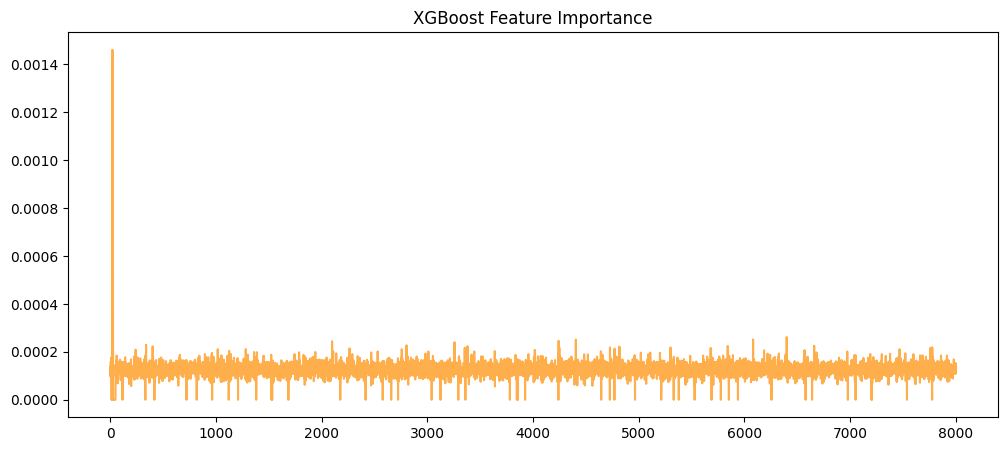

In [ ]:
import os
import json
import gc
import numpy as np
import comet_ml
import matplotlib.pyplot as plt
import joblib
from google.colab import userdata, drive
from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, precision_score, recall_score, f1_score
from sklearn.utils import resample

# ============================================================================
# 1. INITIALIZE & CONFIG
# ============================================================================
comet_api_key = userdata.get('comet_api_key')
experiment = comet_ml.Experiment(
    api_key=comet_api_key,
    project_name="audio-steganalysis-baselines"
)
experiment.set_name("XGBoost (Full Dataset - Logged)")

config = {
    "model_type": "XGBoost",
    "n_estimators": 1000,
    "learning_rate": 0.1,
    "max_depth": 6,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "tree_method": "hist",
    "random_state": 42
}
experiment.log_parameters(config)

# ============================================================================
# 2. SCALING & MEMORY MANAGEMENT
# ============================================================================
scaler = StandardScaler()
print("Scaling Data...")
X_train_scaled = scaler.fit_transform(X_train).astype(np.float32)
X_val_scaled = scaler.transform(X_val).astype(np.float32)
del X_train, X_val
gc.collect()

# ============================================================================
# 3. TRAINING
# ============================================================================
print(f"Training XGBoost for {config['n_estimators']} rounds...")

model = XGBClassifier(
    **config,
    objective='binary:logistic',
    eval_metric=['logloss', 'auc', 'error']
)

model.fit(
    X_train_scaled, y_train,
    eval_set=[(X_train_scaled, y_train), (X_val_scaled, y_val)],
    verbose=20
)

# SAVE STEP
SAVE_DIR = "/content/drive/MyDrive/IIT - University of Westminster Material/VStego800K dataset/Models/Comparison_Baselines"
os.makedirs(SAVE_DIR, exist_ok=True)
joblib.dump(model, os.path.join(SAVE_DIR, "xgboost_baseline.joblib"))
joblib.dump(scaler, os.path.join(SAVE_DIR, "scaler_xgboost.joblib"))

# ============================================================================
# 4. EVALUATION & COMPREHENSIVE LOGGING
# ============================================================================
y_prob = model.predict_proba(X_val_scaled)[:, 1]
y_pred = (y_prob >= 0.5).astype(int) # Standard threshold

# Calculate the full suite
acc = accuracy_score(y_val, y_pred)
auc = roc_auc_score(y_val, y_prob)
prec = precision_score(y_val, y_pred)
rec = recall_score(y_val, y_pred)
f1 = f1_score(y_val, y_pred)

# Log metrics to Comet for easy table comparison
experiment.log_metrics({
    "final_accuracy": acc,
    "final_auc": auc,
    "final_precision": prec,
    "final_recall": rec,
    "final_f1": f1
})

experiment.log_confusion_matrix(y_val, y_pred, title="Final XGBoost CM")

# Log internal history (Iteration-wise Accuracy and AUC)
results = model.evals_result()
for i in range(len(results['validation_0']['logloss'])):
    experiment.log_metrics({
        "train_acc_iter": 1 - results['validation_0']['error'][i],
        "val_acc_iter": 1 - results['validation_1']['error'][i],
        "val_auc_iter": results['validation_1']['auc'][i],
        "val_logloss": results['validation_1']['logloss'][i]
    }, step=i)

# 5. Feature Importance Plot
importances = model.feature_importances_
plt.figure(figsize=(12, 5))
plt.plot(importances, color='darkorange', alpha=0.7)
plt.title("XGBoost Feature Importance")
plt.savefig("xgb_feature_importance.png")
experiment.log_image("xgb_feature_importance.png")

print(f"\n--- Final XGBoost Report ---")
print(f"ACC: {acc:.4f} | AUC: {auc:.4f} | Precision: {prec:.4f} | Recall: {rec:.4f} | F1: {f1:.4f}")
print("\nDetailed Report:")
print(classification_report(y_val, y_pred))

experiment.end()

 XGBOOST - Run test extraction script first

In [ ]:
import os
import gc
import joblib
import numpy as np
import pandas as pd
import comet_ml
from tqdm import tqdm
from google.colab import drive, userdata
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

# ============================================================================
# 1. PATH DEFINITIONS & SETUP
# ============================================================================
drive.mount('/content/drive')

# Input Data Paths
TENSOR_DIR = "/content/test_processing/3channel_tensors"
TEST_EXCEL_PATH = "/content/drive/MyDrive/IIT - University of Westminster Material/VStego800K dataset/test/test_lable.xlsx"

# Model/Artifact Paths
SAVE_DIR = "/content/drive/MyDrive/IIT - University of Westminster Material/VStego800K dataset/Models/Comparison_Baselines"
MODEL_PATH = os.path.join(SAVE_DIR, "xgboost_baseline.joblib")
SCALER_PATH = os.path.join(SAVE_DIR, "scaler_xgboost.joblib")

# ============================================================================
# 2. METADATA & ADAPTER FUNCTIONS
# ============================================================================

def load_test_metadata_map(excel_path):
    print("\nLoading Test Set Metadata...")
    meta_map = {}
    xls = pd.ExcelFile(excel_path)
    stego_tabs = ["test_lable_english_CNV", "test_lable_english_PMS",
                  "test_lable_chinese_CNV", "test_lable_chinese_PMS"]
    for tab in stego_tabs:
        if tab not in xls.sheet_names: continue
        df = pd.read_excel(xls, sheet_name=tab)
        for _, row in df.iterrows():
            if pd.notna(row.iloc[0]):
                fname = str(row.iloc[0]).strip()
                raw_algo = str(row.iloc[1]).strip()
                algo = "CNV" if raw_algo == "QIM" else raw_algo
                try: rate = round(float(row.iloc[2]), 1)
                except: rate = 0.0
                meta_map[fname] = {'algo': algo, 'rate': rate}
    return meta_map

def extract_test_features_baseline(tensor_dir, meta_map, byte_limit=24000):
    X_test_baseline, y_test_baseline, metadata_list = [], [], []
    for sub in ['cover', 'stego']:
        current_dir = os.path.join(tensor_dir, sub)
        if not os.path.exists(current_dir): continue
        files = sorted([f for f in os.listdir(current_dir) if f.endswith('.npy')])
        is_stego = (sub == 'stego')
        print(f"Extracting {sub} features...")
        for fname in tqdm(files):
            matrix = np.load(os.path.join(current_dir, fname)).flatten()
            features = np.pad(matrix, (0, max(0, byte_limit - len(matrix))), 'constant')[:byte_limit]
            X_test_baseline.append(features)
            y_test_baseline.append(1 if is_stego else 0)
            base_name = fname.replace(".npy", "")
            info = meta_map.get(base_name, {'algo': 'Cover', 'rate': 0.0}) if is_stego else {'algo': 'Cover', 'rate': 0.0}
            metadata_list.append({'base_name': base_name, 'is_stego': is_stego, 'algo': info['algo'], 'rate': info['rate']})
    return np.array(X_test_baseline, dtype=np.float32), np.array(y_test_baseline), metadata_list

def evaluate_baseline_stratified(model, X, y, metadata_list, threshold=0.5):
    all_probs = model.predict_proba(X)[:, 1]
    all_preds = (all_probs >= threshold).astype(int)
    metadata_df = pd.DataFrame(metadata_list)
    results = {'overall': {
        'accuracy': accuracy_score(y, all_preds),
        'precision': precision_score(y, all_preds, zero_division=0),
        'recall': recall_score(y, all_preds, zero_division=0),
        'f1': f1_score(y, all_preds, zero_division=0),
        'auc': roc_auc_score(y, all_probs),
        'confusion_matrix': confusion_matrix(y, all_preds).tolist()},
        'per_algorithm': {}, 'per_payload': {}}

    for algo in ['CNV', 'PMS']:
        mask = ((metadata_df['algo'] == algo) | (~metadata_df['is_stego'])).values
        if mask.sum() > 0:
            results['per_algorithm'][algo] = {'n_samples': int(mask.sum()), 'acc': accuracy_score(y[mask], all_preds[mask]), 'auc': roc_auc_score(y[mask], all_probs[mask])}

    for rate in [0.1, 0.2, 0.3, 0.4]:
        mask = ((metadata_df['rate'] == rate) | (~metadata_df['is_stego'])).values
        if mask.sum() > 0:
            results['per_payload'][f'{rate:.1f}'] = {'n_samples': int(mask.sum()), 'acc': accuracy_score(y[mask], all_preds[mask]), 'auc': roc_auc_score(y[mask], all_probs[mask])}
    return results

def print_stratified_results(results):
    print("\n" + "="*80 + "\nSTRATIFIED TEST RESULTS\n" + "="*80)
    o = results['overall']
    print(f"OVERALL -> Acc: {o['accuracy']:.4f} | AUC: {o['auc']:.4f} | F1: {o['f1']:.4f}")
    print("\nPER-ALGORITHM:")
    for algo, m in results['per_algorithm'].items():
        print(f"{algo:<10} | N: {m['n_samples']:<6} | Acc: {m['acc']:.4f} | AUC: {m['auc']:.4f}")
    print("\nPER-PAYLOAD:")
    for rate, m in sorted(results['per_payload'].items()):
        print(f"Rate {rate:<5} | N: {m['n_samples']:<6} | Acc: {m['acc']:.4f} | AUC: {m['auc']:.4f}")

# ============================================================================
# 3. EXECUTION
# ============================================================================

# 1. Load Everything
global_test_meta = load_test_metadata_map(TEST_EXCEL_PATH)

# Count files to pre-allocate memory
all_test_files = []
for sub in ['cover', 'stego']:
    d = os.path.join(TENSOR_DIR, sub)
    if os.path.exists(d):
        all_test_files.extend([(os.path.join(d, f), sub == 'stego') for f in os.listdir(d) if f.endswith('.npy')])

num_test = len(all_test_files)
print(f"Total Test Samples: {num_test}")
X_test = np.zeros((num_test, 8000), dtype=np.float32)
y_test = np.zeros(num_test, dtype=np.int8)
metadata_list = []

print("Extracting Test Features...")
for i, (path, is_stego) in enumerate(tqdm(all_test_files)):
    matrix = np.load(path).flatten()
    # Ensure this limit matches the scaler's training (8000)
    feat_len = min(len(matrix), 8000)
    X_test[i, :feat_len] = matrix[:feat_len]
    y_test[i] = 1 if is_stego else 0

    # Metadata
    base_name = os.path.basename(path).replace(".npy", "")
    info = global_test_meta.get(base_name, {'algo': 'Cover', 'rate': 0.0}) if is_stego else {'algo': 'Cover', 'rate': 0.0}
    metadata_list.append({'base_name': base_name, 'is_stego': is_stego, 'algo': info['algo'], 'rate': info['rate']})

# Clear temporary list of paths
del all_test_files
gc.collect()

# ============================================================================
# 3. SCALING & PREDICTION
# ============================================================================
print("Loading Model & Scaler...")
model = joblib.load(os.path.join(SAVE_DIR, "xgboost_baseline.joblib"))
scaler = joblib.load(os.path.join(SAVE_DIR, "scaler_xgboost.joblib"))

print("Scaling and Predicting...")
X_test = scaler.transform(X_test) # Transform in-place
all_probs = model.predict_proba(X_test)[:, 1]
all_preds = (all_probs >= 0.5).astype(int)

# ============================================================================
# 4. STRATIFIED EVALUATION
# ============================================================================

xgb_test_results = evaluate_baseline_stratified(
    model=model,
    X=X_test,
    y=y_test,
    metadata_list=metadata_list,
    threshold=0.5
)

del X_test
gc.collect()

print_stratified_results(xgb_test_results)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

Loading Test Set Metadata...
Total Test Samples: 50000
Extracting Test Features...


100%|██████████| 50000/50000 [00:54<00:00, 915.27it/s] 


Loading Model & Scaler...
Scaling and Predicting...

STRATIFIED TEST RESULTS
OVERALL -> Acc: 0.5476 | AUC: 0.5687 | F1: 0.5476

PER-ALGORITHM:
CNV        | N: 37500  | Acc: 0.5616 | AUC: 0.5965
PMS        | N: 37500  | Acc: 0.5338 | AUC: 0.5409

PER-PAYLOAD:
Rate 0.1   | N: 31000  | Acc: 0.5386 | AUC: 0.5337
Rate 0.2   | N: 31500  | Acc: 0.5451 | AUC: 0.5568
Rate 0.3   | N: 31000  | Acc: 0.5502 | AUC: 0.5803
Rate 0.4   | N: 31500  | Acc: 0.5569 | AUC: 0.6023


#SimpleBitCNN baseline

In [ ]:
import os
import gc
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import pandas as pd
import comet_ml
from torch.utils.data import DataLoader, TensorDataset
from google.colab import drive, userdata
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Mount Drive and Init Comet
drive.mount('/content/drive')
comet_api_key = userdata.get('comet_api_key')
experiment = comet_ml.Experiment(api_key=comet_api_key, project_name="audio-steganalysis-baselines")
experiment.set_name("SimpleBitCNN (1D - 8000 bits)")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f" Running on: {device}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


COMET WARNING: As you are running in a Jupyter environment, you will need to call `experiment.end()` when finished to ensure all metrics and code are logged before exiting.
COMET INFO: Experiment is live on comet.com https://www.comet.com/maryam-sarah/audio-steganalysis-baselines/b76e783f4fcd43efa9883455486f4ab5



 Running on: cuda


In [ ]:
class SimpleBitCNN(nn.Module):
    def __init__(self):
        super(SimpleBitCNN, self).__init__()
        # Input shape: (Batch, 1, 8000)
        self.features = nn.Sequential(
            nn.Conv1d(1, 16, kernel_size=11, stride=2, padding=5),
            nn.BatchNorm1d(16),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=4, stride=4),

            nn.Conv1d(16, 32, kernel_size=7, stride=2, padding=3),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=4, stride=4),

            nn.Conv1d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1) # Global Average Pooling
        )

        self.classifier = nn.Sequential(
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(32, 1) # Binary Output
        )

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        x = self.classifier(x)
        return x

model = SimpleBitCNN().to(device)

In [ ]:
# --- ASSUMPTION: X_train, y_train, X_val, y_val are loaded and truncated to 8000 ---
# If not, use: X_train_cnn = torch.FloatTensor(X_train[:, :8000]).unsqueeze(1)

X_train_t = torch.FloatTensor(X_train[:, :8000]).unsqueeze(1)
y_train_t = torch.FloatTensor(y_train).view(-1, 1)
X_val_t = torch.FloatTensor(X_val[:, :8000]).unsqueeze(1)
y_val_t = torch.FloatTensor(y_val).view(-1, 1)

train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=128, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val_t, y_val_t), batch_size=128)

criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Training Loop
for epoch in range(20): # 20 epochs is usually enough for a baseline
    model.train()
    total_loss = 0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    # Validation
    model.eval()
    all_probs = []
    with torch.no_grad():
        for inputs, _ in val_loader:
            outputs = model(inputs.to(device))
            all_probs.extend(torch.sigmoid(outputs).cpu().numpy())

    val_auc = roc_auc_score(y_val, all_probs)
    print(f"Epoch {epoch+1:02d} | Loss: {total_loss/len(train_loader):.4f} | Val AUC: {val_auc:.4f}")
    experiment.log_metrics({"train_loss": total_loss/len(train_loader), "val_auc": val_auc}, step=epoch)

# SAVE STEP
SAVE_PATH = "/content/drive/MyDrive/IIT - University of Westminster Material/VStego800K dataset/Models/Comparison_Baselines/simple_bit_cnn.pth"
torch.save(model.state_dict(), SAVE_PATH)
print(f" Model saved to: {SAVE_PATH}")

Epoch 01 | Loss: 0.6922 | Val AUC: 0.5496
Epoch 02 | Loss: 0.6893 | Val AUC: 0.5576
Epoch 03 | Loss: 0.6869 | Val AUC: 0.5686
Epoch 04 | Loss: 0.6838 | Val AUC: 0.5712
Epoch 05 | Loss: 0.6815 | Val AUC: 0.5753
Epoch 06 | Loss: 0.6793 | Val AUC: 0.5758
Epoch 07 | Loss: 0.6765 | Val AUC: 0.5767
Epoch 08 | Loss: 0.6745 | Val AUC: 0.5795
Epoch 09 | Loss: 0.6728 | Val AUC: 0.5776
Epoch 10 | Loss: 0.6711 | Val AUC: 0.5786
Epoch 11 | Loss: 0.6697 | Val AUC: 0.5740
Epoch 12 | Loss: 0.6682 | Val AUC: 0.5739
Epoch 13 | Loss: 0.6667 | Val AUC: 0.5732
Epoch 14 | Loss: 0.6654 | Val AUC: 0.5773
Epoch 15 | Loss: 0.6637 | Val AUC: 0.5701
Epoch 16 | Loss: 0.6627 | Val AUC: 0.5711
Epoch 17 | Loss: 0.6617 | Val AUC: 0.5728
Epoch 18 | Loss: 0.6608 | Val AUC: 0.5737
Epoch 19 | Loss: 0.6594 | Val AUC: 0.5715
Epoch 20 | Loss: 0.6584 | Val AUC: 0.5664
 Model saved to: /content/drive/MyDrive/IIT - University of Westminster Material/VStego800K dataset/Models/Comparison_Baselines/simple_bit_cnn.pth


In [ ]:
import os
import gc
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
from tqdm import tqdm
from google.colab import drive
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# ============================================================================
# 1. SETUP & PATHS
# ============================================================================
drive.mount('/content/drive')
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Paths
TENSOR_DIR = "/content/test_processing/3channel_tensors"
TEST_EXCEL_PATH = "/content/drive/MyDrive/IIT - University of Westminster Material/VStego800K dataset/test/test_lable.xlsx"
MODEL_PATH = "/content/drive/MyDrive/IIT - University of Westminster Material/VStego800K dataset/Models/Comparison_Baselines/simple_bit_cnn.pth"

# ============================================================================
# 2. MODEL DEFINITION (Must match your training architecture)
# ============================================================================
class SimpleBitCNN(nn.Module):
    def __init__(self):
        super(SimpleBitCNN, self).__init__()
        self.features = nn.Sequential(
            nn.Conv1d(1, 16, kernel_size=11, stride=2, padding=5),
            nn.BatchNorm1d(16),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=4, stride=4),
            nn.Conv1d(16, 32, kernel_size=7, stride=2, padding=3),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=4, stride=4),
            nn.Conv1d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1)
        )
        self.classifier = nn.Sequential(
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        return self.classifier(x)

# Load Model
model = SimpleBitCNN().to(device)
model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
model.eval()
print(f" SimpleBitCNN Loaded from: {MODEL_PATH}")

# ============================================================================
# 3. METADATA & EXTRACTION (Channel 1 Only)
# ============================================================================
def load_test_metadata_map(excel_path):
    print("\nLoading Test Set Metadata...")
    meta_map = {}
    xls = pd.ExcelFile(excel_path)
    stego_tabs = ["test_lable_english_CNV", "test_lable_english_PMS",
                  "test_lable_chinese_CNV", "test_lable_chinese_PMS"]
    for tab in stego_tabs:
        if tab not in xls.sheet_names: continue
        df = pd.read_excel(xls, sheet_name=tab)
        for _, row in df.iterrows():
            if pd.notna(row.iloc[0]):
                fname = str(row.iloc[0]).strip()
                raw_algo = str(row.iloc[1]).strip()
                # Standardization: QIM is often labeled as CNV in research papers
                algo = "CNV" if raw_algo == "QIM" else raw_algo
                try: rate = round(float(row.iloc[2]), 1)
                except: rate = 0.0
                meta_map[fname] = {'algo': algo, 'rate': rate}
    return meta_map

global_test_meta = load_test_metadata_map(TEST_EXCEL_PATH)

# Prepare File List
all_test_files = []
for sub in ['cover', 'stego']:
    d = os.path.join(TENSOR_DIR, sub)
    if os.path.exists(d):
        all_test_files.extend([(os.path.join(d, f), sub == 'stego') for f in os.listdir(d) if f.endswith('.npy')])

num_test = len(all_test_files)
X_test = np.zeros((num_test, 1, 8000), dtype=np.float32)
y_test = np.zeros(num_test, dtype=np.int8)
metadata_list = []

print(f"Extracting Channel 1 (8,000 bits) for {num_test} samples...")
for i, (path, is_stego) in enumerate(tqdm(all_test_files)):
    matrix = np.load(path).flatten()
    # Take only the first 8000 bits (Channel 1)
    feat_len = min(len(matrix), 8000)
    X_test[i, 0, :feat_len] = matrix[:feat_len]
    y_test[i] = 1 if is_stego else 0

    base_name = os.path.basename(path).replace(".npy", "")
    info = global_test_meta.get(base_name, {'algo': 'Cover', 'rate': 0.0}) if is_stego else {'algo': 'Cover', 'rate': 0.0}
    metadata_list.append({'base_name': base_name, 'is_stego': is_stego, 'algo': info['algo'], 'rate': info['rate']})

test_loader = DataLoader(TensorDataset(torch.from_numpy(X_test), torch.from_numpy(y_test)), batch_size=256)

del X_test
gc.collect()

# ============================================================================
# 4. INFERENCE & EVALUATION
# ============================================================================
all_probs = []
print("Running Inference...")
with torch.no_grad():
    for inputs, _ in tqdm(test_loader):
        outputs = torch.sigmoid(model(inputs.to(device)))
        all_probs.extend(outputs.cpu().numpy().flatten())

all_probs = np.array(all_probs)
all_preds = (all_probs >= 0.5).astype(int)
metadata_df = pd.DataFrame(metadata_list)

def get_stratified_report(y_true, y_pred, y_prob, meta_df):
    results = {'overall': {
        'acc': accuracy_score(y_true, y_pred),
        'auc': roc_auc_score(y_true, y_prob),
        'f1': f1_score(y_true, y_pred, zero_division=0)},
        'algo': {}, 'payload': {}}

    for algo in ['CNV', 'PMS']:
        mask = ((meta_df['algo'] == algo) | (~meta_df['is_stego'])).values
        results['algo'][algo] = {'acc': accuracy_score(y_true[mask], y_pred[mask]), 'auc': roc_auc_score(y_true[mask], y_prob[mask])}

    for rate in [0.1, 0.2, 0.3, 0.4]:
        mask = ((meta_df['rate'] == rate) | (~meta_df['is_stego'])).values
        results['payload'][f'{rate:.1f}'] = {'acc': accuracy_score(y_true[mask], y_pred[mask]), 'auc': roc_auc_score(y_true[mask], y_prob[mask])}
    return results

cnn_results = get_stratified_report(y_test, all_preds, all_probs, metadata_df)

# ============================================================================
# 5. FINAL THESIS OUTPUT
# ============================================================================
print("\n" + "="*80 + "\nSIMPLE BITSTREAM CNN TEST RESULTS\n" + "="*80)
o = cnn_results['overall']
print(f"OVERALL -> Acc: {o['acc']:.4f} | AUC: {o['auc']:.4f} | F1: {o['f1']:.4f}")
print("\nPER-ALGORITHM (Acc / AUC):")
for k, v in cnn_results['algo'].items():
    print(f"{k:<10} -> {v['acc']:.4f} / {v['auc']:.4f}")
print("\nPER-PAYLOAD (Acc / AUC):")
for k, v in sorted(cnn_results['payload'].items()):
    print(f"Rate {k:<5} -> {v['acc']:.4f} / {v['auc']:.4f}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
 SimpleBitCNN Loaded from: /content/drive/MyDrive/IIT - University of Westminster Material/VStego800K dataset/Models/Comparison_Baselines/simple_bit_cnn.pth

Loading Test Set Metadata...
Extracting Channel 1 (8,000 bits) for 50000 samples...


100%|██████████| 50000/50000 [00:41<00:00, 1192.29it/s]


Running Inference...


100%|██████████| 196/196 [00:01<00:00, 99.26it/s] 



SIMPLE BITSTREAM CNN TEST RESULTS
OVERALL -> Acc: 0.5032 | AUC: 0.5968 | F1: 0.0164

PER-ALGORITHM (Acc / AUC):
CNV        -> 0.6700 / 0.6530
PMS        -> 0.6665 / 0.5406

PER-PAYLOAD (Acc / AUC):
Rate 0.1   -> 0.8054 / 0.5400
Rate 0.2   -> 0.7932 / 0.5810
Rate 0.3   -> 0.8068 / 0.6105
Rate 0.4   -> 0.7957 / 0.6524


#1D CNN - Baseline

In [ ]:
import os
import json
import random
import numpy as np
import torch
from datetime import datetime
from torch.utils.data import Dataset, ConcatDataset, Subset, DataLoader
from sklearn.model_selection import GroupShuffleSplit
import pandas as pd
import shutil
from tqdm import tqdm

# ============================================================================
# CONFIGURATION
# ============================================================================
BASE_DIR = "/content/dataset_local"

# ----------------------------------------------------------------------------
# Route the saved split indices directly to Google Drive
# ----------------------------------------------------------------------------
SOURCE_DIR = "/content/drive/MyDrive/IIT - University of Westminster Material/VStego800K dataset/split_indices_100k_samples"
os.makedirs(SOURCE_DIR, exist_ok=True)

# Directing the script to exact local folders
COVER_DIR = os.path.join(BASE_DIR, "cover")
STEGO_DIR = os.path.join(BASE_DIR, "stego")

# ----------------------------------------------------------------------------
# UPDATED: Direct path to the Excel file in Google Drive
# ----------------------------------------------------------------------------
EXCEL_PATH = "/content/drive/MyDrive/IIT - University of Westminster Material/VStego800K dataset/train_lable.xlsx"

SEED = 42
VAL_RATIO = 0.15
TEST_RATIO = 0.0
BATCH_SIZE = 128

# ============================================================================
# 1. DATASET CLASS
# ============================================================================
def load_excel_metadata(excel_path):
    print("Loading Excel metadata...")
    meta_map = {}
    if not os.path.exists(excel_path):
        print(f" [!] Excel file not found at {excel_path}. Metadata will be empty.")
        return meta_map

    xls = pd.ExcelFile(excel_path)
    tabs = ["train_lable_english_CNV", "train_lable_english_PMS",
            "train_lable_chinese_CNV", "train_lable_chinese_PMS"]

    for tab in tabs:
        if tab not in xls.sheet_names: continue
        current_algo = "CNV" if "CNV" in tab else "PMS"
        df = pd.read_excel(xls, sheet_name=tab)

        for _, row in df.iterrows():
            if pd.notna(row.iloc[0]):
                fname = str(row.iloc[0]).strip()
                try:
                    rate = round(float(row.iloc[2]), 1)
                except:
                    rate = 0.0
                meta_map[fname] = {'algo': current_algo, 'rate': rate}

    print(f" -> Loaded Excel metadata for {len(meta_map)} samples.")
    return meta_map

class MatrixDataset(Dataset):
    def __init__(self, data_folder, label, meta_map=None):
        self.data_folder = data_folder
        self.label = label

        # Grab all .npy files
        self.files = [f for f in os.listdir(data_folder) if f.endswith(".npy")]
        self.files = sorted(self.files)

        # Base names (e.g., 'Chinese112894.npy' -> 'Chinese112894')
        self.base_names = [f.replace(".npy", "") for f in self.files]

        # ---> METADATA TRACKING <---
        self.meta_map = meta_map or {}
        self.metadata = []
        for b in self.base_names:
            if b in self.meta_map:
                self.metadata.append(self.meta_map[b])
            else:
                self.metadata.append({'algo': 'Cover' if label == 0 else 'Unknown', 'rate': 0.0})

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        file_path = os.path.join(self.data_folder, self.files[idx])
        # Load the (3, 100, 80) float32 tensor
        matrix = np.load(file_path)

        # --- NEW: Reshape for 1D CNN (3, 100, 80) -> (3, 8000) ---
        matrix = matrix.reshape(3, 8000).astype(np.float32)

        tensor = torch.from_numpy(matrix)
        return tensor, torch.tensor(self.label, dtype=torch.float32).view(1) # Float for BCE loss

    def get_metadata(self, idx):
        return {
            'base_name': self.base_names[idx],
            'algo': self.metadata[idx]['algo'],
            'rate': self.metadata[idx]['rate'],
            'is_stego': self.label == 1
        }

def set_global_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    os.environ['PYTHONHASHSEED'] = str(seed)
    print(f" -> Global Seed locked to: {seed}")

# ============================================================================
# 2. GROUP-AWARE SPLIT FUNCTION (REMOVING TEST SPLIT)
# ============================================================================
def create_group_aware_splits(cover_dataset, stego_dataset,
                              val_ratio=0.15, test_ratio=0.0, seed=42,
                              save_indices=True, experiment_name="group_aware_matrices"):
    print("\nGenerating Forensic Group-Aware Splits (Train/Val only)...")

    # 1. Extract base names to form groups
    all_groups = np.array(cover_dataset.base_names + stego_dataset.base_names)
    all_indices = np.arange(len(all_groups))

    print(f"  Total Samples: {len(all_groups)}")
    print(f"  Unique Sources: {len(set(all_groups))}")

    # 2. Split Train vs Val (Now test_ratio is 0.0)
    gss = GroupShuffleSplit(n_splits=1, test_size=val_ratio, random_state=seed)
    train_idx, val_idx = next(gss.split(all_indices, groups=all_groups))

    # 3. Test index is empty as we use the official VStego800k Test Set
    test_idx = np.array([])

    # 4. Shuffle Indices
    np.random.shuffle(train_idx)
    np.random.shuffle(val_idx)

    # 5. Leakage Verification
    train_groups_set = set(all_groups[train_idx])
    val_groups_set = set(all_groups[val_idx])

    leakage_tv = train_groups_set.intersection(val_groups_set)

    if len(leakage_tv) > 0:
        raise ValueError(f"CRITICAL LEAKAGE DETECTED! Overlap: {len(leakage_tv)}")
    else:
        print("  LEAKAGE CHECK PASSED: 0 overlapping audio sources.")

    # 6. Create Datasets
    full_dataset = ConcatDataset([cover_dataset, stego_dataset])
    train_ds = Subset(full_dataset, train_idx)
    val_ds   = Subset(full_dataset, val_idx)
    test_ds  = Subset(full_dataset, test_idx) # This will be empty

    print(f"  Train: {len(train_ds)} | Val: {len(val_ds)} | Test (Local): {len(test_ds)}")

    # 7. Save Indices
    if save_indices:
        split_info = {
            "experiment_name": experiment_name,
            "timestamp": datetime.now().isoformat(),
            "random_seed": seed,
            "indices": {
                "train": train_idx.tolist(),
                "val": val_idx.tolist(),
                "test": test_idx.tolist()
            }
        }
        save_path = os.path.join(SOURCE_DIR, f"split_indices_{experiment_name}_seed{seed}.json")
        with open(save_path, 'w') as f:
            json.dump(split_info, f)
        print(f"  Split indices saved to: {save_path}")

    return train_ds, val_ds, test_ds

def load_split_indices(filepath, full_dataset):
    """
    Loads previously saved training/validation indices from a JSON file
    to ensure consistency across different sessions.
    """
    print(f"Loading split from: {filepath}")
    with open(filepath, 'r') as f:
        data = json.load(f)

    train_ds = Subset(full_dataset, data["indices"]["train"])
    val_ds   = Subset(full_dataset, data["indices"]["val"])
    test_ds  = Subset(full_dataset, data["indices"]["test"])

    return train_ds, val_ds, test_ds

# ============================================================================
# 3. MAIN EXECUTION (Updated for Optuna/Training workflow)
# ============================================================================
if __name__ == "__main__":
    print(f"{'='*50}\nDataset Preparation Pipeline (85/15 Split)\n{'='*50}")
    set_global_seed(SEED)

    global_meta_map = load_excel_metadata(EXCEL_PATH)

    print("\nLoading datasets...")
    cover_dataset = MatrixDataset(data_folder=COVER_DIR, label=0)
    stego_dataset = MatrixDataset(data_folder=STEGO_DIR, label=1, meta_map=global_meta_map)

    full_dataset = ConcatDataset([cover_dataset, stego_dataset])

    # Important: Rename experiment if want to keep old splits separate
    EXPERIMENT_NAME = "stego-detection-3channel"
    SPLIT_FILE = os.path.join(SOURCE_DIR, f"split_indices_{EXPERIMENT_NAME}_seed{SEED}.json")

    if os.path.exists(SPLIT_FILE):
        print("\nFound existing split file. Loading...")
        train_dataset, val_dataset, test_dataset = load_split_indices(SPLIT_FILE, full_dataset)
    else:
        print("\nCreating NEW group-aware split (No local test set)...")
        train_dataset, val_dataset, test_dataset = create_group_aware_splits(
            cover_dataset, stego_dataset,
            val_ratio=VAL_RATIO, test_ratio=0.0, seed=SEED,
            save_indices=True, experiment_name=EXPERIMENT_NAME
        )

    # Note: test_loader is still created but will be empty/unused locally.
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
    val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

    print(f"\n Pipeline Ready. Using {len(train_dataset)} for training and {len(val_dataset)} for validation.")

    # Verification Print
    x, y = next(iter(train_loader))
    print(f"Batch Shape: {x.shape} -> [Batch, Channels, Frames, Bits]")
    print(f"Labels Shape: {y.shape}")

Dataset Preparation Pipeline (85/15 Split)
 -> Global Seed locked to: 42
Loading Excel metadata...
 -> Loaded Excel metadata for 382296 samples.

Loading datasets...

Found existing split file. Loading...
Loading split from: /content/drive/MyDrive/IIT - University of Westminster Material/VStego800K dataset/split_indices_100k_samples/split_indices_stego-detection-3channel_seed42.json

 Pipeline Ready. Using 84984 for training and 14998 for validation.
Batch Shape: torch.Size([128, 3, 8000]) -> [Batch, Channels, Frames, Bits]
Labels Shape: torch.Size([128, 1])


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import gc  # Essential for clearing RAM between runs

class MultiChannelBitCNN(nn.Module):
    def __init__(self):
        super(MultiChannelBitCNN, self).__init__()
        # Input: (Batch, 3 Channels, 8000 bits)
        self.features = nn.Sequential(
            nn.Conv1d(3, 32, kernel_size=11, stride=2, padding=5),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.MaxPool1d(4),

            nn.Conv1d(32, 64, kernel_size=7, stride=2, padding=3),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(4),

            nn.Conv1d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1) # Condenses 8000 bits down to 1 feature map
        )
        self.classifier = nn.Sequential(
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(64, 1) # Binary output
        )

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        return self.classifier(x)

In [ ]:
import os
import gc
import json
import psutil
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import pandas as pd
import comet_ml
from tqdm import tqdm
from torch.utils.data import DataLoader, Dataset, TensorDataset, Subset, ConcatDataset
from sklearn.metrics import accuracy_score, roc_auc_score, precision_score, recall_score, f1_score, classification_report
from sklearn.model_selection import GroupShuffleSplit
import joblib

# ============================================================================
# 1. INITIALIZE COMET & HYPERPARAMS
# ============================================================================
comet_api_key = userdata.get('comet_api_key')
experiment = comet_ml.Experiment(
    api_key=comet_api_key,
    project_name="audio-steganalysis-baselines"
)
experiment.set_name("MultiChannel-1D-CNN (Strong Baseline)")

config = {
    "model_type": "1D-CNN",
    "learning_rate": 0.0005,
    "batch_size": 128,
    "epochs": 20,
    "channels": 3,
    "input_len": 8000,
    "device": str(device)
}
experiment.log_parameters(config)

# ============================================================================
# 2. MODEL, OPTIMIZER, CRITERION
# ============================================================================
model = MultiChannelBitCNN().to(device)
optimizer = optim.Adam(model.parameters(), lr=config["learning_rate"])
criterion = nn.BCEWithLogitsLoss()

print(f" Starting 3-Channel CNN Training for {config['epochs']} epochs...")

# ============================================================================
# 3. TRAINING LOOP
# ============================================================================
for epoch in range(config["epochs"]):
    model.train()
    epoch_loss = 0

    # tqdm adds the progress bar you had in earlier scripts
    for inputs, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{config['epochs']}"):
        inputs, labels = inputs.to(device), labels.to(device).float().view(-1, 1)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    # --- VALIDATION PHASE ---
    model.eval()
    all_probs = []
    all_targets = []

    with torch.no_grad():
        for inputs, labels in val_loader:
            outputs = torch.sigmoid(model(inputs.to(device)))
            all_probs.extend(outputs.cpu().numpy().flatten())
            all_targets.extend(labels.numpy().flatten())

    # Calculate Standardized Metrics
    all_probs = np.array(all_probs)
    all_targets = np.array(all_targets)
    all_preds = (all_probs >= 0.5).astype(int)

    val_auc = roc_auc_score(all_targets, all_probs)
    val_acc = accuracy_score(all_targets, all_preds)
    val_f1 = f1_score(all_targets, all_preds, zero_division=0)
    val_prec = precision_score(all_targets, all_preds, zero_division=0)
    val_rec = recall_score(all_targets, all_preds, zero_division=0)

    # Log metrics to Comet (Matches your other scripts)
    experiment.log_metrics({
        "loss": epoch_loss / len(train_loader),
        "val_auc": val_auc,
        "val_accuracy": val_acc,
        "val_f1": val_f1,
        "val_precision": val_prec,
        "val_recall": val_rec
    }, step=epoch)

    print(f" -> [Epoch {epoch+1:02d}] Loss: {epoch_loss/len(train_loader):.4f} | AUC: {val_auc:.4f} | Acc: {val_acc:.4f} | F1: {val_f1:.4f}")

# ============================================================================
# 4. FINAL EVALUATION & SAVE
# ============================================================================
experiment.log_confusion_matrix(all_targets, all_preds, title="Final CNN Confusion Matrix")

SAVE_PATH = "/content/drive/MyDrive/IIT - University of Westminster Material/VStego800K dataset/Models/Comparison_Baselines/strong_3channel_cnn.pth"
torch.save(model.state_dict(), SAVE_PATH)

print(f"\n Strong Baseline Saved to: {SAVE_PATH}")
print(classification_report(all_targets, all_preds))

experiment.end()

COMET WARNING: To get all data logged automatically, import comet_ml before the following modules: torch, sklearn.
COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO: Comet.ml Experiment Summary
COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO:   Data:
COMET INFO:     display_summary_level : 1
COMET INFO:     name                  : MultiChannel-1D-CNN (Strong Baseline)
COMET INFO:     url                   : https://www.comet.com/maryam-sarah/audio-steganalysis-baselines/178f7e0bb1314496b3bb7696f68b8bc3
COMET INFO:   Others:
COMET INFO:     Name         : MultiChannel-1D-CNN (Strong Baseline)
COMET INFO:     notebook_url : https://colab.research.google.com/notebook#fileId=15DVhh97Z6qjPf3lCb5j5QROL1SEKBJDE
COMET INFO:   Parameters:
COMET INFO:     batch_size    : 128
COMET INFO:     channels      : 3
COMET INFO:     device        : cuda
COMET INFO:     epochs       

 Starting 3-Channel CNN Training for 20 epochs...


Epoch 1/20: 100%|██████████| 664/664 [01:44<00:00,  6.35it/s]


 -> [Epoch 01] Loss: 0.6921 | AUC: 0.5520 | Acc: 0.5220 | F1: 0.6515


Epoch 2/20: 100%|██████████| 664/664 [01:38<00:00,  6.77it/s]


...

Epoch 20/20: 100%|██████████| 664/664 [01:20<00:00,  8.27it/s]
COMET WARNING: Invalid y_true value np.float32(0.0), ignoring it
COMET WARNING: Invalid y_true value np.float32(0.0), ignoring it
COMET WARNING: Invalid y_true value np.float32(1.0), ignoring it
COMET WARNING: Invalid y_true value np.float32(1.0), ignoring it
COMET WARNING: Invalid y_true value np.float32(1.0), ignoring it
COMET WARNING: Invalid y_true value np.float32(0.0), ignoring it
COMET WARNING: Invalid y_true value np.float32(0.0), ignoring it
COMET WARNING: Invalid y_true value np.float32(0.0), ignoring it
COMET WARNING: Invalid y_true value np.float32(0.0), ignoring it
COMET WARNING: Invalid y_true value np.float32(0.0), ignoring it
COMET WARNING: Invalid y_true value np.float32(1.0), ignoring it
COMET WARNING: Invalid y_true value np.float32(0.0), ignoring it
COMET WARNING: Invalid y_true value np.float32(1.0), ignoring it
COMET WARNING: Invalid y_true value np.float32(0.0), ignoring it
COMET WARNING: Invalid y_tr

 -> [Epoch 20] Loss: 0.5762 | AUC: 0.5753 | Acc: 0.5510 | F1: 0.5151


Streaming output truncated to the last 5000 lines.
COMET WARNING: Invalid y_true value np.float32(0.0), ignoring it
COMET WARNING: Invalid y_true value np.float32(0.0), ignoring it
COMET WARNING: Invalid y_true value np.float32(1.0), ignoring it
COMET WARNING: Invalid y_true value np.float32(1.0), ignoring it
COMET WARNING: Invalid y_true value np.float32(0.0), ignoring it
COMET WARNING: Invalid y_true value np.float32(1.0), ignoring it
COMET WARNING: Invalid y_true value np.float32(0.0), ignoring it
COMET WARNING: Invalid y_true value np.float32(1.0), ignoring it
COMET WARNING: Invalid y_true value np.float32(1.0), ignoring it
COMET WARNING: Invalid y_true value np.float32(1.0), ignoring it
COMET WARNING: Invalid y_true value np.float32(0.0), ignoring it
COMET WARNING: Invalid y_true value np.float32(0.0), ignoring it
COMET WARNING: Invalid y_true value np.float32(1.0), ignoring it
COMET WARNING: Invalid y_true value np.float32(1.0), ignoring it
COMET WARNING: Invalid y_true value np.


 Strong Baseline Saved to: /content/drive/MyDrive/IIT - University of Westminster Material/VStego800K dataset/Models/Comparison_Baselines/strong_3channel_cnn.pth
              precision    recall  f1-score   support

         0.0       0.54      0.63      0.58      7499
         1.0       0.56      0.48      0.52      7499

    accuracy                           0.55     14998
   macro avg       0.55      0.55      0.55     14998
weighted avg       0.55      0.55      0.55     14998



COMET WARNING: Couldn't retrieve and log Google Colab notebook content, reason: 'NoneType' object is not subscriptable
COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO: Comet.ml Experiment Summary
COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO:   Data:
COMET INFO:     display_summary_level : 1
COMET INFO:     name                  : MultiChannel-1D-CNN (Strong Baseline)
COMET INFO:     url                   : https://www.comet.com/maryam-sarah/audio-steganalysis-baselines/e47f1e57a3bb429bb0adffcf675a6dbe
COMET INFO:   Metrics [count] (min, max):
COMET INFO:     loss [20]          : (0.5761707368116062, 0.692132546420557)
COMET INFO:     val_accuracy [20]  : (0.5, 0.5600080010668089)
COMET INFO:     val_auc [20]       : (0.5519810962571157, 0.5949927252601988)
COMET INFO:     val_f1 [20]        : (0.018989845707503627, 0.6666666666666666)
COMET INFO:     val_prec

In [ ]:
import os
import gc
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
from tqdm import tqdm
from google.colab import drive
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

# ============================================================================
# 1. SETUP & PATHS
# ============================================================================
drive.mount('/content/drive')
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Paths
TENSOR_DIR = "/content/test_processing/3channel_tensors"
TEST_EXCEL_PATH = "/content/drive/MyDrive/IIT - University of Westminster Material/VStego800K dataset/test/test_lable.xlsx"
MODEL_PATH = "/content/drive/MyDrive/IIT - University of Westminster Material/VStego800K dataset/Models/Comparison_Baselines/strong_3channel_cnn.pth"

# ============================================================================
# 2. LOAD METADATA & MODEL
# ============================================================================

def load_test_metadata_map(excel_path):
    print("\nLoading Test Set Metadata...")
    meta_map = {}
    xls = pd.ExcelFile(excel_path)
    stego_tabs = ["test_lable_english_CNV", "test_lable_english_PMS",
                  "test_lable_chinese_CNV", "test_lable_chinese_PMS"]
    for tab in stego_tabs:
        if tab not in xls.sheet_names: continue
        df = pd.read_excel(xls, sheet_name=tab)
        for _, row in df.iterrows():
            if pd.notna(row.iloc[0]):
                fname = str(row.iloc[0]).strip()
                raw_algo = str(row.iloc[1]).strip()
                algo = "CNV" if raw_algo == "QIM" else raw_algo
                try: rate = round(float(row.iloc[2]), 1)
                except: rate = 0.0
                meta_map[fname] = {'algo': algo, 'rate': rate}
    return meta_map

# Re-initialize the model structure
model = MultiChannelBitCNN().to(device)
model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
model.eval()
print(f" Model loaded from: {MODEL_PATH}")

# ============================================================================
# 3. EXTRACTION (3-Channel Reshaping)
# ============================================================================
global_test_meta = load_test_metadata_map(TEST_EXCEL_PATH)

all_test_files = []
for sub in ['cover', 'stego']:
    d = os.path.join(TENSOR_DIR, sub)
    if os.path.exists(d):
        all_test_files.extend([(os.path.join(d, f), sub == 'stego') for f in os.listdir(d) if f.endswith('.npy')])

num_test = len(all_test_files)
print(f"Total Test Samples: {num_test}")

# Pre-allocate for 3 channels (N, 3, 8000)
X_test = np.zeros((num_test, 3, 8000), dtype=np.float32)
y_test = np.zeros(num_test, dtype=np.int8)
metadata_list = []

print("Extracting & Reshaping Test Tensors...")
for i, (path, is_stego) in enumerate(tqdm(all_test_files)):
    # Reshape (3, 100, 80) -> (3, 8000)
    matrix = np.load(path).reshape(3, 8000)
    X_test[i] = matrix
    y_test[i] = 1 if is_stego else 0

    base_name = os.path.basename(path).replace(".npy", "")
    info = global_test_meta.get(base_name, {'algo': 'Cover', 'rate': 0.0}) if is_stego else {'algo': 'Cover', 'rate': 0.0}
    metadata_list.append({'base_name': base_name, 'is_stego': is_stego, 'algo': info['algo'], 'rate': info['rate']})

# Create DataLoader for Batch Inference (Prevents GPU OOM)
test_loader = DataLoader(TensorDataset(torch.from_numpy(X_test), torch.from_numpy(y_test)), batch_size=256)

del X_test
gc.collect()

# ============================================================================
# 4. INFERENCE & STRATIFIED EVALUATION
# ============================================================================
all_probs = []
print("Running Inference on GPU...")
with torch.no_grad():
    for inputs, _ in tqdm(test_loader):
        outputs = torch.sigmoid(model(inputs.to(device)))
        all_probs.extend(outputs.cpu().numpy().flatten())

all_probs = np.array(all_probs)
all_preds = (all_probs >= 0.5).astype(int)
metadata_df = pd.DataFrame(metadata_list)

def get_stratified_report(y_true, y_pred, y_prob, meta_df):
    results = {'overall': {
        'acc': accuracy_score(y_true, y_pred),
        'auc': roc_auc_score(y_true, y_prob),
        'f1': f1_score(y_true, y_pred, zero_division=0)},
        'algo': {}, 'payload': {}}

    for algo in ['CNV', 'PMS']:
        mask = ((meta_df['algo'] == algo) | (~meta_df['is_stego'])).values
        results['algo'][algo] = {'acc': accuracy_score(y_true[mask], y_pred[mask]), 'auc': roc_auc_score(y_true[mask], y_prob[mask])}

    for rate in [0.1, 0.2, 0.3, 0.4]:
        mask = ((meta_df['rate'] == rate) | (~meta_df['is_stego'])).values
        results['payload'][f'{rate:.1f}'] = {'acc': accuracy_score(y_true[mask], y_pred[mask]), 'auc': roc_auc_score(y_true[mask], y_prob[mask])}
    return results

cnn_results = get_stratified_report(y_test, all_preds, all_probs, metadata_df)

# ============================================================================
# 5. PRINT THE THESIS TABLE
# ============================================================================
print("\n" + "="*80 + "\nSTRONG CNN STRATIFIED TEST RESULTS\n" + "="*80)
o = cnn_results['overall']
print(f"OVERALL -> Acc: {o['acc']:.4f} | AUC: {o['auc']:.4f} | F1: {o['f1']:.4f}")
print("\nPER-ALGORITHM (Acc / AUC):")
for k, v in cnn_results['algo'].items():
    print(f"{k:<10} -> {v['acc']:.4f} / {v['auc']:.4f}")
print("\nPER-PAYLOAD (Acc / AUC):")
for k, v in sorted(cnn_results['payload'].items()):
    print(f"Rate {k:<5} -> {v['acc']:.4f} / {v['auc']:.4f}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Model loaded from: /content/drive/MyDrive/IIT - University of Westminster Material/VStego800K dataset/Models/Comparison_Baselines/strong_3channel_cnn.pth

Loading Test Set Metadata...
Total Test Samples: 50000
Extracting & Reshaping Test Tensors...


100%|██████████| 50000/50000 [01:24<00:00, 594.64it/s]


Running Inference on GPU...


100%|██████████| 196/196 [00:05<00:00, 36.28it/s]



STRONG CNN STRATIFIED TEST RESULTS
OVERALL -> Acc: 0.5944 | AUC: 0.6363 | F1: 0.5787

PER-ALGORITHM (Acc / AUC):
CNV        -> 0.6489 / 0.7300
PMS        -> 0.5649 / 0.5426

PER-PAYLOAD (Acc / AUC):
Rate 0.1   -> 0.6006 / 0.5681
Rate 0.2   -> 0.6131 / 0.6247
Rate 0.3   -> 0.6223 / 0.6575
Rate 0.4   -> 0.6313 / 0.6912


#BASELINE COMPARISON


MASTER BASELINE COMPARISON TABLE


,Model,Accuracy,AUC,F1-Score
5,Strong 1D-CNN,0.594400,0.636300,0.578700
4,Simple BitCNN,0.503200,0.596800,0.016400
3,XGBoost,0.547600,0.568700,0.547600
0,LogReg,0.520200,0.529200,0.515000
2,Random Forest,0.517100,0.522400,0.505600
1,SVM,0.518100,0.518800,0.527700


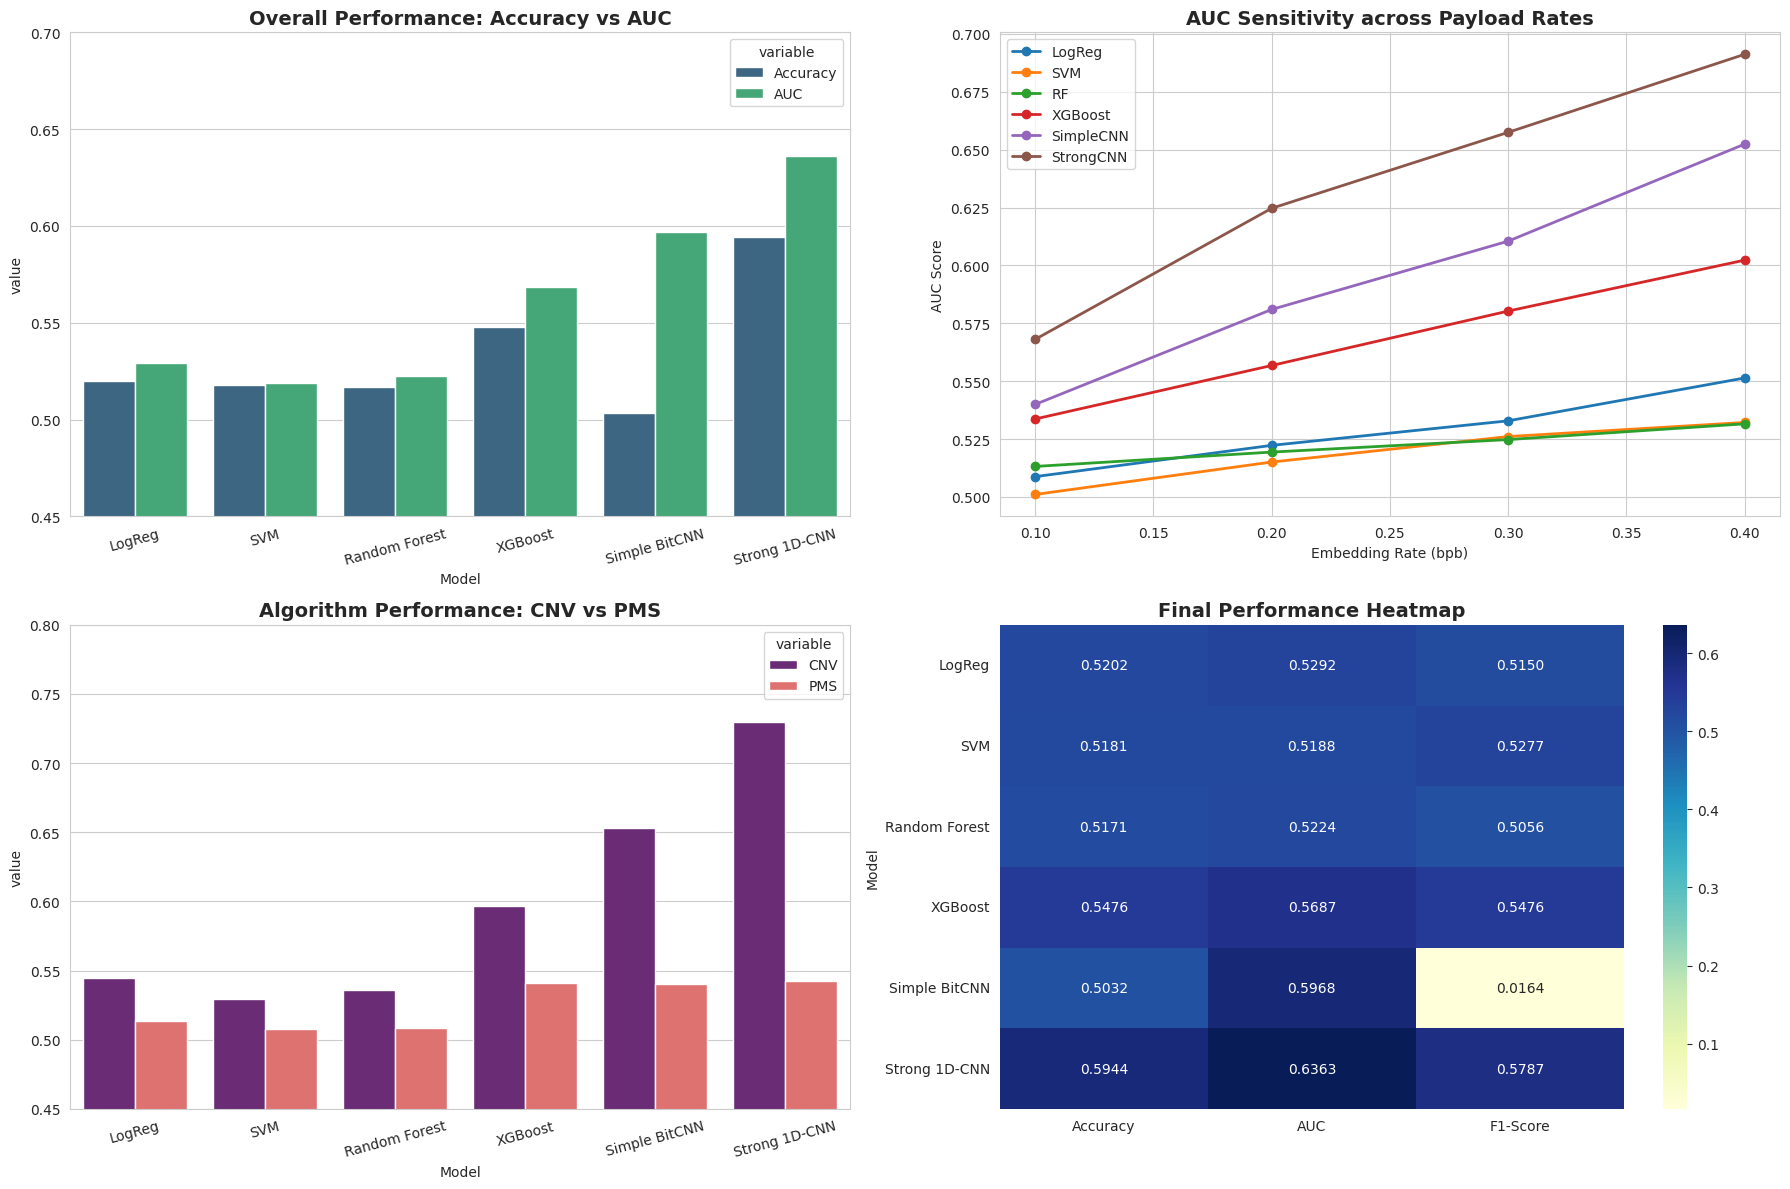

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ============================================================================
# 1. CONSOLIDATE DATA
# ============================================================================
models = ["LogReg", "SVM", "Random Forest", "XGBoost", "Simple BitCNN", "Strong 1D-CNN"]

# Overall Metrics
overall_data = {
    "Model": models,
    "Accuracy": [0.5202, 0.5181, 0.5171, 0.5476, 0.5032, 0.5944],
    "AUC":      [0.5292, 0.5188, 0.5224, 0.5687, 0.5968, 0.6363],
    "F1-Score": [0.5150, 0.5277, 0.5056, 0.5476, 0.0164, 0.5787]
}

# Per-Algorithm AUC (The key metric for forensic robustness)
algo_auc = {
    "Model": models,
    "CNV": [0.5448, 0.5295, 0.5361, 0.5965, 0.6530, 0.7300],
    "PMS": [0.5136, 0.5081, 0.5087, 0.5409, 0.5406, 0.5426]
}

# Per-Payload AUC (Detectability across embedding rates)
payload_auc = {
    "Rate": [0.1, 0.2, 0.3, 0.4],
    "LogReg": [0.5088, 0.5223, 0.5329, 0.5514],
    "SVM":    [0.5011, 0.5151, 0.5261, 0.5322],
    "RF":     [0.5132, 0.5194, 0.5248, 0.5316],
    "XGBoost":[0.5337, 0.5568, 0.5803, 0.6023],
    "SimpleCNN":[0.5400, 0.5810, 0.6105, 0.6524],
    "StrongCNN":[0.5681, 0.6247, 0.6575, 0.6912]
}

# Convert to DataFrames
df_overall = pd.DataFrame(overall_data)
df_algo = pd.DataFrame(algo_auc)
df_payload = pd.DataFrame(payload_auc)

# ============================================================================
# 2. GENERATE MASTER TABLE
# ============================================================================
print("\n" + "="*50)
print("MASTER BASELINE COMPARISON TABLE")
print("="*50)
display(df_overall.sort_values(by="AUC", ascending=False).style.background_gradient(cmap='Greens'))

# ============================================================================
# 3. VISUALIZATIONS
# ============================================================================
plt.figure(figsize=(18, 12))
sns.set_style("whitegrid")

# Graph 1: Overall AUC vs Accuracy Comparison
plt.subplot(2, 2, 1)
df_melted = df_overall.melt(id_vars="Model", value_vars=["Accuracy", "AUC"])
sns.barplot(data=df_melted, x="Model", y="value", hue="variable", palette="viridis")
plt.title("Overall Performance: Accuracy vs AUC", fontsize=14, fontweight='bold')
plt.ylim(0.45, 0.70)
plt.xticks(rotation=15)

# Graph 2: AUC Performance by Embedding Rate (Line Graph)
plt.subplot(2, 2, 2)
for model in ["LogReg", "SVM", "RF", "XGBoost", "SimpleCNN", "StrongCNN"]:
    plt.plot(df_payload["Rate"], df_payload[model], marker='o', label=model, linewidth=2)
plt.title("AUC Sensitivity across Payload Rates", fontsize=14, fontweight='bold')
plt.xlabel("Embedding Rate (bpb)")
plt.ylabel("AUC Score")
plt.legend()

# Graph 3: Model Robustness (CNV vs PMS Algorithms)
plt.subplot(2, 2, 3)
df_algo_melted = df_algo.melt(id_vars="Model", value_vars=["CNV", "PMS"])
sns.barplot(data=df_algo_melted, x="Model", y="value", hue="variable", palette="magma")
plt.title("Algorithm Performance: CNV vs PMS", fontsize=14, fontweight='bold')
plt.ylim(0.45, 0.80)
plt.xticks(rotation=15)

# Graph 4: The 'Winning' Model Heatmap
plt.subplot(2, 2, 4)
heatmap_data = df_overall.set_index("Model")[["Accuracy", "AUC", "F1-Score"]]
sns.heatmap(heatmap_data, annot=True, cmap="YlGnBu", fmt=".4f")
plt.title("Final Performance Heatmap", fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

#====================================================================================================

#ABLATION STUDY

Dataset script

In [ ]:
import os
import json
import random
import numpy as np
import torch
from datetime import datetime
from torch.utils.data import Dataset, ConcatDataset, Subset, DataLoader
from sklearn.model_selection import GroupShuffleSplit
import pandas as pd
import shutil
from tqdm import tqdm

# ============================================================================
# CONFIGURATION
# ============================================================================
BASE_DIR = "/content/dataset_local"

# ----------------------------------------------------------------------------
# Route the saved split indices directly to Google Drive
# ----------------------------------------------------------------------------
SOURCE_DIR = "/content/drive/MyDrive/IIT - University of Westminster Material/VStego800K dataset/split_indices_100k_samples"
os.makedirs(SOURCE_DIR, exist_ok=True)

# Directing the script to exact local folders
COVER_DIR = os.path.join(BASE_DIR, "cover")
STEGO_DIR = os.path.join(BASE_DIR, "stego")

# ----------------------------------------------------------------------------
# UPDATED: Direct path to the Excel file in Google Drive
# ----------------------------------------------------------------------------
EXCEL_PATH = "/content/drive/MyDrive/IIT - University of Westminster Material/VStego800K dataset/train_lable.xlsx"

SEED = 42
VAL_RATIO = 0.15
TEST_RATIO = 0.0
BATCH_SIZE = 128

# ============================================================================
# 1. DATASET CLASS
# ============================================================================
def load_excel_metadata(excel_path):
    print("Loading Excel metadata...")
    meta_map = {}
    if not os.path.exists(excel_path):
        print(f" [!] Excel file not found at {excel_path}. Metadata will be empty.")
        return meta_map

    xls = pd.ExcelFile(excel_path)
    tabs = ["train_lable_english_CNV", "train_lable_english_PMS",
            "train_lable_chinese_CNV", "train_lable_chinese_PMS"]

    for tab in tabs:
        if tab not in xls.sheet_names: continue
        current_algo = "CNV" if "CNV" in tab else "PMS"
        df = pd.read_excel(xls, sheet_name=tab)

        for _, row in df.iterrows():
            if pd.notna(row.iloc[0]):
                fname = str(row.iloc[0]).strip()
                try:
                    rate = round(float(row.iloc[2]), 1)
                except:
                    rate = 0.0
                meta_map[fname] = {'algo': current_algo, 'rate': rate}

    print(f" -> Loaded Excel metadata for {len(meta_map)} samples.")
    return meta_map

class MatrixDataset(Dataset):
    def __init__(self, data_folder, label, meta_map=None):
        self.data_folder = data_folder
        self.label = label

        # Grab all .npy files
        self.files = [f for f in os.listdir(data_folder) if f.endswith(".npy")]
        self.files = sorted(self.files)

        # Base names (e.g., 'Chinese112894.npy' -> 'Chinese112894')
        self.base_names = [f.replace(".npy", "") for f in self.files]

        # ---> METADATA TRACKING <---
        self.meta_map = meta_map or {}
        self.metadata = []
        for b in self.base_names:
            if b in self.meta_map:
                self.metadata.append(self.meta_map[b])
            else:
                self.metadata.append({'algo': 'Cover' if label == 0 else 'Unknown', 'rate': 0.0})

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        file_path = os.path.join(self.data_folder, self.files[idx])
        # Load the (3, 100, 80) float32 tensor
        matrix = np.load(file_path)
        tensor = torch.from_numpy(matrix)

        return tensor, torch.tensor(self.label, dtype=torch.long)

    def get_metadata(self, idx):
        return {
            'base_name': self.base_names[idx],
            'algo': self.metadata[idx]['algo'],
            'rate': self.metadata[idx]['rate'],
            'is_stego': self.label == 1
        }

def set_global_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    os.environ['PYTHONHASHSEED'] = str(seed)
    print(f" -> Global Seed locked to: {seed}")

# ============================================================================
# 2. GROUP-AWARE SPLIT FUNCTION (REMOVING TEST SPLIT)
# ============================================================================
def create_group_aware_splits(cover_dataset, stego_dataset,
                              val_ratio=0.15, test_ratio=0.0, seed=42,
                              save_indices=True, experiment_name="group_aware_matrices"):
    print("\nGenerating Forensic Group-Aware Splits (Train/Val only)...")

    # 1. Extract base names to form groups
    all_groups = np.array(cover_dataset.base_names + stego_dataset.base_names)
    all_indices = np.arange(len(all_groups))

    print(f"  Total Samples: {len(all_groups)}")
    print(f"  Unique Sources: {len(set(all_groups))}")

    # 2. Split Train vs Val (Now test_ratio is 0.0)
    gss = GroupShuffleSplit(n_splits=1, test_size=val_ratio, random_state=seed)
    train_idx, val_idx = next(gss.split(all_indices, groups=all_groups))

    # 3. Test index is empty as we use the official VStego800k Test Set
    test_idx = np.array([])

    # 4. Shuffle Indices
    np.random.shuffle(train_idx)
    np.random.shuffle(val_idx)

    # 5. Leakage Verification
    train_groups_set = set(all_groups[train_idx])
    val_groups_set = set(all_groups[val_idx])

    leakage_tv = train_groups_set.intersection(val_groups_set)

    if len(leakage_tv) > 0:
        raise ValueError(f"CRITICAL LEAKAGE DETECTED! Overlap: {len(leakage_tv)}")
    else:
        print("  LEAKAGE CHECK PASSED: 0 overlapping audio sources.")

    # 6. Create Datasets
    full_dataset = ConcatDataset([cover_dataset, stego_dataset])
    train_ds = Subset(full_dataset, train_idx)
    val_ds   = Subset(full_dataset, val_idx)
    test_ds  = Subset(full_dataset, test_idx) # This will be empty

    print(f"  Train: {len(train_ds)} | Val: {len(val_ds)} | Test (Local): {len(test_ds)}")

    # 7. Save Indices
    if save_indices:
        split_info = {
            "experiment_name": experiment_name,
            "timestamp": datetime.now().isoformat(),
            "random_seed": seed,
            "indices": {
                "train": train_idx.tolist(),
                "val": val_idx.tolist(),
                "test": test_idx.tolist()
            }
        }
        save_path = os.path.join(SOURCE_DIR, f"split_indices_{experiment_name}_seed{seed}.json")
        with open(save_path, 'w') as f:
            json.dump(split_info, f)
        print(f"  Split indices saved to: {save_path}")

    return train_ds, val_ds, test_ds

def load_split_indices(filepath, full_dataset):
    """
    Loads previously saved training/validation indices from a JSON file
    to ensure consistency across different sessions.
    """
    print(f"Loading split from: {filepath}")
    with open(filepath, 'r') as f:
        data = json.load(f)

    train_ds = Subset(full_dataset, data["indices"]["train"])
    val_ds   = Subset(full_dataset, data["indices"]["val"])
    test_ds  = Subset(full_dataset, data["indices"]["test"])

    return train_ds, val_ds, test_ds

# ============================================================================
# 3. MAIN EXECUTION (Updated for Optuna/Training workflow)
# ============================================================================
if __name__ == "__main__":
    print(f"{'='*50}\nDataset Preparation Pipeline (85/15 Split)\n{'='*50}")
    set_global_seed(SEED)

    global_meta_map = load_excel_metadata(EXCEL_PATH)

    print("\nLoading datasets...")
    cover_dataset = MatrixDataset(data_folder=COVER_DIR, label=0)
    stego_dataset = MatrixDataset(data_folder=STEGO_DIR, label=1, meta_map=global_meta_map)

    full_dataset = ConcatDataset([cover_dataset, stego_dataset])

    # Important: Rename experiment if want to keep old splits separate
    EXPERIMENT_NAME = "stego-detection-3channel"
    SPLIT_FILE = os.path.join(SOURCE_DIR, f"split_indices_{EXPERIMENT_NAME}_seed{SEED}.json")

    if os.path.exists(SPLIT_FILE):
        print("\nFound existing split file. Loading...")
        train_dataset, val_dataset, test_dataset = load_split_indices(SPLIT_FILE, full_dataset)
    else:
        print("\nCreating NEW group-aware split (No local test set)...")
        train_dataset, val_dataset, test_dataset = create_group_aware_splits(
            cover_dataset, stego_dataset,
            val_ratio=VAL_RATIO, test_ratio=0.0, seed=SEED,
            save_indices=True, experiment_name=EXPERIMENT_NAME
        )

    # Note: test_loader is still created but will be empty/unused locally.
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
    val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

    print(f"\n Pipeline Ready. Using {len(train_dataset)} for training and {len(val_dataset)} for validation.")

    # Verification Print
    x, y = next(iter(train_loader))
    print(f"Batch Shape: {x.shape} -> [Batch, Channels, Frames, Bits]")
    print(f"Labels Shape: {y.shape}")

Dataset Preparation Pipeline (85/15 Split)
 -> Global Seed locked to: 42
Loading Excel metadata...
 -> Loaded Excel metadata for 382296 samples.

Loading datasets...

Found existing split file. Loading...
Loading split from: /content/drive/MyDrive/IIT - University of Westminster Material/VStego800K dataset/split_indices_100k_samples/split_indices_stego-detection-3channel_seed42.json

 Pipeline Ready. Using 84984 for training and 14998 for validation.
Batch Shape: torch.Size([128, 3, 100, 80]) -> [Batch, Channels, Frames, Bits]
Labels Shape: torch.Size([128])


In [ ]:
from google.colab import userdata

comet_api_key = userdata.get('comet_api_key')

#No high-pass layer

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# ============================================================================
# 1. ARCHITECTURE COMPONENTS (Unchanged)
# ============================================================================

class DepthwiseSeparableConv(nn.Module):
    def __init__(self, in_channels, out_channels, dropout=0.1):
        super().__init__()
        self.depthwise = nn.Conv2d(in_channels, in_channels, kernel_size=3,
                                   padding=1, groups=in_channels, bias=False)
        self.bn1 = nn.BatchNorm2d(in_channels)
        self.pointwise = nn.Conv2d(in_channels, out_channels, kernel_size=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.dropout = nn.Dropout2d(dropout)

    def forward(self, x):
        x = F.relu(self.bn1(self.depthwise(x)))
        x = self.dropout(x)
        x = F.relu(self.bn2(self.pointwise(x)))
        return x

class ResidualBlock(nn.Module):
    def __init__(self, channels, dropout=0.1):
        super().__init__()
        self.conv1 = nn.Conv2d(channels, channels, kernel_size=3, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(channels)
        self.conv2 = nn.Conv2d(channels, channels, kernel_size=3, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(channels)
        self.dropout = nn.Dropout2d(dropout)

    def forward(self, x):
        residual = x
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.dropout(out)
        out = self.bn2(self.conv2(out))
        out += residual
        return F.relu(out)

class SEBlock(nn.Module):
    def __init__(self, channels, reduction=16):
        super().__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Sequential(
            nn.Linear(channels, channels // reduction, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(channels // reduction, channels, bias=False),
            nn.Sigmoid()
        )

    def forward(self, x):
        b, c, _, _ = x.size()
        y = self.avg_pool(x).view(b, c)
        y = self.fc(y).view(b, c, 1, 1)
        return x * y.expand_as(x)

class SpatialAttention(nn.Module):
    def __init__(self, kernel_size=7):
        super().__init__()
        self.conv = nn.Conv2d(2, 1, kernel_size=kernel_size, padding=kernel_size//2, bias=False)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg_out = torch.mean(x, dim=1, keepdim=True)
        max_out, _ = torch.max(x, dim=1, keepdim=True)
        out = torch.cat([avg_out, max_out], dim=1)
        out = self.conv(out)
        attn_weights = self.sigmoid(out)
        return x * attn_weights, attn_weights

# ============================================================================
# 2. UPDATED STEGOCNN (Removed High-Pass Layer)
# ============================================================================

class StegoCNN(nn.Module):
    def __init__(self):
        super().__init__()

        # --- CHANGES MADE HERE ---
        # Input is now only 3 channels (Raw, Temp-Diff, Stability)
        # We removed self.hp_layer and changed 9 -> 3 in the first Conv2d
        self.init_conv = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 32, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )

        self.dw_conv = DepthwiseSeparableConv(32, 64, dropout=0.1)
        self.pool2 = nn.MaxPool2d(2, 2)
        self.attention = SpatialAttention()

        self.res_block1 = ResidualBlock(64, dropout=0.1)
        self.se1 = SEBlock(64, reduction=16)
        self.res_block2 = ResidualBlock(64, dropout=0.1)
        self.se2 = SEBlock(64, reduction=16)

        # Global stats (Mean + Std) = 128 features total
        self.fc = nn.Sequential(
            nn.Dropout(0.4),
            nn.Linear(128, 1)
        )

    def forward(self, x):
        # 1. Pass the 3-channel tensor directly into the pipeline
        x = self.init_conv(x)

        # 2. Feature extraction
        x = self.pool2(self.dw_conv(x))
        x, attn_weights = self.attention(x)

        # 3. Residual & Attention refinement
        x = self.res_block1(x)
        x = self.se1(x)
        x = self.res_block2(x)
        x = self.se2(x)

        # 4. Statistical Pooling
        mean_x = torch.mean(x, dim=[2, 3])
        std_x = torch.std(x, dim=[2, 3])
        x = torch.cat([mean_x, std_x], dim=1)

        out = self.fc(x)
        return out, attn_weights

# --- QUICK SANITY CHECK ---
if __name__ == "__main__":
    model = StegoCNN()
    total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Total Trainable Parameters: {total_params:,}")

    # Dummy input: [Batch, Channels(3), Height(100), Width(80)]
    dummy_input = torch.randn(32, 3, 100, 80)
    output, attention_map = model(dummy_input)

    print(f"Model Output Shape: {output.shape} -> Expected: [32, 1]")
    print(f"Attention Map Shape: {attention_map.shape}")

Total Trainable Parameters: 170,563
Model Output Shape: torch.Size([32, 1]) -> Expected: [32, 1]
Attention Map Shape: torch.Size([32, 1, 25, 20])


In [ ]:
import comet_ml
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import numpy as np
import os
import glob
import pandas as pd
import time
import shutil
from tqdm import tqdm
from collections import defaultdict
from sklearn.metrics import roc_curve

# =====================================================
# 1. CONFIGURATION
# =====================================================
COMET_API_KEY = comet_api_key
CHECKPOINT_DIR = "/content/drive/MyDrive/IIT - University of Westminster Material/VStego800K dataset/Models/Comparison_Baselines/Auspex_Forensic_Final_No_High_Pass_1"
PER_SEED_HISTORY_DIR = "/content/temp_seed_histories"
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
os.makedirs(PER_SEED_HISTORY_DIR, exist_ok=True)

NUM_EPOCHS = 120
LR = 1.0e-04
GRADIENT_CLIP = 1.0
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
pos_weight = torch.tensor([1.05]).to(device)
smoothing = 0.1


# =====================================================
# 2. UTILITIES
# =====================================================

def find_best_threshold(labels, probs):
    fpr, tpr, thresholds = roc_curve(labels, probs)
    # Youden's J statistic: sensitivity + specificity - 1
    optimal_idx = np.argmax(tpr - fpr)
    return thresholds[optimal_idx]

def collect_probs_labels(model, loader):
    model.eval()
    all_probs, all_labels = [], []
    with torch.no_grad():
        for matrices, labels in loader:
            matrices = matrices.to(device)
            logits, _ = model(matrices)
            all_probs.extend(torch.sigmoid(logits).cpu().numpy())
            all_labels.extend(labels.numpy())
    return np.array(all_labels).flatten(), np.array(all_probs).flatten()

def finalize_forensic_threshold(model, val_loader):
    labels, probs = collect_probs_labels(model, val_loader)
    final_thr = find_best_threshold(labels, probs)
    return final_thr

def save_artifacts_to_drive():
    """Safety: Syncs local progress to Google Drive."""
    print(" Syncing logs to Drive...")
    drive_hist = os.path.join(CHECKPOINT_DIR, "per_seed_histories")
    os.makedirs(drive_hist, exist_ok=True)
    if os.path.exists(PER_SEED_HISTORY_DIR):
        for csv_file in glob.glob(os.path.join(PER_SEED_HISTORY_DIR, "*.csv")):
            shutil.copy(csv_file, drive_hist)

# =====================================================
# 3. CORE TRAINING FUNCTION
# =====================================================

def train_and_evaluate(seed, variant_name, model_constructor, train_loader, val_loader, full_dataset):
    experiment = comet_ml.Experiment(api_key=COMET_API_KEY, project_name="stego-detection-3channel")
    experiment.set_name(f"{variant_name}_seed{seed}")
    EARLY_STOP_PATIENCE = 100


    # --- ADD THIS BLOCK TO RECORD HYPERPARAMS ---
    hyper_params = {
        "learning_rate": LR,
        "epochs": NUM_EPOCHS,
        "batch_size": BATCH_SIZE,
        "seed": seed,
        "gradient_clip": GRADIENT_CLIP,
        "optimizer": "AdamW",
        "scheduler": "CosineAnnealingLR",
        "weight_decay": 0.00019,
        "early_stop_patience": EARLY_STOP_PATIENCE,
        "pos_weight": pos_weight.item(),
        "label_smoothing": smoothing,
    }
    experiment.log_parameters(hyper_params)

    torch.manual_seed(seed)
    model = model_constructor().to(device)

    optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=1.01e-03)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS, eta_min=1e-6)

    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight, reduction='mean')

    # --- NEW: Early Stopping Variables ---
    best_val_auc = -1.0
    patience_counter = 0

    history = defaultdict(list)
    start_epoch = 0

    # Define paths for the two specific files we keep
    last_ckpt_path = os.path.join(CHECKPOINT_DIR, f"{variant_name}_seed{seed}_last.pt")
    best_ckpt_path = os.path.join(CHECKPOINT_DIR, f"{variant_name}_seed{seed}_best.pt")

    # --- UPDATED RESUME LOGIC ---
    if os.path.exists(last_ckpt_path):
        print(f" Resuming from: {last_ckpt_path}")
        ckpt = torch.load(last_ckpt_path, map_location=device, weights_only=False)
        model.load_state_dict(ckpt['model_state_dict'])
        optimizer.load_state_dict(ckpt['optimizer_state_dict'])
        scheduler.load_state_dict(ckpt['scheduler_state_dict'])
        start_epoch = ckpt['epoch']
        best_val_auc = ckpt.get('best_val_auc', -1.0)
        history = defaultdict(list, ckpt.get('history', {}))

    for epoch in range(start_epoch, NUM_EPOCHS):
        # --- TRAIN PHASE ---
        model.train()
        t_probs, t_labels, t_loss_run = [], [], 0.0
        pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS} [TRAIN]")
        for matrices, labels in pbar:
            matrices, labels = matrices.to(device), labels.to(device).float().unsqueeze(1)
            # label smoothing
            smoothed_labels = labels * (1 - smoothing) + 0.5 * smoothing
            optimizer.zero_grad()
            logits, _ = model(matrices)
            loss = criterion(logits, smoothed_labels)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), GRADIENT_CLIP)
            optimizer.step()

            t_loss_run += loss.item() * matrices.size(0)
            t_probs.extend(torch.sigmoid(logits).detach().cpu().numpy())
            t_labels.extend(labels.cpu().numpy())

            pbar.set_postfix({'loss': f'{loss.item():.4f}'})

        # --- VALIDATION PHASE ---
        model.eval()
        v_probs, v_labels, v_loss_run = [], [], 0.0
        with torch.no_grad():
            for matrices, labels in val_loader:
                matrices, labels = matrices.to(device), labels.to(device).float().unsqueeze(1)
                logits, _ = model(matrices)
                v_loss_run += criterion(logits, labels).item() * matrices.size(0)
                v_probs.extend(torch.sigmoid(logits).cpu().numpy())
                v_labels.extend(labels.cpu().numpy())

        scheduler.step()

        # Metric Calculations
        def get_metrics(l, p):
            l, p = np.array(l).flatten(), np.array(p).flatten()
            # Use a fixed threshold of 0.5 for monitoring during training
            fixed_thr = 0.5
            preds = (p >= fixed_thr).astype(int)

            return {
                "acc": accuracy_score(l, preds) * 100,
                "f1": f1_score(l, preds, zero_division=0),
                "pre": precision_score(l, preds, zero_division=0),
                "rec": recall_score(l, preds, zero_division=0),
                "auc": roc_auc_score(l, p) if len(np.unique(l)) > 1 else 0.0
            }

        tm = get_metrics(t_labels, t_probs)
        vm = get_metrics(v_labels, v_probs)

        # --- THE PRINT STATEMENT ---
        print(f"\n" + "="*50)
        print(f" EPOCH {epoch+1} REPORT")
        print(f"="*50)
        print(f"METRIC    | TRAIN      | VALIDATION")
        print(f"----------|------------|-----------")
        print(f"LOSS      | {t_loss_run/len(t_labels):.4f}     | {v_loss_run/len(v_labels):.4f}")
        print(f"ACCURACY  | {tm['acc']:.2f}%     | {vm['acc']:.2f}%")
        print(f"F1-SCORE  | {tm['f1']:.4f}     | {vm['f1']:.4f}")
        print(f"PRECISION | {tm['pre']:.4f}     | {vm['pre']:.4f}")
        print(f"RECALL    | {tm['rec']:.4f}     | {vm['rec']:.4f}")
        print(f"AUC       | {tm['auc']:.4f}     | {vm['auc']:.4f}")
        print(f"="*50 + "\n")

        # LOG EVERYTHING
        epoch_stats = {f"t_{k}": v for k, v in tm.items()}
        epoch_stats.update({f"v_{k}": v for k, v in vm.items()})
        epoch_stats.update({"t_loss": t_loss_run/len(t_labels), "v_loss": v_loss_run/len(v_labels)})

        for k, v in epoch_stats.items(): history[k].append(v)
        experiment.log_metrics(epoch_stats, step=epoch)

        # --- SAVE LOGIC (ONLY BEST AND LAST) ---
        ckpt_data = {
            'epoch': epoch + 1,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scheduler_state_dict': scheduler.state_dict(),
            'history': dict(history),
            'best_val_auc': best_val_auc
        }

        # 1. Always save as the "Last" checkpoint (overwrites previous "last")
        torch.save(ckpt_data, last_ckpt_path)

        # --- NEW: EARLY STOPPING LOGIC ---
        if vm['auc'] > best_val_auc:
            best_val_auc = vm['auc']
            patience_counter = 0

            best_ckpt_path = os.path.join(CHECKPOINT_DIR, f"{variant_name}_seed{seed}_best.pt")
            torch.save(ckpt_data, best_ckpt_path)
            print(f"  New Best Validation AUC: {best_val_auc:.4f} (Model Saved!)")
        else:
            patience_counter += 1
            print(f"  Early Stopping Counter: {patience_counter}/{EARLY_STOP_PATIENCE}")

        pd.DataFrame(history).to_csv(os.path.join(PER_SEED_HISTORY_DIR, f"{variant_name}_seed{seed}_history.csv"), index=False)
        save_artifacts_to_drive()

        # Trigger Early Stop
        if patience_counter >= EARLY_STOP_PATIENCE:
            print(f"\n EARLY STOPPING TRIGGERED! No improvement in Validation AUC for {EARLY_STOP_PATIENCE} epochs.")
            print(f"Restoring weights from the best epoch...")
            break
    experiment.end()


if __name__ == "__main__":
    variant = "Auspex_Forensic_Final_No_High_Pass_1"
    seed = 42

    def my_model_builder():
        return StegoCNN()

    # 1. RUN THE TRAINING
    train_and_evaluate(seed, variant, my_model_builder,
                       train_loader, val_loader, full_dataset)

    # 2. POST-TRAINING: LOAD BEST MODEL AND FINALIZE THRESHOLD
    print("\n" + "="*50)
    print(" TRAINING COMPLETE. FINALIZING FORENSIC THRESHOLD...")
    print("="*50)

    best_model = my_model_builder().to(device)
    best_ckpt_path = os.path.join(CHECKPOINT_DIR, f"{variant}_seed{seed}_best.pt")

    if os.path.exists(best_ckpt_path):
        checkpoint = torch.load(best_ckpt_path, map_location=device, weights_only=False)
        best_model.load_state_dict(checkpoint['model_state_dict'])

        # LOCKING THE THRESHOLD
        final_thr = finalize_forensic_threshold(best_model, val_loader)

        # --- ADD THESE LINES TO SEE THE OUTPUT ---
        print(f"\n[FORENSIC ANALYSIS COMPLETE]")
        print(f"Optimal Forensic Threshold (Youden's J): {final_thr:.4f}")
        print(f"Any probability >= {final_thr:.4f} is classified as STEGO.")
        print("="*50)

        # Save the threshold to a text file for your report
        with open(os.path.join(CHECKPOINT_DIR, "forensic_threshold.txt"), "w") as f:
            f.write(str(final_thr))
    else:
        print(f"Error: Could not find best checkpoint at {best_ckpt_path}")

COMET WARNING: To get all data logged automatically, import comet_ml before the following modules: torch, sklearn.
COMET WARNING: As you are running in a Jupyter environment, you will need to call `experiment.end()` when finished to ensure all metrics and code are logged before exiting.
COMET INFO: Experiment is live on comet.com https://www.comet.com/maryam-sarah/stego-detection-3channel/ee64230d84974eba85b066dbfb822c28

COMET INFO: Couldn't find a Git repository in '/content' nor in any parent directory. Set `COMET_GIT_DIRECTORY` if your Git Repository is elsewhere.
Epoch 1/120 [TRAIN]: 100%|██████████| 664/664 [02:06<00:00,  5.24it/s, loss=0.7218]



 EPOCH 1 REPORT
METRIC    | TRAIN      | VALIDATION
----------|------------|-----------
LOSS      | 0.7130     | 0.7090
ACCURACY  | 50.48%     | 51.39%
F1-SCORE  | 0.5726     | 0.6511
PRECISION | 0.5037     | 0.5078
RECALL    | 0.6635     | 0.9069
AUC       | 0.5065     | 0.5359

  New Best Validation AUC: 0.5359 (Model Saved!)
 Syncing logs to Drive...


Epoch 2/120 [TRAIN]:  78%|███████▊  | 518/664 [01:30<00:24,  6.02it/s, loss=0.7063]

#Without residual blocks

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class DualPathwayForensicLayer(nn.Module):
    """
    Dual-Pathway Preprocessing Block:
    1. Fixed Pathway: Deterministic high-pass filters to prevent signal smoothing.
    2. Learnable Pathway: Dynamic filters to catch unforeseen stego traces.
    """
    def __init__(self):
        super().__init__()

        # --- FIXED PATHWAY (Deterministic Truths) ---
        # 1st Order (Sudden flips)
        hp1 = torch.tensor([[[[-1., 1.]]]], dtype=torch.float32)
        # 2nd Order (Local curvature)
        hp2 = torch.tensor([[[[-1., 2., -1.]]]], dtype=torch.float32)
        # 3rd Order (Complex sequential flips)
        hp3 = torch.tensor([[[[-1., 3., -3., 1.]]]], dtype=torch.float32)
        # 3x3 Spatial Laplacian (Cross-dimensional anomalies)
        hp_spatial = torch.tensor([[[[-1., -1., -1.],
                                     [-1.,  8., -1.],
                                     [-1., -1., -1.]]]], dtype=torch.float32)

        self.register_buffer('kernel1', hp1)
        self.register_buffer('kernel2', hp2)
        self.register_buffer('kernel3', hp3)
        self.register_buffer('kernel_spatial', hp_spatial)

        # --- LEARNABLE PATHWAY (Dynamic Features) ---
        # Extracts 2 learnable channels from the raw bits
        self.learnable_filters = nn.Conv2d(1, 2, kernel_size=3, padding=1, bias=False)
        # Initialize with small random weights to encourage distinct feature learning
        nn.init.xavier_normal_(self.learnable_filters.weight)

    def forward(self, x):
        # We only apply residuals to Channel 1 (Raw Bits)
        raw_bits = x[:, 0:1, :, :]

        # 1. Apply Fixed Kernels
        res1 = F.conv2d(raw_bits, self.kernel1, padding=(0, 0))
        res2 = F.conv2d(raw_bits, self.kernel2, padding=(0, 0))
        res3 = F.conv2d(raw_bits, self.kernel3, padding=(0, 0))
        res_sp = F.conv2d(raw_bits, self.kernel_spatial, padding=1) # 3x3 needs padding=1

        # Pad 1D residuals to match original (100, 80) dimensions
        res1 = F.pad(res1, (0, 1, 0, 0))
        res2 = F.pad(res2, (1, 1, 0, 0))
        res3 = F.pad(res3, (1, 2, 0, 0)) # Pad to offset kernel size 4

        # 2. Apply Learnable Kernels
        learned_res = self.learnable_filters(raw_bits)

        # Return all 6 generated channels (4 fixed + 2 learned)
        return torch.cat([res1, res2, res3, res_sp, learned_res], dim=1)

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# ============================================================================
# 1. ARCHITECTURE COMPONENTS
# ============================================================================

class DepthwiseSeparableConv(nn.Module):
    def __init__(self, in_channels, out_channels, dropout=0.1):
        super().__init__()
        self.depthwise = nn.Conv2d(in_channels, in_channels, kernel_size=3,
                                   padding=1, groups=in_channels, bias=False)
        self.bn1 = nn.BatchNorm2d(in_channels)
        self.pointwise = nn.Conv2d(in_channels, out_channels, kernel_size=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.dropout = nn.Dropout2d(dropout)

    def forward(self, x):
        x = F.relu(self.bn1(self.depthwise(x)))
        x = self.dropout(x)
        x = F.relu(self.bn2(self.pointwise(x)))
        return x

class ResidualBlock(nn.Module):
    def __init__(self, channels, dropout=0.1):
        super().__init__()
        self.conv1 = nn.Conv2d(channels, channels, kernel_size=3, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(channels)
        self.conv2 = nn.Conv2d(channels, channels, kernel_size=3, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(channels)
        self.dropout = nn.Dropout2d(dropout)

    def forward(self, x):
        residual = x
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.dropout(out)
        out = self.bn2(self.conv2(out))
        out += residual
        return F.relu(out)

# --- NEW: Lightweight Channel Attention (SE Block) ---
class SEBlock(nn.Module):
    """Squeeze-and-Excitation block to recalibrate channel saliency."""
    def __init__(self, channels, reduction=16):
        super().__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Sequential(
            nn.Linear(channels, channels // reduction, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(channels // reduction, channels, bias=False),
            nn.Sigmoid()
        )

    def forward(self, x):
        b, c, _, _ = x.size()
        y = self.avg_pool(x).view(b, c)
        y = self.fc(y).view(b, c, 1, 1)
        return x * y.expand_as(x)

class SpatialAttention(nn.Module):
    """Generates the XAI Heatmap for forensic review."""
    def __init__(self, kernel_size=7):
        super().__init__()
        self.conv = nn.Conv2d(2, 1, kernel_size=kernel_size, padding=kernel_size//2, bias=False)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg_out = torch.mean(x, dim=1, keepdim=True)
        max_out, _ = torch.max(x, dim=1, keepdim=True)
        out = torch.cat([avg_out, max_out], dim=1)
        out = self.conv(out)
        attn_weights = self.sigmoid(out)
        return x * attn_weights, attn_weights

# ============================================================================
# 2. MAIN UNIVERSAL STEGANALYSIS MODEL (Bit-Flip Removed)
# ============================================================================

class UniversalStegoCNN_NoResidual(nn.Module):
    def __init__(self):
        super().__init__()
        # Keep the Dual Pathway Forensic Layer
        self.hp_layer = DualPathwayForensicLayer()

        # Input remains 9 channels
        self.init_conv = nn.Sequential(
            nn.Conv2d(9, 64, kernel_size=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 32, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )

        self.dw_conv = DepthwiseSeparableConv(32, 64, dropout=0.1)
        self.pool2 = nn.MaxPool2d(2, 2)
        self.attention = SpatialAttention()

        # --- CHANGES MADE HERE ---
        # 1. Removed self.res_block1 and self.res_block2
        # We keep the SEBlocks to maintain channel recalibration logic
        self.se1 = SEBlock(64, reduction=16)
        self.se2 = SEBlock(64, reduction=16)

        self.fc = nn.Sequential(
            nn.Dropout(0.4),
            nn.Linear(128, 1)
        )

    def forward(self, x):
        # 1. Extract Dual-Pathway Residuals
        hp_features = self.hp_layer(x)

        # 2. Concatenate with original input
        x = torch.cat([x, hp_features], dim=1)

        # 3. Pass through the initial pipeline
        x = self.init_conv(x)
        x = self.pool2(self.dw_conv(x))
        x, attn_weights = self.attention(x)

        # --- CHANGES MADE HERE ---
        # 2. Removed the calls to self.res_block1(x) and self.res_block2(x)
        # The features now flow directly through the SE blocks
        x = self.se1(x)
        x = self.se2(x)

        # Global Statistics Aggregation
        mean_x = torch.mean(x, dim=[2, 3])
        std_x = torch.std(x, dim=[2, 3])
        x = torch.cat([mean_x, std_x], dim=1)

        out = self.fc(x)
        return out, attn_weights

# --- QUICK SANITY CHECK ---
if __name__ == "__main__":
    model = UniversalStegoCNN_NoResidual()
    total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Total Trainable Parameters: {total_params:,}")

    dummy_input = torch.randn(32, 3, 100, 80)
    output, attention_map = model(dummy_input)

    print(f"Model Output Shape: {output.shape} -> Expected: [32, 1]")
    print(f"Attention Map Shape: {attention_map.shape} -> Expected: [32, 1, 25, 20]")

Total Trainable Parameters: 22,997
Model Output Shape: torch.Size([32, 1]) -> Expected: [32, 1]
Attention Map Shape: torch.Size([32, 1, 25, 20]) -> Expected: [32, 1, 25, 20]


In [ ]:
import comet_ml
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import numpy as np
import os
import glob
import pandas as pd
import time
import shutil
from tqdm import tqdm
from collections import defaultdict
from sklearn.metrics import roc_curve

# =====================================================
# 1. CONFIGURATION
# =====================================================
COMET_API_KEY = comet_api_key
CHECKPOINT_DIR = "/content/drive/MyDrive/IIT - University of Westminster Material/VStego800K dataset/Models/Comparison_Baselines/Auspex_Forensic_Final_No_Residual"
PER_SEED_HISTORY_DIR = "/content/temp_seed_histories"
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
os.makedirs(PER_SEED_HISTORY_DIR, exist_ok=True)

NUM_EPOCHS = 120
LR = 1.0e-04
GRADIENT_CLIP = 1.0
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
pos_weight = torch.tensor([1.05]).to(device)
smoothing = 0.1


# =====================================================
# 2. UTILITIES
# =====================================================

def save_artifacts_to_drive():
    """Safety: Syncs local progress to Google Drive."""
    print(" Syncing logs to Drive...")
    drive_hist = os.path.join(CHECKPOINT_DIR, "per_seed_histories")
    os.makedirs(drive_hist, exist_ok=True)
    if os.path.exists(PER_SEED_HISTORY_DIR):
        for csv_file in glob.glob(os.path.join(PER_SEED_HISTORY_DIR, "*.csv")):
            shutil.copy(csv_file, drive_hist)

def find_best_threshold(labels, probs):
    fpr, tpr, thresholds = roc_curve(labels, probs)
    j_scores = tpr - fpr
    best_idx = np.argmax(j_scores)
    return thresholds[best_idx]

def get_latest_checkpoint(seed, variant_name):
    pattern = os.path.join(CHECKPOINT_DIR, f"{variant_name}_seed{seed}_epoch*.pt")
    files = glob.glob(pattern)
    return max(files, key=os.path.getmtime) if files else None

# =====================================================
# 3. CORE TRAINING FUNCTION
# =====================================================

def train_and_evaluate(seed, variant_name, model_constructor, train_loader, val_loader, full_dataset):
    experiment = comet_ml.Experiment(api_key=COMET_API_KEY, project_name="stego-detection-3channel")
    experiment.set_name(f"{variant_name}_seed{seed}")
    EARLY_STOP_PATIENCE = 8


    # --- ADD THIS BLOCK TO RECORD HYPERPARAMS ---
    hyper_params = {
        "learning_rate": LR,
        "epochs": NUM_EPOCHS,
        "batch_size": BATCH_SIZE,
        "seed": seed,
        "gradient_clip": GRADIENT_CLIP,
        "optimizer": "AdamW",
        "scheduler": "CosineAnnealingLR",
        "weight_decay": 0.00019,
        "early_stop_patience": EARLY_STOP_PATIENCE,
        "pos_weight": pos_weight.item(),
        "label_smoothing": smoothing,
    }
    experiment.log_parameters(hyper_params)

    torch.manual_seed(seed)
    model = model_constructor().to(device)

    optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=1.01e-03)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS, eta_min=1e-6)

    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight, reduction='mean')

    # --- NEW: Early Stopping Variables ---
    best_val_auc = -1.0
    patience_counter = 0

    history = defaultdict(list)
    start_epoch = 0

    # RESUME LOGIC
    latest_ckpt = get_latest_checkpoint(seed, variant_name)
    if latest_ckpt:
        print(f" Resuming from: {latest_ckpt}")
        ckpt = torch.load(latest_ckpt, map_location=device, weights_only=False)
        model.load_state_dict(ckpt['model_state_dict'])
        optimizer.load_state_dict(ckpt['optimizer_state_dict'])
        start_epoch = ckpt['epoch']
        best_val_auc = ckpt.get('best_val_auc', -1.0)
        history.update(ckpt.get('history', {}))

    for epoch in range(start_epoch, NUM_EPOCHS):
        # --- TRAIN PHASE ---
        model.train()
        t_probs, t_labels, t_loss_run = [], [], 0.0
        pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS} [TRAIN]")
        for matrices, labels in pbar:
            matrices, labels = matrices.to(device), labels.to(device).float().unsqueeze(1)
            # label smoothing
            smoothed_labels = labels * (1 - smoothing) + 0.5 * smoothing
            optimizer.zero_grad()
            logits, _ = model(matrices)
            loss = criterion(logits, smoothed_labels)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), GRADIENT_CLIP)
            optimizer.step()

            t_loss_run += loss.item() * matrices.size(0)
            t_probs.extend(torch.sigmoid(logits).detach().cpu().numpy())
            t_labels.extend(labels.cpu().numpy())

            pbar.set_postfix({'loss': f'{loss.item():.4f}'})

            scheduler.step()

        # --- VALIDATION PHASE ---
        model.eval()
        v_probs, v_labels, v_loss_run = [], [], 0.0
        with torch.no_grad():
            for matrices, labels in val_loader:
                matrices, labels = matrices.to(device), labels.to(device).float().unsqueeze(1)
                logits, _ = model(matrices)
                v_loss_run += criterion(logits, labels).item() * matrices.size(0)
                v_probs.extend(torch.sigmoid(logits).cpu().numpy())
                v_labels.extend(labels.cpu().numpy())

        # Metric Calculations
        def get_metrics(l, p):
            l, p = np.array(l).flatten(), np.array(p).flatten()
            # Use a fixed threshold of 0.5 for monitoring during training
            fixed_thr = 0.5
            preds = (p >= fixed_thr).astype(int)

            return {
                "acc": accuracy_score(l, preds) * 100,
                "f1": f1_score(l, preds, zero_division=0),
                "pre": precision_score(l, preds, zero_division=0),
                "rec": recall_score(l, preds, zero_division=0),
                "auc": roc_auc_score(l, p) if len(np.unique(l)) > 1 else 0.0
            }

        tm = get_metrics(t_labels, t_probs)
        vm = get_metrics(v_labels, v_probs)
        opt_thr = find_best_threshold(v_labels, v_probs)

        # --- THE PRINT STATEMENT ---
        print(f"\n" + "="*50)
        print(f" EPOCH {epoch+1} REPORT")
        print(f"="*50)
        print(f"METRIC    | TRAIN      | VALIDATION")
        print(f"----------|------------|-----------")
        print(f"LOSS      | {t_loss_run/len(t_labels):.4f}     | {v_loss_run/len(v_labels):.4f}")
        print(f"ACCURACY  | {tm['acc']:.2f}%     | {vm['acc']:.2f}%")
        print(f"F1-SCORE  | {tm['f1']:.4f}     | {vm['f1']:.4f}")
        print(f"PRECISION | {tm['pre']:.4f}     | {vm['pre']:.4f}")
        print(f"RECALL    | {tm['rec']:.4f}     | {vm['rec']:.4f}")
        print(f"AUC       | {tm['auc']:.4f}     | {vm['auc']:.4f}")
        print(f"OPT. THR  | ---        | {opt_thr:.4f}") # Corrected variable        print(f"BEST THR  | {tm['thr']:.2f}       | {vm['thr']:.2f}")
        print(f"="*50 + "\n")

        # LOG EVERYTHING
        epoch_stats = {f"t_{k}": v for k, v in tm.items()}
        epoch_stats.update({f"v_{k}": v for k, v in vm.items()})
        epoch_stats.update({"t_loss": t_loss_run/len(t_labels), "v_loss": v_loss_run/len(v_labels)})

        for k, v in epoch_stats.items(): history[k].append(v)
        experiment.log_metrics(epoch_stats, step=epoch)
        experiment.log_metric("v_opt_threshold", opt_thr, step=epoch)

        # --- SAVE LOGIC: ROLLING CHECKPOINTS (LAST 2 ONLY) ---
        ckpt_data = {
            'epoch': epoch + 1,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'history': dict(history),
            'best_val_auc': best_val_auc
        }

        # 1. Save current epoch checkpoint
        curr_epoch_num = epoch + 1
        epoch_ckpt_path = os.path.join(CHECKPOINT_DIR, f"{variant_name}_seed{seed}_epoch{curr_epoch_num:03d}.pt")
        torch.save(ckpt_data, epoch_ckpt_path)

        # 2. Cleanup: Remove checkpoint from 2 epochs ago to maintain "Last 2" limit
        old_epoch_num = curr_epoch_num - 2
        if old_epoch_num > 0:
            old_ckpt_path = os.path.join(CHECKPOINT_DIR, f"{variant_name}_seed{seed}_epoch{old_epoch_num:03d}.pt")
            if os.path.exists(old_ckpt_path):
                try:
                    os.remove(old_ckpt_path)
                except Exception as e:
                    print(f"  Could not remove old checkpoint: {e}")

        # --- BEST SAVE LOGIC (UNCHANGED) ---
        if vm['auc'] > best_val_auc:
            best_val_auc = vm['auc']
            patience_counter = 0

            best_ckpt_path = os.path.join(CHECKPOINT_DIR, f"{variant_name}_seed{seed}_best.pt")
            torch.save(ckpt_data, best_ckpt_path)
            print(f"    New Best Validation AUC: {best_val_auc:.4f} (Best Model Saved!)")
        else:
            patience_counter += 1
            print(f"    Early Stopping Counter: {patience_counter}/{EARLY_STOP_PATIENCE}")
        pd.DataFrame(history).to_csv(os.path.join(PER_SEED_HISTORY_DIR, f"{variant_name}_seed{seed}_history.csv"), index=False)
        save_artifacts_to_drive()

        # Trigger Early Stop
        if patience_counter >= EARLY_STOP_PATIENCE:
            print(f"\n EARLY STOPPING TRIGGERED! No improvement in Validation AUC for {EARLY_STOP_PATIENCE} epochs.")
            print(f"Restoring weights from the best epoch...")
            break
    experiment.end()

if __name__ == "__main__":
    def my_model_builder(): return UniversalStegoCNN_NoResidual()
    for s in [42]:
        train_and_evaluate(s, "Auspex_Forensic_Final_No_Residual", my_model_builder,
                          train_loader, val_loader, full_dataset)

COMET WARNING: To get all data logged automatically, import comet_ml before the following modules: torch, sklearn.
COMET WARNING: Couldn't retrieve and log Google Colab notebook content, reason: 'NoneType' object is not subscriptable
COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO: Comet.ml Experiment Summary
COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO:   Data:
COMET INFO:     display_summary_level : 1
COMET INFO:     name                  : Auspex_Forensic_Final_No_Residual_seed42
COMET INFO:     url                   : https://www.comet.com/maryam-sarah/stego-detection-3channel/42ec492f40674718b41e8dd3d7adcf47
COMET INFO:   Metrics [count] (min, max):
COMET INFO:     t_acc [65]           : (49.96822931375318, 55.49279864445072)
COMET INFO:     t_auc [65]           : (0.49999237193821794, 0.5878172365954778)
COMET INFO:     t_f1 [65]            : (0.5762351

 Resuming from: /content/drive/MyDrive/IIT - University of Westminster Material/VStego800K dataset/Models/Comparison_Baselines/Auspex_Forensic_Final_No_Residual/Auspex_Forensic_Final_No_Residual_seed42_epoch065.pt


Epoch 66/120 [TRAIN]:   5%|▍         | 32/664 [00:05<01:50,  5.72it/s, loss=0.7079]


KeyboardInterrupt: 

#No spatial attention

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class DualPathwayForensicLayer(nn.Module):
    """
    Dual-Pathway Preprocessing Block:
    1. Fixed Pathway: Deterministic high-pass filters to prevent signal smoothing.
    2. Learnable Pathway: Dynamic filters to catch unforeseen stego traces.
    """
    def __init__(self):
        super().__init__()

        # --- FIXED PATHWAY (Deterministic Truths) ---
        # 1st Order (Sudden flips)
        hp1 = torch.tensor([[[[-1., 1.]]]], dtype=torch.float32)
        # 2nd Order (Local curvature)
        hp2 = torch.tensor([[[[-1., 2., -1.]]]], dtype=torch.float32)
        # 3rd Order (Complex sequential flips)
        hp3 = torch.tensor([[[[-1., 3., -3., 1.]]]], dtype=torch.float32)
        # 3x3 Spatial Laplacian (Cross-dimensional anomalies)
        hp_spatial = torch.tensor([[[[-1., -1., -1.],
                                     [-1.,  8., -1.],
                                     [-1., -1., -1.]]]], dtype=torch.float32)

        self.register_buffer('kernel1', hp1)
        self.register_buffer('kernel2', hp2)
        self.register_buffer('kernel3', hp3)
        self.register_buffer('kernel_spatial', hp_spatial)

        # --- LEARNABLE PATHWAY (Dynamic Features) ---
        # Extracts 2 learnable channels from the raw bits
        self.learnable_filters = nn.Conv2d(1, 2, kernel_size=3, padding=1, bias=False)
        # Initialize with small random weights to encourage distinct feature learning
        nn.init.xavier_normal_(self.learnable_filters.weight)

    def forward(self, x):
        # We only apply residuals to Channel 1 (Raw Bits)
        raw_bits = x[:, 0:1, :, :]

        # 1. Apply Fixed Kernels
        res1 = F.conv2d(raw_bits, self.kernel1, padding=(0, 0))
        res2 = F.conv2d(raw_bits, self.kernel2, padding=(0, 0))
        res3 = F.conv2d(raw_bits, self.kernel3, padding=(0, 0))
        res_sp = F.conv2d(raw_bits, self.kernel_spatial, padding=1) # 3x3 needs padding=1

        # Pad 1D residuals to match original (100, 80) dimensions
        res1 = F.pad(res1, (0, 1, 0, 0))
        res2 = F.pad(res2, (1, 1, 0, 0))
        res3 = F.pad(res3, (1, 2, 0, 0)) # Pad to offset kernel size 4

        # 2. Apply Learnable Kernels
        learned_res = self.learnable_filters(raw_bits)

        # Return all 6 generated channels (4 fixed + 2 learned)
        return torch.cat([res1, res2, res3, res_sp, learned_res], dim=1)

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# ============================================================================
# 1. ARCHITECTURE COMPONENTS
# ============================================================================

class DepthwiseSeparableConv(nn.Module):
    def __init__(self, in_channels, out_channels, dropout=0.1):
        super().__init__()
        self.depthwise = nn.Conv2d(in_channels, in_channels, kernel_size=3,
                                   padding=1, groups=in_channels, bias=False)
        self.bn1 = nn.BatchNorm2d(in_channels)
        self.pointwise = nn.Conv2d(in_channels, out_channels, kernel_size=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.dropout = nn.Dropout2d(dropout)

    def forward(self, x):
        x = F.relu(self.bn1(self.depthwise(x)))
        x = self.dropout(x)
        x = F.relu(self.bn2(self.pointwise(x)))
        return x

class ResidualBlock(nn.Module):
    def __init__(self, channels, dropout=0.1):
        super().__init__()
        self.conv1 = nn.Conv2d(channels, channels, kernel_size=3, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(channels)
        self.conv2 = nn.Conv2d(channels, channels, kernel_size=3, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(channels)
        self.dropout = nn.Dropout2d(dropout)

    def forward(self, x):
        residual = x
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.dropout(out)
        out = self.bn2(self.conv2(out))
        out += residual
        return F.relu(out)

# --- NEW: Lightweight Channel Attention (SE Block) ---
class SEBlock(nn.Module):
    """Squeeze-and-Excitation block to recalibrate channel saliency."""
    def __init__(self, channels, reduction=16):
        super().__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Sequential(
            nn.Linear(channels, channels // reduction, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(channels // reduction, channels, bias=False),
            nn.Sigmoid()
        )

    def forward(self, x):
        b, c, _, _ = x.size()
        y = self.avg_pool(x).view(b, c)
        y = self.fc(y).view(b, c, 1, 1)
        return x * y.expand_as(x)

class SpatialAttention(nn.Module):
    """Generates the XAI Heatmap for forensic review."""
    def __init__(self, kernel_size=7):
        super().__init__()
        self.conv = nn.Conv2d(2, 1, kernel_size=kernel_size, padding=kernel_size//2, bias=False)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg_out = torch.mean(x, dim=1, keepdim=True)
        max_out, _ = torch.max(x, dim=1, keepdim=True)
        out = torch.cat([avg_out, max_out], dim=1)
        out = self.conv(out)
        attn_weights = self.sigmoid(out)
        return x * attn_weights, attn_weights

# ============================================================================
# 2. MAIN UNIVERSAL STEGANALYSIS MODEL (Bit-Flip Removed)
# ============================================================================

class UniversalStegoCNN_NoAttention(nn.Module):
    def __init__(self):
        super().__init__()
        # Keep the Dual Pathway Forensic Layer
        self.hp_layer = DualPathwayForensicLayer()

        # Input remains 9 channels
        self.init_conv = nn.Sequential(
            nn.Conv2d(9, 64, kernel_size=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 32, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )

        self.dw_conv = DepthwiseSeparableConv(32, 64, dropout=0.1)
        self.pool2 = nn.MaxPool2d(2, 2)

        # --- CHANGE MADE HERE ---
        # 1. self.attention = SpatialAttention() is REMOVED

        self.res_block1 = ResidualBlock(64, dropout=0.1)
        self.se1 = SEBlock(64, reduction=16)
        self.res_block2 = ResidualBlock(64, dropout=0.1)
        self.se2 = SEBlock(64, reduction=16)

        self.fc = nn.Sequential(
            nn.Dropout(0.4),
            nn.Linear(128, 1)
        )

    def forward(self, x):
        # 1. Extract Dual-Pathway Residuals
        hp_features = self.hp_layer(x)

        # 2. Concatenate with original input
        x = torch.cat([x, hp_features], dim=1)

        # 3. Pass through the pipeline
        x = self.init_conv(x)
        x = self.pool2(self.dw_conv(x))

        # --- CHANGE MADE HERE ---
        # 2. Skip the attention weighing.
        # We return None for attn_weights to keep the function signature
        # compatible with your training/evaluation loops.
        attn_weights = None

        x = self.res_block1(x)
        x = self.se1(x)
        x = self.res_block2(x)
        x = self.se2(x)

        # Global Statistics Aggregation
        mean_x = torch.mean(x, dim=[2, 3])
        std_x = torch.std(x, dim=[2, 3])
        x = torch.cat([mean_x, std_x], dim=1)

        out = self.fc(x)
        return out, attn_weights

# --- QUICK SANITY CHECK ---
if __name__ == "__main__":
    model = UniversalStegoCNN_NoAttention()
    total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Total Trainable Parameters: {total_params:,}")

    dummy_input = torch.randn(32, 3, 100, 80)
    output, attention_map = model(dummy_input)

    print(f"Model Output Shape: {output.shape} -> Expected: [32, 1]")
    print(f"Attention Map: {attention_map} -> Expected: None")

Total Trainable Parameters: 170,867
Model Output Shape: torch.Size([32, 1]) -> Expected: [32, 1]
Attention Map: None -> Expected: None


In [ ]:
import comet_ml
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import numpy as np
import os
import glob
import pandas as pd
import time
import shutil
from tqdm import tqdm
from collections import defaultdict
from sklearn.metrics import roc_curve

# =====================================================
# 1. CONFIGURATION
# =====================================================
COMET_API_KEY = comet_api_key
CHECKPOINT_DIR = "/content/drive/MyDrive/IIT - University of Westminster Material/VStego800K dataset/Models/Comparison_Baselines/Auspex_Forensic_Final_No_Spatial_Attention"
PER_SEED_HISTORY_DIR = "/content/temp_seed_histories"
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
os.makedirs(PER_SEED_HISTORY_DIR, exist_ok=True)

NUM_EPOCHS = 120
LR = 1.0e-04
GRADIENT_CLIP = 1.0
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
pos_weight = torch.tensor([1.05]).to(device)
smoothing = 0.1


# =====================================================
# 2. UTILITIES
# =====================================================

def save_artifacts_to_drive():
    """Safety: Syncs local progress to Google Drive."""
    print(" Syncing logs to Drive...")
    drive_hist = os.path.join(CHECKPOINT_DIR, "per_seed_histories")
    os.makedirs(drive_hist, exist_ok=True)
    if os.path.exists(PER_SEED_HISTORY_DIR):
        for csv_file in glob.glob(os.path.join(PER_SEED_HISTORY_DIR, "*.csv")):
            shutil.copy(csv_file, drive_hist)

def find_best_threshold(labels, probs):
    fpr, tpr, thresholds = roc_curve(labels, probs)
    j_scores = tpr - fpr
    best_idx = np.argmax(j_scores)
    return thresholds[best_idx]

def get_latest_checkpoint(seed, variant_name):
    pattern = os.path.join(CHECKPOINT_DIR, f"{variant_name}_seed{seed}_epoch*.pt")
    files = glob.glob(pattern)
    return max(files, key=os.path.getmtime) if files else None

# =====================================================
# 3. CORE TRAINING FUNCTION
# =====================================================

def train_and_evaluate(seed, variant_name, model_constructor, train_loader, val_loader, full_dataset):
    experiment = comet_ml.Experiment(api_key=COMET_API_KEY, project_name="stego-detection-3channel")
    experiment.set_name(f"{variant_name}_seed{seed}")
    EARLY_STOP_PATIENCE = 8


    # --- ADD THIS BLOCK TO RECORD HYPERPARAMS ---
    hyper_params = {
        "learning_rate": LR,
        "epochs": NUM_EPOCHS,
        "batch_size": BATCH_SIZE,
        "seed": seed,
        "gradient_clip": GRADIENT_CLIP,
        "optimizer": "AdamW",
        "scheduler": "CosineAnnealingLR",
        "weight_decay": 0.00019,
        "early_stop_patience": EARLY_STOP_PATIENCE,
        "pos_weight": pos_weight.item(),
        "label_smoothing": smoothing,
    }
    experiment.log_parameters(hyper_params)

    torch.manual_seed(seed)
    model = model_constructor().to(device)

    optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=1.01e-03)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS, eta_min=1e-6)

    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight, reduction='mean')

    # --- NEW: Early Stopping Variables ---
    best_val_auc = -1.0
    patience_counter = 0

    history = defaultdict(list)
    start_epoch = 0

    # RESUME LOGIC
    latest_ckpt = get_latest_checkpoint(seed, variant_name)
    if latest_ckpt:
        print(f" Resuming from: {latest_ckpt}")
        ckpt = torch.load(latest_ckpt, map_location=device, weights_only=False)
        model.load_state_dict(ckpt['model_state_dict'])
        optimizer.load_state_dict(ckpt['optimizer_state_dict'])
        start_epoch = ckpt['epoch']
        best_val_auc = ckpt.get('best_val_auc', -1.0)
        history.update(ckpt.get('history', {}))

    for epoch in range(start_epoch, NUM_EPOCHS):
        # --- TRAIN PHASE ---
        model.train()
        t_probs, t_labels, t_loss_run = [], [], 0.0
        pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS} [TRAIN]")
        for matrices, labels in pbar:
            matrices, labels = matrices.to(device), labels.to(device).float().unsqueeze(1)
            # label smoothing
            smoothed_labels = labels * (1 - smoothing) + 0.5 * smoothing
            optimizer.zero_grad()
            logits, _ = model(matrices)
            loss = criterion(logits, smoothed_labels)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), GRADIENT_CLIP)
            optimizer.step()

            t_loss_run += loss.item() * matrices.size(0)
            t_probs.extend(torch.sigmoid(logits).detach().cpu().numpy())
            t_labels.extend(labels.cpu().numpy())

            pbar.set_postfix({'loss': f'{loss.item():.4f}'})

            scheduler.step()

        # --- VALIDATION PHASE ---
        model.eval()
        v_probs, v_labels, v_loss_run = [], [], 0.0
        with torch.no_grad():
            for matrices, labels in val_loader:
                matrices, labels = matrices.to(device), labels.to(device).float().unsqueeze(1)
                logits, _ = model(matrices)
                v_loss_run += criterion(logits, labels).item() * matrices.size(0)
                v_probs.extend(torch.sigmoid(logits).cpu().numpy())
                v_labels.extend(labels.cpu().numpy())

        # Metric Calculations
        def get_metrics(l, p):
            l, p = np.array(l).flatten(), np.array(p).flatten()
            # Use a fixed threshold of 0.5 for monitoring during training
            fixed_thr = 0.5
            preds = (p >= fixed_thr).astype(int)

            return {
                "acc": accuracy_score(l, preds) * 100,
                "f1": f1_score(l, preds, zero_division=0),
                "pre": precision_score(l, preds, zero_division=0),
                "rec": recall_score(l, preds, zero_division=0),
                "auc": roc_auc_score(l, p) if len(np.unique(l)) > 1 else 0.0
            }

        tm = get_metrics(t_labels, t_probs)
        vm = get_metrics(v_labels, v_probs)
        opt_thr = find_best_threshold(v_labels, v_probs)

        # --- THE PRINT STATEMENT ---
        print(f"\n" + "="*50)
        print(f" EPOCH {epoch+1} REPORT")
        print(f"="*50)
        print(f"METRIC    | TRAIN      | VALIDATION")
        print(f"----------|------------|-----------")
        print(f"LOSS      | {t_loss_run/len(t_labels):.4f}     | {v_loss_run/len(v_labels):.4f}")
        print(f"ACCURACY  | {tm['acc']:.2f}%     | {vm['acc']:.2f}%")
        print(f"F1-SCORE  | {tm['f1']:.4f}     | {vm['f1']:.4f}")
        print(f"PRECISION | {tm['pre']:.4f}     | {vm['pre']:.4f}")
        print(f"RECALL    | {tm['rec']:.4f}     | {vm['rec']:.4f}")
        print(f"AUC       | {tm['auc']:.4f}     | {vm['auc']:.4f}")
        print(f"OPT. THR  | ---        | {opt_thr:.4f}") # Corrected variable        print(f"BEST THR  | {tm['thr']:.2f}       | {vm['thr']:.2f}")
        print(f"="*50 + "\n")

        # LOG EVERYTHING
        epoch_stats = {f"t_{k}": v for k, v in tm.items()}
        epoch_stats.update({f"v_{k}": v for k, v in vm.items()})
        epoch_stats.update({"t_loss": t_loss_run/len(t_labels), "v_loss": v_loss_run/len(v_labels)})

        for k, v in epoch_stats.items(): history[k].append(v)
        experiment.log_metrics(epoch_stats, step=epoch)
        experiment.log_metric("v_opt_threshold", opt_thr, step=epoch)

        # --- SAVE LOGIC: ROLLING CHECKPOINTS (LAST 2 ONLY) ---
        ckpt_data = {
            'epoch': epoch + 1,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'history': dict(history),
            'best_val_auc': best_val_auc
        }

        # 1. Save current epoch checkpoint
        curr_epoch_num = epoch + 1
        epoch_ckpt_path = os.path.join(CHECKPOINT_DIR, f"{variant_name}_seed{seed}_epoch{curr_epoch_num:03d}.pt")
        torch.save(ckpt_data, epoch_ckpt_path)

        # 2. Cleanup: Remove checkpoint from 2 epochs ago to maintain "Last 2" limit
        old_epoch_num = curr_epoch_num - 2
        if old_epoch_num > 0:
            old_ckpt_path = os.path.join(CHECKPOINT_DIR, f"{variant_name}_seed{seed}_epoch{old_epoch_num:03d}.pt")
            if os.path.exists(old_ckpt_path):
                try:
                    os.remove(old_ckpt_path)
                except Exception as e:
                    print(f"  Could not remove old checkpoint: {e}")

        # --- BEST SAVE LOGIC (UNCHANGED) ---
        if vm['auc'] > best_val_auc:
            best_val_auc = vm['auc']
            patience_counter = 0

            best_ckpt_path = os.path.join(CHECKPOINT_DIR, f"{variant_name}_seed{seed}_best.pt")
            torch.save(ckpt_data, best_ckpt_path)
            print(f"    New Best Validation AUC: {best_val_auc:.4f} (Best Model Saved!)")
        else:
            patience_counter += 1
            print(f"    Early Stopping Counter: {patience_counter}/{EARLY_STOP_PATIENCE}")
        pd.DataFrame(history).to_csv(os.path.join(PER_SEED_HISTORY_DIR, f"{variant_name}_seed{seed}_history.csv"), index=False)
        save_artifacts_to_drive()

        # Trigger Early Stop
        if patience_counter >= EARLY_STOP_PATIENCE:
            print(f"\n EARLY STOPPING TRIGGERED! No improvement in Validation AUC for {EARLY_STOP_PATIENCE} epochs.")
            print(f"Restoring weights from the best epoch...")
            break
    experiment.end()

if __name__ == "__main__":
    def my_model_builder(): return UniversalStegoCNN_NoAttention()
    for s in [42]:
        train_and_evaluate(s, "Auspex_Forensic_Final_No_Spatial_Attention", my_model_builder,
                          train_loader, val_loader, full_dataset)

COMET WARNING: To get all data logged automatically, import comet_ml before the following modules: sklearn, torch.
COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO: Comet.ml Experiment Summary
COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO:   Data:
COMET INFO:     display_summary_level : 1
COMET INFO:     name                  : Auspex_Forensic_Final_No_Spatial_Attention_seed42
COMET INFO:     url                   : https://www.comet.com/maryam-sarah/stego-detection-3channel/f9780fa2c551428d91a42d527780b9e2
COMET INFO:   Others:
COMET INFO:     Name         : Auspex_Forensic_Final_No_Spatial_Attention_seed42
COMET INFO:     notebook_url : https://colab.research.google.com/notebook#fileId=15DVhh97Z6qjPf3lCb5j5QROL1SEKBJDE
COMET INFO:   Parameters:
COMET INFO:     batch_size          : 128
COMET INFO:     early_stop_patience : 8
COMET INFO:     epochs            

 Resuming from: /content/drive/MyDrive/IIT - University of Westminster Material/VStego800K dataset/Models/Comparison_Baselines/Auspex_Forensic_Final_No_Spatial_Attention/Auspex_Forensic_Final_No_Spatial_Attention_seed42_epoch061.pt


RuntimeError: Error(s) in loading state_dict for UniversalStegoCNN_NoAttention:
	Missing key(s) in state_dict: "res_block1.conv1.weight", "res_block1.bn1.weight", "res_block1.bn1.bias", "res_block1.bn1.running_mean", "res_block1.bn1.running_var", "res_block1.conv2.weight", "res_block1.bn2.weight", "res_block1.bn2.bias", "res_block1.bn2.running_mean", "res_block1.bn2.running_var", "res_block2.conv1.weight", "res_block2.bn1.weight", "res_block2.bn1.bias", "res_block2.bn1.running_mean", "res_block2.bn1.running_var", "res_block2.conv2.weight", "res_block2.bn2.weight", "res_block2.bn2.bias", "res_block2.bn2.running_mean", "res_block2.bn2.running_var". 
	Unexpected key(s) in state_dict: "attention.conv.weight". 

#Ablation summary

In [ ]:
import os
import numpy as np
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm

# --- 1. CONFIGURATION ---
TEST_BASE = "/content/drive/MyDrive/IIT - University of Westminster Material/VStego800K dataset/test"
# We'll use the local /content drive for extraction to avoid Drive latency
LOCAL_TEMP = "/content/test_processing"
RAW_EXTRACT = os.path.join(LOCAL_TEMP, "raw_audios")
TENSOR_DIR = os.path.join(LOCAL_TEMP, "3channel_tensors")

os.makedirs(RAW_EXTRACT, exist_ok=True)
os.makedirs(os.path.join(TENSOR_DIR, "cover"), exist_ok=True)
os.makedirs(os.path.join(TENSOR_DIR, "stego"), exist_ok=True)

# --- 2. EXTRACT RAR FILES (Fixed Flags) ---
print(" Extracting Test RARs to local disk...")
# Removed -q. Using -o+ to overwrite if necessary.
!unrar x -o+ "{TEST_BASE}/g729a_0.rar" "{RAW_EXTRACT}/cover/"
!unrar x -o+ "{TEST_BASE}/g729a_Steg.rar" "{RAW_EXTRACT}/stego/"

# --- 3. CONVERSION FUNCTIONS ---
def process_to_3channel(src_path, dst_path):
    try:
        with open(src_path, 'rb') as f:
            data = f.read(1000)
        bits = np.unpackbits(np.frombuffer(data, dtype=np.uint8)).reshape(100, 80).astype(np.float32)

        # Channel 2: Temporal Diff
        diff = np.zeros_like(bits)
        diff[1:] = np.abs(bits[1:] - bits[:-1])

        # Channel 3: Stability
        mean_bits = np.mean(bits, axis=0, keepdims=True)
        stability = np.abs(bits - mean_bits)

        # Stack and Save
        multi_channel = np.stack([bits, diff, stability], axis=0)
        np.save(dst_path, multi_channel)
        return True
    except Exception as e:
        return False

print("\n Converting Test Audios to 3-Channel Tensors...")
for sub in ['cover', 'stego']:
    src_dir = os.path.join(RAW_EXTRACT, sub)

    # Robust Path Check: handles nested folders created by unrar
    if not os.path.exists(src_dir):
        print(f" Warning: {src_dir} not found. Skipping.")
        continue

    # Check if files are hidden in a nested subfolder (e.g., cover/cover/)
    sub_content = os.listdir(src_dir)
    if len(sub_content) == 1 and os.path.isdir(os.path.join(src_dir, sub_content[0])):
        actual_src = os.path.join(src_dir, sub_content[0])
    else:
        actual_src = src_dir

    dst_dir = os.path.join(TENSOR_DIR, sub)
    files = [f for f in os.listdir(actual_src) if f.endswith('.g729a')]

    if not files:
        print(f" No .g729a files found in {actual_src}")
        continue

    for fname in tqdm(files, desc=f"Processing {sub}"):
        process_to_3channel(os.path.join(actual_src, fname),
                            os.path.join(dst_dir, fname.replace('.g729a', '.npy')))

print("\n Test data ready in:", TENSOR_DIR)

Streaming output truncated to the last 5000 lines.
Extracting  /content/test_processing/raw_audios/stego/g729a_Steg/English267063.g729a      80%  OK 
Extracting  /content/test_processing/raw_audios/stego/g729a_Steg/English267065.g729a      80%  OK 
Extracting  /content/test_processing/raw_audios/stego/g729a_Steg/English267068.g729a      80%  OK 
Extracting  /content/test_processing/raw_audios/stego/g729a_Steg/English267070.g729a      80%  OK 
Extracting  /content/test_processing/raw_audios/stego/g729a_Steg/English267071.g729a      80%  OK 
Extracting  /content/test_processing/raw_audios/stego/g729a_Steg/English267072.g729a      80%  OK 
Extracting  /content/test_processing/raw_audios/stego/g729a_Steg/English267073.g729a      80%  OK 
Extracting  /content/test_processing/raw_audios/stego/g729a_Steg/English267074.g729a      80%  OK 
Extracting  /content/test_processing/raw_audios/stego/g729a_Steg/English267075.g729a 

Processing stego: 100%|██████████| 25000/25000 [00:29<00:00, 849.83it/s] 


 Test data ready in: /content/test_processing/3channel_tensors


No high-pass

In [ ]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import pandas as pd
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score, precision_score, recall_score
from tqdm import tqdm

# ==========================================
# 1. SETUP PATHS & DEVICE
# ==========================================
# Adjusted to the specific checkpoint directory you provided
CHECKPOINT_PATH = "/content/drive/MyDrive/IIT - University of Westminster Material/VStego800K dataset/Models/Comparison_Baselines/Auspex_Forensic_Final_No_High_Pass/Auspex_Forensic_Final_No_High_Pass_seed42_best.pt"
TENSOR_DIR = "/content/test_processing/3channel_tensors"
EXCEL_PATH = "/content/drive/MyDrive/IIT - University of Westminster Material/VStego800K dataset/test/test_lable.xlsx"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ==========================================
# 2. ARCHITECTURE DEFINITION (NoForensic)
# ==========================================
# These components must match your training script exactly

class DepthwiseSeparableConv(nn.Module):
    def __init__(self, in_channels, out_channels, dropout=0.1):
        super().__init__()
        self.depthwise = nn.Conv2d(in_channels, in_channels, kernel_size=3, padding=1, groups=in_channels, bias=False)
        self.bn1 = nn.BatchNorm2d(in_channels)
        self.pointwise = nn.Conv2d(in_channels, out_channels, kernel_size=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.dropout = nn.Dropout2d(dropout)
    def forward(self, x):
        x = F.relu(self.bn1(self.depthwise(x)))
        x = self.dropout(x)
        x = F.relu(self.bn2(self.pointwise(x)))
        return x

class ResidualBlock(nn.Module):
    def __init__(self, channels, dropout=0.1):
        super().__init__()
        self.conv1 = nn.Conv2d(channels, channels, kernel_size=3, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(channels)
        self.conv2 = nn.Conv2d(channels, channels, kernel_size=3, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(channels)
        self.dropout = nn.Dropout2d(dropout)
    def forward(self, x):
        residual = x
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.dropout(out)
        out = self.bn2(self.conv2(out))
        out += residual
        return F.relu(out)

class SEBlock(nn.Module):
    def __init__(self, channels, reduction=16):
        super().__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Sequential(
            nn.Linear(channels, channels // reduction, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(channels // reduction, channels, bias=False),
            nn.Sigmoid()
        )
    def forward(self, x):
        b, c, _, _ = x.size()
        y = self.avg_pool(x).view(b, c)
        y = self.fc(y).view(b, c, 1, 1)
        return x * y.expand_as(x)

class SpatialAttention(nn.Module):
    def __init__(self, kernel_size=7):
        super().__init__()
        self.conv = nn.Conv2d(2, 1, kernel_size=kernel_size, padding=kernel_size//2, bias=False)
        self.sigmoid = nn.Sigmoid()
    def forward(self, x):
        avg_out = torch.mean(x, dim=1, keepdim=True)
        max_out, _ = torch.max(x, dim=1, keepdim=True)
        out = torch.cat([avg_out, max_out], dim=1)
        out = self.conv(out)
        attn_weights = self.sigmoid(out)
        return x * attn_weights, attn_weights

class UniversalStegoCNN_NoForensic(nn.Module):
    def __init__(self):
        super().__init__()
        # Input channels = 3 (Original Raw, Temp-Diff, Stability)
        self.init_conv = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 32, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )
        self.dw_conv = DepthwiseSeparableConv(32, 64, dropout=0.1)
        self.pool2 = nn.MaxPool2d(2, 2)
        self.attention = SpatialAttention()
        self.res_block1 = ResidualBlock(64, dropout=0.1)
        self.se1 = SEBlock(64, reduction=16)
        self.res_block2 = ResidualBlock(64, dropout=0.1)
        self.se2 = SEBlock(64, reduction=16)
        self.fc = nn.Sequential(nn.Dropout(0.4), nn.Linear(128, 1))

    def forward(self, x):
        x = self.init_conv(x)
        x = self.pool2(self.dw_conv(x))
        x, attn_weights = self.attention(x)
        x = self.se1(self.res_block1(x))
        x = self.se2(self.res_block2(x))
        mean_x = torch.mean(x, dim=[2, 3])
        std_x = torch.std(x, dim=[2, 3])
        x = torch.cat([mean_x, std_x], dim=1)
        out = self.fc(x)
        return out, attn_weights

# ==========================================
# 3. DATA & METADATA UTILITIES
# ==========================================

def load_test_metadata_map(excel_path):
    print(" Loading Test Metadata...")
    meta_map = {}
    xls = pd.ExcelFile(excel_path)
    stego_tabs = ["test_lable_english_CNV", "test_lable_english_PMS",
                  "test_lable_chinese_CNV", "test_lable_chinese_PMS"]
    for tab in stego_tabs:
        if tab not in xls.sheet_names: continue
        df = pd.read_excel(xls, sheet_name=tab)
        for _, row in df.iterrows():
            if pd.notna(row.iloc[0]):
                fname = str(row.iloc[0]).strip()
                algo = "CNV" if "CNV" in tab else "PMS"
                try: rate = round(float(row.iloc[2]), 1)
                except: rate = 0.0
                meta_map[fname] = {'algo': algo, 'rate': rate}
    return meta_map

class FinalBenchmarkDataset(Dataset):
    def __init__(self, root_dir, meta_map):
        self.samples = []
        self.metadata = []
        for label, sub in enumerate(['cover', 'stego']):
            sub_dir = os.path.join(root_dir, sub)
            if not os.path.exists(sub_dir): continue
            for f in sorted(os.listdir(sub_dir)):
                if f.endswith('.npy'):
                    base_name = f.replace('.npy', '')
                    self.samples.append((os.path.join(sub_dir, f), label))
                    if label == 1 and base_name in meta_map:
                        info = meta_map[base_name]
                        self.metadata.append({'algo': info['algo'], 'rate': info['rate'], 'is_stego': True})
                    else:
                        self.metadata.append({'algo': 'Cover', 'rate': 0.0, 'is_stego': False})
    def __len__(self): return len(self.samples)
    def __getitem__(self, idx):
        path, label = self.samples[idx]
        return torch.from_numpy(np.load(path)).float(), torch.tensor(label, dtype=torch.long)

# ==========================================
# 4. EXECUTION
# ==========================================

if __name__ == "__main__":
    # 1. Load Data
    global_meta = load_test_metadata_map(EXCEL_PATH)
    test_ds = FinalBenchmarkDataset(TENSOR_DIR, global_meta)
    test_loader = DataLoader(test_ds, batch_size=64, shuffle=False)
    print(f" Dataset Ready: {len(test_ds)} samples.")

    # 2. Load Model
    print(f" Loading Weights: {CHECKPOINT_PATH}")
    model = UniversalStegoCNN_NoForensic().to(DEVICE)
    checkpoint = torch.load(CHECKPOINT_PATH, map_location=DEVICE, weights_only=False)
    model.load_state_dict(checkpoint['model_state_dict'])
    model.eval()

    # 3. Inference
    all_probs, all_labels = [], []
    with torch.no_grad():
        for matrix, label in tqdm(test_loader, desc="Forensic Audit"):
            logits, _ = model(matrix.to(DEVICE))
            probs = torch.sigmoid(logits).cpu().numpy().flatten()
            all_probs.extend(probs)
            all_labels.extend(label.numpy().flatten())

    # 4. Stratified Analysis & Pretty Printing
    df = pd.DataFrame(test_ds.metadata)
    df['prob'] = all_probs
    df['label'] = all_labels
    threshold = 0.5
    df['pred'] = (df['prob'] >= threshold).astype(int)

    print("\n" + "="*95)
    print("STRATIFIED TEST RESULTS: NO HIGH PASS (ABLATION)")
    print("="*95)

    # --- OVERALL ---
    acc_ov = accuracy_score(df['label'], df['pred'])
    auc_ov = roc_auc_score(df['label'], df['prob'])
    f1_ov = f1_score(df['label'], df['pred'], zero_division=0)
    print(f"OVERALL -> Acc: {acc_ov:.4f} | AUC: {auc_ov:.4f} | F1: {f1_ov:.4f}")

    # --- PER-ALGORITHM ---
    print("\nPER-ALGORITHM PERFORMANCE")
    print("-" * 95)
    print(f"{'Algorithm':<15} {'N':<8} {'ACC':<12} {'Precision':<12} {'Recall':<12} {'F1':<12} {'AUC':<12}")
    print("-" * 95)
    for algo in ['CNV', 'PMS']:
        mask = (df['algo'] == algo) | (df['is_stego'] == False)
        sub = df[mask]
        if not sub.empty:
            acc = accuracy_score(sub['label'], sub['pred'])
            pre = precision_score(sub['label'], sub['pred'], zero_division=0)
            rec = recall_score(sub['label'], sub['pred'], zero_division=0)
            f1s = f1_score(sub['label'], sub['pred'], zero_division=0)
            auc = roc_auc_score(sub['label'], sub['prob'])
            print(f"{algo:<15} {len(sub):<8} {acc:<12.4f} {pre:<12.4f} {rec:<12.4f} {f1s:<12.4f} {auc:<12.4f}")

    # --- PER-PAYLOAD ---
    print("\nPER-PAYLOAD PERFORMANCE")
    print("-" * 95)
    print(f"{'Payload':<15} {'N':<8} {'ACC':<12} {'Precision':<12} {'Recall':<12} {'F1':<12} {'AUC':<12}")
    print("-" * 95)
    for rate in [0.1, 0.2, 0.3, 0.4]:
        mask = (df['rate'] == rate) | (df['is_stego'] == False)
        sub = df[mask]
        if not sub.empty:
            acc = accuracy_score(sub['label'], sub['pred'])
            pre = precision_score(sub['label'], sub['pred'], zero_division=0)
            rec = recall_score(sub['label'], sub['pred'], zero_division=0)
            f1s = f1_score(sub['label'], sub['pred'], zero_division=0)
            auc = roc_auc_score(sub['label'], sub['prob'])
            print(f"Rate {rate:<10.1f} {len(sub):<8} {acc:<12.4f} {pre:<12.4f} {rec:<12.4f} {f1s:<12.4f} {auc:<12.4f}")

    print("=" * 95 + "\n")

 Loading Test Metadata...
 Dataset Ready: 50000 samples.
 Loading Weights: /content/drive/MyDrive/IIT - University of Westminster Material/VStego800K dataset/Models/Comparison_Baselines/Auspex_Forensic_Final_No_High_Pass/Auspex_Forensic_Final_No_High_Pass_seed42_best.pt


Forensic Audit: 100%|██████████| 782/782 [01:12<00:00, 10.73it/s]



STRATIFIED TEST RESULTS: NO HIGH PASS (ABLATION)
OVERALL -> Acc: 0.6575 | AUC: 0.7266 | F1: 0.6573

PER-ALGORITHM PERFORMANCE
-----------------------------------------------------------------------------------------------
Algorithm       N        ACC          Precision    Recall       F1           AUC         
-----------------------------------------------------------------------------------------------
CNV             37500    0.7214       0.5536       0.8485       0.6700       0.8609      
PMS             37500    0.5938       0.4050       0.4656       0.4332       0.5923      

PER-PAYLOAD PERFORMANCE
-----------------------------------------------------------------------------------------------
Payload         N        ACC          Precision    Recall       F1           AUC         
-----------------------------------------------------------------------------------------------
Rate 0.1        31000    0.6322       0.2692       0.5250       0.3559       0.6314      
Rate 0.2      

No residual

In [ ]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import pandas as pd
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score, precision_score, recall_score
from tqdm import tqdm

# ==========================================
# 1. SETUP PATHS & DEVICE
# ==========================================
# Update this path to the location of your "No Residual" weights
CHECKPOINT_PATH = "/content/drive/MyDrive/IIT - University of Westminster Material/VStego800K dataset/Models/Comparison_Baselines/Auspex_Forensic_Final_No_Residual/Auspex_Forensic_Final_No_Residual_seed42_best.pt"
TENSOR_DIR = "/content/test_processing/3channel_tensors"
EXCEL_PATH = "/content/drive/MyDrive/IIT - University of Westminster Material/VStego800K dataset/test/test_lable.xlsx"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ==========================================
# 2. ARCHITECTURE DEFINITION (NoResidual)
# ==========================================

class DualPathwayForensicLayer(nn.Module):
    def __init__(self):
        super().__init__()
        hp1 = torch.tensor([[[[-1., 1.]]]], dtype=torch.float32)
        hp2 = torch.tensor([[[[-1., 2., -1.]]]], dtype=torch.float32)
        hp3 = torch.tensor([[[[-1., 3., -3., 1.]]]], dtype=torch.float32)
        hp_spatial = torch.tensor([[[[-1., -1., -1.], [-1., 8., -1.], [-1., -1., -1.]]]], dtype=torch.float32)
        self.register_buffer('kernel1', hp1)
        self.register_buffer('kernel2', hp2)
        self.register_buffer('kernel3', hp3)
        self.register_buffer('kernel_spatial', hp_spatial)
        self.learnable_filters = nn.Conv2d(1, 2, kernel_size=3, padding=1, bias=False)
        nn.init.xavier_normal_(self.learnable_filters.weight)

    def forward(self, x):
        raw_bits = x[:, 0:1, :, :]
        res1 = F.pad(F.conv2d(raw_bits, self.kernel1, padding=0), (0, 1, 0, 0))
        res2 = F.pad(F.conv2d(raw_bits, self.kernel2, padding=0), (1, 1, 0, 0))
        res3 = F.pad(F.conv2d(raw_bits, self.kernel3, padding=0), (1, 2, 0, 0))
        res_sp = F.conv2d(raw_bits, self.kernel_spatial, padding=1)
        learned_res = self.learnable_filters(raw_bits)
        return torch.cat([res1, res2, res3, res_sp, learned_res], dim=1)

class DepthwiseSeparableConv(nn.Module):
    def __init__(self, in_channels, out_channels, dropout=0.1):
        super().__init__()
        self.depthwise = nn.Conv2d(in_channels, in_channels, kernel_size=3, padding=1, groups=in_channels, bias=False)
        self.bn1 = nn.BatchNorm2d(in_channels)
        self.pointwise = nn.Conv2d(in_channels, out_channels, kernel_size=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.dropout = nn.Dropout2d(dropout)
    def forward(self, x):
        x = F.relu(self.bn1(self.depthwise(x)))
        x = self.dropout(x)
        x = F.relu(self.bn2(self.pointwise(x)))
        return x

class SEBlock(nn.Module):
    def __init__(self, channels, reduction=16):
        super().__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Sequential(
            nn.Linear(channels, channels // reduction, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(channels // reduction, channels, bias=False),
            nn.Sigmoid()
        )
    def forward(self, x):
        b, c, _, _ = x.size()
        y = self.avg_pool(x).view(b, c)
        y = self.fc(y).view(b, c, 1, 1)
        return x * y.expand_as(x)

class SpatialAttention(nn.Module):
    def __init__(self, kernel_size=7):
        super().__init__()
        self.conv = nn.Conv2d(2, 1, kernel_size=kernel_size, padding=kernel_size//2, bias=False)
        self.sigmoid = nn.Sigmoid()
    def forward(self, x):
        avg_out = torch.mean(x, dim=1, keepdim=True)
        max_out, _ = torch.max(x, dim=1, keepdim=True)
        out = torch.cat([avg_out, max_out], dim=1)
        out = self.conv(out)
        attn_weights = self.sigmoid(out)
        return x * attn_weights, attn_weights

class UniversalStegoCNN_NoResidual(nn.Module):
    def __init__(self):
        super().__init__()
        self.hp_layer = DualPathwayForensicLayer()
        self.init_conv = nn.Sequential(
            nn.Conv2d(9, 64, kernel_size=1, bias=False),
            nn.BatchNorm2d(64), nn.ReLU(),
            nn.Conv2d(64, 32, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(32), nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )
        self.dw_conv = DepthwiseSeparableConv(32, 64, dropout=0.1)
        self.pool2 = nn.MaxPool2d(2, 2)
        self.attention = SpatialAttention()
        self.se1 = SEBlock(64, reduction=16)
        self.se2 = SEBlock(64, reduction=16)
        self.fc = nn.Sequential(nn.Dropout(0.4), nn.Linear(128, 1))

    def forward(self, x):
        hp_features = self.hp_layer(x)
        x = torch.cat([x, hp_features], dim=1)
        x = self.init_conv(x)
        x = self.pool2(self.dw_conv(x))
        x, attn_weights = self.attention(x)
        x = self.se1(x)
        x = self.se2(x)
        mean_x, std_x = torch.mean(x, dim=[2, 3]), torch.std(x, dim=[2, 3])
        return self.fc(torch.cat([mean_x, std_x], dim=1)), attn_weights

# ==========================================
# 3. DATA UTILITIES
# ==========================================

def load_test_metadata_map(excel_path):
    meta_map = {}
    xls = pd.ExcelFile(excel_path)
    stego_tabs = ["test_lable_english_CNV", "test_lable_english_PMS",
                  "test_lable_chinese_CNV", "test_lable_chinese_PMS"]
    for tab in stego_tabs:
        if tab not in xls.sheet_names: continue
        df = pd.read_excel(xls, sheet_name=tab)
        for _, row in df.iterrows():
            if pd.notna(row.iloc[0]):
                fname = str(row.iloc[0]).strip()
                algo = "CNV" if "CNV" in tab else "PMS"
                try: rate = round(float(row.iloc[2]), 1)
                except: rate = 0.0
                meta_map[fname] = {'algo': algo, 'rate': rate}
    return meta_map

class FinalBenchmarkDataset(Dataset):
    def __init__(self, root_dir, meta_map):
        self.samples = []
        self.metadata = []
        for label, sub in enumerate(['cover', 'stego']):
            sub_dir = os.path.join(root_dir, sub)
            if not os.path.exists(sub_dir): continue
            for f in sorted(os.listdir(sub_dir)):
                if f.endswith('.npy'):
                    base_name = f.replace('.npy', '')
                    self.samples.append((os.path.join(sub_dir, f), label))
                    if label == 1 and base_name in meta_map:
                        info = meta_map[base_name]
                        self.metadata.append({'algo': info['algo'], 'rate': info['rate'], 'is_stego': True})
                    else:
                        self.metadata.append({'algo': 'Cover', 'rate': 0.0, 'is_stego': False})
    def __len__(self): return len(self.samples)
    def __getitem__(self, idx):
        path, label = self.samples[idx]
        return torch.from_numpy(np.load(path)).float(), torch.tensor(label, dtype=torch.long)

# ==========================================
# 4. EXECUTION
# ==========================================

if __name__ == "__main__":
    global_meta = load_test_metadata_map(EXCEL_PATH)
    test_ds = FinalBenchmarkDataset(TENSOR_DIR, global_meta)
    test_loader = DataLoader(test_ds, batch_size=64, shuffle=False)

    print(f" Loading Weights: {CHECKPOINT_PATH}")
    model = UniversalStegoCNN_NoResidual().to(DEVICE)
    checkpoint = torch.load(CHECKPOINT_PATH, map_location=DEVICE, weights_only=False)
    model.load_state_dict(checkpoint['model_state_dict'])
    model.eval()

    all_probs, all_labels = [], []
    with torch.no_grad():
        for matrix, label in tqdm(test_loader, desc="Evaluating No_Residual"):
            logits, _ = model(matrix.to(DEVICE))
            all_probs.extend(torch.sigmoid(logits).cpu().numpy().flatten())
            all_labels.extend(label.numpy().flatten())

    df = pd.DataFrame(test_ds.metadata)
    df['prob'], df['label'] = all_probs, all_labels
    df['pred'] = (df['prob'] >= 0.5).astype(int)

    print("\n" + "="*95 + "\nSTRATIFIED TEST RESULTS: NO RESIDUAL BLOCKS (ABLATION)\n" + "="*95)
    print(f"OVERALL -> Acc: {accuracy_score(df['label'], df['pred']):.4f} | AUC: {roc_auc_score(df['label'], df['prob']):.4f} | F1: {f1_score(df['label'], df['pred']):.4f}")

    print("\nPER-ALGORITHM PERFORMANCE\n" + "-"*95)
    print(f"{'Algorithm':<15} {'N':<8} {'ACC':<12} {'Precision':<12} {'Recall':<12} {'F1':<12} {'AUC':<12}\n" + "-"*95)
    for algo in ['CNV', 'PMS']:
        sub = df[(df['algo'] == algo) | (df['is_stego'] == False)]
        if not sub.empty:
            print(f"{algo:<15} {len(sub):<8} {accuracy_score(sub['label'], sub['pred']):<12.4f} {precision_score(sub['label'], sub['pred']):<12.4f} {recall_score(sub['label'], sub['pred']):<12.4f} {f1_score(sub['label'], sub['pred']):<12.4f} {roc_auc_score(sub['label'], sub['prob']):<12.4f}")

    print("\nPER-PAYLOAD PERFORMANCE\n" + "-"*95)
    print(f"{'Payload':<15} {'N':<8} {'ACC':<12} {'Precision':<12} {'Recall':<12} {'F1':<12} {'AUC':<12}\n" + "-"*95)
    for rate in [0.1, 0.2, 0.3, 0.4]:
        sub = df[(df['rate'] == rate) | (df['is_stego'] == False)]
        if not sub.empty:
            print(f"Rate {rate:<10.1f} {len(sub):<8} {accuracy_score(sub['label'], sub['pred']):<12.4f} {precision_score(sub['label'], sub['pred']):<12.4f} {recall_score(sub['label'], sub['pred']):<12.4f} {f1_score(sub['label'], sub['pred']):<12.4f} {roc_auc_score(sub['label'], sub['prob']):<12.4f}")
    print("=" * 95 + "\n")

 Loading Weights: /content/drive/MyDrive/IIT - University of Westminster Material/VStego800K dataset/Models/Comparison_Baselines/Auspex_Forensic_Final_No_Residual/Auspex_Forensic_Final_No_Residual_seed42_best.pt


Evaluating No_Residual: 100%|██████████| 782/782 [01:13<00:00, 10.67it/s]



STRATIFIED TEST RESULTS: NO RESIDUAL BLOCKS (ABLATION)
OVERALL -> Acc: 0.6076 | AUC: 0.6688 | F1: 0.6351

PER-ALGORITHM PERFORMANCE
-----------------------------------------------------------------------------------------------
Algorithm       N        ACC          Precision    Recall       F1           AUC         
-----------------------------------------------------------------------------------------------
CNV             37500    0.6403       0.4780       0.8568       0.6136       0.8087      
PMS             37500    0.5245       0.3524       0.5093       0.4166       0.5289      

PER-PAYLOAD PERFORMANCE
-----------------------------------------------------------------------------------------------
Payload         N        ACC          Precision    Recall       F1           AUC         
-----------------------------------------------------------------------------------------------
Rate 0.1        31000    0.5469       0.2379       0.6085       0.3420       0.6096      
Rate 0.2

No spatial attention

In [ ]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import pandas as pd
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score, precision_score, recall_score
from tqdm import tqdm

# ==========================================
# 1. SETUP PATHS & DEVICE
# ==========================================
# Update this path to your "No Attention" checkpoint
CHECKPOINT_PATH = "/content/drive/MyDrive/IIT - University of Westminster Material/VStego800K dataset/Models/Comparison_Baselines/Auspex_Forensic_Final_No_Spatial_Attention/Auspex_Forensic_Final_No_Spatial_Attention_seed42_best.pt"
TENSOR_DIR = "/content/test_processing/3channel_tensors"
EXCEL_PATH = "/content/drive/MyDrive/IIT - University of Westminster Material/VStego800K dataset/test/test_lable.xlsx"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ==========================================
# 2. ARCHITECTURE DEFINITION (NoAttention)
# ==========================================

# ==========================================
# 2. ARCHITECTURE DEFINITION (NoResidual)
# ==========================================

class DualPathwayForensicLayer(nn.Module):
    def __init__(self):
        super().__init__()
        hp1 = torch.tensor([[[[-1., 1.]]]], dtype=torch.float32)
        hp2 = torch.tensor([[[[-1., 2., -1.]]]], dtype=torch.float32)
        hp3 = torch.tensor([[[[-1., 3., -3., 1.]]]], dtype=torch.float32)
        hp_spatial = torch.tensor([[[[-1., -1., -1.], [-1., 8., -1.], [-1., -1., -1.]]]], dtype=torch.float32)
        self.register_buffer('kernel1', hp1)
        self.register_buffer('kernel2', hp2)
        self.register_buffer('kernel3', hp3)
        self.register_buffer('kernel_spatial', hp_spatial)
        self.learnable_filters = nn.Conv2d(1, 2, kernel_size=3, padding=1, bias=False)
        nn.init.xavier_normal_(self.learnable_filters.weight)

    def forward(self, x):
        raw_bits = x[:, 0:1, :, :]
        res1 = F.pad(F.conv2d(raw_bits, self.kernel1, padding=0), (0, 1, 0, 0))
        res2 = F.pad(F.conv2d(raw_bits, self.kernel2, padding=0), (1, 1, 0, 0))
        res3 = F.pad(F.conv2d(raw_bits, self.kernel3, padding=0), (1, 2, 0, 0))
        res_sp = F.conv2d(raw_bits, self.kernel_spatial, padding=1)
        learned_res = self.learnable_filters(raw_bits)
        return torch.cat([res1, res2, res3, res_sp, learned_res], dim=1)

class DepthwiseSeparableConv(nn.Module):
    def __init__(self, in_channels, out_channels, dropout=0.1):
        super().__init__()
        self.depthwise = nn.Conv2d(in_channels, in_channels, kernel_size=3, padding=1, groups=in_channels, bias=False)
        self.bn1 = nn.BatchNorm2d(in_channels)
        self.pointwise = nn.Conv2d(in_channels, out_channels, kernel_size=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.dropout = nn.Dropout2d(dropout)
    def forward(self, x):
        x = F.relu(self.bn1(self.depthwise(x)))
        x = self.dropout(x)
        x = F.relu(self.bn2(self.pointwise(x)))
        return x

class SEBlock(nn.Module):
    def __init__(self, channels, reduction=16):
        super().__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Sequential(
            nn.Linear(channels, channels // reduction, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(channels // reduction, channels, bias=False),
            nn.Sigmoid()
        )
    def forward(self, x):
        b, c, _, _ = x.size()
        y = self.avg_pool(x).view(b, c)
        y = self.fc(y).view(b, c, 1, 1)
        return x * y.expand_as(x)

class SpatialAttention(nn.Module):
    def __init__(self, kernel_size=7):
        super().__init__()
        self.conv = nn.Conv2d(2, 1, kernel_size=kernel_size, padding=kernel_size//2, bias=False)
        self.sigmoid = nn.Sigmoid()
    def forward(self, x):
        avg_out = torch.mean(x, dim=1, keepdim=True)
        max_out, _ = torch.max(x, dim=1, keepdim=True)
        out = torch.cat([avg_out, max_out], dim=1)
        out = self.conv(out)
        attn_weights = self.sigmoid(out)
        return x * attn_weights, attn_weights

class UniversalStegoCNN_NoAttention(nn.Module):
    def __init__(self):
        super().__init__()
        self.hp_layer = DualPathwayForensicLayer()
        self.init_conv = nn.Sequential(
            nn.Conv2d(9, 64, kernel_size=1, bias=False),
            nn.BatchNorm2d(64), nn.ReLU(),
            nn.Conv2d(64, 32, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(32), nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )
        self.dw_conv = DepthwiseSeparableConv(32, 64, dropout=0.1)
        self.pool2 = nn.MaxPool2d(2, 2)
        self.attention = SpatialAttention()
        self.se1 = SEBlock(64, reduction=16)
        self.se2 = SEBlock(64, reduction=16)
        self.fc = nn.Sequential(nn.Dropout(0.4), nn.Linear(128, 1))

    def forward(self, x):
        hp_features = self.hp_layer(x)
        x = torch.cat([x, hp_features], dim=1)
        x = self.init_conv(x)
        x = self.pool2(self.dw_conv(x))
        x, attn_weights = self.attention(x)
        x = self.se1(x)
        x = self.se2(x)
        mean_x, std_x = torch.mean(x, dim=[2, 3]), torch.std(x, dim=[2, 3])
        return self.fc(torch.cat([mean_x, std_x], dim=1)), attn_weights

# ==========================================
# 3. DATA UTILITIES
# ==========================================

def load_test_metadata_map(excel_path):
    meta_map = {}
    xls = pd.ExcelFile(excel_path)
    stego_tabs = ["test_lable_english_CNV", "test_lable_english_PMS",
                  "test_lable_chinese_CNV", "test_lable_chinese_PMS"]
    for tab in stego_tabs:
        if tab not in xls.sheet_names: continue
        df = pd.read_excel(xls, sheet_name=tab)
        for _, row in df.iterrows():
            if pd.notna(row.iloc[0]):
                fname = str(row.iloc[0]).strip()
                algo = "CNV" if "CNV" in tab else "PMS"
                try: rate = round(float(row.iloc[2]), 1)
                except: rate = 0.0
                meta_map[fname] = {'algo': algo, 'rate': rate}
    return meta_map

class FinalBenchmarkDataset(Dataset):
    def __init__(self, root_dir, meta_map):
        self.samples = []
        self.metadata = []
        for label, sub in enumerate(['cover', 'stego']):
            sub_dir = os.path.join(root_dir, sub)
            if not os.path.exists(sub_dir): continue
            for f in sorted(os.listdir(sub_dir)):
                if f.endswith('.npy'):
                    base_name = f.replace('.npy', '')
                    self.samples.append((os.path.join(sub_dir, f), label))
                    if label == 1 and base_name in meta_map:
                        info = meta_map[base_name]
                        self.metadata.append({'algo': info['algo'], 'rate': info['rate'], 'is_stego': True})
                    else:
                        self.metadata.append({'algo': 'Cover', 'rate': 0.0, 'is_stego': False})
    def __len__(self): return len(self.samples)
    def __getitem__(self, idx):
        path, label = self.samples[idx]
        return torch.from_numpy(np.load(path)).float(), torch.tensor(label, dtype=torch.long)

# ==========================================
# 4. EXECUTION
# ==========================================

if __name__ == "__main__":
    global_meta = load_test_metadata_map(EXCEL_PATH)
    test_ds = FinalBenchmarkDataset(TENSOR_DIR, global_meta)
    test_loader = DataLoader(test_ds, batch_size=64, shuffle=False)

    print(f" Loading Weights: {CHECKPOINT_PATH}")
    model = UniversalStegoCNN_NoAttention().to(DEVICE)
    checkpoint = torch.load(CHECKPOINT_PATH, map_location=DEVICE, weights_only=False)
    model.load_state_dict(checkpoint['model_state_dict'])
    model.eval()

    all_probs, all_labels = [], []
    with torch.no_grad():
        for matrix, label in tqdm(test_loader, desc="Evaluating No_Attention"):
            logits, _ = model(matrix.to(DEVICE))
            all_probs.extend(torch.sigmoid(logits).cpu().numpy().flatten())
            all_labels.extend(label.numpy().flatten())

    df = pd.DataFrame(test_ds.metadata)
    df['prob'], df['label'] = all_probs, all_labels
    df['pred'] = (df['prob'] >= 0.5).astype(int)

    print("\n" + "="*95 + "\nSTRATIFIED TEST RESULTS: NO SPATIAL ATTENTION (ABLATION)\n" + "="*95)
    print(f"OVERALL -> Acc: {accuracy_score(df['label'], df['pred']):.4f} | AUC: {roc_auc_score(df['label'], df['prob']):.4f} | F1: {f1_score(df['label'], df['pred']):.4f}")

    print("\nPER-ALGORITHM PERFORMANCE\n" + "-"*95)
    print(f"{'Algorithm':<15} {'N':<8} {'ACC':<12} {'Precision':<12} {'Recall':<12} {'F1':<12} {'AUC':<12}\n" + "-"*95)
    for algo in ['CNV', 'PMS']:
        sub = df[(df['algo'] == algo) | (df['is_stego'] == False)]
        if not sub.empty:
            print(f"{algo:<15} {len(sub):<8} {accuracy_score(sub['label'], sub['pred']):<12.4f} {precision_score(sub['label'], sub['pred']):<12.4f} {recall_score(sub['label'], sub['pred']):<12.4f} {f1_score(sub['label'], sub['pred']):<12.4f} {roc_auc_score(sub['label'], sub['prob']):<12.4f}")

    print("\nPER-PAYLOAD PERFORMANCE\n" + "-"*95)
    print(f"{'Payload':<15} {'N':<8} {'ACC':<12} {'Precision':<12} {'Recall':<12} {'F1':<12} {'AUC':<12}\n" + "-"*95)
    for rate in [0.1, 0.2, 0.3, 0.4]:
        sub = df[(df['rate'] == rate) | (df['is_stego'] == False)]
        if not sub.empty:
            print(f"Rate {rate:<10.1f} {len(sub):<8} {accuracy_score(sub['label'], sub['pred']):<12.4f} {precision_score(sub['label'], sub['pred']):<12.4f} {recall_score(sub['label'], sub['pred']):<12.4f} {f1_score(sub['label'], sub['pred']):<12.4f} {roc_auc_score(sub['label'], sub['prob']):<12.4f}")
    print("=" * 95 + "\n")

 Loading Weights: /content/drive/MyDrive/IIT - University of Westminster Material/VStego800K dataset/Models/Comparison_Baselines/Auspex_Forensic_Final_No_Spatial_Attention/Auspex_Forensic_Final_No_Spatial_Attention_seed42_best.pt


Evaluating No_Attention: 100%|██████████| 782/782 [01:02<00:00, 12.44it/s]



STRATIFIED TEST RESULTS: NO SPATIAL ATTENTION (ABLATION)
OVERALL -> Acc: 0.6108 | AUC: 0.6634 | F1: 0.6079

PER-ALGORITHM PERFORMANCE
-----------------------------------------------------------------------------------------------
Algorithm       N        ACC          Precision    Recall       F1           AUC         
-----------------------------------------------------------------------------------------------
CNV             37500    0.6819       0.5145       0.8088       0.6289       0.8162      
PMS             37500    0.5449       0.3426       0.3977       0.3681       0.5105      

PER-PAYLOAD PERFORMANCE
-----------------------------------------------------------------------------------------------
Payload         N        ACC          Precision    Recall       F1           AUC         
-----------------------------------------------------------------------------------------------
Rate 0.1        31000    0.6003       0.2482       0.5248       0.3370       0.6102      
Rate 0

No tensor

In [ ]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import pandas as pd
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score, precision_score, recall_score
from tqdm import tqdm

# ==========================================
# 1. SETUP PATHS & DEVICE
# ==========================================
# Adjusted to your .pth path
CHECKPOINT_PATH = "/content/drive/MyDrive/IIT - University of Westminster Material/VStego800K dataset/Models/Comparison_Baselines/simple_bit_cnn.pth"
TENSOR_DIR = "/content/test_processing/3channel_tensors"
EXCEL_PATH = "/content/drive/MyDrive/IIT - University of Westminster Material/VStego800K dataset/test/test_lable.xlsx"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ==========================================
# 2. ARCHITECTURE DEFINITION (SimpleBitCNN)
# ==========================================

class SimpleBitCNN(nn.Module):
    def __init__(self):
        super(SimpleBitCNN, self).__init__()
        # Input shape: (Batch, 1, 8000)
        self.features = nn.Sequential(
            nn.Conv1d(1, 16, kernel_size=11, stride=2, padding=5),
            nn.BatchNorm1d(16),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=4, stride=4),

            nn.Conv1d(16, 32, kernel_size=7, stride=2, padding=3),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=4, stride=4),

            nn.Conv1d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1)
        )

        self.classifier = nn.Sequential(
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        x = self.classifier(x)
        return x

# ==========================================
# 3. DATA UTILITIES
# ==========================================

def load_test_metadata_map(excel_path):
    print(" Loading Test Metadata...")
    meta_map = {}
    xls = pd.ExcelFile(excel_path)
    stego_tabs = ["test_lable_english_CNV", "test_lable_english_PMS",
                  "test_lable_chinese_CNV", "test_lable_chinese_PMS"]
    for tab in stego_tabs:
        if tab not in xls.sheet_names: continue
        df = pd.read_excel(xls, sheet_name=tab)
        for _, row in df.iterrows():
            if pd.notna(row.iloc[0]):
                fname = str(row.iloc[0]).strip()
                algo = "CNV" if "CNV" in tab else "PMS"
                try: rate = round(float(row.iloc[2]), 1)
                except: rate = 0.0
                meta_map[fname] = {'algo': algo, 'rate': rate}
    return meta_map

class FinalBenchmarkDataset(Dataset):
    def __init__(self, root_dir, meta_map):
        self.samples = []
        self.metadata = []
        for label, sub in enumerate(['cover', 'stego']):
            sub_dir = os.path.join(root_dir, sub)
            if not os.path.exists(sub_dir): continue
            for f in sorted(os.listdir(sub_dir)):
                if f.endswith('.npy'):
                    base_name = f.replace('.npy', '')
                    self.samples.append((os.path.join(sub_dir, f), label))
                    if label == 1 and base_name in meta_map:
                        info = meta_map[base_name]
                        self.metadata.append({'algo': info['algo'], 'rate': info['rate'], 'is_stego': True})
                    else:
                        self.metadata.append({'algo': 'Cover', 'rate': 0.0, 'is_stego': False})
    def __len__(self): return len(self.samples)
    def __getitem__(self, idx):
        path, label = self.samples[idx]
        # Load the 3-channel matrix but we only need Channel 1 (Raw Bits) for this baseline
        matrix = np.load(path)
        return torch.from_numpy(matrix).float(), torch.tensor(label, dtype=torch.long)

# ==========================================
# 4. EXECUTION
# ==========================================

if __name__ == "__main__":
    # 1. Load Data
    global_meta = load_test_metadata_map(EXCEL_PATH)
    test_ds = FinalBenchmarkDataset(TENSOR_DIR, global_meta)
    test_loader = DataLoader(test_ds, batch_size=128, shuffle=False)
    print(f" Dataset Ready: {len(test_ds)} samples.")

    # 2. Load Model
    print(f" Loading Weights: {CHECKPOINT_PATH}")
    model = SimpleBitCNN().to(DEVICE)
    # Note: Using .pth loading logic
    model.load_state_dict(torch.load(CHECKPOINT_PATH, map_location=DEVICE))
    model.eval()

    # 3. Inference
    all_probs, all_labels = [], []
    with torch.no_grad():
        for matrix, label in tqdm(test_loader, desc="Testing Raw Bitstream Only"):
            # Transformation: (Batch, 3, 100, 80) -> (Batch, 1, 8000)
            # We take only the first channel and flatten it
            raw_bits = matrix[:, 0, :, :].reshape(matrix.size(0), 1, -1)
            # Truncate to 8000 to match SimpleBitCNN input
            raw_bits = raw_bits[:, :, :8000]

            logits = model(raw_bits.to(DEVICE))
            probs = torch.sigmoid(logits).cpu().numpy().flatten()
            all_probs.extend(probs)
            all_labels.extend(label.numpy().flatten())

    # 4. Stratified Analysis & Pretty Printing
    df = pd.DataFrame(test_ds.metadata)
    df['prob'], df['label'] = all_probs, all_labels
    df['pred'] = (df['prob'] >= 0.5).astype(int)

    print("\n" + "="*95)
    print("STRATIFIED TEST RESULTS: NO TENSOR (RAW BITSTREAM BASELINE)")
    print("="*95)

    # OVERALL
    acc_ov = accuracy_score(df['label'], df['pred'])
    auc_ov = roc_auc_score(df['label'], df['prob'])
    f1_ov = f1_score(df['label'], df['pred'], zero_division=0)
    print(f"OVERALL -> Acc: {acc_ov:.4f} | AUC: {auc_ov:.4f} | F1: {f1_ov:.4f}")

    # PER-ALGORITHM
    print("\nPER-ALGORITHM PERFORMANCE")
    print("-" * 95)
    print(f"{'Algorithm':<15} {'N':<8} {'ACC':<12} {'Precision':<12} {'Recall':<12} {'F1':<12} {'AUC':<12}")
    print("-" * 95)
    for algo in ['CNV', 'PMS']:
        mask = (df['algo'] == algo) | (df['is_stego'] == False)
        sub = df[mask]
        if not sub.empty:
            print(f"{algo:<15} {len(sub):<8} {accuracy_score(sub['label'], sub['pred']):<12.4f} {precision_score(sub['label'], sub['pred'], zero_division=0):<12.4f} {recall_score(sub['label'], sub['pred'], zero_division=0):<12.4f} {f1_score(sub['label'], sub['pred'], zero_division=0):<12.4f} {roc_auc_score(sub['label'], sub['prob']):<12.4f}")

    # PER-PAYLOAD
    print("\nPER-PAYLOAD PERFORMANCE")
    print("-" * 95)
    print(f"{'Payload':<15} {'N':<8} {'ACC':<12} {'Precision':<12} {'Recall':<12} {'F1':<12} {'AUC':<12}")
    print("-" * 95)
    for rate in [0.1, 0.2, 0.3, 0.4]:
        mask = (df['rate'] == rate) | (df['is_stego'] == False)
        sub = df[mask]
        if not sub.empty:
            print(f"Rate {rate:<10.1f} {len(sub):<8} {accuracy_score(sub['label'], sub['pred']):<12.4f} {precision_score(sub['label'], sub['pred'], zero_division=0):<12.4f} {recall_score(sub['label'], sub['pred'], zero_division=0):<12.4f} {f1_score(sub['label'], sub['pred'], zero_division=0):<12.4f} {roc_auc_score(sub['label'], sub['prob']):<12.4f}")

    print("=" * 95 + "\n")

 Loading Test Metadata...
 Dataset Ready: 50000 samples.
 Loading Weights: /content/drive/MyDrive/IIT - University of Westminster Material/VStego800K dataset/Models/Comparison_Baselines/simple_bit_cnn.pth


Testing Raw Bitstream Only: 100%|██████████| 391/391 [00:38<00:00, 10.13it/s]



STRATIFIED TEST RESULTS: NO TENSOR (RAW BITSTREAM BASELINE)
OVERALL -> Acc: 0.5032 | AUC: 0.5968 | F1: 0.0164

PER-ALGORITHM PERFORMANCE
-----------------------------------------------------------------------------------------------
Algorithm       N        ACC          Precision    Recall       F1           AUC         
-----------------------------------------------------------------------------------------------
CNV             37500    0.6700       0.7897       0.0135       0.0266       0.6530      
PMS             37500    0.6665       0.4578       0.0030       0.0060       0.5406      

PER-PAYLOAD PERFORMANCE
-----------------------------------------------------------------------------------------------
Payload         N        ACC          Precision    Recall       F1           AUC         
-----------------------------------------------------------------------------------------------
Rate 0.1        31000    0.8054       0.1964       0.0018       0.0036       0.5400      
Rat

**In a nutshell**


                        TABLE 1: GLOBAL BENCHMARK METRICS (OVERALL)                        
+-------------------------+------------+------------+------------+------------+------------+
| Model Variant           | ACC        | AUC        | PRE        | REC        | F1         |
+-------------------------+------------+------------+------------+------------+------------+
| Auspex (Proposed)       | 0.6696     | 0.7346     | 0.7056     | 0.5820     | 0.6379     |
| No High-Pass            | 0.6575     | 0.7266     | 0.5536     | 0.8485     | 0.6573     |
| No Residuals            | 0.6076     | 0.6688     | 0.4780     | 0.8568     | 0.6351     |
| No Attention            | 0.6108     | 0.6634     | 0.5145     | 0.8088     | 0.6079     |
| No Tensor (Base)        | 0.5032     | 0.5968     | 0.7897     | 0.0135     | 0.0164     |
+-------------------------+------------+------------+------------+------------+------------+

                        TABLE 2: PAYLOAD DETECTION SENSITIVITY (AUC) 

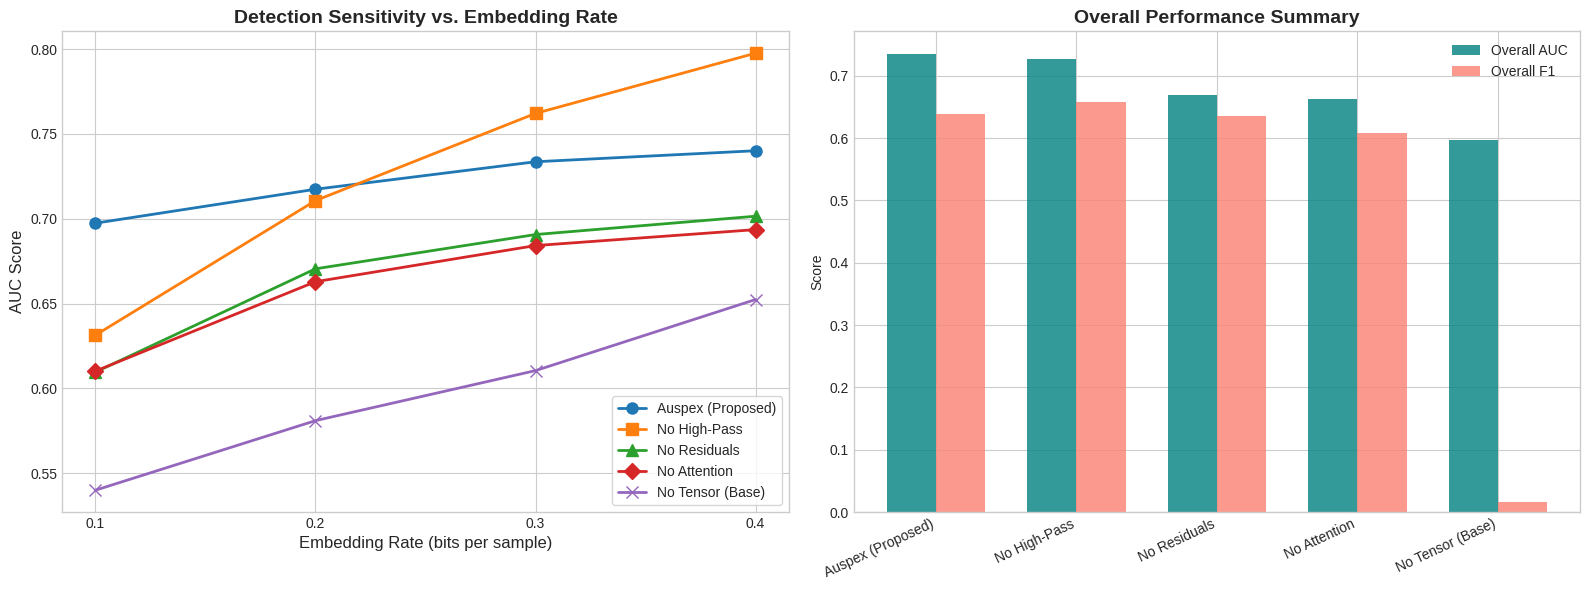

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ============================================================================
# 1. CONSOLIDATED MASTER DATA (All models, All payloads, All metrics)
# ============================================================================
models = ["Auspex (Proposed)", "No High-Pass", "No Residuals", "No Attention", "No Tensor (Base)"]

# Rows correspond to the model list above
overall_data = {
    "ACC": [0.6696, 0.6575, 0.6076, 0.6108, 0.5032],
    "AUC": [0.7346, 0.7266, 0.6688, 0.6634, 0.5968],
    "PRE": [0.7056, 0.5536, 0.4780, 0.5145, 0.7897],
    "REC": [0.5820, 0.8485, 0.8568, 0.8088, 0.0135],
    "F1":  [0.6379, 0.6573, 0.6351, 0.6079, 0.0164]
}

# Payload-specific AUCs (Comparison of detection depth)
payload_aucs = {
    0.1: [0.6974, 0.6314, 0.6096, 0.6102, 0.5400],
    0.2: [0.7174, 0.7107, 0.6705, 0.6629, 0.5810],
    0.3: [0.7336, 0.7621, 0.6907, 0.6842, 0.6105],
    0.4: [0.7401, 0.7976, 0.7015, 0.6936, 0.6524]
}

# Algorithm-specific AUCs (Forensic robustness)
algo_aucs = {
    "CNV": [0.7792, 0.8609, 0.8087, 0.8162, 0.6530],
    "PMS": [0.6184, 0.5923, 0.5289, 0.5105, 0.5406]
}

# ============================================================================
# 2. FORMATTED TABLE GENERATOR
# ============================================================================
def print_separator():
    print("+" + "-"*25 + "+" + ("-"*12 + "+") * 5)

def print_table_header(title, col_names):
    print("\n" + "="*91)
    print(f" {title.center(89)} ")
    print("="*91)
    header = f"| {'Model Variant':<23} | " + " | ".join([f"{n:<10}" for n in col_names]) + " |"
    print_separator()
    print(header)
    print_separator()

# Table 1: Overall Picture
print_table_header("TABLE 1: GLOBAL BENCHMARK METRICS (OVERALL)", ["ACC", "AUC", "PRE", "REC", "F1"])
for i, m_name in enumerate(models):
    print(f"| {m_name:<23} | {overall_data['ACC'][i]:<10.4f} | {overall_data['AUC'][i]:<10.4f} | "
          f"{overall_data['PRE'][i]:<10.4f} | {overall_data['REC'][i]:<10.4f} | {overall_data['F1'][i]:<10.4f} |")
print_separator()

# Table 2: Detection Sensitivity (AUC per Embedding Rate)
print_table_header("TABLE 2: PAYLOAD DETECTION SENSITIVITY (AUC)", ["ER 0.1", "ER 0.2", "ER 0.3", "ER 0.4", "MEAN"])
for i, m_name in enumerate(models):
    rates = [payload_aucs[r][i] for r in [0.1, 0.2, 0.3, 0.4]]
    mean_auc = sum(rates)/4
    print(f"| {m_name:<23} | {rates[0]:<10.4f} | {rates[1]:<10.4f} | "
          f"{rates[2]:<10.4f} | {rates[3]:<10.4f} | {mean_auc:<10.4f} |")
print_separator()

# Table 3: Algorithm Forensics (AUC per Strategy)
print_table_header("TABLE 3: STRATEGY ROBUSTNESS (AUC)", ["CNV (QIM)", "PMS", "GAP", "---", "---"])
for i, m_name in enumerate(models):
    cnv, pms = algo_aucs["CNV"][i], algo_aucs["PMS"][i]
    gap = cnv - pms
    print(f"| {m_name:<23} | {cnv:<10.4f} | {pms:<10.4f} | {gap:<10.4f} | {'-':<10} | {'-':<10} |")
print_separator()

# ============================================================================
# 3. COMPARATIVE VISUALIZATION
# ============================================================================
plt.style.use('seaborn-v0_8-whitegrid')
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: AUC Growth across Embedding Rates
x_rates = [0.1, 0.2, 0.3, 0.4]
markers = ['o', 's', '^', 'D', 'x']
for i, m_name in enumerate(models):
    y_vals = [payload_aucs[r][i] for r in x_rates]
    ax1.plot(x_rates, y_vals, label=m_name, marker=markers[i], linewidth=2, markersize=8)

ax1.set_title("Detection Sensitivity vs. Embedding Rate", fontsize=14, fontweight='bold')
ax1.set_xlabel("Embedding Rate (bits per sample)", fontsize=12)
ax1.set_ylabel("AUC Score", fontsize=12)
ax1.set_xticks(x_rates)
ax1.legend(frameon=True, loc='lower right')

# Plot 2: Overall Metric Comparison
x_indices = np.arange(len(models))
width = 0.35
ax2.bar(x_indices - width/2, overall_data["AUC"], width, label='Overall AUC', color='teal', alpha=0.8)
ax2.bar(x_indices + width/2, overall_data["F1"], width, label='Overall F1', color='salmon', alpha=0.8)

ax2.set_title("Overall Performance Summary", fontsize=14, fontweight='bold')
ax2.set_xticks(x_indices)
ax2.set_xticklabels(models, rotation=25, ha='right')
ax2.set_ylabel("Score")
ax2.legend()

plt.tight_layout()
plt.savefig("auspex_ablation_summary.png", dpi=300)
print("\n[SUCCESS] Organized tables generated and visualization saved as 'auspex_ablation_summary.png'")

#====================================================================================================

#MODEL DEMONSTRATION

In [ ]:
# Install everything in one go and force compatibility
!pip install --upgrade "numpy<2.1" "pandas<2.3" captum fpdf openpyxl

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.9/60.9 kB 3.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.9/89.9 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.7/12.7 MB 56.6 MB/s eta 0:00:00
  Attempting uninstall: pandas
    Found existing installation: pandas 3.0.1
    Uninstalling pandas-3.0.1:
      Successfully uninstalled pandas-3.0.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.2.3 which is incompatible.
tobler 0.13.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
xarray-einstats 0.10.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
shap 0.51.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.


In [ ]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import pandas as pd
import datetime
import matplotlib.pyplot as plt
from fpdf import FPDF
from captum.attr import IntegratedGradients

# ============================================================================
# 1. UPDATED MODEL ARCHITECTURE (StegoCNN - 9 Channel Core)
# ============================================================================
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class DualPathwayForensicLayer(nn.Module):
    def __init__(self):
        super().__init__()
        self.register_buffer('kernel1', torch.tensor([[[[-1., 1.]]]], dtype=torch.float32))
        self.register_buffer('kernel2', torch.tensor([[[[-1., 2., -1.]]]], dtype=torch.float32))
        self.register_buffer('kernel3', torch.tensor([[[[-1., 3., -3., 1.]]]], dtype=torch.float32))
        self.register_buffer('kernel_spatial', torch.tensor([[[[-1., -1., -1.], [ -1.,  8., -1.], [-1., -1., -1.]]]], dtype=torch.float32))
        self.learnable_filters = nn.Conv2d(1, 2, kernel_size=3, padding=1, bias=False)
        nn.init.xavier_normal_(self.learnable_filters.weight)
    def forward(self, x):
        raw_bits = x[:, 0:1, :, :]
        res1 = F.pad(F.conv2d(raw_bits, self.kernel1, padding=0), (0, 1, 0, 0))
        res2 = F.pad(F.conv2d(raw_bits, self.kernel2, padding=0), (1, 1, 0, 0))
        res3 = F.pad(F.conv2d(raw_bits, self.kernel3, padding=0), (1, 2, 0, 0))
        res_sp = F.conv2d(raw_bits, self.kernel_spatial, padding=1)
        return torch.cat([res1, res2, res3, res_sp, self.learnable_filters(raw_bits)], dim=1)

class DepthwiseSeparableConv(nn.Module):
    def __init__(self, in_channels, out_channels, dropout=0.1):
        super().__init__()
        self.depthwise = nn.Conv2d(in_channels, in_channels, 3, padding=1, groups=in_channels, bias=False)
        self.bn1 = nn.BatchNorm2d(in_channels)
        self.pointwise = nn.Conv2d(in_channels, out_channels, 1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels); self.dropout = nn.Dropout2d(dropout)
    def forward(self, x):
        return F.relu(self.bn2(self.pointwise(self.dropout(F.relu(self.bn1(self.depthwise(x)))))))

class ResidualBlock(nn.Module):
    def __init__(self, channels, dropout=0.1):
        super().__init__()
        self.conv1 = nn.Conv2d(channels, channels, 3, padding=1, bias=False); self.bn1 = nn.BatchNorm2d(channels)
        self.conv2 = nn.Conv2d(channels, channels, 3, padding=1, bias=False); self.bn2 = nn.BatchNorm2d(channels)
        self.dropout = nn.Dropout2d(dropout)
    def forward(self, x):
        res = x
        out = F.relu(self.bn1(self.conv1(x))); out = self.dropout(out)
        return F.relu(self.bn2(self.conv2(out)) + res)

class SEBlock(nn.Module):
    def __init__(self, channels, reduction=16):
        super().__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Sequential(nn.Linear(channels, channels // reduction, bias=False), nn.ReLU(inplace=True),
                                nn.Linear(channels // reduction, channels, bias=False), nn.Sigmoid())
    def forward(self, x):
        b, c, _, _ = x.size()
        y = self.fc(self.avg_pool(x).view(b, c)).view(b, c, 1, 1)
        return x * y.expand_as(x)

class SpatialAttention(nn.Module):
    def __init__(self, kernel_size=7):
        super().__init__()
        self.conv = nn.Conv2d(2, 1, kernel_size=kernel_size, padding=kernel_size//2, bias=False); self.sigmoid = nn.Sigmoid()
    def forward(self, x):
        avg_out = torch.mean(x, dim=1, keepdim=True); max_out, _ = torch.max(x, dim=1, keepdim=True)
        attn = self.sigmoid(self.conv(torch.cat([avg_out, max_out], dim=1)))
        return x * attn, attn

class StegoCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.hp_layer = DualPathwayForensicLayer()
        self.init_conv = nn.Sequential(nn.Conv2d(9, 64, 1, bias=False), nn.BatchNorm2d(64), nn.ReLU(),
                                       nn.Conv2d(64, 32, 3, padding=1, bias=False), nn.BatchNorm2d(32), nn.ReLU(),
                                       nn.MaxPool2d(2, 2))
        self.dw_conv = DepthwiseSeparableConv(32, 64); self.pool2 = nn.MaxPool2d(2, 2)
        self.attention = SpatialAttention()
        self.res_block1 = ResidualBlock(64); self.se1 = SEBlock(64)
        self.res_block2 = ResidualBlock(64); self.se2 = SEBlock(64)
        self.fc = nn.Sequential(nn.Dropout(0.4), nn.Linear(128, 1))
    def forward(self, x):
        hp = self.hp_layer(x); x = torch.cat([x, hp], dim=1); x = self.init_conv(x)
        x = self.pool2(self.dw_conv(x)); x, attn = self.attention(x)
        x = self.se1(self.res_block1(x)); x = self.se2(self.res_block2(x))
        return self.fc(torch.cat([torch.mean(x, dim=[2, 3]), torch.std(x, dim=[2, 3])], dim=1)), attn

# ============================================================================
# 2. PREPROCESSING
# ============================================================================

def preprocess_g729a(file_path):
    with open(file_path, 'rb') as f:
        data = f.read()[:1000]
    bits = np.unpackbits(np.frombuffer(data, dtype=np.uint8)).reshape(-1, 80).astype(np.float32)
    bits = bits[:100, :]
    diff = np.zeros_like(bits); diff[1:] = np.abs(bits[1:] - bits[:-1])
    stability = np.abs(bits - np.mean(bits, axis=0, keepdims=True))
    return torch.from_numpy(np.stack([bits, diff, stability], axis=0)).unsqueeze(0).to(DEVICE)

# ============================================================================
# 3. AUSPEX REPORTER ENGINE (Fixed Definition Error)
# ============================================================================

class AuspexReporter:
    def __init__(self, model, device, threshold=0.5229):
        self.model = model.to(device).eval(); self.device = device
        self.threshold = threshold; self.ig = IntegratedGradients(lambda x: self.model(x)[0])
        self.channel_names = ['Raw Bits', 'Temp. Diff', 'Bit Stability']
        self.img_w = 130; self.small_img_w = 90
        self.center_x = (210 - self.img_w) / 2
        self.center_x_small = (210 - self.small_img_w) / 2

    def generate_report(self, tensor, sample_name, output_path):
        input_t = tensor.clone().requires_grad_(True)
        with torch.no_grad():
            logits, _ = self.model(input_t)
            prob = torch.sigmoid(logits).item()

        attr = self.ig.attribute(input_t, target=0, n_steps=50).squeeze(0).cpu().detach().numpy()
        img_paths = self._create_plots(tensor.squeeze(0), attr)

        # FIXED: CALIBRATED RISK BANDING (status defined correctly)
        if prob > (self.threshold + 0.1): risk, status, b_color = "HIGH RISK", "COMPROMISED", (231, 76, 60)
        elif prob > self.threshold: risk, status, b_color = "SUSPICIOUS", "COMPROMISED", (231, 76, 60)
        elif prob > (self.threshold - 0.1): risk, status, b_color = "UNCERTAIN", "INCONCLUSIVE", (241, 196, 15)
        else: risk, status, b_color = "LIKELY CLEAN", "CLEAN", (46, 204, 113)

        pdf = FPDF()

        # --- PAGE 1: CASE SUMMARY & GAUGE ---
        pdf.add_page()
        pdf.set_fill_color(30, 35, 45); pdf.rect(0, 0, 210, 30, 'F')
        pdf.set_text_color(255, 255, 255); pdf.set_font("Helvetica", 'B', 18)
        pdf.cell(190, 10, "AUSPEX: BLIND FORENSIC AUDIT", ln=True, align='C')
        pdf.set_font("Helvetica", 'I', 8); pdf.cell(190, 5, f"Automated Field Scan | Neural Core | Threshold: {self.threshold}", ln=True, align='C')
        pdf.ln(10)

        # [1] Metadata
        pdf.set_text_color(0, 0, 0); pdf.set_font("Helvetica", 'B', 10); pdf.set_fill_color(240, 240, 240)
        pdf.cell(190, 7, " [1] ANALYSIS CONTEXT", ln=True, fill=True); pdf.set_font("Courier", '', 9); pdf.ln(1)
        pdf.cell(190, 5, f" > SAMPLE ID: {sample_name}", ln=True)
        pdf.set_font("Courier", 'B', 9); pdf.cell(190, 5, f" > INITIAL FIELD VERDICT: {status}", ln=True); pdf.ln(2)

        # [2] Risk Gauge
        pdf.set_font("Helvetica", 'B', 10); pdf.cell(190, 7, " [2] CALIBRATED RISK ASSESSMENT", ln=True, fill=True); pdf.ln(3)
        pdf.set_x(45); pdf.set_font("Helvetica", 'B', 7)
        pdf.cell(40, 3, "LIKELY CLEAN", align='L'); pdf.cell(40, 3, "UNCERTAIN", align='C'); pdf.cell(40, 3, "HIGH RISK", align='R', ln=True)
        pdf.set_draw_color(200, 200, 200); pdf.rect(45, pdf.get_y(), 120, 4); pdf.set_fill_color(*b_color); pdf.rect(45, pdf.get_y(), 120 * prob, 4, 'F')
        pdf.set_draw_color(0, 0, 0); pdf.set_line_width(0.5); pdf.line(45 + (120 * self.threshold), pdf.get_y()-1, 45 + (120 * self.threshold), pdf.get_y()+5)
        pdf.set_y(pdf.get_y() + 5); pdf.set_font("Helvetica", 'B', 9)
        pdf.cell(190, 5, f"Neural Score: {prob:.4f} | Forensic Status: {status}", align='C', ln=True); pdf.ln(3)

        # [3] Artifacts 1 & 2
        pdf.set_font("Helvetica", 'B', 10); pdf.cell(190, 7, " [3] PRIMARY ARTIFACT VISUALIZATION", ln=True, fill=True); pdf.ln(2)
        pdf.image(img_paths[0], x=self.center_x, y=None, w=self.img_w); pdf.ln(4)
        pdf.image(img_paths[1], x=self.center_x, y=None, w=self.img_w)

        # --- PAGE 2: DECISION EVIDENCE ---
        pdf.add_page(); pdf.ln(5)
        pdf.set_font("Helvetica", 'B', 10); pdf.cell(190, 7, " [4] EXPLAINABLE DECISION EVIDENCE", ln=True, fill=True); pdf.ln(3)
        pdf.image(img_paths[2], x=self.center_x, y=None, w=self.img_w); pdf.ln(4)
        pdf.image(img_paths[3], x=self.center_x, y=None, w=self.img_w); pdf.ln(8)
        pdf.set_font("Helvetica", 'B', 10); pdf.cell(190, 7, " [5] CHANNEL ATTRIBUTION WEIGHT", ln=True, fill=True); pdf.ln(3)
        pdf.image(img_paths[4], x=self.center_x_small, y=None, w=self.small_img_w)

        # --- PAGE 3: GUIDANCE, LIMITATIONS & VERDICT ---
        pdf.add_page(); pdf.ln(5)
        pdf.set_font("Helvetica", 'B', 10); pdf.cell(190, 7, " [6] INVESTIGATIVE GUIDANCE (ATTENTION REGIONS)", ln=True, fill=True); pdf.set_font("Helvetica", '', 9); pdf.ln(2)
        guides = [("1. Signal Pattern", "Observe vertical bit-distribution symmetry."),
                  ("2. Forensic Residual", "Attention: Bright clusters indicate algorithmic anomalies."),
                  ("3. Neural Focus", "Attention: Clustered Cyan hotspots reveal verdict-driving bits."),
                  ("4. Timeline", "Attention: Sharp spikes reveal payload temporal location."),
                  ("5. Channel Intensity", "Identify the dominant channel.")]
        for title, guidance in guides:
            pdf.set_font("Helvetica", 'B', 9); pdf.cell(190, 5, f" - {title}", ln=True)
            pdf.set_font("Helvetica", '', 8.5); pdf.cell(190, 5, f"   Tip: {guidance}", ln=True); pdf.ln(1)

        # [7] Pipeline Limitations
        pdf.ln(3); pdf.set_font("Helvetica", 'B', 10); pdf.cell(190, 7, " [7] PIPELINE LIMITATIONS", ln=True, fill=True); pdf.ln(2)
        pdf.set_font("Helvetica", 'I', 8)
        lims = ["1. Sensitivity: Detection accuracy degrades at low embedding rates (< 0.1 bpc).",
                "2. Attribution: Heatmaps indicate neural influence, not physical data extraction."]
        for l in lims: pdf.cell(190, 4, f" - {l}", ln=True)

        # [8] Investigative Findings
        pdf.ln(4); pdf.set_font("Helvetica", 'B', 11); pdf.cell(190, 8, " [8] INVESTIGATIVE FINDINGS", ln=True, fill=True); pdf.ln(2)
        pdf.set_font("Helvetica", '', 10)
        msg = "Findings: Indicators suggest pattern manipulation consistent with steganography." if prob > self.threshold else "Findings: Signal characteristics remain within natural variance."
        pdf.multi_cell(190, 5, f"{msg} Forensic secondary audit recommended." if prob > self.threshold else f"{msg} No further action required.")

        pdf.ln(10); pdf.set_font("Helvetica", 'B', 15); pdf.set_text_color(*b_color)
        pdf.cell(190, 15, f"!!! FINAL VERDICT: {status} !!!", border=1, ln=True, align='C')

        pdf.output(output_path)
        for p in img_paths: os.remove(p)

    def _create_plots(self, tensor, attr):
        paths = ["v1.png", "v2.png", "v3.png", "v4.png", "v5.png"]
        def save_f(path, title, data, cmap=None, is_bar=False, sz=(10, 6)):
            plt.figure(figsize=sz)
            if is_bar:
                plt.bar(self.channel_names, data, color=['#5D6D7E', '#EB984E', '#17A589'], edgecolor='black')
                for i, v in enumerate(data): plt.text(i, v + 0.5, f"{v:.1f}%", ha='center', weight='bold')
                plt.ylabel("Influence (%)")
            elif cmap:
                im = plt.imshow(data, cmap=cmap, aspect='auto'); plt.colorbar(im, fraction=0.046, pad=0.04); plt.axis('off')
            else:
                plt.fill_between(range(len(data)), data, color='teal', alpha=0.3); plt.plot(data, color='teal')
                plt.ylabel("Intensity")
            plt.title(title, fontweight='bold', fontsize=14); plt.savefig(path, dpi=120, bbox_inches='tight'); plt.close()

        save_f(paths[0], "1. Bitstream Scan", tensor[0].cpu().numpy(), cmap='gray')
        hp_k = torch.tensor([[[[-1., -1., -1.], [ -1.,  8., -1.], [-1., -1., -1.]]]]).to(self.device)
        res = F.conv2d(tensor.unsqueeze(0)[:, 0:1, :, :], hp_k, padding=1).squeeze().cpu().numpy()
        save_f(paths[1], "2. Forensic Residual Scan", res, cmap='inferno')

        # Scan 3 Neural Focus: properly overlaid on gray bitstream background
        plt.figure(figsize=(10, 6))
        plt.imshow(tensor[0].cpu().numpy(), cmap='gray', alpha=0.3, aspect='auto')
        mask = np.abs(attr[0]) > np.percentile(np.abs(attr[0]), 98)
        overlay = np.ma.masked_where(~mask, attr[0])
        im = plt.imshow(overlay, cmap='cool', interpolation='none', aspect='auto')
        plt.colorbar(im, label='Attribution Score'); plt.title("3. Neural Decision Focus (XAI)", fontweight='bold', fontsize=14); plt.axis('off')
        plt.savefig(paths[2], dpi=120, bbox_inches='tight'); plt.close()

        save_f(paths[3], "4. Temporal Attribution Timeline", np.abs(attr).sum(axis=(0, 2)))
        imp = np.abs(attr).sum(axis=(1, 2)); save_f(paths[4], "5. Attribution Intensity by Channel", (imp/imp.sum())*100, is_bar=True, sz=(7, 4))
        return paths

# ============================================================================
# 4. MAIN EXECUTION
# ============================================================================

if __name__ == "__main__":
    MODEL_PATH = "/content/drive/MyDrive/IIT - University of Westminster Material/VStego800K dataset/Models/Auspex_Forensic_Final_Original/Auspex_Forensic_Final_Original_seed42_best.pt"
    TEST_FILE = "/content/Chinese137521.g729a"
    REPORT_PATH = "/content/Forensic_Report.pdf"

    if os.path.exists(MODEL_PATH) and os.path.exists(TEST_FILE):
        print(" Auspex Core Online. Initiating field scan...")
        model = StegoCNN().to(DEVICE)
        ckpt = torch.load(MODEL_PATH, map_location=DEVICE, weights_only=False)
        model.load_state_dict(ckpt['model_state_dict'])

        print(f" Analyzing Sample: {os.path.basename(TEST_FILE)}")
        tensor = preprocess_g729a(TEST_FILE)

        reporter = AuspexReporter(model, DEVICE, threshold=0.5229)
        reporter.generate_report(tensor, os.path.basename(TEST_FILE), REPORT_PATH)
        print(f" Forensic Dossier Complete: {REPORT_PATH}")
    else:
        print(" Error: Path verification failed.")

 Auspex Core Online. Initiating field scan...
 Analyzing Sample: Chinese137521.g729a
 Forensic Dossier Complete: /content/Forensic_Report.pdf
